# **CÁTEDRA FINAL**

## Clasificación de enfermedades foliares del tomate mediante Deep Learning: comparación entre MLP y CNN sobre PlantVillage

| **Ítem** | **Detalle** |
|---|---|
| **Asignatura** | Deep Learning |
| **Ponderación** | 60 % de la nota final |
| **Modalidad** | Grupos del proyecto |
| **Fecha de entrega** | Sábado, 29 de agosto de 2026 |

> **Alumnos** : Guido Ríos Ciaffaroni
>> **Correo** : *guidoriosciaffaroni@gmail.com*


> **Alumnos** : Eduardo Opazo  
>> **Correo** : *edo.opazo.d@gmail.com*

# Fase 0 - Preparación y organización del proyecto

##**Contexto del problema y variable objetivo**

### **1. Contexto del problema**

La identificación oportuna de enfermedades en cultivos agrícolas constituye una tarea relevante para la sanidad vegetal, debido a que distintas patologías pueden afectar el desarrollo de las plantas, reducir el rendimiento de los cultivos y generar pérdidas productivas. En este contexto, el análisis automatizado de imágenes mediante técnicas de **Visión por Computador y Deep Learning** representa una alternativa para apoyar la clasificación de enfermedades a partir de características visuales presentes en las hojas.

Las enfermedades foliares pueden manifestarse mediante diferentes patrones visuales, entre ellos:

* Cambios de coloración.
* Aparición de manchas o lesiones.
* Alteraciones en la textura de la superficie foliar.
* Variaciones en la forma y distribución de las zonas afectadas.
* Presencia de patrones característicos asociados a determinadas enfermedades.

A diferencia de un conjunto de datos tabular, donde las características suelen encontrarse representadas explícitamente mediante variables numéricas o categóricas, una imagen contiene información distribuida espacialmente entre sus píxeles. Por esta razón, características como bordes, texturas, manchas, formas y patrones de lesión deben ser **aprendidas automáticamente por el modelo** a partir de los datos visuales.

En este proyecto se utiliza el conjunto de datos **PlantVillage**, restringiendo el análisis exclusivamente a imágenes correspondientes a hojas de **tomate (*Tomato*)**. Después del proceso de selección, verificación de integridad y eliminación de archivos duplicados exactos, el conjunto de datos utilizado contiene **18.146 imágenes únicas**, distribuidas en **10 clases** que representan diferentes enfermedades foliares y una categoría correspondiente a hojas saludables.

Las imágenes presentan características homogéneas de almacenamiento: se encuentran en formato **JPEG**, utilizan representación de color **RGB** y poseen una resolución original de **256 × 256 píxeles**. Estas características permiten establecer un pipeline uniforme de preprocesamiento antes del entrenamiento de los modelos.

La **variable objetivo** corresponde a la categoría sanitaria asignada a cada imagen, es decir, la enfermedad foliar o el estado saludable de la hoja de tomate. Matemáticamente, para cada imagen (X_i), se desea predecir una etiqueta:

$[
y_i \in {c_1,c_2,\ldots,c_{10}}
]$

donde cada (c_k) representa una de las diez clases presentes en el conjunto de datos.

Por lo tanto, el problema corresponde a una tarea de **clasificación supervisada multiclase**, ya que cada imagen debe ser asignada a una única categoría entre varias clases posibles.

El propósito general del proyecto es desarrollar y comparar dos arquitecturas de Deep Learning estudiadas en la asignatura: una **Red Neuronal Multicapa (MLP)** y una **Red Neuronal Convolucional (CNN)**. Ambas utilizarán las mismas imágenes como fuente de información, pero representarán hipótesis diferentes respecto de cómo aprovechar su estructura.

La MLP utilizará una representación vectorizada de la imagen, mientras que la CNN conservará y explotará explícitamente las relaciones espaciales entre los píxeles mediante operaciones convolucionales. De esta manera, el proyecto buscará determinar si la capacidad de una CNN para aprender patrones locales y jerarquías espaciales permite obtener una mejor capacidad de clasificación y generalización que una MLP aplicada sobre las mismas imágenes.

En consecuencia, la pregunta experimental central puede formularse como:

> **¿En qué medida una red neuronal convolucional (CNN), al conservar y explotar la estructura espacial de las imágenes, mejora la clasificación y la capacidad de generalización de enfermedades foliares del tomate respecto de una red neuronal multicapa (MLP) que utiliza una representación vectorizada de las mismas imágenes?**

---


## Librerias

In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Reproducibilidad

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

##**Descargar o cargar el conjunto de datos mediante código reproducible.**

## Descarga del dataset PlantVillage desde Kaggle mediante `curl`

En esta etapa se descargará directamente el archivo comprimido del dataset
**PlantVillage** utilizando `curl` y el endpoint de descarga proporcionado
por Kaggle.

El dataset será almacenado en:

`/content/plantvillage.zip`

Esta estrategia permite mantener inicialmente el conjunto de datos comprimido,
verificar su descarga e integridad y posteriormente descomprimirlo solamente
cuando sea necesario para el análisis de imágenes.

In [ ]:
%%bash

# ============================================================
# DESCARGA DEL DATASET PLANTVILLAGE DESDE KAGGLE
# ============================================================

curl -L \
  -o /content/plantvillage.zip \
  "https://www.kaggle.com/api/v1/datasets/download/mohitsingh1804/plantvillage"

In [ ]:
# ============================================================
# VERIFICACIÓN DE LA DESCARGA
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    print("✅ Dataset descargado correctamente.")
    print(f"Ruta: {ruta_zip}")

else:

    print("❌ No se encontró el archivo descargado.")

In [ ]:
# ============================================================
# TAMAÑO DEL ARCHIVO DESCARGADO
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    tamaño_bytes = os.path.getsize(ruta_zip)

    tamaño_mb = tamaño_bytes / (1024 ** 2)

    tamaño_gb = tamaño_bytes / (1024 ** 3)

    print("=" * 60)
    print("INFORMACIÓN DEL ARCHIVO")
    print("=" * 60)

    print(f"Archivo : {ruta_zip}")
    print(f"Tamaño  : {tamaño_mb:.2f} MB")
    print(f"Tamaño  : {tamaño_gb:.3f} GB")

else:

    print("❌ El archivo no existe.")

In [ ]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL ARCHIVO ZIP
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

try:

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

        archivo_problematico = archivo_zip.testzip()

    if archivo_problematico is None:

        print("✅ El archivo ZIP es válido y no presenta errores detectables.")

    else:

        print("⚠️ Se detectó un archivo problemático dentro del ZIP:")
        print(archivo_problematico)

except zipfile.BadZipFile:

    print("❌ El archivo descargado no corresponde a un ZIP válido.")

In [ ]:
# ============================================================
# INSPECCIÓN DEL CONTENIDO DEL ZIP
# SIN DESCOMPRIMIR
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

    archivos = archivo_zip.namelist()


print("=" * 70)
print("CONTENIDO DEL DATASET")
print("=" * 70)

print(f"Número total de elementos: {len(archivos):,}")

print("\nPrimeros 30 elementos:\n")

for archivo in archivos[:30]:

    print(archivo)

In [ ]:
# ============================================================
# CREACIÓN DEL DIRECTORIO DE EXTRACCIÓN
# ============================================================

import os

DIRECTORIO_DATOS = "/content/plantvillage"

os.makedirs(
    DIRECTORIO_DATOS,
    exist_ok=True
)

print("✅ Directorio creado:")
print(DIRECTORIO_DATOS)

In [ ]:
# ============================================================
# REINICIO CONTROLADO DEL DIRECTORIO DE TRABAJO
# ============================================================

from pathlib import Path
import shutil

WORK_DIR = Path("/content/plantvillage")

# Eliminar resultados de ejecuciones anteriores
if WORK_DIR.exists():

    shutil.rmtree(WORK_DIR)

    print(
        "🧹 Directorio anterior eliminado:"
    )
    print(WORK_DIR)

# Crear nuevamente un directorio limpio
WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "\n✅ Entorno limpio preparado."
)

In [ ]:
%%bash

unzip -q /content/plantvillage.zip \
       -d /content/plantvillage

## Filtrado de clases del dataset PlantVillage

En esta etapa se realizará un **filtrado de las clases originales del dataset PlantVillage** con el objetivo de conservar únicamente las categorías correspondientes a hojas de **tomate (`Tomato`)**, que constituyen el objeto de estudio del proyecto.

La eliminación se aplicará tanto sobre el conjunto original `train` como sobre el conjunto `val`, de manera que ambos subconjuntos mantengan el mismo criterio de selección.

Se eliminarán todas las carpetas cuyo nombre comience con alguno de los siguientes prefijos:

- Apple
- Blueberry
- Cherry
- Corn
- Grape
- Orange
- Peach
- Pepper
- Potato
- Raspberry
- Soybean
- Squash
- Strawberry

De esta forma, después del filtrado se conservarán exclusivamente las clases asociadas a **tomate**, incluyendo distintas enfermedades foliares y la categoría correspondiente a hojas saludables.

Antes de realizar la eliminación definitiva, el código verificará y mostrará qué directorios cumplen los criterios establecidos. Esta comprobación previa permite validar la selección y reducir el riesgo de eliminar accidentalmente alguna clase que deba formar parte del experimento.

El resultado esperado de esta etapa es obtener un conjunto de datos compuesto únicamente por las **10 clases de tomate** que serán utilizadas posteriormente en las etapas de auditoría, preprocesamiento, entrenamiento y comparación de los modelos **MLP y CNN**.







In [ ]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN DE RUTAS Y CLASES A ELIMINAR
# ============================================================

import os
import shutil


# ------------------------------------------------------------
# Directorio principal del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"


# Directorios de entrenamiento y validación
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# Prefijos de las clases que se desean eliminar
# ------------------------------------------------------------

PREFIJOS_ELIMINAR = (
    "Apple",
    "Blueberry",
    "Cherry",
    "Corn",
    "Grape",
    "Orange",
    "Peach",
    "Potato",
    "Pepper",
    "Raspberry",
    "Soybean",
    "Squash",
    "Strawberry"
)


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")

print("\nPrefijos que serán eliminados:")

for prefijo in PREFIJOS_ELIMINAR:
    print(f" - {prefijo}")

In [ ]:
# ============================================================
# BLOQUE 3
# MOSTRAR TODAS LAS CLASES DISPONIBLES
# ============================================================

def mostrar_clases(directorio, nombre_conjunto):
    """
    Muestra las carpetas correspondientes a las clases de un conjunto.
    """

    print("\n" + "=" * 70)
    print(f"CLASES DISPONIBLES EN {nombre_conjunto.upper()}")
    print("=" * 70)

    if not os.path.exists(directorio):
        print(f"❌ No existe el directorio: {directorio}")
        return []

    clases = sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(os.path.join(directorio, carpeta))
    )

    for i, clase in enumerate(clases, start=1):
        print(f"{i:02d}. {clase}")

    print(f"\nNúmero total de clases: {len(clases)}")

    return clases


clases_train = mostrar_clases(
    TRAIN_DIR,
    "train"
)

clases_val = mostrar_clases(
    VAL_DIR,
    "val"
)

In [ ]:
# ============================================================
# BLOQUE 4
# IDENTIFICAR CARPETAS QUE SERÁN ELIMINADAS
# ============================================================

def identificar_carpetas_eliminar(directorio):
    """
    Identifica las carpetas cuyo nombre comienza
    con alguno de los prefijos definidos.
    """

    carpetas_eliminar = []

    if not os.path.exists(directorio):
        return carpetas_eliminar

    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )

        # Comprobar que sea realmente una carpeta
        if os.path.isdir(ruta_carpeta):

            # Verificar si el nombre comienza con alguno
            # de los prefijos indicados
            if carpeta.startswith(PREFIJOS_ELIMINAR):

                carpetas_eliminar.append(carpeta)

    return sorted(carpetas_eliminar)


eliminar_train = identificar_carpetas_eliminar(
    TRAIN_DIR
)

eliminar_val = identificar_carpetas_eliminar(
    VAL_DIR
)


print("=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN")
print("=" * 70)

for carpeta in eliminar_train:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_train)} carpetas")


print("\n" + "=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE VAL")
print("=" * 70)

for carpeta in eliminar_val:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_val)} carpetas")

In [ ]:
# ============================================================
# BLOQUE 5
# CONTAR IMÁGENES QUE SERÁN ELIMINADAS
# ============================================================

def contar_archivos_carpeta(ruta):
    """
    Cuenta todos los archivos contenidos en una carpeta
    y sus subdirectorios.
    """

    contador = 0

    for _, _, archivos in os.walk(ruta):
        contador += len(archivos)

    return contador


def resumen_eliminacion(directorio, carpetas):

    total_imagenes = 0

    for carpeta in carpetas:

        ruta = os.path.join(
            directorio,
            carpeta
        )

        cantidad = contar_archivos_carpeta(ruta)

        total_imagenes += cantidad

        print(
            f"{carpeta:<65} "
            f"{cantidad:>6} imágenes"
        )

    return total_imagenes


print("=" * 85)
print("IMÁGENES A ELIMINAR DE TRAIN")
print("=" * 85)

imagenes_train_eliminar = resumen_eliminacion(
    TRAIN_DIR,
    eliminar_train
)

print(
    f"\nTotal imágenes a eliminar de train: "
    f"{imagenes_train_eliminar:,}"
)


print("\n" + "=" * 85)
print("IMÁGENES A ELIMINAR DE VAL")
print("=" * 85)

imagenes_val_eliminar = resumen_eliminacion(
    VAL_DIR,
    eliminar_val
)

print(
    f"\nTotal imágenes a eliminar de val: "
    f"{imagenes_val_eliminar:,}"
)

In [ ]:
# ============================================================
# BLOQUE 6
# ELIMINACIÓN DEFINITIVA DE LAS CARPETAS
# ============================================================

def eliminar_carpetas(directorio, prefijos):
    """
    Elimina todas las carpetas cuyo nombre comienza con
    cualquiera de los prefijos especificados.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio que contiene las clases.

    prefijos : tuple
        Prefijos correspondientes a las clases
        que deben eliminarse.
    """

    eliminadas = []

    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")

        return eliminadas


    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )


        if (
            os.path.isdir(ruta_carpeta)
            and carpeta.startswith(prefijos)
        ):

            # Eliminar carpeta y todo su contenido
            shutil.rmtree(ruta_carpeta)

            eliminadas.append(carpeta)

            print(f"🗑️ Eliminada: {carpeta}")


    return sorted(eliminadas)

In [ ]:
# ============================================================
# EJECUTAR ELIMINACIÓN
# ============================================================

print("=" * 70)
print("ELIMINANDO CLASES DE TRAIN")
print("=" * 70)

eliminadas_train = eliminar_carpetas(
    TRAIN_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("ELIMINANDO CLASES DE VAL")
print("=" * 70)

eliminadas_val = eliminar_carpetas(
    VAL_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print(
    f"Carpetas eliminadas de train: "
    f"{len(eliminadas_train)}"
)

print(
    f"Carpetas eliminadas de val  : "
    f"{len(eliminadas_val)}"
)

In [ ]:
# ============================================================
# BLOQUE 7
# VERIFICACIÓN POSTERIOR A LA ELIMINACIÓN
# ============================================================

def obtener_clases(directorio):

    return sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(
            os.path.join(
                directorio,
                carpeta
            )
        )
    )


clases_train_final = obtener_clases(
    TRAIN_DIR
)

clases_val_final = obtener_clases(
    VAL_DIR
)


print("=" * 70)
print("CLASES RESTANTES EN TRAIN")
print("=" * 70)

for i, clase in enumerate(
    clases_train_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_train_final)}"
)


print("\n" + "=" * 70)
print("CLASES RESTANTES EN VAL")
print("=" * 70)

for i, clase in enumerate(
    clases_val_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_val_final)}"
)

In [ ]:
# ============================================================
# BLOQUE 8
# CONSISTENCIA ENTRE TRAIN Y VAL
# ============================================================

set_train = set(clases_train_final)
set_val = set(clases_val_final)


if set_train == set_val:

    print("✅ TRAIN y VAL contienen exactamente las mismas clases.")

else:

    print("⚠️ TRAIN y VAL no contienen las mismas clases.")


    solo_train = set_train - set_val

    solo_val = set_val - set_train


    if solo_train:

        print("\nClases presentes solamente en TRAIN:")

        for clase in sorted(solo_train):
            print(f" - {clase}")


    if solo_val:

        print("\nClases presentes solamente en VAL:")

        for clase in sorted(solo_val):
            print(f" - {clase}")

## Conteo de imágenes por clase

En esta etapa se contabilizará la cantidad de imágenes disponibles en cada
directorio de clase para los conjuntos `train` y `val`.

El objetivo es verificar:

- cuántas clases permanecen en el dataset;
- cuántas imágenes contiene cada clase;
- si existe desbalance entre las categorías;
- el número total de imágenes por conjunto;
- la consistencia entre entrenamiento y validación.

Se considerarán como imágenes los archivos con extensiones:

`.jpg`, `.jpeg`, `.png`, `.bmp`, `.tif`, `.tiff` y `.webp`.

In [ ]:
# ============================================================
# CONTEO DE IMÁGENES POR DIRECTORIO / CLASE
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir rutas del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# 2. Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


# ------------------------------------------------------------
# 3. Función para contar imágenes por clase
# ------------------------------------------------------------

def contar_imagenes_por_clase(directorio, conjunto):
    """
    Cuenta la cantidad de imágenes contenidas en cada
    subdirectorio de un conjunto de datos.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio principal, por ejemplo train o val.

    conjunto : str
        Nombre del conjunto: 'train' o 'val'.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:
        - conjunto
        - clase
        - cantidad_imagenes
    """

    resultados = []

    # Verificar que el directorio exista
    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")
        return pd.DataFrame()


    # Recorrer las carpetas ordenadamente
    for clase in sorted(os.listdir(directorio)):

        ruta_clase = os.path.join(
            directorio,
            clase
        )

        # Procesar únicamente carpetas
        if os.path.isdir(ruta_clase):

            cantidad = 0

            # Recorrer los archivos de la carpeta
            for archivo in os.listdir(ruta_clase):

                if archivo.lower().endswith(
                    EXTENSIONES_IMAGEN
                ):

                    cantidad += 1


            resultados.append({
                "Conjunto": conjunto,
                "Clase": clase,
                "Cantidad_imagenes": cantidad
            })


    return pd.DataFrame(resultados)

In [ ]:
# ============================================================
# CONTEO DE IMÁGENES EN TRAIN
# ============================================================

df_train = contar_imagenes_por_clase(
    TRAIN_DIR,
    "train"
)


print("=" * 90)
print("IMÁGENES POR CLASE - TRAIN")
print("=" * 90)


for i, fila in df_train.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_train)}"
)

print(
    f"Total imágenes   : "
    f"{df_train['Cantidad_imagenes'].sum():,}"
)

In [ ]:
# ============================================================
# CONTEO DE IMÁGENES EN VALIDACIÓN
# ============================================================

df_val = contar_imagenes_por_clase(
    VAL_DIR,
    "val"
)


print("=" * 90)
print("IMÁGENES POR CLASE - VAL")
print("=" * 90)


for i, fila in df_val.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_val)}"
)

print(
    f"Total imágenes   : "
    f"{df_val['Cantidad_imagenes'].sum():,}"
)

## Consolidación de imágenes por clase

El dataset PlantVillage se encuentra actualmente dividido en dos conjuntos:

- `train`
- `val`

En esta etapa se eliminará dicha separación y se consolidarán todas las imágenes
pertenecientes a una misma clase en un único directorio.

Por ejemplo:

`train/Potato___Early_blight`

y

`val/Potato___Early_blight`

serán fusionados en:

`PlantVillage/Potato___Early_blight`

El procedimiento contempla:

1. Identificar automáticamente todas las clases.
2. Contar las imágenes antes de la consolidación.
3. Crear un directorio único para cada clase.
4. Mover las imágenes de `train` y `val`.
5. Evitar sobrescrituras en caso de nombres de archivos duplicados.
6. Verificar que el número total de imágenes se conserve.
7. Eliminar las antiguas carpetas `train` y `val`.

In [ ]:
# ============================================================
# CONTROL PREVIO A LA CONSOLIDACIÓN
# Detectar directorios consolidados de ejecuciones anteriores
# ============================================================

from pathlib import Path

# Directorio raíz del dataset PlantVillage
BASE_DIR = Path("/content/plantvillage/PlantVillage")

# ------------------------------------------------------------
# Verificar que el directorio exista
# ------------------------------------------------------------

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"No existe el directorio esperado:\n{BASE_DIR}"
    )

# ------------------------------------------------------------
# Buscar directorios de clases de tomate que estén directamente
# dentro de PlantVillage.
#
# Ejemplo:
# PlantVillage/Tomato___Bacterial_spot
# PlantVillage/Tomato___Early_blight
# etc.
# ------------------------------------------------------------

directorios_preexistentes = sorted([
    ruta
    for ruta in BASE_DIR.iterdir()
    if ruta.is_dir()
    and ruta.name.startswith("Tomato___")
])

# ------------------------------------------------------------
# Mostrar diagnóstico
# ------------------------------------------------------------

print("=" * 70)
print("CONTROL PREVIO A LA CONSOLIDACIÓN")
print("=" * 70)

print(f"\nDirectorio base:")
print(BASE_DIR)

print(
    f"\nDirectorios consolidados encontrados: "
    f"{len(directorios_preexistentes)}"
)

if directorios_preexistentes:

    print(
        "\n⚠️ Se detectaron directorios de tomate "
        "consolidados previamente:\n"
    )

    for ruta in directorios_preexistentes:
        print(f" - {ruta.name}")

    print(
        "\n❌ NO se recomienda continuar con la "
        "consolidación."
    )

    print(
        "\nEstos directorios probablemente pertenecen "
        "a una ejecución anterior del notebook."
    )

else:

    print(
        "\n✅ No existen directorios consolidados previos."
    )

    print(
        "✅ Es seguro continuar con la consolidación."
    )

In [ ]:
# ============================================================
# CONSOLIDACIÓN DEL DATASET PLANTVILLAGE
# ============================================================

from pathlib import Path
import shutil
from collections import defaultdict


# ------------------------------------------------------------
# Directorio principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Directorios actualmente existentes
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"


# Directorios que se van a fusionar
DIRECTORIOS_ORIGEN = {
    "train": TRAIN_DIR,
    "val": VAL_DIR
}


# Extensiones reconocidas como imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Directorio base : {BASE_DIR}")
print(f"Train           : {TRAIN_DIR}")
print(f"Val             : {VAL_DIR}")

In [ ]:
# ============================================================
# IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_por_conjunto = {}


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():

        print(
            f"⚠️ No existe el directorio: {directorio}"
        )

        clases_por_conjunto[conjunto] = []

        continue


    clases = sorted(
        carpeta.name
        for carpeta in directorio.iterdir()
        if carpeta.is_dir()
    )


    clases_por_conjunto[conjunto] = clases


    print("\n" + "=" * 80)
    print(f"CLASES EN {conjunto.upper()}")
    print("=" * 80)

    for i, clase in enumerate(clases, start=1):

        print(
            f"{i:02d}. {clase}"
        )


    print(
        f"\nTotal de clases: {len(clases)}"
    )

In [ ]:
# ============================================================
# CONTEO PREVIO DE IMÁGENES
# ============================================================

def contar_imagenes(directorio):
    """
    Cuenta todas las imágenes contenidas dentro de un
    directorio y sus subdirectorios.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


conteo_antes = defaultdict(int)


print("=" * 90)
print("IMÁGENES ANTES DE LA CONSOLIDACIÓN")
print("=" * 90)


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():
        continue


    for carpeta_clase in sorted(directorio.iterdir()):

        if not carpeta_clase.is_dir():
            continue


        cantidad = contar_imagenes(
            carpeta_clase
        )


        conteo_antes[
            carpeta_clase.name
        ] += cantidad


        print(
            f"{conjunto:<7} | "
            f"{carpeta_clase.name:<65} | "
            f"{cantidad:>6} imágenes"
        )


total_antes = sum(
    conteo_antes.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES ANTES: "
    f"{total_antes:,}"
)

In [ ]:
# ============================================================
# ESTRUCTURA FINAL ESPERADA
# ============================================================

todas_las_clases = sorted(
    set(
        clases_por_conjunto.get("train", [])
    )
    |
    set(
        clases_por_conjunto.get("val", [])
    )
)


print("=" * 80)
print("DIRECTORIOS FINALES")
print("=" * 80)


for clase in todas_las_clases:

    ruta_final = BASE_DIR / clase

    print(ruta_final)


print(
    f"\nNúmero total de clases finales: "
    f"{len(todas_las_clases)}"
)

In [ ]:
# ============================================================
# FUNCIÓN PARA GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    destino,
    nombre_archivo,
    conjunto
):
    """
    Genera una ruta de destino evitando sobrescribir
    archivos existentes.

    Si el nombre ya existe, se agrega el nombre del conjunto
    de origen y, si es necesario, un contador.
    """

    destino_original = (
        destino / nombre_archivo
    )


    # Si no existe, podemos utilizar el nombre original
    if not destino_original.exists():

        return destino_original


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    # Primer intento:
    # imagen.jpg -> imagen__val.jpg
    nuevo_destino = destino / (
        f"{nombre}__{conjunto}{extension}"
    )


    if not nuevo_destino.exists():

        return nuevo_destino


    # Si todavía existe, agregar contador
    contador = 1


    while True:

        nuevo_destino = destino / (
            f"{nombre}__{conjunto}_{contador}"
            f"{extension}"
        )


        if not nuevo_destino.exists():

            return nuevo_destino


        contador += 1

In [ ]:
# ============================================================
# CONSOLIDACIÓN DEFINITIVA
# ============================================================

imagenes_movidas = 0
archivos_renombrados = 0


for conjunto, directorio_origen in DIRECTORIOS_ORIGEN.items():

    if not directorio_origen.exists():

        print(
            f"⚠️ Se omite {conjunto}: "
            f"directorio inexistente."
        )

        continue


    print("\n" + "=" * 80)
    print(f"PROCESANDO {conjunto.upper()}")
    print("=" * 80)


    # --------------------------------------------------------
    # Recorrer cada clase
    # --------------------------------------------------------

    for carpeta_clase in sorted(
        directorio_origen.iterdir()
    ):

        if not carpeta_clase.is_dir():
            continue


        nombre_clase = carpeta_clase.name


        # ----------------------------------------------------
        # Crear directorio final de la clase
        #
        # Ejemplo:
        #
        # /content/plantvillage/PlantVillage/
        # Potato___Early_blight
        # ----------------------------------------------------

        destino_clase = (
            BASE_DIR / nombre_clase
        )


        destino_clase.mkdir(
            parents=True,
            exist_ok=True
        )


        contador_clase = 0


        # ----------------------------------------------------
        # Buscar imágenes
        # ----------------------------------------------------

        imagenes = [
            archivo
            for archivo in carpeta_clase.rglob("*")
            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        ]


        # ----------------------------------------------------
        # Mover cada imagen
        # ----------------------------------------------------

        for imagen in imagenes:

            destino = obtener_destino_unico(
                destino_clase,
                imagen.name,
                conjunto
            )


            # Saber si fue necesario cambiar nombre
            if destino.name != imagen.name:

                archivos_renombrados += 1


            # Mover archivo
            shutil.move(
                str(imagen),
                str(destino)
            )


            contador_clase += 1
            imagenes_movidas += 1


        print(
            f"✅ {nombre_clase:<65} "
            f"{contador_clase:>6} imágenes"
        )


print("\n" + "=" * 80)
print("CONSOLIDACIÓN FINALIZADA")
print("=" * 80)

print(
    f"Imágenes movidas       : "
    f"{imagenes_movidas:,}"
)

print(
    f"Archivos renombrados   : "
    f"{archivos_renombrados:,}"
)

In [ ]:
# ============================================================
# VERIFICACIÓN POSTERIOR
# ============================================================

conteo_despues = {}


print("=" * 90)
print("IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR")
print("=" * 90)


for clase in todas_las_clases:

    directorio_clase = (
        BASE_DIR / clase
    )


    if directorio_clase.exists():

        cantidad = contar_imagenes(
            directorio_clase
        )


        conteo_despues[
            clase
        ] = cantidad


        print(
            f"{clase:<70} "
            f"{cantidad:>7} imágenes"
        )


total_despues = sum(
    conteo_despues.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES DESPUÉS: "
    f"{total_despues:,}"
)

In [ ]:
# ============================================================
# COMPARACIÓN ANTES VS DESPUÉS
# ============================================================

print("=" * 70)
print("CONTROL DE INTEGRIDAD")
print("=" * 70)

print(
    f"Imágenes antes   : "
    f"{total_antes:,}"
)

print(
    f"Imágenes después : "
    f"{total_despues:,}"
)


diferencia = (
    total_despues
    - total_antes
)


print(
    f"Diferencia       : "
    f"{diferencia:,}"
)


print("-" * 70)


if total_antes == total_despues:

    print(
        "✅ CONSOLIDACIÓN CORRECTA."
    )

    print(
        "No se perdió ninguna imagen."
    )

else:

    print(
        "⚠️ ATENCIÓN: el número de imágenes "
        "antes y después no coincide."
    )

In [ ]:
# ============================================================
# VERIFICACIÓN POR CLASE
# ============================================================

print("=" * 100)
print(
    f"{'CLASE':<65}"
    f"{'ANTES':>10}"
    f"{'DESPUÉS':>12}"
    f"{'ESTADO':>12}"
)
print("=" * 100)


todo_correcto = True


for clase in sorted(conteo_antes):

    antes = conteo_antes.get(
        clase,
        0
    )

    despues = conteo_despues.get(
        clase,
        0
    )


    if antes == despues:

        estado = "✅ OK"

    else:

        estado = "❌ ERROR"

        todo_correcto = False


    print(
        f"{clase:<65}"
        f"{antes:>10}"
        f"{despues:>12}"
        f"{estado:>12}"
    )


print("=" * 100)


if todo_correcto:

    print(
        "\n✅ Todas las clases fueron "
        "consolidadas correctamente."
    )

In [ ]:
# ============================================================
# ELIMINAR DIRECTORIOS TRAIN Y VAL
# ============================================================

if total_antes == total_despues:

    for directorio in [
        TRAIN_DIR,
        VAL_DIR
    ]:

        if directorio.exists():

            shutil.rmtree(
                directorio
            )

            print(
                f"🗑️ Directorio eliminado: "
                f"{directorio}"
            )


    print(
        "\n✅ Carpetas train y val eliminadas."
    )


else:

    print(
        "❌ No se eliminarán train y val "
        "porque la verificación de imágenes "
        "no fue satisfactoria."
    )

In [ ]:
# ============================================================
# ESTRUCTURA FINAL DEL DATASET
# ============================================================

print("=" * 90)
print("ESTRUCTURA FINAL DE PLANTVILLAGE")
print("=" * 90)


directorios_finales = sorted(
    carpeta
    for carpeta in BASE_DIR.iterdir()
    if carpeta.is_dir()
)


for i, carpeta in enumerate(
    directorios_finales,
    start=1
):

    cantidad = contar_imagenes(
        carpeta
    )


    print(
        f"{i:02d}. "
        f"{carpeta.name:<65}"
        f"{cantidad:>7} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(directorios_finales)}"
)

## Verificación de integridad de las imágenes

Antes de dividir el dataset en los conjuntos de entrenamiento, validación y prueba,
se realizará una auditoría de integridad de todas las imágenes.

El objetivo es detectar archivos que puedan generar errores durante el
entrenamiento de los modelos de Deep Learning.

Para cada imagen se verificará:

1. Que el archivo exista y tenga un tamaño mayor que cero.
2. Que pueda ser reconocido como una imagen válida.
3. Que la estructura interna del archivo no esté corrupta.
4. Que la imagen pueda ser decodificada completamente.
5. Que posea dimensiones válidas.
6. Que su formato sea compatible con el pipeline de procesamiento.
7. Que se pueda identificar correctamente la clase a la que pertenece.

La verificación se realizará sin eliminar ni modificar archivos. Los archivos
problemáticos serán registrados para su posterior análisis.

In [ ]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS PARA VERIFICACIÓN DE INTEGRIDAD
# ============================================================

from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os

from tqdm.auto import tqdm


# ------------------------------------------------------------
# IMPORTANTE
# ------------------------------------------------------------
# No permitiremos que Pillow cargue automáticamente imágenes
# truncadas. Si una imagen está incompleta queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


print("✅ Librerías cargadas correctamente.")

In [ ]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Extensiones que consideraremos como imágenes
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN DE LA AUDITORÍA")
print("=" * 70)

print(f"Directorio del dataset : {BASE_DIR}")

print(
    f"Directorio existente   : "
    f"{BASE_DIR.exists()}"
)

In [ ]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_VALIDAS
    )
)


print("=" * 70)
print("ARCHIVOS IDENTIFICADOS")
print("=" * 70)

print(
    f"Cantidad total de imágenes encontradas: "
    f"{len(imagenes):,}"
)

In [ ]:
# ============================================================
# BLOQUE 4
# FUNCIÓN DE VERIFICACIÓN DE UNA IMAGEN
# ============================================================

def verificar_imagen(ruta):
    """
    Verifica la integridad de una imagen.

    Controles realizados:
    ---------------------
    1. Existencia del archivo.
    2. Tamaño del archivo > 0 bytes.
    3. Apertura mediante Pillow.
    4. Verificación estructural con Image.verify().
    5. Decodificación completa de la imagen.
    6. Dimensiones válidas.
    7. Obtención de formato, modo y tamaño.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta de la imagen.

    Retorna
    -------
    dict
        Información sobre el archivo y su estado.
    """

    resultado = {
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "extension": ruta.suffix.lower(),
        "tamaño_bytes": None,
        "formato": None,
        "modo": None,
        "ancho": None,
        "alto": None,
        "integridad": False,
        "estado": None,
        "error": None
    }


    try:

        # ----------------------------------------------------
        # 1. Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            resultado["estado"] = "archivo_inexistente"

            return resultado


        # ----------------------------------------------------
        # 2. Verificar tamaño del archivo
        # ----------------------------------------------------

        tamaño = ruta.stat().st_size

        resultado["tamaño_bytes"] = tamaño


        if tamaño == 0:

            resultado["estado"] = "archivo_vacio"

            return resultado


        # ----------------------------------------------------
        # 3. Primera apertura
        #
        # Image.verify() comprueba la estructura interna
        # del archivo sin cargar completamente los píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["formato"] = img.format

            img.verify()


        # ----------------------------------------------------
        # 4. Segunda apertura
        #
        # Después de verify() debemos volver a abrir la imagen.
        # load() fuerza la decodificación completa de píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["modo"] = img.mode

            resultado["ancho"] = img.width
            resultado["alto"] = img.height

            # Forzar decodificación completa
            img.load()


            # ------------------------------------------------
            # 5. Verificar dimensiones
            # ------------------------------------------------

            if img.width <= 0 or img.height <= 0:

                resultado["estado"] = "dimensiones_invalidas"

                return resultado


        # ----------------------------------------------------
        # Si pasó todas las pruebas:
        # ----------------------------------------------------

        resultado["integridad"] = True
        resultado["estado"] = "OK"


    except Exception as e:

        resultado["integridad"] = False
        resultado["estado"] = "imagen_corrupta_o_ilegible"
        resultado["error"] = str(e)


    return resultado

In [ ]:
# ============================================================
# BLOQUE 5
# AUDITORÍA COMPLETA DEL DATASET
# ============================================================

resultados = []


for ruta in tqdm(
    imagenes,
    desc="Verificando imágenes"
):

    resultado = verificar_imagen(ruta)

    resultados.append(resultado)


# Crear DataFrame con todos los resultados
df_integridad = pd.DataFrame(
    resultados
)


print("\n✅ Verificación finalizada.")

In [ ]:
# ============================================================
# BLOQUE 6
# RESUMEN DE INTEGRIDAD
# ============================================================

total = len(df_integridad)

validas = (
    df_integridad["integridad"]
    .sum()
)

problematicas = (
    total - validas
)


porcentaje_validas = (
    validas / total * 100
    if total > 0
    else 0
)


print("=" * 70)
print("RESUMEN DE INTEGRIDAD DEL DATASET")
print("=" * 70)

print(
    f"Imágenes analizadas      : "
    f"{total:,}"
)

print(
    f"Imágenes válidas         : "
    f"{validas:,}"
)

print(
    f"Imágenes problemáticas   : "
    f"{problematicas:,}"
)

print(
    f"Porcentaje de integridad : "
    f"{porcentaje_validas:.2f}%"
)

print("=" * 70)


if problematicas == 0:

    print(
        "✅ Todas las imágenes superaron "
        "la verificación de integridad."
    )

else:

    print(
        "⚠️ Existen imágenes que requieren revisión."
    )

In [ ]:
# ============================================================
# BLOQUE 7
# ARCHIVOS PROBLEMÁTICOS
# ============================================================

df_problematicas = (
    df_integridad[
        df_integridad["integridad"] == False
    ]
    .copy()
)


if len(df_problematicas) == 0:

    print(
        "✅ No se encontraron imágenes corruptas "
        "o ilegibles."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(df_problematicas):,} "
        f"imágenes problemáticas."
    )

    display(
        df_problematicas[
            [
                "clase",
                "archivo",
                "estado",
                "error",
                "ruta"
            ]
        ]
    )

In [ ]:
# ============================================================
# BLOQUE 8
# TIPOS DE PROBLEMAS ENCONTRADOS
# ============================================================

resumen_estados = (
    df_integridad["estado"]
    .value_counts()
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)


display(resumen_estados)

In [ ]:
# ============================================================
# BLOQUE 9
# MODOS DE COLOR
# ============================================================

df_validas = (
    df_integridad[
        df_integridad["integridad"] == True
    ]
)


modos_color = (
    df_validas["modo"]
    .value_counts()
    .rename_axis("Modo")
    .reset_index(name="Cantidad")
)


print("=" * 60)
print("MODOS DE COLOR")
print("=" * 60)

display(modos_color)

In [ ]:
# ============================================================
# BLOQUE 10
# FORMATOS DE IMAGEN
# ============================================================

formatos = (
    df_validas["formato"]
    .value_counts()
    .rename_axis("Formato")
    .reset_index(name="Cantidad")
)


display(formatos)

In [ ]:
# ============================================================
# BLOQUE 11
# DIMENSIONES DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_validas
    .groupby(
        ["ancho", "alto"]
    )
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        "Cantidad",
        ascending=False
    )
)


print("=" * 70)
print("DIMENSIONES MÁS FRECUENTES")
print("=" * 70)

display(
    dimensiones.head(20)
)

In [ ]:
# ============================================================
# BLOQUE 12
# ESTADÍSTICAS DE RESOLUCIÓN
# ============================================================

print("=" * 70)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 70)

print(
    f"Ancho mínimo  : "
    f"{df_validas['ancho'].min()}"
)

print(
    f"Ancho máximo  : "
    f"{df_validas['ancho'].max()}"
)

print(
    f"Alto mínimo   : "
    f"{df_validas['alto'].min()}"
)

print(
    f"Alto máximo   : "
    f"{df_validas['alto'].max()}"
)

print(
    f"Resoluciones diferentes: "
    f"{len(dimensiones)}"
)

In [ ]:
# ============================================================
# BLOQUE 13
# INTEGRIDAD POR CLASE
# ============================================================

resumen_clases = (
    df_integridad
    .groupby("clase")
    .agg(
        Total=("archivo", "count"),
        Validas=("integridad", "sum")
    )
    .reset_index()
)


resumen_clases["Problematicas"] = (
    resumen_clases["Total"]
    -
    resumen_clases["Validas"]
)


resumen_clases["Integridad_%"] = (
    resumen_clases["Validas"]
    /
    resumen_clases["Total"]
    *
    100
)


resumen_clases = (
    resumen_clases
    .sort_values("clase")
)


display(resumen_clases)

In [ ]:
# ============================================================
# BLOQUE 14
# DIAGNÓSTICO FINAL
# ============================================================

errores = len(
    df_integridad[
        df_integridad["integridad"] == False
    ]
)


archivos_vacios = (
    df_integridad["estado"]
    .eq("archivo_vacio")
    .sum()
)


dimensiones_invalidas = (
    df_integridad["estado"]
    .eq("dimensiones_invalidas")
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO FINAL DEL DATASET")
print("=" * 70)

print(
    f"Archivos examinados       : "
    f"{len(df_integridad):,}"
)

print(
    f"Archivos válidos          : "
    f"{validas:,}"
)

print(
    f"Archivos problemáticos    : "
    f"{errores:,}"
)

print(
    f"Archivos vacíos           : "
    f"{archivos_vacios:,}"
)

print(
    f"Dimensiones inválidas     : "
    f"{dimensiones_invalidas:,}"
)


print("-" * 70)


if errores == 0:

    print("✅ DATASET APROBADO")

    print(
        "Todas las imágenes pueden ser "
        "decodificadas correctamente."
    )

    print(
        "El dataset puede avanzar a la etapa "
        "de partición Train / Validation / Test."
    )

else:

    print("⚠️ DATASET REQUIERE CORRECCIÓN")

    print(
        "Existen archivos que deberían revisarse "
        "antes de construir los conjuntos de datos."
    )

In [ ]:
# ============================================================
# BLOQUE 15
# EXPORTAR INFORME
# ============================================================

RUTA_INFORME = (
    "/content/informe_integridad_plantvillage.csv"
)


df_integridad.to_csv(
    RUTA_INFORME,
    index=False
)


print(
    "✅ Informe guardado correctamente:"
)

print(RUTA_INFORME)

In [ ]:
# ============================================================
# VERIFICACIÓN OPCIONAL
# DUPLICADOS EXACTOS MEDIANTE SHA-256
# ============================================================

import hashlib


def calcular_sha256(ruta):

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):

            hash_obj.update(bloque)

    return hash_obj.hexdigest()


hashes = []


for ruta in tqdm(
    imagenes,
    desc="Calculando hashes"
):

    hashes.append({
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    hashes
)

In [ ]:
# ============================================================
# IDENTIFICAR DUPLICADOS EXACTOS
# ============================================================

duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
)


print("=" * 70)
print("DUPLICADOS EXACTOS")
print("=" * 70)


if len(duplicados) == 0:

    print(
        "✅ No se encontraron imágenes "
        "idénticas a nivel de archivo."
    )

else:

    print(
        f"⚠️ Registros pertenecientes a grupos "
        f"duplicados: {len(duplicados):,}"
    )

    display(duplicados)

## Separación de imágenes duplicadas

Después de verificar la integridad del dataset, se realizará una detección de
duplicados exactos utilizando el algoritmo criptográfico SHA-256.

Dos archivos serán considerados duplicados cuando posean exactamente el mismo
contenido binario y, por tanto, generen el mismo hash SHA-256.

Para cada grupo de imágenes duplicadas:

1. Se conservará una imagen como copia principal dentro del dataset.
2. Las copias adicionales serán trasladadas a un directorio separado.
3. Se mantendrá información sobre la clase original de cada imagen.
4. No se eliminará ningún archivo.
5. Se generará un informe con los archivos conservados y trasladados.

El objetivo es evitar que una misma imagen pueda aparecer posteriormente en
entrenamiento, validación y prueba, lo que produciría fuga de información
(data leakage) y una evaluación artificialmente optimista del modelo.

In [ ]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN PARA DETECCIÓN Y SEPARACIÓN DE DUPLICADOS
# ============================================================

from pathlib import Path
import hashlib
import shutil
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Dataset principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se almacenarán los duplicados
#
# Se ubica FUERA de PlantVillage para impedir que posteriormente
# sea interpretado como una nueva clase.
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# Crear directorio
DUPLICADOS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extensiones consideradas imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset principal : {BASE_DIR}")
print(f"Duplicados        : {DUPLICADOS_DIR}")

In [ ]:
# ============================================================
# BLOQUE 2
# CÁLCULO DE HASH SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    Parámetros
    ----------
    ruta : Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos en cada iteración.

    Retorna
    -------
    str
        Hash SHA-256.
    """

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(tamaño_bloque)

            if not bloque:
                break

            hash_obj.update(bloque)

    return hash_obj.hexdigest()

In [ ]:
# ============================================================
# LOCALIZAR TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )
)


print(
    f"Imágenes encontradas: "
    f"{len(imagenes):,}"
)

In [ ]:
# ============================================================
# CALCULAR HASH DE TODAS LAS IMÁGENES
# ============================================================

registros_hash = []


for ruta in tqdm(
    imagenes,
    desc="Calculando SHA-256"
):

    registros_hash.append({

        "ruta": str(ruta),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    registros_hash
)


print("\n✅ Hashes calculados correctamente.")

In [ ]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE DUPLICADOS EXACTOS
# ============================================================

df_duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .copy()
    .sort_values(
        ["sha256", "clase", "ruta"]
    )
)


# Número de grupos duplicados
grupos_duplicados = (
    df_duplicados["sha256"].nunique()
)


# Número de archivos involucrados
archivos_involucrados = len(
    df_duplicados
)


# Número real de copias redundantes:
# en cada grupo conservaremos una.
copias_redundantes = (
    df_duplicados
    .groupby("sha256")
    .size()
    .sub(1)
    .sum()
)


print("=" * 75)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 75)

print(
    f"Grupos de imágenes duplicadas : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos involucrados         : "
    f"{archivos_involucrados:,}"
)

print(
    f"Copias redundantes             : "
    f"{copias_redundantes:,}"
)

In [ ]:
# ============================================================
# BLOQUE 4
# DETECTAR DUPLICADOS PRESENTES EN CLASES DIFERENTES
# ============================================================

clases_por_hash = (
    df_duplicados
    .groupby("sha256")["clase"]
    .nunique()
)


hash_conflictivos = (
    clases_por_hash[
        clases_por_hash > 1
    ]
    .index
)


conflictos_clase = (
    df_duplicados[
        df_duplicados["sha256"].isin(
            hash_conflictivos
        )
    ]
)


print("=" * 75)
print("DUPLICADOS ENTRE CLASES DIFERENTES")
print("=" * 75)


if len(conflictos_clase) == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(hash_conflictivos)} grupos "
        f"con imágenes idénticas en clases diferentes."
    )

    display(
        conflictos_clase[
            [
                "clase",
                "archivo",
                "ruta",
                "sha256"
            ]
        ]
    )

In [ ]:
# ============================================================
# BLOQUE 5
# PLAN DE SEPARACIÓN DE DUPLICADOS
# ============================================================

plan_movimiento = []


for hash_sha, grupo in df_duplicados.groupby("sha256"):

    # Ordenar para garantizar comportamiento reproducible
    grupo = grupo.sort_values("ruta").reset_index(drop=True)


    # --------------------------------------------------------
    # Primera imagen = copia que se conservará
    # --------------------------------------------------------

    ruta_conservar = grupo.loc[0, "ruta"]


    # --------------------------------------------------------
    # Imágenes restantes = duplicados que serán trasladados
    # --------------------------------------------------------

    for i in range(1, len(grupo)):

        fila = grupo.loc[i]

        plan_movimiento.append({

            "sha256": hash_sha,

            "clase": fila["clase"],

            "archivo": fila["archivo"],

            "ruta_original": fila["ruta"],

            "copia_conservada": ruta_conservar
        })


df_plan = pd.DataFrame(
    plan_movimiento
)


print("=" * 75)
print("PLAN DE MOVIMIENTO")
print("=" * 75)

print(
    f"Archivos que permanecerán como originales : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos que serán apartados              : "
    f"{len(df_plan):,}"
)


display(
    df_plan.head(20)
)

In [ ]:
# ============================================================
# BLOQUE 6
# GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    directorio,
    nombre_archivo
):
    """
    Genera un nombre de archivo que no sobrescriba
    archivos existentes.
    """

    destino = directorio / nombre_archivo


    if not destino.exists():
        return destino


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    contador = 1


    while True:

        destino = directorio / (
            f"{nombre}__duplicado_{contador}"
            f"{extension}"
        )

        if not destino.exists():
            return destino

        contador += 1

In [ ]:
# ============================================================
# BLOQUE 7
# MOVER DUPLICADOS A DIRECTORIO SEPARADO
# ============================================================

reporte_movimientos = []


for _, fila in tqdm(
    df_plan.iterrows(),
    total=len(df_plan),
    desc="Apartando duplicados"
):

    ruta_origen = Path(
        fila["ruta_original"]
    )


    clase = fila["clase"]


    # --------------------------------------------------------
    # Crear una carpeta por clase dentro de duplicados
    #
    # Ejemplo:
    #
    # /content/plantvillage/duplicados/
    # Potato___Early_blight/
    # --------------------------------------------------------

    directorio_clase = (
        DUPLICADOS_DIR / clase
    )


    directorio_clase.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Evitar sobrescrituras
    # --------------------------------------------------------

    ruta_destino = obtener_destino_unico(
        directorio_clase,
        ruta_origen.name
    )


    # --------------------------------------------------------
    # Mover archivo
    # --------------------------------------------------------

    shutil.move(
        str(ruta_origen),
        str(ruta_destino)
    )


    # --------------------------------------------------------
    # Registrar operación
    # --------------------------------------------------------

    reporte_movimientos.append({

        "sha256": fila["sha256"],

        "clase": clase,

        "archivo_original": ruta_origen.name,

        "ruta_original": str(ruta_origen),

        "ruta_duplicado": str(ruta_destino),

        "copia_conservada": fila["copia_conservada"]
    })


df_movimientos = pd.DataFrame(
    reporte_movimientos
)


print("\n" + "=" * 75)
print("PROCESO FINALIZADO")
print("=" * 75)

print(
    f"Duplicados trasladados : "
    f"{len(df_movimientos):,}"
)

print(
    f"Directorio destino     : "
    f"{DUPLICADOS_DIR}"
)

In [ ]:
# ============================================================
# BLOQUE 8
# CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas_apartadas = [

    archivo

    for archivo in DUPLICADOS_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
]


print("=" * 75)
print("DIRECTORIO DE DUPLICADOS")
print("=" * 75)

print(
    f"Imágenes apartadas: "
    f"{len(imagenes_duplicadas_apartadas):,}"
)


print(
    f"Ubicación:\n"
    f"{DUPLICADOS_DIR}"
)

In [ ]:
# ============================================================
# BLOQUE 9
# VERIFICACIÓN POSTERIOR
# ============================================================

imagenes_limpias = sorted(

    archivo

    for archivo in BASE_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


hashes_finales = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Verificando dataset limpio"
):

    hashes_finales.append(
        calcular_sha256(ruta)
    )


serie_hashes = pd.Series(
    hashes_finales
)


duplicados_restantes = (
    serie_hashes.duplicated(
        keep=False
    ).sum()
)


print("=" * 75)
print("VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 75)

print(
    f"Imágenes restantes        : "
    f"{len(imagenes_limpias):,}"
)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)


if duplicados_restantes == 0:

    print(
        "\n✅ No existen duplicados exactos "
        "en el dataset principal."
    )

else:

    print(
        "\n⚠️ Todavía existen duplicados "
        "que deben ser revisados."
    )

In [ ]:
# ============================================================
# BLOQUE 10
# GUARDAR INFORME DE DUPLICADOS
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


df_movimientos.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Informe guardado:"
)

print(RUTA_REPORTE)

In [ ]:
# ============================================================
# BLOQUE 11
# DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(df_movimientos) > 0:

    resumen_por_clase = (
        df_movimientos
        .groupby("clase")
        .size()
        .reset_index(
            name="Duplicados_apartados"
        )
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
    )


    display(
        resumen_por_clase
    )

else:

    print(
        "No existen duplicados apartados."
    )

## Conteo de archivos originales y duplicados por clase

Después de separar las imágenes duplicadas del dataset principal, se realizará
una comparación entre:

- las imágenes que permanecen en el dataset limpio;
- las imágenes duplicadas que fueron apartadas;
- el número total de imágenes que existía antes de la depuración.

El análisis se realizará por clase y permitirá determinar:

1. Número de imágenes originales conservadas.
2. Número de imágenes duplicadas apartadas.
3. Número total de imágenes antes de la depuración.
4. Porcentaje de duplicados por clase.
5. Número total de imágenes del dataset antes y después de la limpieza.

Esta información permite documentar cuantitativamente el proceso de depuración
del conjunto de datos.

In [ ]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Directorio que contiene el dataset limpio
# ------------------------------------------------------------

ORIGINALES_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se apartaron los duplicados
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# ------------------------------------------------------------
# Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("DIRECTORIOS ANALIZADOS")
print("=" * 75)

print(f"Originales  : {ORIGINALES_DIR}")
print(f"Duplicados  : {DUPLICADOS_DIR}")

In [ ]:
# ============================================================
# BLOQUE 2
# FUNCIÓN PARA CONTAR IMÁGENES POR CLASE
# ============================================================

def contar_por_directorio(directorio):
    """
    Cuenta las imágenes existentes en cada subdirectorio
    de primer nivel.

    Cada subdirectorio corresponde a una clase.

    Parámetros
    ----------
    directorio : pathlib.Path
        Directorio principal que contiene las clases.

    Retorna
    -------
    dict
        Diccionario:
        {
            "nombre_clase": cantidad_imagenes
        }
    """

    resultados = {}


    # --------------------------------------------------------
    # Comprobar existencia del directorio
    # --------------------------------------------------------

    if not directorio.exists():

        print(
            f"⚠️ El directorio no existe: {directorio}"
        )

        return resultados


    # --------------------------------------------------------
    # Recorrer las carpetas correspondientes a las clases
    # --------------------------------------------------------

    for carpeta in sorted(directorio.iterdir()):

        if not carpeta.is_dir():
            continue


        # ----------------------------------------------------
        # Contar imágenes de forma recursiva
        # ----------------------------------------------------

        cantidad = sum(

            1

            for archivo in carpeta.rglob("*")

            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        )


        resultados[
            carpeta.name
        ] = cantidad


    return resultados

In [ ]:
# ============================================================
# BLOQUE 3
# ARCHIVOS DEL DATASET PRINCIPAL
# ============================================================

conteo_originales = contar_por_directorio(
    ORIGINALES_DIR
)


print("=" * 90)
print("IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL")
print("=" * 90)


for i, (clase, cantidad) in enumerate(
    sorted(conteo_originales.items()),
    start=1
):

    print(
        f"{i:02d}. "
        f"{clase:<65}"
        f"{cantidad:>7} imágenes"
    )


total_originales = sum(
    conteo_originales.values()
)


print("-" * 90)

print(
    f"Número de clases    : "
    f"{len(conteo_originales)}"
)

print(
    f"Total de imágenes   : "
    f"{total_originales:,}"
)

In [ ]:
# ============================================================
# BLOQUE 4
# ARCHIVOS APARTADOS COMO DUPLICADOS
# ============================================================

conteo_duplicados = contar_por_directorio(
    DUPLICADOS_DIR
)


print("=" * 90)
print("IMÁGENES APARTADAS COMO DUPLICADOS")
print("=" * 90)


if len(conteo_duplicados) == 0:

    print(
        "No existen imágenes en el directorio "
        "de duplicados."
    )

else:

    for i, (clase, cantidad) in enumerate(
        sorted(conteo_duplicados.items()),
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{clase:<65}"
            f"{cantidad:>7} imágenes"
        )


total_duplicados = sum(
    conteo_duplicados.values()
)


print("-" * 90)

print(
    f"Clases con duplicados : "
    f"{len(conteo_duplicados)}"
)

print(
    f"Total duplicados      : "
    f"{total_duplicados:,}"
)

In [ ]:
# ============================================================
# BLOQUE 5
# TABLA COMPARATIVA
# ============================================================

# ------------------------------------------------------------
# Obtener todas las clases presentes en cualquiera
# de los dos directorios
# ------------------------------------------------------------

todas_las_clases = sorted(

    set(conteo_originales.keys())

    |

    set(conteo_duplicados.keys())
)


# ------------------------------------------------------------
# Construir registros
# ------------------------------------------------------------

registros = []


for clase in todas_las_clases:

    originales = conteo_originales.get(
        clase,
        0
    )

    duplicados = conteo_duplicados.get(
        clase,
        0
    )


    # --------------------------------------------------------
    # Reconstruir número total antes de eliminar duplicados
    # --------------------------------------------------------

    total_antes = (
        originales
        +
        duplicados
    )


    # --------------------------------------------------------
    # Calcular porcentaje de duplicados
    # --------------------------------------------------------

    porcentaje_duplicados = (

        duplicados
        /
        total_antes
        *
        100

        if total_antes > 0

        else 0
    )


    registros.append({

        "Clase": clase,

        "Originales_conservados": originales,

        "Duplicados_apartados": duplicados,

        "Total_antes_depuracion": total_antes,

        "Duplicados_%": porcentaje_duplicados
    })


df_comparacion = pd.DataFrame(
    registros
)


# Ordenar alfabéticamente
df_comparacion = (
    df_comparacion
    .sort_values("Clase")
    .reset_index(drop=True)
)


display(df_comparacion)

In [ ]:
# ============================================================
# BLOQUE 6
# LISTADO COMPARATIVO
# ============================================================

print("=" * 115)

print(
    f"{'CLASE':<60}"
    f"{'ORIGINALES':>13}"
    f"{'DUPLICADOS':>13}"
    f"{'TOTAL PREVIO':>15}"
    f"{'% DUP.':>10}"
)

print("=" * 115)


for _, fila in df_comparacion.iterrows():

    print(

        f"{fila['Clase']:<60}"

        f"{fila['Originales_conservados']:>13,}"

        f"{fila['Duplicados_apartados']:>13,}"

        f"{fila['Total_antes_depuracion']:>15,}"

        f"{fila['Duplicados_%']:>9.2f}%"
    )


print("=" * 115)

In [ ]:
# ============================================================
# BLOQUE 7
# RESUMEN GLOBAL
# ============================================================

total_originales = (
    df_comparacion[
        "Originales_conservados"
    ].sum()
)


total_duplicados = (
    df_comparacion[
        "Duplicados_apartados"
    ].sum()
)


total_antes = (
    df_comparacion[
        "Total_antes_depuracion"
    ].sum()
)


porcentaje_duplicados_global = (

    total_duplicados
    /
    total_antes
    *
    100

    if total_antes > 0

    else 0
)


print("=" * 75)
print("RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN")
print("=" * 75)

print(
    f"Imágenes antes de depurar     : "
    f"{total_antes:,}"
)

print(
    f"Imágenes originales conservadas: "
    f"{total_originales:,}"
)

print(
    f"Duplicados apartados          : "
    f"{total_duplicados:,}"
)

print(
    f"Porcentaje de duplicados      : "
    f"{porcentaje_duplicados_global:.2f}%"
)

print("-" * 75)

print(
    f"Clases totales                : "
    f"{len(df_comparacion)}"
)

print(
    f"Clases con duplicados         : "
    f"{(df_comparacion['Duplicados_apartados'] > 0).sum()}"
)

print("=" * 75)

In [ ]:
# ============================================================
# BLOQUE 8
# CONTROL DE CONSISTENCIA
# ============================================================

reconstruccion = (
    total_originales
    +
    total_duplicados
)


print("=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)

print(
    f"Originales + duplicados : "
    f"{reconstruccion:,}"
)

print(
    f"Total reconstruido      : "
    f"{total_antes:,}"
)


if reconstruccion == total_antes:

    print(
        "\n✅ Los conteos son consistentes."
    )

else:

    print(
        "\n❌ Existe una diferencia en los conteos."
    )

In [ ]:
# ============================================================
# BLOQUE 9
# CLASES AFECTADAS POR DUPLICADOS
# ============================================================

df_clases_con_duplicados = (

    df_comparacion[
        df_comparacion[
            "Duplicados_apartados"
        ] > 0
    ]

    .copy()

    .sort_values(
        "Duplicados_apartados",
        ascending=False
    )
)


print(
    f"Clases que contenían duplicados: "
    f"{len(df_clases_con_duplicados)}"
)


display(
    df_clases_con_duplicados
)

In [ ]:
# ============================================================
# BLOQUE 10
# CLASES MÁS AFECTADAS
# ============================================================

if total_duplicados > 0:

    mayor_cantidad = (
        df_comparacion
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
        .iloc[0]
    )


    mayor_porcentaje = (
        df_comparacion
        .sort_values(
            "Duplicados_%",
            ascending=False
        )
        .iloc[0]
    )


    print("=" * 75)
    print("CLASES MÁS AFECTADAS")
    print("=" * 75)


    print(
        "\nMayor cantidad absoluta de duplicados:"
    )

    print(
        f"Clase      : {mayor_cantidad['Clase']}"
    )

    print(
        f"Duplicados : "
        f"{mayor_cantidad['Duplicados_apartados']:,}"
    )


    print(
        "\nMayor porcentaje de duplicados:"
    )

    print(
        f"Clase      : {mayor_porcentaje['Clase']}"
    )

    print(
        f"Porcentaje : "
        f"{mayor_porcentaje['Duplicados_%']:.2f}%"
    )

In [ ]:
# ============================================================
# BLOQUE 11
# VISUALIZACIÓN ORIGINALES VS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt


df_grafico = (
    df_comparacion
    .set_index("Clase")
    [
        [
            "Originales_conservados",
            "Duplicados_apartados"
        ]
    ]
)


ax = df_grafico.plot(
    kind="bar",
    figsize=(16, 7)
)


ax.set_title(
    "Cantidad de imágenes originales y duplicadas por clase"
)

ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Número de imágenes"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 12
# PORCENTAJE DE DUPLICADOS POR CLASE
# ============================================================

df_porcentaje = (
    df_comparacion
    .sort_values(
        "Duplicados_%",
        ascending=False
    )
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    df_porcentaje["Clase"],
    df_porcentaje["Duplicados_%"]
)


plt.title(
    "Porcentaje de imágenes duplicadas por clase"
)

plt.xlabel(
    "Clase"
)

plt.ylabel(
    "Duplicados (%)"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 13
# EXPORTAR TABLA COMPARATIVA
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "comparacion_originales_vs_duplicados.csv"
)


df_comparacion.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Reporte guardado correctamente:"
)

print(RUTA_REPORTE)

# Fase 1 - Definición formal del problema
Esta fase establece qué problema se resolverá, cuál es la variable objetivo y por qué la solución tiene
utilidad práctica

## 1.1 Contexto
Proyecto Final - Deep Learning | PlantVillage | MLP vs CNN
- Importancia de identificar enfermedades vegetales.
- Utilidad de automatizar la clasificación a partir de imágenes.
- Características visuales que pueden diferenciar estados sanitarios.
- Uso de imágenes de hojas como modalidad principal de datos.

### **1.1 Contexto**

La identificación de enfermedades en plantas constituye un problema relevante dentro del ámbito agrícola, debido a que la aparición de patologías puede afectar el desarrollo de los cultivos, disminuir su rendimiento y generar pérdidas productivas. En particular, muchas enfermedades vegetales producen modificaciones visibles en las hojas, por lo que el análisis de imágenes puede utilizarse como una fuente de información para reconocer diferentes estados sanitarios.

En este proyecto se trabaja con imágenes de hojas de **tomate** provenientes del dataset **PlantVillage**, considerando distintas enfermedades foliares y una categoría correspondiente a hojas saludables. El objetivo es utilizar estas imágenes para construir modelos capaces de distinguir automáticamente entre diferentes clases sanitarias.

La automatización de este proceso mediante técnicas de **Deep Learning y Visión por Computador** permite analizar directamente las imágenes sin necesidad de definir manualmente todas las características visuales relevantes. En lugar de proporcionar al modelo variables previamente diseñadas, las redes neuronales pueden aprender representaciones a partir de los píxeles disponibles en las imágenes.

Las enfermedades foliares pueden manifestarse mediante diferentes características visuales, entre ellas:

* cambios de coloración;
* presencia de manchas o lesiones;
* variaciones en la textura de la hoja;
* alteraciones en los bordes;
* diferencias en la distribución espacial de las zonas afectadas;
* patrones visuales asociados a determinadas enfermedades.

Estas características no se encuentran representadas como variables independientes dentro del dataset, sino que están distribuidas espacialmente en las imágenes. Por esta razón, el problema requiere que el modelo aprenda automáticamente patrones visuales capaces de diferenciar una clase de otra.

De forma conceptual, el proceso de aprendizaje puede representarse como:

$[
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones foliares}
\rightarrow
\text{clase sanitaria}
]$

La modalidad principal de datos utilizada en este proyecto corresponde, por tanto, a **imágenes digitales de hojas de tomate**. Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados exactos realizadas en el notebook, el conjunto de datos de trabajo contiene **18.146 imágenes únicas distribuidas en 10 clases**, correspondientes a distintas enfermedades y al estado saludable de la planta.

Este contexto proporciona una base adecuada para comparar dos estrategias de aprendizaje profundo: una **MLP**, que utilizará una representación vectorizada de las imágenes, y una **CNN**, que conservará y explotará explícitamente su estructura espacial. La comparación permitirá estudiar si el aprendizaje de patrones espaciales propios de una red convolucional proporciona una ventaja observable en la clasificación de enfermedades foliares del tomate.


## 1.2 Tipo de problema

Clasificación multiclase

- Cada imagen X_i deberá asociarse con una categoría y_i perteneciente al conjunto de K clases  disponibles.

### **1.2 Tipo de problema**

El problema abordado en este proyecto corresponde a una tarea de **clasificación supervisada multiclase**.

Se considera **aprendizaje supervisado** porque cada imagen del conjunto de datos posee previamente una etiqueta que identifica su correspondiente **estado sanitario o categoría foliar**. Durante el entrenamiento, el modelo utilizará pares de datos de la forma:

$[
(X_i, y_i)
]$

donde:

* $(X_i)$ representa la imagen de una hoja de tomate.
* $(y_i)$ representa la clase asociada a dicha imagen.

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de duplicados desarrolladas en el notebook, el conjunto de datos definitivo contiene:

$[
N = 18,146
]$

imágenes únicas distribuidas en:

$[
K = 10
]$

clases.

La hoja de ruta establece precisamente que cada imagen (X_i) debe asociarse con una categoría (y_i) perteneciente al conjunto de (K) clases disponibles.

Por lo tanto, para cada imagen se debe determinar una única etiqueta perteneciente al conjunto:

$[
\mathcal{C}
=
{
c_1,c_2,\ldots,c_{10}
}
]$

En los datos procesados en el notebook, las diez clases corresponden a:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De esta forma, el objetivo puede expresarse matemáticamente mediante una función de clasificación:

$[
f_{\theta}: X_i \longrightarrow y_i
]$

donde $(f_{\theta})$ representa el modelo parametrizado por (\theta), encargado de aprender patrones visuales presentes en las imágenes para asignarlas a una de las diez categorías posibles.

La tarea es **multiclase** porque existen más de dos categorías posibles y cada imagen debe ser asignada a una única clase. Esto la diferencia de una clasificación binaria, donde solamente existen dos posibles resultados, y de un problema de regresión, donde la salida corresponde a un valor numérico continuo.

Conceptualmente, el proceso puede representarse como:

$[
\text{Imagen de hoja de tomate}
\rightarrow
\text{Modelo de clasificación}
\rightarrow
\text{una de 10 clases sanitarias}
]$

En las etapas posteriores del proyecto, tanto la **MLP** como la **CNN** resolverán exactamente la misma tarea de clasificación y utilizarán las mismas categorías de salida. Esto permitirá realizar posteriormente una comparación experimental bajo un criterio común, tal como exige el enunciado para la combinación **MLP + CNN** aplicada a imágenes.

En síntesis, el problema queda formalmente definido como:

$[
\boxed{\text{Clasificación supervisada multiclase de imágenes de hojas de tomate en 10 categorías}}
]$


## 1.3 Variable objetivo
La variable objetivo corresponde a la clase de enfermedad o estado sanitario de la hoja, inferida a partir  del directorio de clase al que pertenece cada imagen.

### **1.3 Variable objetivo**

La **variable objetivo** del proyecto corresponde a la **clase de enfermedad o estado sanitario de cada hoja de tomate**. En el dataset PlantVillage, esta información se encuentra determinada por el **directorio o carpeta de clase** al que pertenece cada imagen, tal como establece la hoja de ruta del proyecto.

Por lo tanto, para cada imagen (X_i) existe una etiqueta asociada (y_i), donde:

$[
X_i = \text{imagen de una hoja de tomate}
]$

y:

$[
y_i = \text{clase sanitaria asociada a la imagen}
]$

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de archivos duplicados exactos realizadas en el notebook, el conjunto de datos utilizado contiene:

$[
N = 18,146
]$

imágenes únicas, distribuidas en:

$[
K = 10
]$

clases diferentes.

Las categorías que conforman la variable objetivo son:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De estas diez categorías, **nueve representan diferentes enfermedades o afecciones foliares**, mientras que una corresponde al estado **saludable (`healthy`)** de la hoja.

Matemáticamente, la variable objetivo puede representarse como:

$[
y_i \in \mathcal{C}
]$

donde:

$[
\mathcal{C}
=
{c_1,c_2,\ldots,c_{10}}
]$

representa el conjunto de las diez clases posibles.

El objetivo de los modelos será, por tanto, aprender una función:

$[
f_{\theta}(X_i)=\hat{y}_i
]$

donde:

* $(X_i)$ corresponde a la imagen de entrada.
* $(f_{\theta})$ representa el modelo de Deep Learning parametrizado por $(\theta)$.
* $(\hat{y}_i)$ corresponde a la clase predicha por el modelo.
* $(y_i)$ corresponde a la clase real utilizada como referencia durante el entrenamiento y evaluación.

Conceptualmente:

$[
\text{Imagen de hoja}
\rightarrow
\text{MLP o CNN}
\rightarrow
\text{Probabilidades para 10 clases}
\rightarrow
\text{Clase predicha}
]$

En la etapa de modelamiento, la capa de salida de ambas redes deberá contener **10 neuronas**, una por cada clase:

$[
\mathbf{p}
=
[p_1,p_2,\ldots,p_{10}]
]$

donde cada (p_k) representa la probabilidad estimada de que la imagen pertenezca a la clase (k). La predicción final corresponderá a la categoría con mayor probabilidad:

$[
\hat{y}
=
\arg\max_k p_k
]$

Esta definición permite que tanto la **MLP** como la **CNN** resuelvan exactamente la misma tarea predictiva y utilicen la misma variable objetivo, condición necesaria para realizar posteriormente una comparación experimental justa entre ambas arquitecturas.

En síntesis, la variable objetivo del proyecto queda definida como:

$[
\boxed{
\text{Clase de enfermedad o estado saludable de la hoja de tomate}
}
]$

con **10 categorías posibles** obtenidas directamente de la estructura de clases del dataset PlantVillage procesado en el notebook.


## 1.4 Pregunta central
- ¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de  generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?

### **1.4 Pregunta central**

La pregunta central del proyecto busca determinar si la **estructura arquitectónica de una Red Neuronal Convolucional (CNN)** proporciona una ventaja real frente a una **Red Neuronal Multicapa (MLP)** cuando ambas son utilizadas para resolver exactamente el mismo problema de clasificación de enfermedades foliares del tomate.

La hoja de ruta establece como pregunta experimental:

> **¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?**

Esta pregunta es coherente con el propósito del proyecto, ya que la comparación **MLP vs CNN** debe representar dos hipótesis diferentes acerca de cómo utilizar la información contenida en una imagen. La hoja de ruta plantea explícitamente que la MLP trabaja sobre una imagen aplanada, mientras que la CNN conserva y explota su estructura espacial.

Considerando los datos obtenidos y procesados en el notebook, el experimento se desarrollará sobre un conjunto definitivo de:

$[
N = 18,146
]$

imágenes únicas de hojas de tomate, distribuidas en:

$[
K = 10
]$

clases correspondientes a diferentes enfermedades foliares y al estado saludable.

Las imágenes presentan una resolución original de:

$[
256 \times 256
]$

píxeles, utilizan tres canales de color **RGB** y han sido previamente verificadas en términos de integridad y duplicados. De esta forma, ambas arquitecturas podrán ser evaluadas sobre la misma fuente de información visual.

---

#### **Hipótesis representada por la MLP**

La MLP utilizará una representación vectorizada de cada imagen. Conceptualmente:

$[
X_i \in \mathbb{R}^{H\times W\times C}
]$

será transformada mediante una operación de aplanamiento:

$[
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
]$

Por ejemplo, manteniendo la resolución original:

$[
256\times256\times3
=
196,608
]$

valores de entrada por imagen.

El principal efecto de esta transformación es que la estructura bidimensional de la imagen deja de encontrarse representada explícitamente. Para la MLP, los píxeles pasan a formar parte de un único vector y las relaciones de vecindad espacial deben ser aprendidas indirectamente a partir de conexiones densas.

Conceptualmente:

$[
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
]$

---

#### **Hipótesis representada por la CNN**

La CNN, en cambio, recibe la imagen preservando sus dimensiones espaciales:

$[
X_i
\in
\mathbb{R}^{H\times W\times C}
]$

y utiliza filtros convolucionales para aprender patrones locales.

Conceptualmente, el aprendizaje puede representarse mediante:

$[
\text{píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
]$

La hoja de ruta identifica precisamente como ventajas de la CNN la **detección de patrones locales, la compartición de pesos y el aprendizaje jerárquico de características**, mientras que señala que el aplanamiento realizado por una MLP elimina la representación espacial explícita.

---

#### **Comparación experimental**

La pregunta central no pretende simplemente identificar cuál modelo obtiene una mayor exactitud, sino determinar si la incorporación explícita de estructura espacial produce una **mejora observable y generalizable**.

Por ello, el experimento deberá mantener constantes, en la medida de lo posible, las condiciones comunes de comparación:

$[
\text{mismas imágenes}
]$

$[
\text{mismos subconjuntos de Train, Validation y Test}
]$

$[
\text{misma variable objetivo}
]$

$[
\text{mismas 10 clases}
]$

$[
\text{métricas de evaluación comunes}
]$

El propio enunciado señala que una comparación MLP + CNN sobre imágenes debe contrastar una **imagen aplanada** frente a una arquitectura que **explota la estructura espacial**, y exige que ambas redes sean comparadas de forma significativa y bajo criterios adecuados.

---

#### **Capacidad de generalización**

En este proyecto, la generalización se entenderá como la capacidad del modelo para clasificar correctamente **imágenes que no fueron utilizadas para ajustar sus parámetros**.

Por tanto, el rendimiento sobre entrenamiento no será suficiente para responder la pregunta central. Será necesario analizar posteriormente:

* desempeño sobre validación;
* desempeño final sobre test;
* diferencia entre entrenamiento y validación;
* presencia de sobreajuste;
* comportamiento por clase;
* matriz de confusión;
* errores de clasificación.

Las métricas recomendadas por el enunciado para tareas de clasificación incluyen **Accuracy, Balanced Accuracy, Precision, Recall y F1**, además de matrices de confusión y otras métricas cuando corresponda.

La comparación podrá expresarse posteriormente mediante:

$[
\Delta M =
M_{\mathrm{CNN}} - M_{\mathrm{MLP}}
]$

donde $(M)$ representa una métrica determinada. Por ejemplo:

$[
\Delta F1_{\text{macro}}
=
F1_{\text{CNN}}
F1_{\text{MLP}}
]$

Una diferencia positiva favorecería experimentalmente a la CNN para dicha métrica, pero la conclusión definitiva deberá considerar conjuntamente rendimiento, sobreajuste, errores y costo computacional.

---

#### **Hipótesis experimental**

A partir de las propiedades de ambas arquitecturas se plantea como hipótesis de trabajo:

$[
\boxed{
H_1:
\text{La CNN presentará una mejor capacidad de generalización que la MLP}
}
]$

debido a que puede aprovechar explícitamente las relaciones espaciales existentes entre los píxeles y aprender patrones visuales locales y jerárquicos asociados a las enfermedades foliares.

Como hipótesis alternativa de ausencia de ventaja arquitectónica puede plantearse:

$[
\boxed{
H_0:
\text{La CNN no presentará una mejora relevante de generalización frente a la MLP}
}
]$

Estas hipótesis **no se consideran demostradas en esta fase**. La Fase 1 solamente establece la pregunta experimental. La respuesta deberá obtenerse posteriormente mediante entrenamiento, validación y evaluación final de ambas arquitecturas.

En consecuencia, la pregunta central queda operacionalizada como:

$[
\boxed{
\begin{aligned}
&\text{¿La preservación y explotación de la estructura espacial mediante una CNN}\
&\text{produce una mejora observable y generalizable en la clasificación}\
&\text{de las 10 clases de hojas de tomate respecto de una MLP}\
&\text{entrenada sobre una representación vectorizada de las mismas imágenes?}
\end{aligned}
}
]$

Esta formulación permitirá que las etapas posteriores del proyecto respondan la pregunta mediante **evidencia experimental**, en lugar de asumir anticipadamente que una arquitectura es superior a la otra.


# Fase 2 - Justificación del uso de Deep Learning

El proyecto exige demostrar que Deep Learning es una decisión metodológica fundamentada. La justificación debe construirse antes del entrenamiento y luego respaldarse con evidencia experimental.

## 2.1 ¿Existe suficiente cantidad y complejidad?

La evaluación debe considerar tanto el número total de imágenes como su distribución entre clases. Un  volumen elevado no es suficiente si algunas categorías presentan muy pocos ejemplos.

N_total = suma de N_i  para i = 1, ..., K  

- Cantidad total de imágenes válidas y únicas después de la depuración. Número final de clases.   
- Cantidad mínima, máxima y mediana de imágenes por clase.
- Porcentaje de participación de cada clase.
- Existencia de clases significativamente sobrerrepresentadas o subrepresentadas.



La complejidad también proviene de la alta dimensionalidad y de la estructura espacial de cada imagen:  color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que  deben aprenderse a partir de los píxeles.



Píxeles -> bordes -> texturas -> formas -> patrones de lesión -> clase

### **2.1 ¿Existe suficiente cantidad y complejidad?**

Uno de los requisitos centrales del proyecto consiste en justificar que el uso de **Deep Learning** responde a las características reales del problema y del conjunto de datos, y no solamente a una elección de modelamiento. El enunciado exige determinar si existe una cantidad y complejidad suficiente de datos para aprender patrones no triviales, mientras que la hoja de ruta establece que este análisis debe considerar tanto el volumen total como la distribución de observaciones entre las clases.

#### **Cantidad total de imágenes**

Después del filtrado de PlantVillage se conservaron exclusivamente las categorías correspondientes a hojas de tomate. Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$[
N_{\text{antes}} = 18,160
]$

imágenes.

La verificación de integridad realizada en el notebook determinó que las **18.160 imágenes eran válidas**, sin archivos problemáticos detectados, obteniéndose un porcentaje de integridad del:

$[
100%
]$

Posteriormente, mediante comparación de hashes **SHA-256**, se identificaron y apartaron **14 copias redundantes exactas**, equivalentes aproximadamente al:

$[
\frac{14}{18,160}\times100
\approx 0.08%
]$

del conjunto original.

Por tanto, el dataset definitivo utilizado para continuar el experimento contiene:

$[
\boxed{N_{\text{total}} = 18,146}
]$

imágenes válidas y únicas.

De acuerdo con la formulación propuesta en la hoja de ruta:

$[
N_{\text{total}}
=
\sum_{i=1}^{K}N_i
]$

donde $(N_i)$ corresponde al número de imágenes pertenecientes a la clase $(i)$ y:

$[
K=10
]$
representa el número final de clases.

En este caso se verifica:

$[
\boxed{
18,146=
\sum_{i=1}^{10}N_i
}
]$

---

#### **Distribución de imágenes entre clases**

Después de la depuración, las imágenes se encuentran distribuidas de la siguiente manera:

| Clase                                           |   Imágenes | Participación |
| ----------------------------------------------- | ---------: | ------------: |
| `Tomato___Bacterial_spot`                       |      2.127 |       11,72 % |
| `Tomato___Early_blight`                         |      1.000 |        5,51 % |
| `Tomato___Late_blight`                          |      1.901 |       10,48 % |
| `Tomato___Leaf_Mold`                            |        952 |        5,25 % |
| `Tomato___Septoria_leaf_spot`                   |      1.771 |        9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` |      1.676 |        9,24 % |
| `Tomato___Target_Spot`                          |      1.404 |        7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus`        |      5.357 |   **29,52 %** |
| `Tomato___Tomato_mosaic_virus`                  |        373 |    **2,06 %** |
| `Tomato___healthy`                              |      1.585 |        8,73 % |
| **Total**                                       | **18.146** |     **100 %** |

La cantidad mínima de imágenes por clase corresponde a:

$[
\boxed{N_{\min}=373}
]$

para:

`Tomato___Tomato_mosaic_virus`

mientras que la cantidad máxima corresponde a:

$[
\boxed{N_{\max}=5,357}
]$

para:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`.

Al ordenar las cantidades de imágenes:

$[
373,;952,;1000,;1404,;1585,;1676,;1771,;1901,;2127,;5357
]$

la mediana corresponde a:

$[
\operatorname{Mediana}(N_i)
=\frac{1585+1676}{2} \boxed{1630.5}
]$

imágenes por clase.

---

#### **Análisis del desbalance**

Aunque el dataset posee un volumen total considerable, su distribución no es uniforme.

La clase `Tomato___Tomato_Yellow_Leaf_Curl_Virus` representa aproximadamente:




$$
\boxed{29.52\%}
$$


del conjunto completo, mientras que `Tomato___Tomato_mosaic_virus` representa solamente:



$$
\boxed{2.06\%}
$$

Una forma de cuantificar esta diferencia es mediante la razón de desbalance:

$[
IR=
\frac{N_{\max}}{N_{\min}}
]$

por lo que:

$[
IR=
\frac{5357}{373}
\approx
\boxed{14.36}
]$

Esto significa que la clase mayoritaria contiene aproximadamente **14,4 veces más imágenes que la clase minoritaria**.

Por lo tanto, se identifica una **sobrerrepresentación importante** de `Tomato___Tomato_Yellow_Leaf_Curl_Virus` y una **subrepresentación relativa** de `Tomato___Tomato_mosaic_virus`.

Este resultado no impide utilizar Deep Learning, pero deberá ser considerado en las fases posteriores, especialmente durante:

* la división estratificada de `train`, `validation` y `test`;
* el entrenamiento de los modelos;
* la interpretación de las métricas;
* el análisis de errores por clase.

En consecuencia, posteriormente no será conveniente evaluar los modelos exclusivamente mediante `accuracy`, ya que una métrica global puede ocultar un rendimiento deficiente sobre las clases minoritarias. La hoja de ruta contempla precisamente métricas como **Balanced Accuracy, Precision, Recall y F1**, además de la matriz de confusión, para analizar el comportamiento de los modelos ante esta situación.

---

### **Complejidad de los datos**

La justificación de Deep Learning no depende únicamente de disponer de 18.146 ejemplos. También es necesario analizar la **complejidad de cada observación**.

Las imágenes procesadas en el notebook presentan características homogéneas:

$[
256\times256
]$

píxeles de resolución y tres canales de color:

$[
RGB
]$

Por tanto, cada imagen puede representarse inicialmente como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

lo que supone:

$[
256\times256\times3
=
\boxed{196,608}
]$

valores de intensidad por imagen.

Esta alta dimensionalidad diferencia claramente el problema de un conjunto tabular compuesto por unas pocas variables predictoras.

Sin embargo, la complejidad más importante no procede solamente del número de píxeles. La información necesaria para identificar una enfermedad se encuentra **distribuida espacialmente dentro de la imagen**.

Variables como:

* coloración;
* textura;
* manchas;
* lesiones;
* bordes;
* formas;
* tamaño y distribución de las zonas afectadas;

no se encuentran disponibles como columnas explícitas del dataset.

El modelo recibe fundamentalmente los valores de los píxeles y debe aprender qué combinaciones de ellos resultan útiles para distinguir los diferentes estados sanitarios.

Conceptualmente, el aprendizaje esperado puede representarse mediante:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
}
]$

Esta característica es precisamente uno de los argumentos centrales establecidos en la hoja de ruta para justificar Deep Learning: color, textura, manchas, bordes, lesiones y formas **no aparecen como variables explícitas**, sino que deben aprenderse a partir de la representación visual.

---

### **Cantidad y complejidad consideradas conjuntamente**

La evaluación del dataset muestra entonces dos características simultáneas.

Por una parte, existe un volumen de:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas entre:

$[
\boxed{10\text{ clases}}
]$

lo que proporciona una base de datos suficientemente amplia para plantear un experimento acotado de Deep Learning en Google Colab.

Por otra parte, cada observación posee una estructura:

$[
256\times256\times3
]$

y contiene relaciones espaciales que no pueden reducirse directamente a unas pocas variables previamente definidas.

Por tanto, la complejidad del problema puede resumirse como:

$[
\boxed{
\text{volumen de datos}
+
\text{alta dimensionalidad}
+
\text{estructura espacial}
+
\text{patrones visuales no explícitos}
+
\text{clasificación en 10 categorías}
}
]$

El propio enunciado considera apropiada la combinación **MLP + CNN para imágenes**, específicamente para contrastar una representación aplanada con una arquitectura que explota la estructura espacial.

---

### **Conclusión de la sección 2.1**

A partir de los resultados obtenidos en el notebook, se considera que **sí existe una cantidad y complejidad suficientes para justificar el desarrollo del experimento mediante Deep Learning**.

La afirmación se fundamenta en que:

$[
\boxed{
\begin{aligned}
N_{\text{total}} &= 18,146\
K &= 10\
N_{\min} &= 373\
N_{\max} &= 5,357\
\operatorname{Mediana}(N_i) &= 1,630.5\
IR &\approx 14.36
\end{aligned}
}
]$

Además, cada imagen contiene **196.608 valores de entrada en su resolución original**, organizados espacialmente en tres canales RGB, y las características relevantes para la clasificación deben ser aprendidas a partir de los píxeles.

No obstante, el análisis también identifica una limitación que deberá mantenerse presente durante el proyecto: **la distribución entre clases es desbalanceada**. Esta situación no invalida el dataset, pero exige una partición estratificada y métricas que permitan evaluar adecuadamente el rendimiento sobre las categorías minoritarias.

En consecuencia:

$[
\boxed{
\text{Sí existe suficiente cantidad y complejidad para estudiar Deep Learning,}
}
]$

pero la verdadera ventaja de las arquitecturas profundas —y particularmente de la CNN— deberá ser **demostrada posteriormente mediante evidencia experimental**, comparando su capacidad de generalización con la MLP y no asumiéndola de antemano.


## 2.2 ¿Por qué las imágenes justifican Deep Learning?
Una imagen conserva relaciones espaciales entre píxeles. Las CNN están diseñadas para explotar esa  estructura mediante filtros convolucionales y aprendizaje jerárquico de representaciones.

### **2.2 ¿Por qué las imágenes justifican Deep Learning?**

La utilización de **Deep Learning** se encuentra especialmente justificada cuando los datos de entrada poseen una estructura compleja cuya información relevante no está disponible como un conjunto reducido de variables previamente definidas. Este es precisamente el caso del proyecto, ya que la modalidad principal de los datos corresponde a **imágenes digitales de hojas de tomate**.

El enunciado del proyecto establece que una de las preguntas centrales para justificar Deep Learning es determinar si la modalidad de los datos favorece el **aprendizaje automático de representaciones**. Asimismo, propone explícitamente la combinación **MLP + CNN** para problemas basados en imágenes, comparando una representación aplanada con una arquitectura que explota su estructura espacial.

Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados realizadas en el notebook, el conjunto de datos de trabajo contiene:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas en:

$[
\boxed{10\text{ clases}}
]$

correspondientes a diferentes enfermedades foliares del tomate y a la categoría de hojas saludables.

Las imágenes presentan una resolución original de:

$[
256\times256
]$

píxeles y tres canales de color **RGB**, por lo que cada observación puede representarse como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

Esto significa que una sola imagen contiene:

$[
256\times256\times3
=\boxed{196,608}
]$

valores de intensidad.

Sin embargo, la principal razón para utilizar Deep Learning **no es solamente la elevada cantidad de valores por imagen**, sino la forma en que estos valores se encuentran organizados.

---

#### **La información de una imagen posee estructura espacial**

En una imagen, la posición de cada píxel importa. Un píxel no constituye una observación independiente: su significado visual depende de los píxeles que se encuentran a su alrededor.

Formalmente, una imagen RGB puede representarse como:

$[
X(i,j,c)
]$

donde:

* $(i)$ representa la posición vertical;
* $(j)$ representa la posición horizontal;
* $(c)$ representa el canal de color.

Por lo tanto, valores próximos como:

$[
X(i,j,c)
]$

y:

$[
X(i+1,j,c)
]$

mantienen una relación de proximidad espacial.

Esta relación es fundamental para reconocer estructuras visuales como:

* bordes;
* manchas;
* cambios de coloración;
* texturas;
* lesiones;
* contornos;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia:

$[
\boxed{
\text{la posición relativa de los píxeles contiene información}
}
]$

y esa información debe ser considerada por el modelo.

---

#### **Las características relevantes no están definidas explícitamente**

A diferencia de un problema tabular, el dataset no proporciona columnas como:

```text
intensidad_de_manchas
color_de_lesion
textura_foliar
forma_de_la_lesion
porcentaje_de_superficie_afectada
```

Estas variables **no existen directamente en los datos**.

El modelo recibe esencialmente una matriz de píxeles y debe descubrir qué características resultan útiles para diferenciar las diez clases.

Por ejemplo, una determinada enfermedad puede caracterizarse por una combinación de:

$[
\text{color}
+
\text{textura}
+
\text{forma}
+
\text{localización}
]$

y no por una única característica aislada.

Por tanto, el problema requiere un mecanismo de **aprendizaje de representaciones**, es decir, que el modelo construya internamente características cada vez más informativas a partir de los datos originales.

Este principio coincide directamente con la hoja de ruta, que establece que características como color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que deben ser aprendidas a partir de los píxeles.

---

### **Aprendizaje jerárquico de representaciones**

Una de las principales capacidades del Deep Learning es aprender características de manera jerárquica.

Conceptualmente, el proceso puede representarse como:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
]$

Las primeras capas de una red pueden aprender patrones visuales relativamente simples, mientras que capas posteriores combinan estas representaciones para detectar estructuras progresivamente más complejas.

Por ejemplo:

#### Nivel 1 — Información básica

$[
\text{píxeles}
\rightarrow
\text{cambios de intensidad y color}
]$

#### Nivel 2 — Patrones locales

$[
\text{cambios locales}
\rightarrow
\text{bordes y pequeñas texturas}
]$

#### Nivel 3 — Estructuras visuales

$[
\text{bordes + texturas}
\rightarrow
\text{manchas o lesiones}
]$

#### Nivel 4 — Patrones de mayor nivel

$[
\text{lesiones + formas + distribución}
\rightarrow
\text{patrón foliar}
]$

#### Nivel 5 — Clasificación

$[
\text{patrón foliar}
\rightarrow
\text{enfermedad o estado saludable}
]$

Esta capacidad de aprender automáticamente una jerarquía de características constituye una de las razones principales por las que Deep Learning resulta apropiado para el problema.

La hoja de ruta establece precisamente que las CNN están diseñadas para aprovechar las relaciones espaciales mediante **filtros convolucionales y aprendizaje jerárquico de representaciones**.

---

### **¿Cómo aprovecha una CNN la estructura espacial?**

Una **Convolutional Neural Network (CNN)** utiliza filtros o kernels que recorren regiones locales de la imagen.

De forma simplificada, una operación convolucional puede representarse como:

$[
Y(i,j)
=
\sum_{m}\sum_{n}
X(i+m,j+n),K(m,n)
]$

donde:

* $(X)$ representa la imagen de entrada;
* $(K)$ corresponde al filtro convolucional;
* $(Y)$ es el mapa de características obtenido.

El filtro analiza pequeños vecindarios de píxeles en lugar de tratar todos los valores de la imagen como elementos independientes.

Por ejemplo, un kernel de:

$[
3\times3
]$

analiza grupos locales de nueve posiciones espaciales a la vez.

Conceptualmente:

$[
\begin{bmatrix}
x_{1} & x_{2} & x_{3}\
x_{4} & x_{5} & x_{6}\
x_{7} & x_{8} & x_{9}
\end{bmatrix}
]$

Esto permite detectar estructuras locales que posteriormente pueden combinarse para formar patrones de mayor complejidad.

---

### **Relación con las imágenes del proyecto**

Las enfermedades incluidas en el dataset se manifiestan mediante información visual presente directamente en las hojas.

Por ello, el modelo deberá aprender relaciones como:

$[
\text{coloración local}
+
\text{textura}
+
\text{forma de manchas}
+
\text{distribución espacial}
\rightarrow
\text{clase sanitaria}
]$

El hecho de que todas las imágenes procesadas sean homogéneas en términos de resolución, canales de color y formato facilita la construcción posterior de un pipeline común de procesamiento, pero **no transforma el problema en una tarea sencilla**.

Aunque todas posean dimensiones:

$[
256\times256\times3
]$

el contenido espacial varía entre imágenes y entre clases. La dificultad consiste precisamente en aprender qué configuraciones visuales son discriminativas para cada enfermedad.

---

### **Deep Learning frente a extracción manual de características**

Una estrategia convencional podría intentar construir manualmente variables como:

$[
\text{color promedio},
\quad
\text{contraste},
\quad
\text{histograma RGB},
\quad
\text{textura}
]$

y utilizar posteriormente estas características en un clasificador tradicional.

El problema es que este enfoque requiere decidir previamente:

> **¿Qué características visuales son realmente importantes para distinguir las enfermedades?**

Deep Learning modifica este procedimiento:

$[
\text{Imagen}
\rightarrow
\text{aprendizaje automático de características}
\rightarrow
\text{clasificación}
]$

En lugar de:

$[
\text{Imagen}
\rightarrow
\text{características diseñadas manualmente}
\rightarrow
\text{clasificador}
]$

Esta capacidad resulta especialmente pertinente para PlantVillage, ya que las diferencias entre categorías se encuentran codificadas en patrones visuales que pueden involucrar múltiples niveles de información.

---

### **Justificación específica para el experimento MLP vs CNN**

La modalidad de los datos permite además construir una comparación metodológicamente significativa entre las dos arquitecturas seleccionadas.

Ambas redes recibirán información procedente de las mismas imágenes, pero la representación utilizada será diferente:

$[
\text{Imagen}
\rightarrow
\begin{cases}
\text{MLP: representación vectorizada}\
\text{CNN: representación espacial}
\end{cases}
]$

La CNN está diseñada específicamente para explotar:

$[
\text{localidad espacial}
+
\text{filtros convolucionales}
+
\text{aprendizaje jerárquico}
]$

mientras que el comportamiento de la MLP permitirá establecer una referencia experimental respecto de una representación que no explota explícitamente esa geometría.

Precisamente, el enunciado considera razonable para imágenes la comparación entre una **MLP con la imagen aplanada y una CNN que explota su estructura espacial**.

---

### **Conclusión de la sección 2.2**

La modalidad de los datos proporciona una justificación técnica clara para utilizar Deep Learning.

El dataset no está compuesto por unas pocas variables independientes, sino por **18.146 imágenes**, cada una con una estructura original de:

$[
256\times256\times3
]$

y, por tanto:

$[
196,608
]$

valores organizados espacialmente.

La información necesaria para diferenciar las diez categorías se encuentra distribuida entre los píxeles y se manifiesta mediante combinaciones de color, bordes, texturas, manchas, lesiones y formas que no están disponibles como variables explícitas.

Por ello:

$[
\boxed{
\text{Imagen}
\rightarrow
\text{representaciones visuales aprendidas}
\rightarrow
\text{clasificación}
}
]$

constituye una formulación natural del problema.

En consecuencia:

$[
\boxed{
\begin{aligned}
&\text{las imágenes justifican el uso de Deep Learning porque}\
&\text{contienen relaciones espaciales y patrones visuales complejos}\
&\text{que deben ser aprendidos automáticamente a partir de los píxeles.}
\end{aligned}
}
]$

La CNN constituye una arquitectura especialmente adecuada para estudiar esta hipótesis debido a su capacidad para explotar la **localidad espacial y el aprendizaje jerárquico de representaciones**. No obstante, que esta ventaja teórica produzca efectivamente una mayor capacidad de generalización sobre PlantVillage deberá demostrarse posteriormente mediante la comparación experimental con la MLP.


## 2.3 Limitación de una MLP
La MLP requiere aplanar la imagen. Al convertir una matriz H x W x C en un vector, la organización espacial deja de estar representada explícitamente.

### **2.3 Limitación de una MLP**

Una **Red Neuronal Multicapa (MLP, Multilayer Perceptron)** puede utilizarse para resolver problemas de clasificación de imágenes. Sin embargo, presenta una limitación estructural importante: antes de introducir una imagen en capas densas, normalmente es necesario transformar su representación tridimensional en un **vector unidimensional** mediante una operación de aplanamiento (`Flatten`).

Esta transformación conserva los valores numéricos de los píxeles, pero hace que la estructura espacial original de la imagen deje de estar representada explícitamente en la arquitectura de la red.

---

### **Representación original de las imágenes**

De acuerdo con los resultados obtenidos durante la preparación y auditoría del dataset, las imágenes utilizadas en el proyecto poseen una resolución original de:

$$
256 \times 256
$$

píxeles y tres canales de color:

$$
RGB
$$

Por lo tanto, cada imagen puede representarse matemáticamente como un tensor:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

donde:

* $X_i$ representa la imagen $i$.
* $256 \times 256$ corresponde a sus dimensiones espaciales.
* $3$ corresponde a los canales de color rojo, verde y azul.

La cantidad total de valores presentes en una imagen es:

$$
256 \times 256 \times 3 = 196,608
$$

Por tanto, cada imagen original contiene:

$$
\boxed{196,608 \text{ valores}}
$$

Estos valores no se encuentran organizados arbitrariamente. Cada píxel posee una posición específica dentro de la imagen y mantiene relaciones espaciales con los píxeles cercanos.

---

### **Aplanamiento de la imagen**

Para utilizar directamente una imagen como entrada de una MLP, se aplica normalmente una operación de aplanamiento:

$$
X_i \in \mathbb{R}^{H \times W \times C}
$$

que transforma la imagen en:

$$
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
$$

En el caso particular de las imágenes originales del proyecto:

$$
\mathbb{R}^{256 \times 256 \times 3}
\longrightarrow
\mathbb{R}^{196,608}
$$

Conceptualmente, el proceso puede representarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
$$

La estructura típica de la MLP podría expresarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Dropout}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Softmax}
$$

---

### **Pérdida de representación espacial explícita**

La principal limitación del aplanamiento no consiste en eliminar los valores de los píxeles. Todos ellos permanecen en el vector resultante.

La dificultad es que las relaciones espaciales entre los píxeles dejan de estar representadas explícitamente.

Antes del aplanamiento, un píxel puede expresarse como:

$$
X(i,j,c)
$$

donde:

* $i$ representa la posición vertical.
* $j$ representa la posición horizontal.
* $c$ representa el canal de color.

Después del aplanamiento, la imagen pasa a representarse como:

$$
\mathbf{x}*i =
[x_1,x_2,x_3,\ldots,x*{196608}]
$$

La MLP recibe entonces un vector de valores y sus capas densas no incorporan de manera explícita información acerca de:

* qué píxeles se encuentran próximos;
* qué píxeles pertenecen a una misma región;
* dónde aparecen las manchas;
* cómo se distribuyen las lesiones;
* cómo se organizan las texturas;
* qué relación espacial existe entre distintas partes de la hoja.

Por ejemplo, en una pequeña región de una imagen:

$$
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} \
x_{2,1} & x_{2,2} & x_{2,3} \
x_{3,1} & x_{3,2} & x_{3,3}
\end{bmatrix}
$$

el píxel $x_{2,2}$ posee una relación espacial directa con los píxeles que lo rodean.

Al aplanar esa matriz se obtiene una representación similar a:

$$
[x_{1,1},x_{1,2},x_{1,3},x_{2,1},x_{2,2},\ldots]
$$

En esta nueva representación, la geometría bidimensional original ya no forma parte explícita de la arquitectura del modelo.

---

### **Implicancia para la clasificación de enfermedades foliares**

Esta limitación resulta especialmente importante en este proyecto, porque las enfermedades de las hojas de tomate pueden manifestarse mediante patrones como:

* manchas;
* lesiones;
* cambios de coloración;
* bordes irregulares;
* texturas;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia, no solo interesa conocer el valor de determinados píxeles, sino también:

$$
\boxed{
\text{dónde aparecen y cómo se organizan espacialmente}
}
$$

Una determinada lesión podría caracterizarse mediante una combinación de:

$$
\text{Color}
+
\text{Forma}
+
\text{Textura}
+
\text{Distribución espacial}
$$

Al utilizar una MLP, estas relaciones deben ser aprendidas indirectamente mediante conexiones densas, ya que la arquitectura no incorpora de manera natural el concepto de vecindad espacial.

---

### **Elevado número de parámetros**

Una segunda limitación de la MLP aplicada a imágenes es el rápido crecimiento del número de parámetros.

En una capa densa, cada neurona se conecta con todas las entradas.

Si se mantuviera la resolución original de las imágenes:

$$
256 \times 256 \times 3
$$

la entrada contendría:

$$
196,608
$$

valores.

Si la primera capa densa tuviera $256$ neuronas, el número de pesos sería:

$$
196,608 \times 256
=
50,331,648
$$

Además, cada neurona tendría un término de sesgo, por lo que el número total de parámetros de esa primera capa sería:

$$
50,331,648 + 256
=
50,331,904
$$

Por lo tanto:

$$
\boxed{
50,331,904
\text{ parámetros}
}
$$

serían necesarios únicamente para conectar la entrada con una primera capa de $256$ neuronas.

Este ejemplo muestra que una MLP aplicada directamente sobre imágenes de alta resolución puede generar una arquitectura excesivamente grande.

---

### **Reducción de la resolución**

Para mantener un experimento computacionalmente manejable en Google Colab, posteriormente será conveniente reducir la resolución de entrada.

Por ejemplo, utilizando imágenes de:

$$
64 \times 64 \times 3
$$

la cantidad de valores de entrada sería:

$$
64 \times 64 \times 3
=
12,288
$$

Después del aplanamiento:

$$
\mathbb{R}^{64 \times 64 \times 3}
\longrightarrow
\mathbb{R}^{12,288}
$$

Si nuevamente se utilizara una primera capa de $256$ neuronas:

$$
12,288 \times 256
=
3,145,728
$$

pesos.

Incluyendo los sesgos:

$$
3,145,728 + 256
=
3,145,984
$$

parámetros.

Esto representa una reducción considerable respecto de la resolución original:

$$
50,331,904
\longrightarrow
3,145,984
$$

aunque continúa siendo una arquitectura con una cantidad significativa de conexiones.

---

### **Funcionamiento matemático de una capa densa**

La MLP puede aprender relaciones no lineales complejas mediante transformaciones sucesivas de la forma:

$$
\mathbf{h}
=
\sigma
\left(
W\mathbf{x}+b
\right)
$$

donde:

* $\mathbf{x}$ corresponde al vector de entrada.
* $W$ representa la matriz de pesos.
* $b$ representa el vector de sesgos.
* $\sigma$ representa una función de activación.
* $\mathbf{h}$ representa la salida de la capa.

Si se utiliza la función **ReLU**, esta se define como:

$$
\operatorname{ReLU}(z)
=
\max(0,z)
$$

Por tanto, una MLP sí posee capacidad para aprender relaciones complejas a partir de los píxeles.

La limitación no consiste en que sea incapaz de clasificar imágenes, sino en que su arquitectura **no incorpora un mecanismo específico para explotar la estructura espacial de estas**.

En otras palabras:

$$
\boxed{
\text{MLP limitada para explotar estructura espacial}
\neq
\text{MLP incapaz de clasificar imágenes}
}
$$

---

### **Consecuencias potenciales para el aprendizaje**

En el contexto del dataset utilizado, compuesto por:

$$
N = 18,146
$$

imágenes únicas distribuidas en:

$$
K = 10
$$

clases, el uso de una MLP presenta varias posibles limitaciones.

#### **1. Estructura espacial no explícita**

El proceso:

$$
H \times W \times C
\rightarrow
HWC
$$

elimina la representación matricial explícita de la imagen.

---

#### **2. Gran cantidad de parámetros**

Las capas densas requieren conexiones entre todas las entradas y todas las neuronas:

$$
N_{\text{pesos}}
=
N_{\text{entrada}}
\times
N_{\text{neuronas}}
$$

Esto puede aumentar considerablemente la complejidad del modelo.

---

#### **3. Menor eficiencia para detectar patrones locales**

Una característica visual similar que aparezca en diferentes posiciones de la hoja no es procesada automáticamente mediante el mismo conjunto reducido de pesos.

---

#### **4. Mayor riesgo de sobreajuste**

Cuando aumenta excesivamente el número de parámetros, el modelo puede desarrollar una gran capacidad para ajustarse al conjunto de entrenamiento:

$$
\text{Mayor capacidad}
\rightarrow
\text{posible memorización}
\rightarrow
\text{riesgo de sobreajuste}
$$

Este fenómeno deberá evaluarse posteriormente mediante las curvas de entrenamiento y validación.

---

#### **5. Arquitectura no especializada en imágenes**

La MLP no incorpora explícitamente propiedades como:

$$
\text{Localidad espacial}
$$

$$
\text{Vecindad entre píxeles}
$$

$$
\text{Compartición de pesos}
$$

Estas características sí forman parte del diseño de las redes convolucionales.

---

### **Papel de la MLP dentro del experimento**

La MLP constituye una parte fundamental del experimento porque permite analizar cuánto puede aprenderse utilizando los mismos valores de los píxeles, pero sin explotar explícitamente su estructura espacial.

La hipótesis representada por la MLP puede expresarse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Vectorización}
\rightarrow
\text{Aprendizaje mediante capas densas}
}
$$

La CNN representará una hipótesis diferente:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Preservación espacial}
\rightarrow
\text{Aprendizaje mediante convoluciones}
}
$$

Por tanto, el núcleo experimental será comparar:

$$
\boxed{
\text{MLP con imagen aplanada}
\quad
\text{vs.}
\quad
\text{CNN con estructura espacial}
}
$$

---

### **Conclusión de la sección 2.3**

La principal limitación de una MLP aplicada a las imágenes de PlantVillage es la necesidad de transformar cada imagen desde:

$$
X_i
\in
\mathbb{R}^{H \times W \times C}
$$

hacia:

$$
\mathbf{x}_i
\in
\mathbb{R}^{HWC}
$$

En las imágenes originales del proyecto:

$$
\boxed{
256 \times 256 \times 3
\rightarrow
196,608
}
$$

Aunque los valores de los píxeles se conservan, la organización espacial deja de estar representada explícitamente en la arquitectura.

El proceso puede resumirse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
}
$$

Como consecuencia, la MLP debe aprender indirectamente las relaciones necesarias para identificar manchas, texturas, bordes, lesiones y formas.

Además, el uso de capas completamente conectadas puede incrementar rápidamente el número de parámetros, aumentando el costo computacional y potencialmente el riesgo de sobreajuste.

Estas limitaciones proporcionan el fundamento técnico para comparar posteriormente la MLP con una CNN. Sin embargo, la superioridad de la CNN **no debe asumirse previamente**; deberá comprobarse mediante los resultados de entrenamiento, validación y evaluación final sobre el conjunto de prueba.


## 2.4 Ventaja específica de una CNN

- Detección de patrones locales.
- Compartición de pesos.
- Aprendizaje jerárquico de características.
- Mayor eficiencia para explotar estructura espacial que una capa densa equivalente.

### **2.4 Ventaja específica de una CNN**

Una **Red Neuronal Convolucional (CNN, Convolutional Neural Network)** constituye una arquitectura especialmente adecuada para el procesamiento de imágenes porque está diseñada para aprovechar explícitamente la **estructura espacial** presente en los datos.

A diferencia de una MLP, que transforma la imagen en un vector mediante `Flatten`, una CNN mantiene durante sus primeras etapas la organización bidimensional de los píxeles y aprende características mediante operaciones de convolución.

En el conjunto de datos procesado para este proyecto se dispone de:

$$
N = 18,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases de hojas de tomate.

Las imágenes originales poseen dimensiones:

$$
256 \times 256 \times 3
$$

donde los tres canales corresponden a la representación de color **RGB**.

Por tanto, cada imagen puede expresarse como:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

La CNN puede procesar esta representación manteniendo explícitamente las relaciones espaciales entre píxeles.

---

### **1. Detección de patrones locales**

Una de las principales ventajas de una CNN es que sus filtros convolucionales analizan **regiones locales de la imagen**.

En lugar de conectar cada neurona con todos los píxeles, como ocurre en una capa densa, una convolución utiliza una pequeña ventana o **kernel**, por ejemplo:

$$
3 \times 3
$$

que se desplaza sobre la imagen.

De manera simplificada, una convolución puede representarse como:

$$
Y(i,j)
=
\sum_{u}
\sum_{v}
X(i+u,j+v),W(u,v)
+
b
$$

donde:

* $X$ corresponde a la imagen o mapa de características de entrada.
* $W$ corresponde al kernel o filtro convolucional.
* $b$ corresponde al término de sesgo.
* $Y(i,j)$ representa la activación obtenida en la posición $(i,j)$.

Para una imagen con varios canales, la operación puede expresarse de manera más general como:

$$
Y_k(i,j)
=
b_k
+
\sum_{c=1}^{C_{\mathrm{in}}}
\sum_{u=1}^{K_h}
\sum_{v=1}^{K_w}
W_k(u,v,c),
X(i+u,j+v,c)
$$

donde:

* $C_{\mathrm{in}}$ corresponde al número de canales de entrada.
* $K_h$ y $K_w$ representan las dimensiones del kernel.
* $k$ identifica el filtro utilizado.
* $Y_k$ corresponde al mapa de características producido por dicho filtro.

Esta operación permite que la CNN aprenda detectores especializados en estructuras locales.

En las imágenes de hojas de tomate, estos patrones pueden estar relacionados con:

* pequeños cambios de color;
* bordes de lesiones;
* manchas;
* texturas;
* variaciones locales de intensidad;
* estructuras foliares características.

Conceptualmente:

$$
\text{Región local de píxeles}
\rightarrow
\text{Filtro convolucional}
\rightarrow
\text{Característica detectada}
$$

Por ejemplo:

$$
\text{Píxeles}
\rightarrow
\text{Borde}
$$

o:

$$
\text{Píxeles}
\rightarrow
\text{Textura}
$$

Esta propiedad resulta particularmente relevante porque las enfermedades foliares no necesariamente afectan de manera uniforme toda la imagen, sino que pueden manifestarse mediante **patrones localizados**.

---

### **2. Compartición de pesos**

Una segunda ventaja fundamental de las CNN es la **compartición de pesos**.

En una capa convolucional, un mismo filtro se utiliza repetidamente sobre diferentes posiciones de la imagen.

Si un kernel aprende a detectar una determinada estructura visual, por ejemplo el borde de una lesión, los mismos parámetros pueden utilizarse para buscar esa característica en diferentes zonas de la hoja.

Conceptualmente:

$$
\text{Mismo filtro}
\rightarrow
\begin{cases}
\text{zona superior}\
\text{zona central}\
\text{zona inferior}
\end{cases}
$$

Esto es diferente de una capa densa, donde las conexiones entre entradas y neuronas poseen parámetros independientes.

La cantidad de parámetros de una capa convolucional puede expresarse como:

$$
P_{\mathrm{CNN}}
=
\left(
K_h K_w C_{\mathrm{in}} + 1
\right)
C_{\mathrm{out}}
$$

donde:

* $K_h$ y $K_w$ representan el tamaño del kernel.
* $C_{\mathrm{in}}$ es el número de canales de entrada.
* $C_{\mathrm{out}}$ es el número de filtros.
* El término $+1$ representa el sesgo asociado a cada filtro.

Por ejemplo, si la primera convolución utilizara hipotéticamente:

$$
K_h = K_w = 3
$$

$$
C_{\mathrm{in}} = 3
$$

y:

$$
C_{\mathrm{out}} = 32
$$

entonces el número de parámetros sería:

$$
P_{\mathrm{CNN}}
=
(3 \times 3 \times 3 + 1)\times32
$$

$$
P_{\mathrm{CNN}}
=
28\times32
$$

$$
\boxed{P_{\mathrm{CNN}}=896}
$$

Es importante señalar que este cálculo constituye **un ejemplo arquitectónico**; la arquitectura definitiva todavía deberá definirse y entrenarse en fases posteriores.

La idea fundamental es que esos **896 parámetros se reutilizan en toda la imagen**, en lugar de crear un conjunto diferente de pesos para cada posición espacial.

---

### **3. Aprendizaje jerárquico de características**

Las CNN permiten construir representaciones progresivamente más complejas mediante la combinación sucesiva de capas convolucionales.

Las primeras capas pueden aprender características simples:

$$
\text{Píxeles}
\rightarrow
\text{Bordes}
$$

Las capas intermedias pueden combinar esos patrones:

$$
\text{Bordes}
\rightarrow
\text{Texturas}
$$

Posteriormente:

$$
\text{Texturas}
\rightarrow
\text{Manchas y formas}
$$

y las capas profundas pueden integrar esas representaciones:

$$
\text{Manchas + texturas + formas}
\rightarrow
\text{Patrones de lesión}
$$

hasta obtener finalmente:

$$
\text{Patrones de lesión}
\rightarrow
\text{Clase sanitaria}
$$

El proceso completo puede resumirse como:

$$
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
$$

Esta propiedad se denomina **aprendizaje jerárquico de representaciones**.

El modelo no necesita recibir explícitamente variables como:

```text
cantidad_de_manchas
tipo_de_textura
forma_de_la_lesion
color_de_la_zona_afectada
```

sino que intenta aprender automáticamente representaciones relevantes a partir de los píxeles.

---

### **4. Mayor eficiencia para explotar la estructura espacial**

La diferencia entre una capa densa y una convolucional puede observarse también mediante el número de parámetros.

Para una capa densa, si existen $D$ valores de entrada y $M$ neuronas, el número de parámetros es:

$$
P_{\mathrm{Dense}}
=
D \times M + M
$$

Dado que una imagen original del proyecto contiene:

$$
D
=
256\times256\times3

196,608
$$

si hipotéticamente se conectara directamente a una capa densa de $256$ neuronas:

$$
P_{\mathrm{Dense}}
=
196,608\times256+256
$$

$$
P_{\mathrm{Dense}}
=
50,331,648+256
$$

$$
\boxed{
P_{\mathrm{Dense}}
=
50,331,904
}
$$

En contraste, el ejemplo anterior de una convolución de $32$ filtros de tamaño $3\times3$ utiliza:

$$
\boxed{
P_{\mathrm{CNN}}=896
}
$$

No corresponde comparar ambos valores como si fueran arquitecturas equivalentes, ya que realizan operaciones diferentes. Sin embargo, permiten ilustrar una característica fundamental:

$$
\boxed{
\text{Las convoluciones pueden extraer características espaciales}
\atop
\text{utilizando un número reducido de parámetros compartidos.}
}
$$

---

### **5. Conectividad local frente a conectividad completa**

Una MLP utiliza conectividad completa:

$$
\text{cada neurona}
\longleftrightarrow
\text{todas las entradas}
$$

En cambio, una CNN utiliza inicialmente conectividad local:

$$
\text{neurona convolucional}
\longleftrightarrow
\text{región local}
$$

Esta diferencia se conoce como **campo receptivo local**.

Por ejemplo, con un kernel de:

$$
3\times3
$$

una activación observa inicialmente una región local de la imagen.

Al apilar varias capas convolucionales, el campo receptivo efectivo aumenta progresivamente, permitiendo combinar información de regiones cada vez mayores.

Conceptualmente:

$$
\text{Patrones locales}
\rightarrow
\text{Patrones regionales}
\rightarrow
\text{Representación global}
$$

Esto permite conservar una relación directa entre la arquitectura del modelo y la naturaleza espacial del problema.

---

### **6. Relación con el problema de PlantVillage**

En este proyecto, la CNN deberá distinguir **10 clases** a partir de imágenes de hojas de tomate.

La clasificación puede depender de características como:

$$
\text{Color}
+
\text{Textura}
+
\text{Manchas}
+
\text{Bordes}
+
\text{Forma}
+
\text{Distribución espacial}
$$

Estas propiedades pueden aparecer en distintas posiciones de una imagen.

Por ello, la posibilidad de aplicar los mismos filtros sobre toda la superficie resulta especialmente útil.

Por ejemplo:

$$
\text{Filtro detector de lesión}
\rightarrow
\text{aplicación sobre toda la hoja}
$$

sin necesitar aprender un detector independiente para cada posición.

---

### **7. Comparación conceptual MLP vs CNN**

La diferencia fundamental entre las dos arquitecturas seleccionadas puede resumirse como:

#### **MLP**

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
\rightarrow
\text{Clase}
$$

La organización espacial original deja de estar representada explícitamente.

#### **CNN**

$$
\text{Imagen}
\rightarrow
\text{Convoluciones}
\rightarrow
\text{Mapas de características}
\rightarrow
\text{Representaciones jerárquicas}
\rightarrow
\text{Clase}
$$

La CNN incorpora directamente en su arquitectura:

$$
\boxed{
\text{Localidad}
+
\text{Compartición de pesos}
+
\text{Jerarquía espacial}
}
$$

Por ello, la comparación experimental puede interpretarse como:

$$
\boxed{
\text{MLP: aprender desde una representación vectorizada}
}
$$

frente a:

$$
\boxed{
\text{CNN: aprender explotando explícitamente la geometría de la imagen}
}
$$

---

### **8. Relación con los datos ya procesados**

Los resultados obtenidos hasta esta etapa indican que el experimento se realizará sobre un conjunto de:

$$
\boxed{18,146\text{ imágenes únicas}}
$$

correspondientes a:

$$
\boxed{10\text{ clases}}
$$

con imágenes originales de:

$$
\boxed{256\times256\times3}
$$

La estructura espacial presente en estas imágenes constituye precisamente la información que una CNN está diseñada para aprovechar.

Por tanto, existe una correspondencia directa entre:

$$
\text{Modalidad de los datos}
\longrightarrow
\text{Arquitectura}
$$

específicamente:

$$
\boxed{
\text{Imágenes}
\longrightarrow
\text{CNN}
}
$$

---

### **Conclusión de la sección 2.4**

La ventaja específica de una CNN para este proyecto se fundamenta en cuatro propiedades principales:

$$
\boxed{
\begin{aligned}
&\text{1. Detección de patrones locales} \
&\text{2. Compartición de pesos} \
&\text{3. Aprendizaje jerárquico de características} \
&\text{4. Eficiencia para explotar estructura espacial}
\end{aligned}
}
$$

Estas propiedades permiten que una CNN procese las imágenes de hojas conservando y utilizando su organización espacial, mientras aprende automáticamente características visuales relevantes para la clasificación.

En términos conceptuales:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Patrones locales}
\rightarrow
\text{Características jerárquicas}
\rightarrow
\text{Representación discriminativa}
\rightarrow
\text{Clase sanitaria}
}
$$

Por tanto, la CNN constituye una arquitectura técnicamente adecuada para analizar las imágenes de PlantVillage y ofrece una **ventaja arquitectónica teórica** frente a una MLP basada en imágenes aplanadas.

No obstante, esta sección establece únicamente la **justificación teórica previa al modelamiento**. La afirmación de que la CNN presenta efectivamente mejor rendimiento o mayor capacidad de generalización **no debe darse por demostrada todavía**.

Esa hipótesis deberá comprobarse experimentalmente mediante:

$$
\text{MLP}
\quad\text{vs.}\quad
\text{CNN}
$$

utilizando los mismos subconjuntos de datos, las mismas clases y métricas comunes de evaluación.

La conclusión final deberá determinar si:

$$
\boxed{
\text{la ventaja arquitectónica teórica de la CNN}
\rightarrow
\text{una ventaja observable y generalizable en los resultados}
}
$$


## Fase 3 - Auditoría y descripción del dataset

Construir un DataFrame maestro con una fila por imagen. El objetivo es documentar fuente, tamaño, clases, calidad y estructura del dataset utilizado.

### **3.1 Construcción del DataFrame maestro**

Una vez completadas las etapas de selección de clases, consolidación de los
directorios originales, verificación de integridad y separación de archivos
duplicados, se construirá un **DataFrame maestro** con una fila por cada imagen
que permanece en el dataset limpio.

El objetivo de esta estructura es disponer de una representación tabular y
reproducible del conjunto de datos utilizado durante el proyecto.

Cada fila representará una imagen:

$$
X_i,\qquad i=1,2,\ldots,N
$$

y contendrá información relacionada con:

- fuente del dataset;
- ruta de la imagen;
- nombre del archivo;
- clase;
- extensión;
- tamaño del archivo;
- formato;
- modo de color;
- ancho y alto;
- número de canales;
- estado de integridad;
- hash SHA-256.

De esta manera, el dataset de imágenes queda representado mediante una estructura
tabular:

$$
D =
\{X_1,X_2,\ldots,X_N\}
$$

donde cada observación mantiene asociada su correspondiente clase:

$$
(X_i,y_i)
$$

siendo $y_i$ la categoría sanitaria de la hoja de tomate.

---

### **3.2 Tamaño efectivo del dataset**

Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$$
N_{\text{antes}} = 18\,160
$$

imágenes.

Durante la auditoría mediante hash SHA-256 se identificaron:

$$
N_{\text{duplicados}} = 14
$$

copias redundantes exactas.

Estas imágenes fueron apartadas del directorio principal, por lo que el tamaño
efectivo del dataset limpio es:

$$
N_{\text{limpio}}
=
N_{\text{antes}}
-
N_{\text{duplicados}}
$$

$$
N_{\text{limpio}}
=
18\,160 - 14
$$

$$
\boxed{N_{\text{limpio}} = 18\,146}
$$

El porcentaje global de copias redundantes detectadas fue:

$$
P_{\text{duplicados}}
=
\frac{N_{\text{duplicados}}}
     {N_{\text{antes}}}
\times 100
$$

$$
P_{\text{duplicados}}
=
\frac{14}{18\,160}\times100
\approx
\boxed{0.08\%}
$$

---

### **3.3 Número de clases**

Después del filtrado se conservaron exclusivamente las categorías correspondientes
a hojas de tomate.

El número definitivo de clases es:

$$
\boxed{K=10}
$$

El dataset limpio cumple:

$$
N_{\text{limpio}}
=
\sum_{i=1}^{K}N_i
$$

donde $N_i$ representa la cantidad de imágenes pertenecientes a la clase $i$.

Para los datos procesados:

$$
\boxed{
18\,146
=
\sum_{i=1}^{10}N_i
}
$$

---

### **3.4 Distribución de imágenes por clase**

La cantidad final de imágenes por categoría es:

| Clase | Imágenes | Participación |
|---|---:|---:|
| `Tomato___Bacterial_spot` | 2.127 | 11,72 % |
| `Tomato___Early_blight` | 1.000 | 5,51 % |
| `Tomato___Late_blight` | 1.901 | 10,48 % |
| `Tomato___Leaf_Mold` | 952 | 5,25 % |
| `Tomato___Septoria_leaf_spot` | 1.771 | 9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` | 1.676 | 9,24 % |
| `Tomato___Target_Spot` | 1.404 | 7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus` | 5.357 | 29,52 % |
| `Tomato___Tomato_mosaic_virus` | 373 | 2,06 % |
| `Tomato___healthy` | 1.585 | 8,73 % |
| **Total** | **18.146** | **100 %** |

La participación de cada clase se calcula mediante:

$$
P_i
=
\frac{N_i}{N_{\text{limpio}}}
\times100
$$

donde:

- $N_i$ corresponde al número de imágenes de la clase $i$;
- $N_{\text{limpio}}$ corresponde al número total de imágenes únicas.

---

### **3.5 Clase mayoritaria**

La clase mayoritaria puede definirse como:

$$
c_{\max}
=
\underset{i}{\operatorname{argmax}}\;N_i
$$

En el dataset procesado corresponde a:

$$
\boxed{
c_{\max}
=
\text{Tomato\_\_\_Tomato\_Yellow\_Leaf\_Curl\_Virus}
}
$$

con:

$$
\boxed{N_{\max}=5\,357}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{29.52\%}
$$

del dataset limpio.

---

### **3.6 Clase minoritaria**

La clase minoritaria se define como:

$$
c_{\min}
=
\underset{i}{\operatorname{argmin}}\;N_i
$$

Para el dataset procesado:

$$
\boxed{
c_{\min}
=
\text{Tomato\_\_\_Tomato\_mosaic\_virus}
}
$$

con:

$$
\boxed{N_{\min}=373}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{2.06\%}
$$

del conjunto de datos.

La relación entre la clase mayoritaria y minoritaria puede expresarse mediante:

$$
IR
=
\frac{N_{\max}}{N_{\min}}
$$

$$
IR
=
\frac{5\,357}{373}
\approx
\boxed{14.36}
$$

Por tanto, la clase mayoritaria contiene aproximadamente **14,4 veces más
imágenes que la clase minoritaria**, lo que confirma la existencia de desbalance
entre categorías.

---

### **3.7 Duplicados apartados**

El análisis mediante hash SHA-256 identificó **14 copias redundantes exactas**.

Los duplicados se concentraron en dos clases:

| Clase | Duplicados apartados |
|---|---:|
| `Tomato___Late_blight` | 8 |
| `Tomato___healthy` | 6 |
| **Total** | **14** |

No se detectaron imágenes idénticas asociadas a clases diferentes.

Después de apartar las copias redundantes se verificó que:

$$
\boxed{
N_{\text{duplicados restantes}}=0
}
$$

en el dataset principal.

---

### **3.8 Control de consistencia**

La relación entre el dataset original consolidado, las imágenes conservadas y
los duplicados debe satisfacer:

$$
N_{\text{antes}}
=
N_{\text{limpio}}
+
N_{\text{duplicados}}
$$

En este caso:

$$
18\,160
=
18\,146
+
14
$$

Por lo tanto:

$$
\boxed{
18\,160 = 18\,160
}
$$

lo que confirma la consistencia cuantitativa del proceso de depuración.

---

### **3.9 Conclusión de la auditoría**

La Fase 3 permite establecer que el dataset efectivo utilizado en las siguientes
etapas del proyecto está compuesto por:

$$
\boxed{
\begin{aligned}
N_{\text{antes}} &= 18\,160 \\
N_{\text{duplicados}} &= 14 \\
N_{\text{limpio}} &= 18\,146 \\
K &= 10 \\
N_{\max} &= 5\,357 \\
N_{\min} &= 373 \\
IR &\approx 14.36
\end{aligned}
}
$$

El DataFrame maestro proporcionará una fuente única y estructurada para las
siguientes etapas del proyecto, especialmente el análisis exploratorio, la
división estratificada en `train`, `validation` y `test`, el control de fuga de
información y el posterior entrenamiento de las arquitecturas MLP y CNN.

In [ ]:
# ============================================================
# FASE 3
# AUDITORÍA Y DESCRIPCIÓN DEL DATASET
# CONSTRUCCIÓN DEL DATAFRAME MAESTRO
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from IPython.display import display

import hashlib
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Pillow no cargará silenciosamente imágenes truncadas.
# Si existe una imagen dañada queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

# Dataset principal después de apartar duplicados
BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

# Directorio donde quedaron almacenadas las copias redundantes
DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

# Directorio donde se almacenarán los reportes de Fase 3
REPORTES_DIR = Path(
    "/content/plantvillage/reportes_fase3"
)

REPORTES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Extensiones consideradas imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("FASE 3 - CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset limpio : {BASE_DIR}")
print(f"Duplicados     : {DUPLICADOS_DIR}")
print(f"Reportes       : {REPORTES_DIR}")

print("-" * 75)

print(
    f"Dataset disponible : "
    f"{BASE_DIR.exists()}"
)


# ============================================================
# 3. FUNCIÓN PARA CALCULAR SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    El hash permite identificar imágenes exactamente iguales
    aunque tengan nombres de archivo diferentes.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos por iteración.

    Retorna
    -------
    str
        Hash SHA-256 hexadecimal.
    """

    sha256 = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(
                tamaño_bloque
            )

            if not bloque:
                break

            sha256.update(
                bloque
            )

    return sha256.hexdigest()


# ============================================================
# 4. FUNCIÓN DE AUDITORÍA DE UNA IMAGEN
# ============================================================

def auditar_imagen(ruta):
    """
    Genera un registro estructurado para una imagen.

    Para cada archivo obtiene:
    - fuente;
    - ruta;
    - archivo;
    - clase;
    - extensión;
    - tamaño;
    - formato;
    - modo de color;
    - dimensiones;
    - canales;
    - integridad;
    - estado;
    - hash SHA-256.

    La función NO modifica la imagen.
    """

    registro = {

        "fuente": "PlantVillage",

        "ruta": str(ruta),

        "ruta_relativa": str(
            ruta.relative_to(BASE_DIR)
        ),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "extension": ruta.suffix.lower(),

        "tamaño_bytes": None,

        "formato": None,

        "modo": None,

        "ancho": None,

        "alto": None,

        "canales": None,

        "integridad": False,

        "estado": None,

        "sha256": None,

        "error": None
    }


    try:

        # ----------------------------------------------------
        # Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            registro["estado"] = (
                "archivo_inexistente"
            )

            return registro


        # ----------------------------------------------------
        # Obtener tamaño del archivo
        # ----------------------------------------------------

        registro["tamaño_bytes"] = (
            ruta.stat().st_size
        )


        if registro["tamaño_bytes"] == 0:

            registro["estado"] = (
                "archivo_vacio"
            )

            return registro


        # ----------------------------------------------------
        # Primera apertura:
        # verificar estructura interna del archivo
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            registro["formato"] = (
                img.format
            )

            img.verify()


        # ----------------------------------------------------
        # Segunda apertura:
        # decodificar completamente los píxeles
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            img.load()

            registro["modo"] = (
                img.mode
            )

            registro["ancho"] = (
                img.width
            )

            registro["alto"] = (
                img.height
            )

            registro["canales"] = len(
                img.getbands()
            )


            # Comprobar dimensiones válidas
            if (
                img.width <= 0
                or img.height <= 0
            ):

                registro["estado"] = (
                    "dimensiones_invalidas"
                )

                return registro


        # ----------------------------------------------------
        # Calcular hash SHA-256
        # ----------------------------------------------------

        registro["sha256"] = (
            calcular_sha256(ruta)
        )


        # ----------------------------------------------------
        # Imagen válida
        # ----------------------------------------------------

        registro["integridad"] = True

        registro["estado"] = "OK"


    except Exception as e:

        registro["integridad"] = False

        registro["estado"] = (
            "imagen_corrupta_o_ilegible"
        )

        registro["error"] = str(e)


    return registro


# ============================================================
# 5. IDENTIFICAR LAS CLASES DEL DATASET LIMPIO
# ============================================================

directorios_clases = sorted(

    carpeta

    for carpeta in BASE_DIR.iterdir()

    if carpeta.is_dir()
)


print("\n" + "=" * 75)
print("CLASES IDENTIFICADAS")
print("=" * 75)


for i, carpeta in enumerate(
    directorios_clases,
    start=1
):

    print(
        f"{i:02d}. {carpeta.name}"
    )


print(
    f"\nNúmero de directorios de clase: "
    f"{len(directorios_clases)}"
)


# ============================================================
# 6. IDENTIFICAR TODAS LAS IMÁGENES LIMPIAS
# ============================================================

imagenes_limpias = sorted(

    archivo

    for carpeta_clase in directorios_clases

    for archivo in carpeta_clase.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


print("\n" + "=" * 75)
print("IMÁGENES IDENTIFICADAS")
print("=" * 75)

print(
    f"Total de imágenes limpias encontradas: "
    f"{len(imagenes_limpias):,}"
)


# ============================================================
# 7. CONSTRUIR EL DATAFRAME MAESTRO
# ============================================================

registros = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Construyendo DataFrame maestro"
):

    registros.append(
        auditar_imagen(ruta)
    )


df_maestro = pd.DataFrame(
    registros
)


# Agregar un identificador único para cada observación
df_maestro.insert(
    0,
    "id_imagen",
    range(
        1,
        len(df_maestro) + 1
    )
)


print(
    "\n✅ DataFrame maestro construido."
)


# ============================================================
# 8. AGREGAR INFORMACIÓN DE DISTRIBUCIÓN POR CLASE
# ============================================================

conteo_por_clase = (

    df_maestro
    .groupby("clase")
    .size()
)


total_imagenes = len(
    df_maestro
)


# Cantidad de observaciones pertenecientes a la clase
df_maestro[
    "cantidad_clase"
] = (

    df_maestro["clase"]
    .map(conteo_por_clase)
)


# Participación porcentual de la clase
df_maestro[
    "participacion_clase_%"
] = (

    df_maestro[
        "cantidad_clase"
    ]
    /
    total_imagenes
    *
    100
)


# ============================================================
# 9. MOSTRAR ESTRUCTURA DEL DATAFRAME
# ============================================================

print("\n" + "=" * 75)
print("DATAFRAME MAESTRO")
print("=" * 75)

print(
    f"Filas    : {df_maestro.shape[0]:,}"
)

print(
    f"Columnas : {df_maestro.shape[1]}"
)


display(
    df_maestro.head()
)


# ============================================================
# 10. RESUMEN POR CLASE
# ============================================================

df_resumen_clases = (

    df_maestro

    .groupby(
        "clase"
    )

    .agg(
        Cantidad=(
            "archivo",
            "count"
        )
    )

    .reset_index()
)


df_resumen_clases[
    "Participacion_%"
] = (

    df_resumen_clases[
        "Cantidad"
    ]
    /
    total_imagenes
    *
    100
)


# Ordenar de mayor a menor cantidad
df_resumen_clases = (

    df_resumen_clases

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 75)


display(
    df_resumen_clases.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 11. CLASE MAYORITARIA Y MINORITARIA
# ============================================================

fila_mayoritaria = (

    df_resumen_clases
    .iloc[0]
)


fila_minoritaria = (

    df_resumen_clases
    .iloc[-1]
)


clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# Razón de desbalance
imbalance_ratio = (

    cantidad_mayoritaria
    /
    cantidad_minoritaria
)


# ============================================================
# 12. CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas = []


if DUPLICADOS_DIR.exists():

    imagenes_duplicadas = sorted(

        archivo

        for archivo in DUPLICADOS_DIR.rglob("*")

        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


total_duplicados = len(
    imagenes_duplicadas
)


total_antes_depuracion = (

    total_imagenes
    +
    total_duplicados
)


porcentaje_duplicados = (

    total_duplicados
    /
    total_antes_depuracion
    *
    100

    if total_antes_depuracion > 0

    else 0
)


# ============================================================
# 13. DUPLICADOS POR CLASE
# ============================================================

registros_duplicados = []


for ruta in imagenes_duplicadas:

    registros_duplicados.append(
        {
            "clase": ruta.parent.name,
            "archivo": ruta.name,
            "ruta": str(ruta)
        }
    )


df_duplicados_apartados = pd.DataFrame(
    registros_duplicados
)


if len(
    df_duplicados_apartados
) > 0:

    df_duplicados_por_clase = (

        df_duplicados_apartados

        .groupby("clase")

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_duplicados_por_clase = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 14. CONTROL DE INTEGRIDAD
# ============================================================

imagenes_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


imagenes_problematicas = (

    total_imagenes
    -
    imagenes_validas
)


porcentaje_integridad = (

    imagenes_validas
    /
    total_imagenes
    *
    100

    if total_imagenes > 0

    else 0
)


# ============================================================
# 15. VERIFICAR DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

hashes_validos = (

    df_maestro[
        "sha256"
    ]
    .dropna()
)


duplicados_restantes = int(

    hashes_validos
    .duplicated(
        keep=False
    )
    .sum()
)


# ============================================================
# 16. RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 85)
print("RESUMEN GLOBAL - FASE 3")
print("=" * 85)


print(
    f"Imágenes antes de depurar      : "
    f"{total_antes_depuracion:,}"
)

print(
    f"Duplicados apartados           : "
    f"{total_duplicados:,}"
)

print(
    f"Dataset limpio                 : "
    f"{total_imagenes:,}"
)

print(
    f"Número final de clases         : "
    f"{df_maestro['clase'].nunique()}"
)

print(
    f"Imágenes válidas               : "
    f"{imagenes_validas:,}"
)

print(
    f"Imágenes problemáticas         : "
    f"{imagenes_problematicas:,}"
)

print(
    f"Integridad                     : "
    f"{porcentaje_integridad:.2f}%"
)

print(
    f"Duplicados exactos restantes   : "
    f"{duplicados_restantes:,}"
)


print("-" * 85)


print(
    f"Clase mayoritaria              : "
    f"{clase_mayoritaria}"
)

print(
    f"Cantidad clase mayoritaria     : "
    f"{cantidad_mayoritaria:,}"
)

print(
    f"Participación mayoritaria      : "
    f"{porcentaje_mayoritaria:.2f}%"
)


print("-" * 85)


print(
    f"Clase minoritaria              : "
    f"{clase_minoritaria}"
)

print(
    f"Cantidad clase minoritaria     : "
    f"{cantidad_minoritaria:,}"
)

print(
    f"Participación minoritaria      : "
    f"{porcentaje_minoritaria:.2f}%"
)

print(
    f"Imbalance Ratio                : "
    f"{imbalance_ratio:.2f}"
)


print("-" * 85)


print(
    f"Porcentaje global duplicados   : "
    f"{porcentaje_duplicados:.2f}%"
)

print("=" * 85)


# ============================================================
# 17. MOSTRAR DUPLICADOS APARTADOS POR CLASE
# ============================================================

print("\n" + "=" * 75)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 75)


if len(
    df_duplicados_por_clase
) > 0:

    display(
        df_duplicados_por_clase
    )

else:

    print(
        "No existen archivos apartados "
        "como duplicados."
    )


# ============================================================
# 18. RESUMEN DE ESTRUCTURA DE LAS IMÁGENES
# ============================================================

print("\n" + "=" * 75)
print("ESTRUCTURA DE LAS IMÁGENES")
print("=" * 75)


print("\nFormatos:")
display(
    df_maestro[
        "formato"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Formato"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nModos de color:")
display(
    df_maestro[
        "modo"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Modo"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nResoluciones:")

df_resoluciones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


display(
    df_resoluciones
)


# ============================================================
# 19. CONTROL DE CONSISTENCIA CON LOS RESULTADOS ESPERADOS
# ============================================================

ESPERADO_TOTAL_LIMPIO = 18_146
ESPERADO_CLASES = 10
ESPERADO_DUPLICADOS = 14


print("\n" + "=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)


controles = {
    "Total limpio": (
        total_imagenes,
        ESPERADO_TOTAL_LIMPIO
    ),

    "Número de clases": (
        df_maestro["clase"].nunique(),
        ESPERADO_CLASES
    ),

    "Duplicados apartados": (
        total_duplicados,
        ESPERADO_DUPLICADOS
    )
}


for nombre, (
    valor_obtenido,
    valor_esperado
) in controles.items():

    estado = (
        "✅"
        if valor_obtenido == valor_esperado
        else "⚠️"
    )

    print(
        f"{estado} {nombre:<25} "
        f"Obtenido: {valor_obtenido:,} | "
        f"Esperado: {valor_esperado:,}"
    )


# ============================================================
# 20. EXPORTAR RESULTADOS
# ============================================================

RUTA_DF_MAESTRO = (
    REPORTES_DIR
    /
    "dataframe_maestro_plantvillage.csv"
)


RUTA_RESUMEN_CLASES = (
    REPORTES_DIR
    /
    "resumen_clases_fase3.csv"
)


RUTA_DUPLICADOS = (
    REPORTES_DIR
    /
    "duplicados_apartados_fase3.csv"
)


df_maestro.to_csv(
    RUTA_DF_MAESTRO,
    index=False
)


df_resumen_clases.to_csv(
    RUTA_RESUMEN_CLASES,
    index=False
)


df_duplicados_por_clase.to_csv(
    RUTA_DUPLICADOS,
    index=False
)


print("\n" + "=" * 75)
print("REPORTES EXPORTADOS")
print("=" * 75)

print(
    f"DataFrame maestro : "
    f"{RUTA_DF_MAESTRO}"
)

print(
    f"Resumen por clase : "
    f"{RUTA_RESUMEN_CLASES}"
)

print(
    f"Duplicados        : "
    f"{RUTA_DUPLICADOS}"
)

print("\n✅ Fase 3 ejecutada correctamente.")

# Fase 4 - EDA visual
Explorar el dataset antes del entrenamiento para entender la distribución y la diversidad visual.

## Gráfico 1 - Distribución por clase
Barplot con clase en el eje X y número de imágenes en el eje Y. Permitirá detectar desbalance.

### 4.1 Gráfico 1 — Distribución de imágenes por clase

El primer análisis visual tiene como objetivo estudiar la **distribución de las imágenes entre las clases** del conjunto de datos depurado. Esta etapa permite identificar si todas las categorías poseen una cantidad similar de observaciones o si existen clases significativamente sobrerrepresentadas o subrepresentadas.

Después de las etapas anteriores de consolidación, verificación de integridad y eliminación de duplicados exactos, el dataset contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases correspondientes a diferentes enfermedades foliares del tomate y al estado saludable.

Sea:

$$
n_k
$$

la cantidad de imágenes pertenecientes a la clase $k$. Entonces, el tamaño total del conjunto de datos puede expresarse como:

$$
N = \sum_{k=1}^{K} n_k
$$

La participación porcentual de cada clase se calcula mediante:

$$
p_k =
\frac{n_k}{N}
\times 100
$$

donde:

- $n_k$ representa el número de imágenes de la clase $k$;
- $N$ representa el número total de imágenes;
- $p_k$ representa la participación porcentual de esa clase en el dataset.

Si las imágenes estuvieran distribuidas perfectamente de forma uniforme entre las diez categorías, la cantidad teórica de observaciones por clase sería:

$$
n_{\mathrm{eq}}
=
\frac{N}{K}
$$

Para el conjunto de datos actual:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

Este valor no representa una cantidad real obligatoria de imágenes por clase, sino una **referencia teórica de equilibrio** que permite visualizar qué categorías se encuentran por encima o por debajo de una distribución uniforme.

También puede cuantificarse el grado de desbalance mediante la **razón de desbalance**:

$$
IR =
\frac{n_{\max}}{n_{\min}}
$$

donde:

- $n_{\max}$ corresponde al número de imágenes de la clase mayoritaria;
- $n_{\min}$ corresponde al número de imágenes de la clase minoritaria.

En los datos actualmente procesados:

$$
n_{\max} = 5\,357
$$

para la clase:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

mientras que:

$$
n_{\min} = 373
$$

para:

`Tomato___Tomato_mosaic_virus`

Por tanto:

$$
IR =
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase con mayor número de observaciones contiene aproximadamente **14.36 veces más imágenes** que la clase con menor representación.

El gráfico de barras permitirá observar visualmente esta distribución y determinar si el desbalance debe ser considerado posteriormente durante la partición de los datos, el entrenamiento y la selección de métricas de evaluación.

In [ ]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 1 — DISTRIBUCIÓN DE IMÁGENES POR CLASE
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import matplotlib.pyplot as plt

from textwrap import fill
from IPython.display import display


# ============================================================
# 2. RECUPERAR LOS DATOS GENERADOS EN LA FASE 3
# ============================================================

# La Fase 3 del notebook ya construyó:
#
#   df_maestro
#   df_resumen_clases
#
# Por reproducibilidad y eficiencia evitamos volver a recorrer
# las carpetas de imágenes.
#
# Si df_resumen_clases está disponible, se reutiliza.
# Como respaldo, puede reconstruirse desde df_maestro.

if "df_resumen_clases" in globals():

    df_distribucion = (
        df_resumen_clases[
            [
                "clase",
                "Cantidad",
                "Participacion_%"
            ]
        ]
        .copy()
    )

elif "df_maestro" in globals():

    # Reconstrucción solamente si el resumen anterior
    # no estuviera disponible en memoria.
    df_distribucion = (
        df_maestro
        .groupby("clase")
        .size()
        .reset_index(
            name="Cantidad"
        )
    )

    total_temporal = (
        df_distribucion["Cantidad"]
        .sum()
    )

    df_distribucion[
        "Participacion_%"
    ] = (
        df_distribucion["Cantidad"]
        / total_temporal
        * 100
    )

else:

    raise NameError(
        "No se encontraron 'df_resumen_clases' ni "
        "'df_maestro'. Ejecute previamente la Fase 3."
    )


# ============================================================
# 3. ORDENAR LAS CLASES
# ============================================================

# Para facilitar la interpretación del desbalance,
# las clases se ordenan desde la de mayor frecuencia
# hasta la de menor frecuencia.

df_distribucion = (
    df_distribucion
    .sort_values(
        by="Cantidad",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. CALCULAR INDICADORES DE DISTRIBUCIÓN
# ============================================================

# Número total de imágenes
N = int(
    df_distribucion[
        "Cantidad"
    ].sum()
)


# Número de clases
K = int(
    df_distribucion.shape[0]
)


# Cantidad teórica por clase si existiera
# una distribución completamente uniforme
cantidad_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Clase mayoritaria
# ------------------------------------------------------------

fila_mayoritaria = (
    df_distribucion.iloc[0]
)

clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Clase minoritaria
# ------------------------------------------------------------

fila_minoritaria = (
    df_distribucion.iloc[-1]
)

clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Razón de desbalance
#
#             n_max
#     IR = -----------
#             n_min
# ------------------------------------------------------------

imbalance_ratio = (
    cantidad_mayoritaria
    / cantidad_minoritaria
)


# ============================================================
# 5. CONTROL DE CONSISTENCIA
# ============================================================

# Si df_maestro continúa disponible en memoria,
# se comprueba que ambas estructuras representen
# exactamente las mismas observaciones.

if "df_maestro" in globals():

    assert N == len(df_maestro), (
        "El total del resumen por clase no coincide "
        "con el número de filas de df_maestro."
    )


assert K == df_distribucion["clase"].nunique(), (
    "Existe una inconsistencia en el número de clases."
)


# ============================================================
# 6. CREAR ETIQUETAS MÁS LEGIBLES PARA EL GRÁFICO
# ============================================================

def formatear_clase(nombre_clase):
    """
    Convierte los nombres originales de PlantVillage
    en etiquetas más legibles para visualización.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    Los nombres originales permanecen intactos
    dentro del DataFrame.
    """

    etiqueta = (
        nombre_clase
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Divide nombres demasiado largos en varias líneas
    # para evitar solapamiento en el eje X.
    return fill(
        etiqueta,
        width=19
    )


df_distribucion[
    "Etiqueta_grafico"
] = (
    df_distribucion[
        "clase"
    ]
    .apply(
        formatear_clase
    )
)


# ============================================================
# 7. MOSTRAR TABLA UTILIZADA PARA EL GRÁFICO
# ============================================================

print("=" * 80)
print("FASE 4 — DISTRIBUCIÓN DE IMÁGENES POR CLASE")
print("=" * 80)

display(
    df_distribucion[
        [
            "clase",
            "Cantidad",
            "Participacion_%"
        ]
    ]
    .style
    .format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 8. CONSTRUIR EL GRÁFICO DE BARRAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 8)
)


# ------------------------------------------------------------
# Barras
# ------------------------------------------------------------

barras = ax.bar(
    df_distribucion[
        "Etiqueta_grafico"
    ],
    df_distribucion[
        "Cantidad"
    ]
)


# ============================================================
# 9. AGREGAR CANTIDAD Y PORCENTAJE SOBRE CADA BARRA
# ============================================================

max_cantidad = (
    df_distribucion[
        "Cantidad"
    ].max()
)


for barra, cantidad, porcentaje in zip(

    barras,

    df_distribucion[
        "Cantidad"
    ],

    df_distribucion[
        "Participacion_%"
    ]
):

    ax.text(

        # Centro horizontal de cada barra
        barra.get_x()
        + barra.get_width() / 2,

        # Posición ligeramente superior a la barra
        barra.get_height()
        + max_cantidad * 0.015,

        # Información mostrada
        f"{cantidad:,.0f}\n({porcentaje:.2f}%)",

        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# 10. LÍNEA DE REFERENCIA DE DISTRIBUCIÓN EQUILIBRADA
# ============================================================

ax.axhline(
    y=cantidad_equilibrada,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Referencia de distribución uniforme "
        f"(N/K = {cantidad_equilibrada:,.1f})"
    )
)


# ============================================================
# 11. CONFIGURACIÓN DEL GRÁFICO
# ============================================================

ax.set_title(
    "Distribución de imágenes por clase — PlantVillage (Tomato)",
    fontsize=16,
    pad=18
)

ax.set_xlabel(
    "Clase",
    fontsize=12
)

ax.set_ylabel(
    "Número de imágenes",
    fontsize=12
)


# Rotación de las etiquetas para facilitar lectura
plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)


# Cuadrícula solamente en el eje vertical
# para facilitar la comparación de magnitudes.
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# Dar espacio superior para las anotaciones
ax.set_ylim(
    0,
    max_cantidad * 1.18
)


ax.legend(
    loc="upper right"
)


# Optimizar automáticamente márgenes
plt.tight_layout()


# Mostrar gráfico
plt.show()


# ============================================================
# 12. RESUMEN CUANTITATIVO DEL DESBALANCE
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN CUANTITATIVO")
print("=" * 80)

print(
    f"Total de imágenes       : {N:,}"
)

print(
    f"Número de clases        : {K}"
)

print(
    f"Referencia equilibrada  : {cantidad_equilibrada:,.1f} "
    "imágenes por clase"
)

print("-" * 80)

print(
    f"Clase mayoritaria       : {clase_mayoritaria}"
)

print(
    f"Cantidad                : {cantidad_mayoritaria:,}"
)

print(
    f"Participación           : {porcentaje_mayoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Clase minoritaria       : {clase_minoritaria}"
)

print(
    f"Cantidad                : {cantidad_minoritaria:,}"
)

print(
    f"Participación           : {porcentaje_minoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Imbalance Ratio (IR)    : {imbalance_ratio:.2f}"
)

print("=" * 80)

### Interpretación del Gráfico 1 — Distribución por clase

El gráfico evidencia que las **18.146 imágenes** del conjunto de datos depurado no se encuentran distribuidas uniformemente entre las diez categorías.

La clase con mayor representación corresponde a:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, equivalentes aproximadamente al:

$$
29.52\%
$$

del conjunto de datos.

En contraste, la clase con menor número de observaciones es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, correspondientes aproximadamente al:

$$
2.06\%
$$

del dataset.

La razón entre la clase mayoritaria y la minoritaria es:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Por tanto, la categoría con mayor representación posee aproximadamente **14.36 veces más imágenes** que la categoría con menor representación.

Si las observaciones estuvieran distribuidas uniformemente entre las diez clases, cada categoría tendría teóricamente:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

El gráfico muestra que varias categorías se encuentran considerablemente por encima o por debajo de esta referencia. En particular, `Tomato___Tomato_Yellow_Leaf_Curl_Virus` presenta una representación claramente superior al resto, mientras que `Tomato___Tomato_mosaic_virus` posee una cantidad mucho menor de observaciones.

En consecuencia, se concluye que el dataset presenta **desbalance entre clases**. Esta característica deberá considerarse en las siguientes fases del proyecto, especialmente al realizar la división estratificada de **Train / Validation / Test** y al seleccionar las métricas de evaluación.

Debido a este desbalance, la **accuracy global no debería utilizarse como única medida de rendimiento**, ya que un modelo podría obtener un resultado aparentemente favorable al predecir mejor las clases con mayor representación. Posteriormente será conveniente complementar la evaluación con métricas como:

- Balanced Accuracy.
- Precision Macro.
- Recall Macro.
- F1-score Macro.
- Matriz de confusión.

Este análisis no implica todavía modificar la distribución de los datos. Su objetivo en esta fase es **diagnosticar y documentar el desbalance antes de tomar decisiones de preprocesamiento o entrenamiento**.

## Gráfico 2 - Ejemplos aleatorios
Mostrar una muestra representativa de imágenes con su clase correspondiente.

### 4.2 Gráfico 2 — Ejemplos aleatorios de imágenes

Después de analizar la distribución cuantitativa de las clases, se realiza una inspección visual del conjunto de datos mediante una **muestra aleatoria de imágenes**.

El objetivo de esta etapa es observar directamente las características visuales presentes en PlantVillage y comprobar si el conjunto depurado presenta condiciones adecuadas para el posterior entrenamiento de los modelos MLP y CNN.

Sea el conjunto de datos limpio:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

- $X_i$ corresponde a la imagen $i$;
- $y_i$ corresponde a la clase asociada a esa imagen;
- $N$ corresponde al número total de imágenes válidas y únicas.

En el dataset actualmente procesado:

$$
N = 18\,146
$$

y existen:

$$
K = 10
$$

clases.

Para realizar la inspección visual se selecciona una muestra aleatoria sin reemplazo:

$$
\mathcal{S}
\subset
\mathcal{D}
$$

tal que:

$$
|\mathcal{S}| = m
$$

donde $m$ representa el número de imágenes que serán mostradas.

La selección se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer dos veces dentro de la muestra:

$$
X_i \neq X_j
\qquad
\forall i \neq j
$$

Se utiliza una semilla fija:

$$
SEED = 42
$$

para que la selección sea reproducible. Esto significa que, mientras el dataset no cambie, volver a ejecutar la celda producirá la misma muestra de imágenes.

### Objetivos de la inspección visual

La muestra permitirá observar preliminarmente:

- diferencias de color entre hojas;
- presencia de manchas, lesiones y cambios de textura;
- distribución espacial de los síntomas;
- variaciones de iluminación;
- orientación y tamaño aparente de las hojas;
- homogeneidad de los fondos;
- similitud visual entre algunas enfermedades;
- posibles anomalías que no hayan sido detectadas durante la auditoría automática.

Esta visualización constituye un análisis exploratorio cualitativo. Por tanto, **no se utilizará todavía para modificar, normalizar o aumentar artificialmente las imágenes**.

In [ ]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 2 — EJEMPLOS ALEATORIOS DE IMÁGENES
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS NECESARIAS
# ------------------------------------------------------------

from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

# Utilizamos la misma semilla definida previamente en el proyecto.
# Si la variable SEED todavía no estuviera disponible en memoria,
# se establece 42 como valor de respaldo.

SEED_EDA = SEED if "SEED" in globals() else 42


# Número de imágenes que se mostrarán.
#
# 12 imágenes permiten utilizar una cuadrícula 3 x 4,
# suficientemente grande para observar diversidad visual
# sin sobrecargar la salida del notebook.

N_MUESTRA = 12


# Número de columnas del gráfico.
N_COLUMNAS = 4


# ============================================================
# 3. VERIFICAR QUE EL DATAFRAME MAESTRO EXISTA
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR LAS COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}

columnas_faltantes = (
    columnas_requeridas
    - set(df_maestro.columns)
)

if columnas_faltantes:

    raise KeyError(
        "Faltan las siguientes columnas necesarias "
        f"en df_maestro: {sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR EL DATAFRAME PARA EL MUESTREO
# ============================================================

# Trabajamos solamente con las columnas necesarias para esta
# visualización.
#
# No modificamos df_maestro: generamos una copia independiente.

df_eda_imagenes = (
    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]
    .copy()
)


# ============================================================
# 6. VERIFICAR QUE LAS RUTAS EXISTAN
# ============================================================

# Aunque las imágenes ya fueron verificadas anteriormente,
# este control protege la celda frente a posibles cambios
# accidentales de rutas entre ejecuciones.

df_eda_imagenes[
    "ruta_existe"
] = (
    df_eda_imagenes[
        "ruta"
    ]
    .apply(
        lambda ruta: Path(ruta).is_file()
    )
)


# Contar imágenes cuyas rutas siguen disponibles.
n_rutas_validas = int(
    df_eda_imagenes[
        "ruta_existe"
    ].sum()
)

n_rutas_no_disponibles = int(
    (~df_eda_imagenes["ruta_existe"]).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 2: EJEMPLOS ALEATORIOS")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_imagenes):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# Mantener únicamente imágenes disponibles.
df_eda_validas = (
    df_eda_imagenes[
        df_eda_imagenes[
            "ruta_existe"
        ]
    ]
    .drop(
        columns="ruta_existe"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. VERIFICAR QUE LA MUESTRA SEA POSIBLE
# ============================================================

if len(df_eda_validas) < N_MUESTRA:

    raise ValueError(
        f"Se solicitaron {N_MUESTRA} imágenes, "
        f"pero solamente existen {len(df_eda_validas)} "
        "rutas válidas."
    )


# ============================================================
# 8. EXTRAER UNA MUESTRA ALEATORIA REPRODUCIBLE
# ============================================================

# sample() realiza selección aleatoria sin reemplazo.
#
# random_state garantiza que el resultado pueda reproducirse
# al volver a ejecutar el notebook.

df_muestra_aleatoria = (
    df_eda_validas
    .sample(
        n=N_MUESTRA,
        replace=False,
        random_state=SEED_EDA
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. FUNCIÓN PARA HACER MÁS LEGIBLES LAS ETIQUETAS
# ============================================================

def formatear_nombre_clase(nombre_clase):
    """
    Convierte el nombre original de PlantVillage en una
    etiqueta más legible para el gráfico.

    Ejemplo:
    Tomato___Early_blight
        ->
    Early blight

    El valor original no se modifica en df_maestro.
    """

    nombre = (
        str(nombre_clase)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Separar nombres largos en varias líneas.
    return fill(
        nombre,
        width=23
    )


# ============================================================
# 10. CALCULAR LA CUADRÍCULA DEL GRÁFICO
# ============================================================

N_FILAS = math.ceil(
    N_MUESTRA
    / N_COLUMNAS
)


# ============================================================
# 11. CREAR LA FIGURA
# ============================================================

fig, axes = plt.subplots(
    nrows=N_FILAS,
    ncols=N_COLUMNAS,
    figsize=(
        16,
        4.2 * N_FILAS
    )
)


# Convertimos axes a vector para facilitar el recorrido,
# independientemente del número de filas y columnas.

axes = axes.flatten()


# ============================================================
# 12. CARGAR Y MOSTRAR CADA IMAGEN
# ============================================================

for indice, fila in df_muestra_aleatoria.iterrows():

    ax = axes[indice]

    ruta_imagen = Path(
        fila["ruta"]
    )

    clase_original = (
        fila["clase"]
    )

    # --------------------------------------------------------
    # Abrir la imagen
    # --------------------------------------------------------
    #
    # Se utiliza un gestor de contexto "with" para asegurar
    # que el archivo sea cerrado correctamente después de leerlo.
    #
    # convert("RGB") homogeneiza la representación únicamente
    # para mostrarla con Matplotlib.
    #
    # No se realiza resize, normalización ni augmentation.

    with Image.open(
        ruta_imagen
    ) as imagen:

        imagen_rgb = (
            imagen
            .convert("RGB")
            .copy()
        )


    # --------------------------------------------------------
    # Mostrar imagen
    # --------------------------------------------------------

    ax.imshow(
        imagen_rgb
    )


    # --------------------------------------------------------
    # Etiqueta de clase
    # --------------------------------------------------------

    etiqueta = (
        formatear_nombre_clase(
            clase_original
        )
    )

    ax.set_title(
        etiqueta,
        fontsize=10,
        pad=8
    )


    # Los ejes numéricos no aportan información en una
    # inspección visual de imágenes.
    ax.axis("off")


# ============================================================
# 13. OCULTAR POSICIONES VACÍAS DE LA CUADRÍCULA
# ============================================================

# Este bloque permite cambiar N_MUESTRA libremente sin dejar
# ejes vacíos visibles si el número no es múltiplo de columnas.

for indice in range(
    N_MUESTRA,
    len(axes)
):

    axes[indice].axis(
        "off"
    )


# ============================================================
# 14. TÍTULO GENERAL
# ============================================================

fig.suptitle(
    (
        "Ejemplos aleatorios del dataset PlantVillage "
        "— Clases de tomate"
    ),
    fontsize=17,
    y=1.02
)


# Ajustar espacios entre imágenes.
plt.tight_layout()


# Mostrar gráfico.
plt.show()


# ============================================================
# 15. RESUMEN DE LA MUESTRA VISUALIZADA
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DE LA MUESTRA")
print("=" * 80)

print(
    f"Semilla utilizada        : {SEED_EDA}"
)

print(
    f"Imágenes seleccionadas   : {N_MUESTRA}"
)

print(
    f"Clases representadas     : "
    f"{df_muestra_aleatoria['clase'].nunique()}"
)

print("\nDistribución de clases dentro de la muestra:")

display(
    df_muestra_aleatoria[
        "clase"
    ]
    .value_counts()
    .rename_axis(
        "Clase"
    )
    .reset_index(
        name="Cantidad"
    )
)

print("=" * 80)

### Interpretación del Gráfico 2 — Ejemplos aleatorios

La inspección de una muestra aleatoria permite complementar el análisis cuantitativo realizado previamente con una evaluación cualitativa de las imágenes.

La selección fue realizada sin reemplazo y utilizando:

$$
SEED = 42
$$

por lo que la muestra puede reproducirse mientras se mantenga sin modificaciones el conjunto de datos.

Cada observación del problema puede representarse mediante:

$$
(X_i,y_i)
$$

donde $X_i$ corresponde a la información visual contenida en la imagen y $y_i$ representa la enfermedad o estado sanitario asociado.

Esta inspección permite estudiar características que no están explícitamente representadas como variables tabulares, entre ellas:

- coloración de las hojas;
- manchas y lesiones;
- patrones de textura;
- bordes y formas;
- distribución espacial de los síntomas;
- orientación de la hoja;
- iluminación;
- características del fondo.

Estas propiedades resultan relevantes para la hipótesis central del proyecto porque la clasificación depende de información espacial distribuida sobre la superficie de la imagen.

Una MLP utilizará posteriormente una representación vectorizada de estos píxeles:

$$
X
\in
\mathbb{R}^{H\times W\times C}
\longrightarrow
x
\in
\mathbb{R}^{HWC}
$$

mientras que una CNN conservará inicialmente la estructura:

$$
X
\in
\mathbb{R}^{H\times W\times C}
$$

permitiendo aprender patrones locales relacionados con bordes, texturas, manchas y otras características visuales.

Por tanto, la inspección visual de ejemplos aleatorios aporta evidencia preliminar de que la información relevante para la clasificación no está contenida solamente en valores individuales de píxeles, sino también en **sus relaciones espaciales**.

En esta etapa el análisis tiene carácter exploratorio. Las conclusiones sobre similitud entre clases y variabilidad dentro de cada categoría serán estudiadas con mayor detalle en el siguiente gráfico, donde se mostrarán múltiples ejemplos organizados explícitamente por clase.

## Gráfico 3 - Ejemplos por clase
Mostrar varias imágenes por categoría para observar variabilidad intra-clase y similitud inter-clase.

## 4.3 Gráfico 3 — Ejemplos por clase

Después de analizar la distribución cuantitativa de las categorías y observar una muestra aleatoria global, se realiza una inspección visual **controlada por clase**.

El objetivo de esta visualización es mostrar varias imágenes pertenecientes a cada categoría para estudiar dos propiedades importantes del conjunto de datos:

- **Variabilidad intra-clase:** grado de diversidad visual existente entre imágenes que poseen la misma etiqueta.
- **Similitud inter-clase:** grado de parecido visual que puede existir entre imágenes pertenecientes a categorías diferentes.

El conjunto de datos limpio puede representarse como:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

$$
N = 18\,146
$$

representa el número total de imágenes válidas y únicas, y:

$$
K = 10
$$

corresponde al número de clases.

Para cada clase:

$$
c_k \in \mathcal{C},
\qquad
k=1,\ldots,K
$$

se define el subconjunto:

$$
\mathcal{D}_k
=
\left\{
(X_i,y_i)\in\mathcal{D}
:
y_i=c_k
\right\}
$$

que contiene todas las imágenes asociadas a la categoría $c_k$.

A diferencia del muestreo aleatorio global utilizado anteriormente, en esta visualización se selecciona el **mismo número de imágenes para cada clase**.

Sea:

$$
m = 3
$$

el número de imágenes seleccionadas por categoría. Para cada clase se obtiene entonces una muestra:

$$
\mathcal{S}_k
\subset
\mathcal{D}_k
$$

tal que:

$$
|\mathcal{S}_k|=m
$$

La muestra visual completa estará formada por:

$$
\mathcal{S}
=
\bigcup_{k=1}^{K}\mathcal{S}_k
$$

y el número total de imágenes visualizadas será:

$$
|\mathcal{S}|
=
K\cdot m
$$

Por tanto:

$$
|\mathcal{S}|
=
10\cdot3
=
30
$$

imágenes.

La selección dentro de cada categoría se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer repetida dentro de una clase:

$$
X_i \neq X_j,
\qquad
\forall i\neq j
$$

Además, se utiliza una semilla fija:

$$
SEED=42
$$

para garantizar la reproducibilidad de la selección.

### Variabilidad intra-clase

Para una determinada categoría $c_k$, interesa estudiar visualmente la diversidad existente entre:

$$
X_i,\;X_j\in\mathcal{D}_k
$$

aunque ambas observaciones compartan:

$$
y_i=y_j=c_k
$$

Las diferencias pueden encontrarse en características como color, textura, extensión de las lesiones, orientación de la hoja, iluminación o distribución espacial de los síntomas.

### Similitud inter-clase

También interesa comparar imágenes correspondientes a clases diferentes:

$$
X_i\in\mathcal{D}_a,
\qquad
X_j\in\mathcal{D}_b,
\qquad
a\neq b
$$

para determinar si existen patrones visuales similares capaces de dificultar posteriormente la clasificación.

Esta inspección resulta especialmente relevante para la comparación experimental entre MLP y CNN, debido a que las CNN pueden aprender relaciones espaciales locales mediante operaciones de convolución, mientras que la MLP trabajará posteriormente con una representación vectorizada de la imagen.

En esta etapa las imágenes se muestran **sin normalización, redimensionamiento para entrenamiento ni data augmentation**, ya que el objetivo es inspeccionar el contenido visual original del dataset depurado.

In [ ]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 3 — EJEMPLOS POR CLASE
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Mostrar varias imágenes de CADA categoría del dataset
# para estudiar:
#
#   1. Variabilidad intra-clase:
#      diferencias visuales entre imágenes de la misma clase.
#
#   2. Similitud inter-clase:
#      semejanzas visuales entre categorías diferentes.
#
# La visualización reutiliza directamente df_maestro,
# construido previamente en la Fase 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN REPRODUCIBLE
# ============================================================

# Utilizar la semilla general del proyecto si ya existe.
# Si no existe, utilizar 42 como respaldo.

SEED_EDA = (
    SEED
    if "SEED" in globals()
    else 42
)


# ------------------------------------------------------------
# Número de imágenes que se mostrarán por clase
# ------------------------------------------------------------

IMAGENES_POR_CLASE = 3


# ============================================================
# 3. VERIFICAR LA EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró el DataFrame 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR LOS DATOS PARA EL EDA
# ============================================================

# Crear una copia independiente.
#
# De esta forma no se modifica df_maestro,
# que continuará siendo la referencia principal
# del dataset limpio.

df_eda_clases = (

    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]

    .copy()
)


# ============================================================
# 6. VERIFICAR EXISTENCIA DE LOS ARCHIVOS
# ============================================================

# La integridad del dataset ya fue auditada previamente.
#
# Sin embargo, comprobamos nuevamente que las rutas sigan
# disponibles para evitar errores si la sesión de Colab
# hubiese sido modificada después de la Fase 3.

df_eda_clases[
    "ruta_existe"
] = (

    df_eda_clases[
        "ruta"
    ]

    .apply(
        lambda ruta:
        Path(ruta).is_file()
    )
)


# ------------------------------------------------------------
# Número de rutas disponibles
# ------------------------------------------------------------

n_rutas_validas = int(
    df_eda_clases[
        "ruta_existe"
    ].sum()
)


n_rutas_no_disponibles = int(
    (
        ~df_eda_clases[
            "ruta_existe"
        ]
    ).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 3: EJEMPLOS POR CLASE")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_clases):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# ------------------------------------------------------------
# Mantener solamente rutas existentes
# ------------------------------------------------------------

df_eda_clases = (

    df_eda_clases[
        df_eda_clases[
            "ruta_existe"
        ]
    ]

    .drop(
        columns="ruta_existe"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. IDENTIFICAR LAS CLASES
# ============================================================

# Se ordenan alfabéticamente para que el resultado sea
# estable y fácil de revisar entre distintas ejecuciones.

clases = sorted(
    df_eda_clases[
        "clase"
    ].unique()
)


N_CLASES = len(
    clases
)


print(
    f"Número de clases                    : "
    f"{N_CLASES}"
)


# ============================================================
# 8. VERIFICAR QUE CADA CLASE TENGA SUFICIENTES IMÁGENES
# ============================================================

conteo_clases = (

    df_eda_clases[
        "clase"
    ]

    .value_counts()
)


clases_insuficientes = (

    conteo_clases[
        conteo_clases
        <
        IMAGENES_POR_CLASE
    ]
)


if not clases_insuficientes.empty:

    raise ValueError(
        "Algunas clases no poseen suficientes imágenes "
        "para realizar el muestreo solicitado:\n"
        f"{clases_insuficientes}"
    )


# ============================================================
# 9. MUESTREO CONTROLADO POR CLASE
# ============================================================

# En lugar de realizar una muestra aleatoria global,
# seleccionamos exactamente el mismo número de imágenes
# de cada categoría.
#
# Esto evita que el desbalance del dataset determine qué
# clases aparecen en esta visualización.
#
# IMPORTANTE:
# El muestreo es solamente para el EDA.
# No constituye oversampling ni altera el dataset.

muestras_por_clase = []


for indice_clase, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Obtener únicamente las imágenes de la clase actual
    # --------------------------------------------------------

    df_clase = (

        df_eda_clases[
            df_eda_clases[
                "clase"
            ]
            ==
            clase
        ]
    )


    # --------------------------------------------------------
    # Seleccionar imágenes sin reemplazo
    # --------------------------------------------------------
    #
    # Se utiliza una semilla reproducible diferente para
    # cada categoría:
    #
    # SEED + índice de clase
    #
    # Esto mantiene el experimento reproducible.

    muestra_clase = (

        df_clase

        .sample(
            n=IMAGENES_POR_CLASE,
            replace=False,
            random_state=(
                SEED_EDA
                +
                indice_clase
            )
        )

        .copy()
    )


    # Añadir un número interno para identificar
    # la posición visual dentro de la clase.

    muestra_clase[
        "ejemplo"
    ] = range(
        1,
        IMAGENES_POR_CLASE + 1
    )


    muestras_por_clase.append(
        muestra_clase
    )


# ------------------------------------------------------------
# Unificar todas las muestras
# ------------------------------------------------------------

df_muestra_por_clase = (

    pd.concat(
        muestras_por_clase,
        ignore_index=True
    )
)


# ============================================================
# 10. CONTROLES DE CONSISTENCIA
# ============================================================

N_ESPERADO = (
    N_CLASES
    *
    IMAGENES_POR_CLASE
)


assert (
    len(df_muestra_por_clase)
    ==
    N_ESPERADO
), (
    "La cantidad total de imágenes seleccionadas "
    "no coincide con la cantidad esperada."
)


# Comprobar que todas las categorías tengan exactamente
# el mismo número de imágenes.

conteo_muestra = (

    df_muestra_por_clase

    .groupby(
        "clase"
    )

    .size()
)


assert (
    conteo_muestra
    ==
    IMAGENES_POR_CLASE
).all(), (
    "No todas las clases poseen el mismo número "
    "de imágenes en la muestra."
)


# Verificar que no se repitan rutas.

assert (
    df_muestra_por_clase[
        "ruta"
    ].duplicated().sum()
    ==
    0
), (
    "Se detectaron imágenes repetidas dentro "
    "de la muestra visual."
)


print(
    f"Imágenes por clase                  : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total de imágenes visualizadas      : "
    f"{len(df_muestra_por_clase)}"
)


# ============================================================
# 11. FUNCIÓN PARA FORMATEAR LOS NOMBRES DE CLASE
# ============================================================

def formatear_nombre_clase(
    nombre_clase
):
    """
    Convierte el nombre original de PlantVillage
    en una etiqueta más legible para el gráfico.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    El nombre original permanece intacto en df_maestro.
    """

    etiqueta = (

        str(nombre_clase)

        .replace(
            "Tomato___",
            ""
        )

        .replace(
            "_",
            " "
        )
    )


    # Dividir nombres extensos en varias líneas
    # para mantener una figura legible.

    return fill(
        etiqueta,
        width=28
    )


# ============================================================
# 12. CREAR LA CUADRÍCULA
# ============================================================

# Estructura:
#
#     filas    = número de clases
#     columnas = imágenes por clase
#
# En el dataset actual:
#
#     10 filas x 3 columnas = 30 imágenes

fig, axes = plt.subplots(

    nrows=N_CLASES,

    ncols=IMAGENES_POR_CLASE,

    figsize=(
        12,
        3.15 * N_CLASES
    )
)


# Si en alguna ejecución existiera una sola columna,
# aseguramos que axes mantenga estructura bidimensional.

if IMAGENES_POR_CLASE == 1:

    axes = axes.reshape(
        N_CLASES,
        1
    )


# ============================================================
# 13. MOSTRAR LAS IMÁGENES
# ============================================================

for fila_idx, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Recuperar la muestra correspondiente a esta categoría
    # --------------------------------------------------------

    muestra_clase = (

        df_muestra_por_clase[
            df_muestra_por_clase[
                "clase"
            ]
            ==
            clase
        ]

        .sort_values(
            "ejemplo"
        )

        .reset_index(
            drop=True
        )
    )


    # Etiqueta legible de la categoría

    etiqueta_clase = (
        formatear_nombre_clase(
            clase
        )
    )


    # --------------------------------------------------------
    # Recorrer imágenes de la fila
    # --------------------------------------------------------

    for columna_idx, fila in (
        muestra_clase.iterrows()
    ):

        ax = axes[
            fila_idx,
            columna_idx
        ]


        ruta_imagen = Path(
            fila[
                "ruta"
            ]
        )


        # ----------------------------------------------------
        # Cargar imagen
        # ----------------------------------------------------
        #
        # Se muestra la imagen original.
        #
        # NO se aplica:
        # - resize para entrenamiento;
        # - normalización;
        # - data augmentation.
        #
        # La conversión RGB garantiza únicamente una
        # visualización homogénea con Matplotlib.

        with Image.open(
            ruta_imagen
        ) as imagen:

            imagen_rgb = (

                imagen
                .convert("RGB")
                .copy()
            )


        # ----------------------------------------------------
        # Mostrar imagen
        # ----------------------------------------------------

        ax.imshow(
            imagen_rgb
        )


        # ----------------------------------------------------
        # Título superior
        # ----------------------------------------------------

        if fila_idx == 0:

            ax.set_title(
                f"Ejemplo {columna_idx + 1}",
                fontsize=11,
                pad=8
            )


        # ----------------------------------------------------
        # Etiqueta de clase
        # ----------------------------------------------------
        #
        # Se muestra solamente en la primera columna
        # para evitar repetir el mismo nombre tres veces.

        if columna_idx == 0:

            ax.set_ylabel(

                etiqueta_clase,

                fontsize=10,

                rotation=0,

                ha="right",

                va="center",

                labelpad=90
            )


        # ----------------------------------------------------
        # Eliminar elementos gráficos innecesarios
        # ----------------------------------------------------

        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )


        for spine in ax.spines.values():

            spine.set_visible(
                False
            )


# ============================================================
# 14. TÍTULO GENERAL DEL GRÁFICO
# ============================================================

fig.suptitle(

    (
        "Ejemplos por clase — PlantVillage (Tomato)\n"
        "Variabilidad intra-clase y similitud inter-clase"
    ),

    fontsize=17,

    y=1.005
)


# ============================================================
# 15. AJUSTAR LA DISTRIBUCIÓN VISUAL
# ============================================================

plt.tight_layout(
    h_pad=1.6,
    w_pad=1.0
)


# Espacio adicional a la izquierda para
# las etiquetas de las clases.

plt.subplots_adjust(
    left=0.28
)


# ============================================================
# 16. MOSTRAR EL GRÁFICO
# ============================================================

plt.show()


# ============================================================
# 17. RESUMEN DEL MUESTREO
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DEL GRÁFICO 3")
print("=" * 80)

print(
    f"Semilla utilizada       : "
    f"{SEED_EDA}"
)

print(
    f"Número de clases        : "
    f"{N_CLASES}"
)

print(
    f"Imágenes por clase      : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total visualizado       : "
    f"{len(df_muestra_por_clase)}"
)

print(
    f"Rutas duplicadas        : "
    f"{df_muestra_por_clase['ruta'].duplicated().sum()}"
)

print("=" * 80)

### 4.4 Preguntas de análisis del EDA visual

Una vez estudiada la distribución de las clases, una muestra aleatoria global y ejemplos organizados por categoría, es posible realizar un diagnóstico exploratorio del conjunto de datos antes de proceder a la partición **Train / Validation / Test**.

El análisis debe distinguir entre dos conceptos diferentes:

1. **Homogeneidad técnica**, relacionada con resolución, formato, canales e integridad de los archivos.
2. **Variabilidad visual**, relacionada con color, textura, forma, lesiones y distribución espacial de los síntomas.

Estas propiedades no son contradictorias. Un dataset puede ser técnicamente homogéneo y, al mismo tiempo, presentar suficiente diversidad visual para constituir un problema de clasificación no trivial.

---

#### 1. ¿Las imágenes son visualmente homogéneas?

**En términos técnicos, sí existe un alto grado de homogeneidad. Sin embargo, el contenido visual presenta una variabilidad relevante.**

Después de la depuración, el conjunto contiene:

$$
N = 18\,146
$$

imágenes válidas y únicas.

Todas las imágenes presentan:

$$
H = 256
$$

píxeles de alto,

$$
W = 256
$$

píxeles de ancho y:

$$
C = 3
$$

canales de color.

Por tanto, cada imagen posee la misma estructura:

$$
X_i
\in
\mathbb{R}^{256\times256\times3}
$$

Además:

$$
100\%
$$

de las imágenes utilizan formato **JPEG**, modo de color **RGB** y fueron verificadas satisfactoriamente durante la auditoría de integridad.

La homogeneidad estructural puede expresarse mediante:

$$
H_{\text{dim}}
=
\frac{N_{\text{dimensión modal}}}{N}
\times100
$$

En este dataset:

$$
H_{\text{dim}}
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

De manera análoga:

$$
H_{\text{formato}}=100\%
$$

y:

$$
H_{\text{RGB}}=100\%
$$

Desde el punto de vista visual, los ejemplos muestran también condiciones de adquisición relativamente controladas: generalmente aparece una hoja como objeto principal y los fondos son visualmente simples.

Sin embargo, **las imágenes no son idénticas ni completamente uniformes en su apariencia**, lo cual es favorable para el aprendizaje. Se observan diferencias en:

- forma y orientación de las hojas;
- intensidad del color verde;
- amarillamiento;
- extensión y localización de lesiones;
- tamaño y distribución de manchas;
- textura;
- grado de deterioro;
- iluminación y tonalidad del fondo.

Por tanto, la conclusión más precisa es:

$$
\boxed{
\text{alta homogeneidad técnica}
+
\text{variabilidad visual útil}
}
$$

Esta combinación resulta apropiada para un problema supervisado de clasificación de imágenes.

---

#### 2. ¿Hay diferencias evidentes entre las enfermedades?

**Sí. La inspección visual muestra diferencias apreciables entre varias categorías, aunque no todas presentan una separación visual igualmente clara.**

Los ejemplos organizados por clase muestran que las enfermedades pueden diferenciarse mediante patrones relacionados con:

$$
\text{color}
+
\text{textura}
+
\text{manchas}
+
\text{necrosis}
+
\text{deformación}
+
\text{distribución espacial}
$$

Por ejemplo, en la muestra exploratoria:

- la clase `healthy` presenta hojas visualmente más uniformes y sin lesiones prominentes;
- `Tomato___Tomato_Yellow_Leaf_Curl_Virus` muestra alteraciones visibles de coloración y forma;
- `Tomato___Late_blight` presenta en varios ejemplos áreas extensas de deterioro o necrosis;
- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot` presentan patrones de manchas distribuidas sobre la hoja;
- otras categorías presentan modificaciones más sutiles asociadas principalmente a textura, moteado o cambios de color.

Estas observaciones apoyan la hipótesis de que la variable objetivo depende de información visual estructurada.

Conceptualmente:

$$
X_i
\longrightarrow
\left\{
\text{bordes},
\text{colores},
\text{texturas},
\text{lesiones},
\text{formas}
\right\}
\longrightarrow
y_i
$$

Por tanto, existen diferencias visuales potencialmente aprendibles por una red neuronal.

No obstante, esta conclusión es **exploratoria**. La verdadera capacidad de separación entre categorías deberá verificarse posteriormente mediante el rendimiento de los modelos y la matriz de confusión.

---

#### 3. ¿Existen clases visualmente similares?

**Sí. El Gráfico 3 sugiere que algunas categorías comparten características visuales y podrían resultar más difíciles de separar.**

Entre los ejemplos observados aparecen similitudes potenciales entre enfermedades que presentan:

- manchas pequeñas o distribuidas;
- regiones amarillentas;
- cambios de textura;
- lesiones oscuras;
- patrones de deterioro que pueden superponerse parcialmente.

En particular, la inspección visual sugiere semejanzas entre algunos ejemplos de:

- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot`;
- `Tomato___Early_blight` y `Tomato___Late_blight`;
- `Tomato___Spider_mites Two-spotted_spider_mite` y `Tomato___Target_Spot`.

Estas semejanzas deben considerarse **hipótesis visuales preliminares**, no como evidencia definitiva de confusión.

Posteriormente podrá comprobarse si una similitud observada durante el EDA se traduce realmente en errores del modelo:

$$
\text{similitud visual}
\;\not\Rightarrow\;
\text{confusión obligatoria}
$$

pero puede plantearse la hipótesis:

$$
\text{mayor similitud visual}
\longrightarrow
\text{mayor dificultad de separación}
$$

Esta relación deberá contrastarse posteriormente mediante:

$$
\text{Matriz de confusión}
+
\text{Recall por clase}
+
\text{F1 por clase}
$$

Por esta razón, el análisis visual realizado ahora será útil para interpretar los errores futuros de la MLP y la CNN.

---

#### 4. ¿Existe desbalance de clases?

**Sí. El dataset presenta un desbalance de clases claramente identificable y cuantificable.**

El conjunto contiene:

$$
N=18\,146
$$

imágenes distribuidas entre:

$$
K=10
$$

clases.

Si existiera una distribución perfectamente uniforme, cada clase tendría aproximadamente:

$$
n_{\text{eq}}
=
\frac{N}{K}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

Sin embargo, la clase mayoritaria es:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, que representan:

$$
29.52\%
$$

del dataset.

La clase minoritaria es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, equivalentes a:

$$
2.06\%
$$

del total.

La razón de desbalance es:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
$$

por lo tanto:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase mayoritaria contiene aproximadamente:

$$
\boxed{14.36}
$$

veces más imágenes que la categoría minoritaria.

En consecuencia, el dataset debe considerarse **desbalanceado**.

Este resultado tendrá consecuencias metodológicas importantes:

1. la futura división **Train / Validation / Test** deberá ser estratificada;
2. la `accuracy` no deberá utilizarse como única métrica;
3. deberán analizarse métricas sensibles al rendimiento por clase, como:

$$
\text{Balanced Accuracy}
$$

$$
\text{Precision}_{macro}
$$

$$
\text{Recall}_{macro}
$$

$$
F1_{macro}
$$

además de la matriz de confusión.

En esta etapa, sin embargo, el desbalance solamente se **diagnostica y documenta**. La estrategia para tratarlo durante el entrenamiento deberá decidirse posteriormente y no debe confundirse con el EDA.

---

#### 5. ¿La calidad visual parece suficientemente consistente para entrenamiento?

**Sí. La evidencia disponible indica que la calidad técnica del dataset es suficientemente consistente para avanzar hacia el modelamiento.**

La auditoría realizada previamente produjo:

$$
N_{\text{válidas}}
=
18\,146
$$

y:

$$
N_{\text{problemáticas}}
=
0
$$

por lo que la tasa de integridad del dataset limpio es:

$$
Q
=
\frac{N_{\text{válidas}}}{N}
\times100
$$

$$
Q
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

Además:

- todas las imágenes tienen resolución $256\times256$;
- todas poseen $3$ canales;
- todas utilizan modo RGB;
- todas corresponden al formato JPEG;
- no existen rutas ausentes en las visualizaciones de la Fase 4;
- después de apartar las copias redundantes quedan:

$$
N_{\text{duplicados restantes}}=0
$$

Por tanto, desde el punto de vista técnico:

$$
\boxed{
\text{integridad}
+
\text{resolución uniforme}
+
\text{color uniforme}
+
\text{ausencia de duplicados exactos}
}
$$

constituyen condiciones favorables para continuar con la preparación de los datos.

La inspección visual también muestra imágenes suficientemente claras para reconocer estructuras foliares y patrones de lesión.

No obstante, una calidad técnica elevada **no garantiza automáticamente una buena generalización**. Las imágenes parecen provenir de condiciones relativamente controladas, por lo que el rendimiento obtenido posteriormente sobre PlantVillage no necesariamente representará el comportamiento del modelo frente a fotografías tomadas en condiciones reales de terreno.

---

#### Síntesis del EDA

Los resultados de la Fase 4 pueden resumirse como:

| Pregunta | Diagnóstico |
|---|---|
| ¿Las imágenes son visualmente homogéneas? | Sí en estructura técnica; existe variabilidad visual útil |
| ¿Hay diferencias evidentes entre enfermedades? | Sí, aunque con diferente grado de separación visual |
| ¿Existen clases visualmente similares? | Sí, se observan posibles solapamientos visuales |
| ¿Existe desbalance de clases? | Sí, $IR\approx14.36$ |
| ¿La calidad parece suficiente para entrenamiento? | Sí, integridad técnica del $100\%$ |

En conjunto:

$$
\boxed{
\text{Dataset técnicamente consistente}
+
\text{problema visual no trivial}
+
\text{desbalance relevante}
}
$$

Por tanto, existe evidencia suficiente para avanzar a la siguiente etapa del pipeline, manteniendo especial atención sobre:

$$
\text{estratificación}
+
\text{métricas balanceadas}
+
\text{generalización}
$$

In [ ]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# RESPALDO CUANTITATIVO DE LAS PREGUNTAS DE ANÁLISIS
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Resumir mediante indicadores reproducibles la evidencia
# cuantitativa utilizada para responder las preguntas finales
# del EDA:
#
#   1. Homogeneidad estructural.
#   2. Calidad e integridad.
#   3. Distribución de las clases.
#   4. Magnitud del desbalance.
#
# IMPORTANTE:
# Las preguntas relacionadas con similitud visual entre
# enfermedades continúan siendo una evaluación cualitativa
# basada en los Gráficos 2 y 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR EL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas utilizadas
# ------------------------------------------------------------

columnas_requeridas = {
    "clase",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 3. DIMENSIONES GENERALES DEL DATASET
# ============================================================

N = int(
    len(df_maestro)
)


K = int(
    df_maestro[
        "clase"
    ].nunique()
)


# ============================================================
# 4. HOMOGENEIDAD DE LAS DIMENSIONES
# ============================================================

# Agrupar por combinación:
#
# ancho x alto x canales
#
# y determinar qué porcentaje pertenece a la estructura
# dimensional más frecuente.

distribucion_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ]
    )

    .size()

    .sort_values(
        ascending=False
    )
)


n_dimension_modal = int(
    distribucion_dimensiones.iloc[0]
)


homogeneidad_dimensiones = (
    n_dimension_modal
    / N
    * 100
)


# ============================================================
# 5. HOMOGENEIDAD DEL FORMATO
# ============================================================

distribucion_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts()
)


n_formato_modal = int(
    distribucion_formatos.iloc[0]
)


formato_modal = (
    distribucion_formatos.index[0]
)


homogeneidad_formato = (
    n_formato_modal
    / N
    * 100
)


# ============================================================
# 6. HOMOGENEIDAD DEL MODO DE COLOR
# ============================================================

distribucion_modos = (

    df_maestro[
        "modo"
    ]

    .value_counts()
)


n_modo_modal = int(
    distribucion_modos.iloc[0]
)


modo_modal = (
    distribucion_modos.index[0]
)


homogeneidad_color = (
    n_modo_modal
    / N
    * 100
)


# ============================================================
# 7. INTEGRIDAD DE LAS IMÁGENES
# ============================================================

n_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


n_problematicas = (
    N - n_validas
)


tasa_integridad = (
    n_validas
    / N
    * 100
)


# ============================================================
# 8. DUPLICADOS EXACTOS RESTANTES
# ============================================================

# Como las copias redundantes fueron apartadas antes de
# construir df_maestro, este valor debería ser cero.

n_duplicados_restantes = int(

    df_maestro[
        "sha256"
    ]

    .duplicated(
        keep=False
    )

    .sum()
)


# ============================================================
# 9. DISTRIBUCIÓN DE CLASES
# ============================================================

conteo_clases = (

    df_maestro[
        "clase"
    ]

    .value_counts()
)


clase_mayoritaria = (
    conteo_clases.index[0]
)


n_max = int(
    conteo_clases.iloc[0]
)


clase_minoritaria = (
    conteo_clases.index[-1]
)


n_min = int(
    conteo_clases.iloc[-1]
)


# ------------------------------------------------------------
# Participaciones
# ------------------------------------------------------------

p_max = (
    n_max
    / N
    * 100
)


p_min = (
    n_min
    / N
    * 100
)


# ------------------------------------------------------------
# Cantidad teórica en una distribución uniforme
# ------------------------------------------------------------

n_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Imbalance Ratio
#
#              n_max
#       IR = ----------
#              n_min
# ------------------------------------------------------------

imbalance_ratio = (
    n_max
    / n_min
)


# ============================================================
# 10. CREAR TABLA DE INDICADORES
# ============================================================

df_indicadores_eda = pd.DataFrame(

    {
        "Indicador": [

            "Total de imágenes",

            "Número de clases",

            "Homogeneidad dimensional",

            "Formato predominante",

            "Homogeneidad de formato",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Integridad",

            "Duplicados exactos restantes",

            "Clase mayoritaria",

            "Cantidad mayoritaria",

            "Participación mayoritaria",

            "Clase minoritaria",

            "Cantidad minoritaria",

            "Participación minoritaria",

            "Referencia equilibrada",

            "Imbalance Ratio"
        ],

        "Resultado": [

            f"{N:,}",

            f"{K}",

            f"{homogeneidad_dimensiones:.2f}%",

            f"{formato_modal}",

            f"{homogeneidad_formato:.2f}%",

            f"{modo_modal}",

            f"{homogeneidad_color:.2f}%",

            f"{n_validas:,}",

            f"{n_problematicas:,}",

            f"{tasa_integridad:.2f}%",

            f"{n_duplicados_restantes:,}",

            clase_mayoritaria,

            f"{n_max:,}",

            f"{p_max:.2f}%",

            clase_minoritaria,

            f"{n_min:,}",

            f"{p_min:.2f}%",

            f"{n_equilibrada:,.1f}",

            f"{imbalance_ratio:.2f}"
        ]
    }
)


# ============================================================
# 11. MOSTRAR RESULTADOS
# ============================================================

print("=" * 80)
print("FASE 4 — RESPALDO CUANTITATIVO DEL ANÁLISIS")
print("=" * 80)

display(
    df_indicadores_eda
)


# ============================================================
# 12. CONTROLES DE CONSISTENCIA
# ============================================================

# Los siguientes assert permiten detectar automáticamente
# modificaciones inesperadas del dataset.

assert N == 18146, (
    "El número de imágenes cambió respecto del dataset "
    "depurado utilizado en el proyecto."
)

assert K == 10, (
    "El número de clases cambió."
)

assert n_problematicas == 0, (
    "Se detectaron imágenes problemáticas."
)

assert n_duplicados_restantes == 0, (
    "Se detectaron hashes duplicados en el dataset limpio."
)


# ============================================================
# 13. DIAGNÓSTICO AUTOMÁTICO
# ============================================================

print("\n" + "=" * 80)
print("DIAGNÓSTICO")
print("=" * 80)

print(
    f"Homogeneidad dimensional : "
    f"{homogeneidad_dimensiones:.2f}%"
)

print(
    f"Homogeneidad de formato  : "
    f"{homogeneidad_formato:.2f}%"
)

print(
    f"Homogeneidad de color    : "
    f"{homogeneidad_color:.2f}%"
)

print(
    f"Integridad               : "
    f"{tasa_integridad:.2f}%"
)

print(
    f"Imbalance Ratio          : "
    f"{imbalance_ratio:.2f}"
)

print("-" * 80)

print(
    "Conclusión técnica: el dataset presenta una estructura "
    "altamente consistente, pero una distribución de clases "
    "claramente desbalanceada."
)

print("=" * 80)

# Fase 5 - Control de calidad
Antes de crear los subconjuntos de datos deben identificarse problemas capaces de sesgar el
entrenamiento o producir fallos de lectura.

# Fase 5 — Control de calidad del dataset

Antes de crear los subconjuntos de entrenamiento, validación y prueba, se realiza una revisión final de calidad destinada a identificar problemas capaces de producir errores durante el entrenamiento, sesgar las métricas o generar fuga de información.

En esta fase se controlan cinco aspectos:

1. archivos vacíos, corruptos, truncados o ilegibles;
2. dimensiones y canales de color;
3. formatos reales de las imágenes;
4. duplicados exactos mediante hash SHA-256;
5. imágenes idénticas asociadas a clases diferentes.

El análisis utiliza los resultados generados previamente durante la auditoría y depuración del dataset, evitando repetir operaciones innecesarias o volver a mover archivos que ya fueron apartados.

---

## 5.1 Integridad de los archivos

Sea:

$$
N_{\text{total}}
$$

el número total de imágenes examinadas y:

$$
N_{\text{válidas}}
$$

el número de imágenes que superan todos los controles de integridad.

La tasa de integridad se define como:

$$
Q_{\text{integridad}}
=
\frac{N_{\text{válidas}}}
{N_{\text{total}}}
\times100
$$

En el dataset original consolidado se analizaron:

$$
N_{\text{total}}=18\,160
$$

imágenes.

Todas superaron las verificaciones de apertura, estructura y decodificación:

$$
N_{\text{válidas}}=18\,160
$$

por lo tanto:

$$
Q_{\text{integridad}}
=
\frac{18\,160}{18\,160}
\times100
=
100\%
$$

No se detectaron:

$$
N_{\text{vacías}}=0
$$

ni archivos con dimensiones inválidas:

$$
N_{\text{dimensiones inválidas}}=0
$$

La configuración:

```python
ImageFile.LOAD_TRUNCATED_IMAGES = False

In [ ]:

# ============================================================
# FASE 5 — CONTROL DE CALIDAD DEL DATASET
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar y verificar los controles de calidad realizados
# previamente antes de crear Train / Validation / Test.
#
# Se comprobarán:
#
# 1. Archivos vacíos, corruptos, truncados o ilegibles.
# 2. Dimensiones y canales de color.
# 3. Formatos reales.
# 4. Duplicados exactos mediante SHA-256.
# 5. Duplicados asociados a clases diferentes.
#
# IMPORTANTE:
# Los duplicados YA fueron apartados previamente.
# Esta celda NO vuelve a mover archivos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from IPython.display import display

import pandas as pd
import numpy as np


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

REPORTES_FASE5_DIR = Path(
    "/content/plantvillage/reportes_fase5"
)

REPORTES_FASE5_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_INFORME_INTEGRIDAD = Path(
    "/content/informe_integridad_plantvillage.csv"
)

RUTA_REPORTE_DUPLICADOS = Path(
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


print("=" * 80)
print("FASE 5 — CONTROL DE CALIDAD")
print("=" * 80)

print(
    f"Dataset limpio : {BASE_DIR}"
)

print(
    f"Duplicados     : {DUPLICADOS_DIR}"
)

print(
    f"Reportes       : {REPORTES_FASE5_DIR}"
)


# ============================================================
# 3. VERIFICAR EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas requeridas
# ------------------------------------------------------------

columnas_requeridas = {
    "ruta",
    "archivo",
    "clase",
    "tamaño_bytes",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "estado",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 4. RECUPERAR AUDITORÍA HISTÓRICA DE INTEGRIDAD
# ============================================================
#
# La auditoría inicial se realizó ANTES de apartar duplicados
# y contiene las 18.160 imágenes originales consolidadas.
#
# Si df_integridad continúa disponible en memoria, se reutiliza.
# En caso contrario, se recupera desde el CSV generado
# previamente por el notebook.
# ============================================================

if "df_integridad" in globals():

    df_integridad_fase5 = (
        df_integridad.copy()
    )

elif RUTA_INFORME_INTEGRIDAD.exists():

    df_integridad_fase5 = (
        pd.read_csv(
            RUTA_INFORME_INTEGRIDAD
        )
    )

else:

    # Si el informe anterior no existe, utilizaremos solamente
    # el DataFrame maestro correspondiente al dataset limpio.

    df_integridad_fase5 = (
        df_maestro.copy()
    )

    print(
        "⚠️ No se encontró el informe histórico "
        "de integridad. Se utilizará df_maestro."
    )


# ============================================================
# 5. ARCHIVOS VACÍOS, CORRUPTOS, TRUNCADOS O ILEGIBLES
# ============================================================

N_AUDITADO = int(
    len(df_integridad_fase5)
)


N_VALIDAS = int(
    df_integridad_fase5[
        "integridad"
    ].fillna(False).sum()
)


N_PROBLEMATICAS = (
    N_AUDITADO
    -
    N_VALIDAS
)


N_VACIAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "archivo_vacio"
    )
    .sum()
)


N_DIM_INVALIDAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "dimensiones_invalidas"
    )
    .sum()
)


N_CORRUPTAS_ILEGIBLES = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "imagen_corrupta_o_ilegible"
    )
    .sum()
)


# ------------------------------------------------------------
# Posibles errores que indiquen explícitamente truncamiento
# ------------------------------------------------------------
#
# En el notebook:
#
# ImageFile.LOAD_TRUNCATED_IMAGES = False
#
# por lo que una imagen truncada debería provocar una excepción.
#
# Como el estado general es "imagen_corrupta_o_ilegible",
# inspeccionamos adicionalmente el texto del error cuando exista.
# ------------------------------------------------------------

if "error" in df_integridad_fase5.columns:

    errores_texto = (

        df_integridad_fase5[
            "error"
        ]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    N_TRUNCADAS_EXPLICITAS = int(

        errores_texto
        .str.contains(
            "trunc",
            regex=False
        )
        .sum()
    )

else:

    N_TRUNCADAS_EXPLICITAS = 0


# ------------------------------------------------------------
# Tasa de integridad
# ------------------------------------------------------------

Q_INTEGRIDAD = (

    N_VALIDAS
    /
    N_AUDITADO
    *
    100

    if N_AUDITADO > 0

    else 0
)


# ============================================================
# 6. CONTROL DEL DATASET LIMPIO
# ============================================================

N_LIMPIO = int(
    len(df_maestro)
)


N_LIMPIO_VALIDAS = int(

    df_maestro[
        "integridad"
    ]
    .fillna(False)
    .sum()
)


N_LIMPIO_PROBLEMATICAS = (

    N_LIMPIO
    -
    N_LIMPIO_VALIDAS
)


# ============================================================
# 7. DIMENSIONES Y CANALES DE COLOR
# ============================================================

df_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Configuración dimensional predominante
# ------------------------------------------------------------

dimension_modal = (
    df_dimensiones.iloc[0]
)


N_DIM_MODAL = int(
    dimension_modal["Cantidad"]
)


H_DIM = (

    N_DIM_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 8. MODOS DE COLOR
# ============================================================

df_modos_color = (

    df_maestro[
        "modo"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Modo"
    )

    .reset_index(
        name="Cantidad"
    )
)


MODO_MODAL = (
    df_modos_color.iloc[0]["Modo"]
)


N_MODO_MODAL = int(
    df_modos_color.iloc[0]["Cantidad"]
)


H_COLOR = (

    N_MODO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 9. FORMATOS REALES
# ============================================================

df_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Formato"
    )

    .reset_index(
        name="Cantidad"
    )
)


FORMATO_MODAL = (
    df_formatos.iloc[0]["Formato"]
)


N_FORMATO_MODAL = int(
    df_formatos.iloc[0]["Cantidad"]
)


H_FORMATO = (

    N_FORMATO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 10. EXTENSIÓN VS FORMATO REAL
# ============================================================
#
# Este control permite verificar que no se esté confiando
# solamente en la extensión del archivo.
#
# Ejemplo:
# .jpg -> JPEG
# ============================================================

df_extension_formato = (

    df_maestro

    .groupby(
        [
            "extension",
            "formato"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


# ============================================================
# 11. DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

df_duplicados_actuales = (

    df_maestro[
        df_maestro[
            "sha256"
        ]
        .notna()
        &
        df_maestro[
            "sha256"
        ]
        .duplicated(
            keep=False
        )
    ]

    .copy()

    .sort_values(
        [
            "sha256",
            "clase",
            "ruta"
        ]
    )
)


N_DUPLICADOS_ACTUALES = int(
    len(
        df_duplicados_actuales
    )
)


G_DUPLICADOS_ACTUALES = int(

    df_duplicados_actuales[
        "sha256"
    ]
    .nunique()
)


# ============================================================
# 12. RECUPERAR HISTORIAL DE DUPLICADOS APARTADOS
# ============================================================

if "df_movimientos" in globals():

    df_duplicados_historicos = (
        df_movimientos.copy()
    )

elif RUTA_REPORTE_DUPLICADOS.exists():

    df_duplicados_historicos = (
        pd.read_csv(
            RUTA_REPORTE_DUPLICADOS
        )
    )

else:

    df_duplicados_historicos = (
        pd.DataFrame()
    )


N_DUPLICADOS_APARTADOS = int(
    len(
        df_duplicados_historicos
    )
)


if (
    len(df_duplicados_historicos) > 0
    and
    "sha256" in df_duplicados_historicos.columns
):

    G_DUPLICADOS_HISTORICOS = int(

        df_duplicados_historicos[
            "sha256"
        ]
        .nunique()
    )

else:

    G_DUPLICADOS_HISTORICOS = 0


# ============================================================
# 13. REVISAR CONFLICTOS DE ETIQUETADO
# ============================================================
#
# Primero intentamos reutilizar el análisis original.
# Si ya no está en memoria, se reconstruye a partir del
# DataFrame de hashes histórico cuando esté disponible.
# ============================================================

if "conflictos_clase" in globals():

    df_conflictos_clase = (
        conflictos_clase.copy()
    )


elif "df_hashes" in globals():

    # --------------------------------------------------------
    # Identificar hashes que aparecen más de una vez
    # --------------------------------------------------------

    hashes_repetidos = (

        df_hashes[
            "sha256"
        ]
        .value_counts()
    )


    hashes_repetidos = (
        hashes_repetidos[
            hashes_repetidos > 1
        ]
        .index
    )


    df_temp_duplicados = (

        df_hashes[
            df_hashes[
                "sha256"
            ]
            .isin(
                hashes_repetidos
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Número de clases diferentes asociadas a cada hash
    # --------------------------------------------------------

    clases_por_hash = (

        df_temp_duplicados

        .groupby(
            "sha256"
        )[
            "clase"
        ]

        .nunique()
    )


    hashes_conflictivos = (

        clases_por_hash[
            clases_por_hash > 1
        ]
        .index
    )


    df_conflictos_clase = (

        df_temp_duplicados[
            df_temp_duplicados[
                "sha256"
            ]
            .isin(
                hashes_conflictivos
            )
        ]

        .copy()
    )


else:

    # --------------------------------------------------------
    # Último recurso:
    # reconstruir el posible conflicto comparando la clase
    # del duplicado trasladado con la clase de la copia
    # conservada.
    # --------------------------------------------------------

    registros_conflicto = []


    if len(
        df_duplicados_historicos
    ) > 0:

        for _, fila in (
            df_duplicados_historicos
            .iterrows()
        ):

            clase_duplicado = (
                fila.get(
                    "clase",
                    None
                )
            )


            ruta_conservada = (
                fila.get(
                    "copia_conservada",
                    None
                )
            )


            if pd.notna(
                ruta_conservada
            ):

                clase_conservada = (

                    Path(
                        ruta_conservada
                    )
                    .parent
                    .name
                )


                if (
                    clase_duplicado
                    !=
                    clase_conservada
                ):

                    registros_conflicto.append(
                        {
                            "sha256":
                                fila.get(
                                    "sha256"
                                ),

                            "clase_duplicado":
                                clase_duplicado,

                            "clase_conservada":
                                clase_conservada,

                            "copia_conservada":
                                ruta_conservada
                        }
                    )


    df_conflictos_clase = pd.DataFrame(
        registros_conflicto
    )


# ------------------------------------------------------------
# Número de grupos conflictivos
# ------------------------------------------------------------

if (
    len(df_conflictos_clase) > 0
    and
    "sha256" in df_conflictos_clase.columns
):

    N_GRUPOS_CONFLICTIVOS = int(

        df_conflictos_clase[
            "sha256"
        ]
        .nunique()
    )

else:

    N_GRUPOS_CONFLICTIVOS = 0


# ============================================================
# 14. DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(
    df_duplicados_historicos
) > 0:

    df_dup_por_clase_fase5 = (

        df_duplicados_historicos

        .groupby(
            "clase"
        )

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_dup_por_clase_fase5 = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 15. TASA GLOBAL DE DUPLICADOS
# ============================================================

N_ANTES_DEPURACION = (
    N_LIMPIO
    +
    N_DUPLICADOS_APARTADOS
)


PORCENTAJE_DUPLICADOS = (

    N_DUPLICADOS_APARTADOS
    /
    N_ANTES_DEPURACION
    *
    100

    if N_ANTES_DEPURACION > 0

    else 0
)


# ============================================================
# 16. TABLA RESUMEN DE CONTROL DE CALIDAD
# ============================================================

df_control_calidad = pd.DataFrame(

    {
        "Control": [

            "Imágenes auditadas originalmente",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Archivos vacíos",

            "Imágenes corruptas/ilegibles",

            "Truncadas identificadas explícitamente",

            "Dimensiones inválidas",

            "Dataset limpio",

            "Homogeneidad dimensional",

            "Resolución predominante",

            "Canales predominantes",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Formato real predominante",

            "Homogeneidad de formato",

            "Grupos duplicados históricos",

            "Copias redundantes apartadas",

            "Porcentaje global de duplicados",

            "Duplicados exactos restantes",

            "Conflictos entre clases"
        ],

        "Resultado": [

            f"{N_AUDITADO:,}",

            f"{N_VALIDAS:,}",

            f"{N_PROBLEMATICAS:,}",

            f"{N_VACIAS:,}",

            f"{N_CORRUPTAS_ILEGIBLES:,}",

            f"{N_TRUNCADAS_EXPLICITAS:,}",

            f"{N_DIM_INVALIDAS:,}",

            f"{N_LIMPIO:,}",

            f"{H_DIM:.2f}%",

            (
                f"{int(dimension_modal['ancho'])} × "
                f"{int(dimension_modal['alto'])}"
            ),

            f"{int(dimension_modal['canales'])}",

            f"{MODO_MODAL}",

            f"{H_COLOR:.2f}%",

            f"{FORMATO_MODAL}",

            f"{H_FORMATO:.2f}%",

            f"{G_DUPLICADOS_HISTORICOS:,}",

            f"{N_DUPLICADOS_APARTADOS:,}",

            f"{PORCENTAJE_DUPLICADOS:.2f}%",

            f"{N_DUPLICADOS_ACTUALES:,}",

            f"{N_GRUPOS_CONFLICTIVOS:,}"
        ]
    }
)


# ============================================================
# 17. MOSTRAR RESUMEN
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN CONSOLIDADO — FASE 5")
print("=" * 90)

display(
    df_control_calidad
)


# ============================================================
# 18. MOSTRAR DIMENSIONES
# ============================================================

print("\n" + "=" * 90)
print("DIMENSIONES Y CANALES")
print("=" * 90)

display(
    df_dimensiones
)


# ============================================================
# 19. MOSTRAR FORMATOS REALES
# ============================================================

print("\n" + "=" * 90)
print("FORMATOS REALES")
print("=" * 90)

display(
    df_formatos
)


print("\nRelación entre extensión y formato real:")

display(
    df_extension_formato
)


# ============================================================
# 20. MOSTRAR MODOS DE COLOR
# ============================================================

print("\n" + "=" * 90)
print("MODOS DE COLOR")
print("=" * 90)

display(
    df_modos_color
)


# ============================================================
# 21. MOSTRAR DUPLICADOS HISTÓRICOS POR CLASE
# ============================================================

print("\n" + "=" * 90)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 90)


if len(
    df_dup_por_clase_fase5
) > 0:

    display(
        df_dup_por_clase_fase5
    )

else:

    print(
        "No existen registros históricos "
        "de duplicados apartados."
    )


# ============================================================
# 22. MOSTRAR CONFLICTOS ENTRE CLASES
# ============================================================

print("\n" + "=" * 90)
print("POSIBLES CONFLICTOS DE ETIQUETADO")
print("=" * 90)


if N_GRUPOS_CONFLICTIVOS == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se detectaron "
        f"{N_GRUPOS_CONFLICTIVOS} "
        "grupos conflictivos."
    )

    display(
        df_conflictos_clase
    )


# ============================================================
# 23. VERIFICAR DUPLICADOS EN EL DATASET LIMPIO
# ============================================================

print("\n" + "=" * 90)
print("VERIFICACIÓN FINAL DE DUPLICADOS")
print("=" * 90)

print(
    f"Dataset limpio                  : "
    f"{N_LIMPIO:,}"
)

print(
    f"Duplicados exactos restantes    : "
    f"{N_DUPLICADOS_ACTUALES:,}"
)


if N_DUPLICADOS_ACTUALES == 0:

    print(
        "✅ El dataset principal no contiene "
        "duplicados exactos."
    )

else:

    print(
        "⚠️ Existen duplicados que deben "
        "ser revisados antes del split."
    )

    display(
        df_duplicados_actuales
    )


# ============================================================
# 24. DIAGNÓSTICO AUTOMÁTICO DE APROBACIÓN
# ============================================================

criterios_aprobados = {

    "Sin imágenes problemáticas":
        N_PROBLEMATICAS == 0,

    "Sin archivos vacíos":
        N_VACIAS == 0,

    "Sin dimensiones inválidas":
        N_DIM_INVALIDAS == 0,

    "Dataset limpio íntegro":
        N_LIMPIO_PROBLEMATICAS == 0,

    "Sin duplicados exactos restantes":
        N_DUPLICADOS_ACTUALES == 0,

    "Sin conflictos de etiquetado":
        N_GRUPOS_CONFLICTIVOS == 0
}


df_criterios = pd.DataFrame(

    {
        "Criterio":
            list(
                criterios_aprobados.keys()
            ),

        "Cumple":
            [
                "✅ Sí" if valor else "❌ No"
                for valor
                in criterios_aprobados.values()
            ]
    }
)


print("\n" + "=" * 90)
print("CRITERIOS PARA AVANZAR A LA FASE 6")
print("=" * 90)

display(
    df_criterios
)


FASE5_APROBADA = all(
    criterios_aprobados.values()
)


if FASE5_APROBADA:

    print(
        "\n✅ FASE 5 APROBADA"
    )

    print(
        "El dataset está preparado para avanzar a "
        "la división Train / Validation / Test."
    )

else:

    print(
        "\n⚠️ FASE 5 REQUIERE REVISIÓN"
    )

    print(
        "Debe corregirse al menos un control "
        "antes de realizar la partición."
    )


# ============================================================
# 25. EXPORTAR REPORTE
# ============================================================

RUTA_RESUMEN_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "resumen_control_calidad_fase5.csv"
)


RUTA_DIMENSIONES_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "dimensiones_canales_fase5.csv"
)


RUTA_FORMATOS_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "formatos_reales_fase5.csv"
)


df_control_calidad.to_csv(
    RUTA_RESUMEN_FASE5,
    index=False
)


df_dimensiones.to_csv(
    RUTA_DIMENSIONES_FASE5,
    index=False
)


df_extension_formato.to_csv(
    RUTA_FORMATOS_FASE5,
    index=False
)


print("\n" + "=" * 90)
print("REPORTES EXPORTADOS")
print("=" * 90)

print(
    RUTA_RESUMEN_FASE5
)

print(
    RUTA_DIMENSIONES_FASE5
)

print(
    RUTA_FORMATOS_FASE5
)

## 5.7 Interpretación final del control de calidad

El proceso de control de calidad confirma que el dataset se encuentra en condiciones adecuadas para avanzar hacia la división **Train / Validation / Test**.

La auditoría inicial examinó:

$$
18\,160
$$

imágenes y determinó que:

$$
18\,160
$$

eran válidas, obteniéndose:

$$
Q_{\text{integridad}}=100\%
$$

No se identificaron archivos vacíos, imágenes con dimensiones inválidas ni archivos que no pudieran ser correctamente decodificados.

Asimismo, todas las imágenes presentan una estructura uniforme:

$$
256\times256\times3
$$

con modo de color:

$$
RGB
$$

y formato interno:

$$
JPEG
$$

lo que reduce la necesidad de resolver inconsistencias técnicas antes del preprocesamiento.

La detección mediante SHA-256 identificó inicialmente:

$$
14
$$

grupos de duplicados exactos, correspondientes a:

$$
28
$$

archivos.

Al conservar una copia de cada grupo se apartaron:

$$
14
$$

archivos redundantes, por lo que el tamaño final del dataset es:

$$
18\,160-14
=
18\,146
$$

imágenes únicas.

La verificación posterior confirma:

$$
N_{\text{duplicados restantes}}=0
$$

Además, no se encontraron imágenes idénticas asociadas a clases distintas:

$$
N_{\text{conflictos}}=0
$$

por lo que no existe evidencia de conflictos de etiquetado derivados de duplicados exactos.

Desde el punto de vista metodológico, este resultado es especialmente importante porque la eliminación de duplicados se realizó **antes de generar los subconjuntos de entrenamiento, validación y prueba**.

De este modo se reduce el riesgo de que una misma imagen aparezca simultáneamente en diferentes particiones:

$$
X_i^{train}
=
X_j^{test}
$$

situación que produciría **data leakage** y podría generar una estimación artificialmente optimista de la capacidad de generalización.

En consecuencia:

$$
\boxed{
\text{integridad}=100\%
}
$$

$$
\boxed{
\text{duplicados exactos restantes}=0
}
$$

$$
\boxed{
\text{conflictos entre clases}=0
}
$$

y se concluye que el dataset ha superado satisfactoriamente la **Fase 5 — Control de calidad**.

El siguiente paso corresponde a crear una nueva partición estratificada:

$$
70\% \text{ Train}
\qquad
15\% \text{ Validation}
\qquad
15\% \text{ Test}
$$

manteniendo el conjunto de prueba completamente aislado hasta la evaluación final.

# Fase 6 - División Train / Validation / Test
Crear una nueva partición controlada a partir del dataset consolidado y depurado. Se propone una división estratificada 70/15/15 con semilla fija.

## Fase 6 — División Train / Validation / Test

Una vez finalizadas las etapas de consolidación, depuración, análisis exploratorio y control de calidad, se procede a crear la **partición experimental definitiva** del conjunto de datos.

El dataset limpio contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas entre:

$$
K = 10
$$

clases.

La partición propuesta es:

$$
70\% \; \text{Train}
\qquad
15\% \; \text{Validation}
\qquad
15\% \; \text{Test}
$$

o equivalentemente:

$$
p_{\text{train}} = 0.70
$$

$$
p_{\text{val}} = 0.15
$$

$$
p_{\text{test}} = 0.15
$$

cumpliéndose:

$$
p_{\text{train}}
+
p_{\text{val}}
+
p_{\text{test}}
=
1
$$

---

### 6.1 Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

será utilizado para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

permitirá evaluar el comportamiento del modelo durante el desarrollo, seleccionar configuraciones y detectar posibles problemas de sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá completamente aislado del proceso de selección de modelos y se utilizará únicamente para estimar la capacidad final de generalización.

Conceptualmente:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

y los tres subconjuntos deben ser mutuamente excluyentes:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, la unión de los tres subconjuntos debe reconstruir exactamente el dataset limpio:

$$
\left|
\mathcal{D}_{train}
\right|
+
\left|
\mathcal{D}_{val}
\right|
+
\left|
\mathcal{D}_{test}
\right|
=
N
$$

---

### 6.2 Partición estratificada

Debido al desbalance observado durante el EDA, no se utilizará una división aleatoria simple.

La clase mayoritaria contiene:

$$
5\,357
$$

imágenes, mientras que la clase minoritaria contiene:

$$
373
$$

por lo que se obtuvo:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

La partición será entonces **estratificada según la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número total de observaciones pertenecientes a la clase $k$.

Idealmente, cada categoría conservará aproximadamente:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden existir pequeñas diferencias producidas por redondeo.

Otra forma de expresar el objetivo de la estratificación es que la participación de una clase dentro de cada subconjunto permanezca aproximadamente igual a su participación en el dataset completo:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Es importante señalar que **estratificar no significa balancear las clases**.

La estratificación conserva la distribución original:

$$
\boxed{
\text{Stratified Split}
\neq
\text{Class Balancing}
}
$$

El tratamiento del desbalance durante el entrenamiento será una decisión metodológica posterior.

---

### 6.3 Procedimiento de división

La división se realizará en dos etapas.

Primero:

$$
\mathcal{D}
\longrightarrow
70\%\,Train
+
30\%\,Temporal
$$

Posteriormente, el subconjunto temporal se divide en partes iguales:

$$
30\%\,Temporal
\longrightarrow
15\%\,Validation
+
15\%\,Test
$$

porque:

$$
0.30\times0.50
=
0.15
$$

La semilla utilizada será:

$$
SEED=42
$$

para garantizar que la misma ejecución sobre el mismo dataset produzca exactamente la misma partición.

---

### 6.4 Prevención de Data Leakage

Además de verificar que las rutas sean diferentes, se comprobará que los hashes SHA-256 tampoco aparezcan en más de una partición.

Sean:

$$
H_{train},
\qquad
H_{val},
\qquad
H_{test}
$$

los conjuntos de hashes correspondientes a cada subconjunto.

Debe cumplirse:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

Este control complementa la eliminación de duplicados realizada previamente y protege la evaluación frente a posibles fugas de información.

In [ ]:
# ============================================================
# FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una partición definitiva y reproducible:
#
#        70 % Train
#        15 % Validation
#        15 % Test
#
# utilizando estratificación por clase.
#
# IMPORTANTE:
# - Se utiliza df_maestro generado previamente.
# - NO se copian ni se mueven imágenes.
# - Se crean manifiestos con las rutas correspondientes.
# - Test quedará reservado para la evaluación final.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

# Utilizar la semilla global del proyecto si ya existe.
SEED_SPLIT = (
    SEED
    if "SEED" in globals()
    else 42
)


# Proporciones objetivo
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar que las proporciones sumen 100 %
assert np.isclose(
    TRAIN_RATIO
    + VAL_RATIO
    + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# Directorio destinado exclusivamente a reportes
# y manifiestos de la Fase 6.

SPLIT_REPORT_DIR = Path(
    "/content/plantvillage/reportes_fase6"
)

SPLIT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(
    f"Semilla             : {SEED_SPLIT}"
)

print(
    f"Train objetivo      : {TRAIN_RATIO:.0%}"
)

print(
    f"Validation objetivo : {VAL_RATIO:.0%}"
)

print(
    f"Test objetivo       : {TEST_RATIO:.0%}"
)


# ============================================================
# 3. VERIFICAR QUE LA FASE 5 ESTÉ CERRADA
# ============================================================

# Si la variable FASE5_APROBADA existe porque se ejecutó
# la celda anterior, no se permite continuar si quedó False.

if "FASE5_APROBADA" in globals():

    if not FASE5_APROBADA:

        raise RuntimeError(
            "La Fase 5 no está aprobada. "
            "No se debe crear el split hasta corregir "
            "los problemas de calidad."
        )


# ============================================================
# 4. VERIFICAR df_maestro
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# Trabajar sobre una copia.
# Nunca modificamos directamente df_maestro.

df_base_split = (
    df_maestro
    .copy()
    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. VERIFICACIONES PREVIAS AL SPLIT
# ============================================================

N_TOTAL = int(
    len(df_base_split)
)


K_TOTAL = int(
    df_base_split[
        "clase"
    ].nunique()
)


# ------------------------------------------------------------
# Valores faltantes
# ------------------------------------------------------------

n_rutas_nan = int(
    df_base_split[
        "ruta"
    ].isna().sum()
)


n_clases_nan = int(
    df_base_split[
        "clase"
    ].isna().sum()
)


assert n_rutas_nan == 0, (
    "Existen rutas faltantes."
)


assert n_clases_nan == 0, (
    "Existen etiquetas de clase faltantes."
)


# ------------------------------------------------------------
# Rutas duplicadas
# ------------------------------------------------------------

n_rutas_duplicadas = int(

    df_base_split[
        "ruta"
    ]
    .duplicated()
    .sum()
)


assert n_rutas_duplicadas == 0, (
    "Existen rutas repetidas en df_maestro."
)


# ------------------------------------------------------------
# Integridad
# ------------------------------------------------------------

if "integridad" in df_base_split.columns:

    n_no_integras = int(

        (
            ~df_base_split[
                "integridad"
            ]
            .fillna(False)
            .astype(bool)
        ).sum()
    )

    assert n_no_integras == 0, (
        "Existen imágenes no válidas en el dataset limpio."
    )


# ------------------------------------------------------------
# Duplicados exactos mediante SHA-256
# ------------------------------------------------------------

if "sha256" in df_base_split.columns:

    n_hashes_duplicados = int(

        df_base_split[
            "sha256"
        ]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes duplicados antes del split."
    )

else:

    n_hashes_duplicados = None


print("\n" + "=" * 90)
print("ESTADO DEL DATASET ANTES DE PARTICIONAR")
print("=" * 90)

print(
    f"Imágenes disponibles      : {N_TOTAL:,}"
)

print(
    f"Número de clases          : {K_TOTAL}"
)

print(
    f"Rutas duplicadas          : {n_rutas_duplicadas}"
)

if n_hashes_duplicados is not None:

    print(
        f"Hashes duplicados         : {n_hashes_duplicados}"
    )


# ============================================================
# 6. PRIMERA DIVISIÓN:
#    70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temporal = train_test_split(

    df_base_split,

    test_size=(
        VAL_RATIO
        +
        TEST_RATIO
    ),

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_base_split[
        "clase"
    ]
)


# ============================================================
# 7. SEGUNDA DIVISIÓN:
#    30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# Dentro del bloque temporal:
#
# 15 / (15 + 15) = 0.5
#
# Por eso se divide exactamente en dos partes iguales.

TEST_RATIO_TEMPORAL = (
    TEST_RATIO
    /
    (
        VAL_RATIO
        +
        TEST_RATIO
    )
)


df_val, df_test = train_test_split(

    df_temporal,

    test_size=TEST_RATIO_TEMPORAL,

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_temporal[
        "clase"
    ]
)


# ============================================================
# 8. LIMPIAR ÍNDICES Y ASIGNAR NOMBRE DE PARTICIÓN
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(
        drop=True
    )
)

df_val = (
    df_val
    .copy()
    .reset_index(
        drop=True
    )
)

df_test = (
    df_test
    .copy()
    .reset_index(
        drop=True
    )
)


df_train[
    "split"
] = "Train"


df_val[
    "split"
] = "Validation"


df_test[
    "split"
] = "Test"


# ============================================================
# 9. CREAR DATAFRAME GLOBAL DE PARTICIONES
# ============================================================

df_particiones = pd.concat(

    [
        df_train,
        df_val,
        df_test
    ],

    ignore_index=True
)


# ============================================================
# 10. VERIFICAR TAMAÑOS GLOBALES
# ============================================================

N_TRAIN = int(
    len(df_train)
)

N_VAL = int(
    len(df_val)
)

N_TEST = int(
    len(df_test)
)


assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "La suma de Train + Validation + Test "
    "no coincide con el dataset original."
)


P_TRAIN_REAL = (
    N_TRAIN
    / N_TOTAL
    * 100
)

P_VAL_REAL = (
    N_VAL
    / N_TOTAL
    * 100
)

P_TEST_REAL = (
    N_TEST
    / N_TOTAL
    * 100
)


# ============================================================
# 11. VERIFICAR DISJUNCIÓN MEDIANTE RUTAS
# ============================================================

rutas_train = set(
    df_train[
        "ruta"
    ]
)

rutas_val = set(
    df_val[
        "ruta"
    ]
)

rutas_test = set(
    df_test[
        "ruta"
    ]
)


inter_train_val = (
    rutas_train
    &
    rutas_val
)

inter_train_test = (
    rutas_train
    &
    rutas_test
)

inter_val_test = (
    rutas_val
    &
    rutas_test
)


assert len(inter_train_val) == 0, (
    "Existen rutas compartidas entre Train y Validation."
)

assert len(inter_train_test) == 0, (
    "Existen rutas compartidas entre Train y Test."
)

assert len(inter_val_test) == 0, (
    "Existen rutas compartidas entre Validation y Test."
)


# ------------------------------------------------------------
# Cobertura completa
# ------------------------------------------------------------

rutas_union = (
    rutas_train
    |
    rutas_val
    |
    rutas_test
)


assert len(rutas_union) == N_TOTAL, (
    "La unión de las particiones no reconstruye "
    "el dataset completo."
)


# ============================================================
# 12. VERIFICAR DISJUNCIÓN MEDIANTE SHA-256
# ============================================================

if "sha256" in df_base_split.columns:

    hash_train = set(
        df_train[
            "sha256"
        ].dropna()
    )

    hash_val = set(
        df_val[
            "sha256"
        ].dropna()
    )

    hash_test = set(
        df_test[
            "sha256"
        ].dropna()
    )


    hash_train_val = (
        hash_train
        &
        hash_val
    )

    hash_train_test = (
        hash_train
        &
        hash_test
    )

    hash_val_test = (
        hash_val
        &
        hash_test
    )


    assert len(hash_train_val) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Validation."
    )

    assert len(hash_train_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Test."
    )

    assert len(hash_val_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Validation/Test."
    )


# ============================================================
# 13. RESUMEN GLOBAL
# ============================================================

df_resumen_global_split = pd.DataFrame(

    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ],

        "Porcentaje_%": [
            P_TRAIN_REAL,
            P_VAL_REAL,
            P_TEST_REAL,
            100.0
        ]
    }
)


print("\n" + "=" * 90)
print("RESUMEN GLOBAL DE LA PARTICIÓN")
print("=" * 90)

display(

    df_resumen_global_split

    .style

    .format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 14. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_resumen_clases_split = pd.crosstab(

    index=df_particiones[
        "clase"
    ],

    columns=df_particiones[
        "split"
    ]
)


# Asegurar orden fijo de columnas.

df_resumen_clases_split = (

    df_resumen_clases_split

    .reindex(
        columns=[
            "Train",
            "Validation",
            "Test"
        ],
        fill_value=0
    )
)


# Total por clase

df_resumen_clases_split[
    "Total"
] = (

    df_resumen_clases_split[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# 15. PORCENTAJES DE CADA CLASE ASIGNADOS A CADA SPLIT
# ============================================================

df_resumen_clases_split[
    "Train_%"
] = (

    df_resumen_clases_split[
        "Train"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Validation_%"
] = (

    df_resumen_clases_split[
        "Validation"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Test_%"
] = (

    df_resumen_clases_split[
        "Test"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


print("\n" + "=" * 90)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 90)

display(

    df_resumen_clases_split

    .style

    .format(
        {
            "Train": "{:,.0f}",
            "Validation": "{:,.0f}",
            "Test": "{:,.0f}",
            "Total": "{:,.0f}",
            "Train_%": "{:.2f}%",
            "Validation_%": "{:.2f}%",
            "Test_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 16. VERIFICAR CALIDAD DE LA ESTRATIFICACIÓN
# ============================================================

# Distribución porcentual de cada clase
# dentro del dataset completo.

prop_global = (

    df_base_split[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .sort_index()

    *
    100
)


# Distribución porcentual dentro de cada subconjunto.

prop_train = (

    df_train[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_val = (

    df_val[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_test = (

    df_test[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


df_verificacion_estratificacion = pd.DataFrame(

    {
        "Global_%":
            prop_global,

        "Train_%":
            prop_train,

        "Validation_%":
            prop_val,

        "Test_%":
            prop_test
    }
)


# Diferencia absoluta respecto de la distribución global.

df_verificacion_estratificacion[
    "Max_desviacion_pp"
] = (

    df_verificacion_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]

    .sub(
        df_verificacion_estratificacion[
            "Global_%"
        ],
        axis=0
    )

    .abs()

    .max(
        axis=1
    )
)


MAX_DESVIACION_PP = float(

    df_verificacion_estratificacion[
        "Max_desviacion_pp"
    ].max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE ESTRATIFICACIÓN")
print("=" * 90)

display(

    df_verificacion_estratificacion

    .style

    .format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# Una desviación inferior a 0.10 puntos porcentuales
# es ampliamente suficiente para este dataset.

assert MAX_DESVIACION_PP < 0.10, (
    "La estratificación presenta una desviación "
    "mayor a la esperada."
)


# ============================================================
# 17. DIAGNÓSTICO DE AUSENCIA DE DATA LEAKAGE
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : "
    f"{len(inter_train_val)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(inter_train_test)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(inter_val_test)}"
)


if "sha256" in df_base_split.columns:

    print("-" * 90)

    print(
        f"Hashes Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hashes Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hashes Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


# ============================================================
# 18. EXPORTAR LOS MANIFIESTOS
# ============================================================
#
# No se duplican archivos de imagen.
#
# Cada CSV contiene las rutas y metadatos necesarios
# para reconstruir exactamente la partición.
# ============================================================

RUTA_TRAIN_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_train.csv"
)

RUTA_VAL_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_validation.csv"
)

RUTA_TEST_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_test.csv"
)

RUTA_PARTICIONES_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_particiones_completo.csv"
)

RUTA_RESUMEN_CSV = (
    SPLIT_REPORT_DIR
    /
    "resumen_particion_por_clase.csv"
)


df_train.to_csv(
    RUTA_TRAIN_CSV,
    index=False
)

df_val.to_csv(
    RUTA_VAL_CSV,
    index=False
)

df_test.to_csv(
    RUTA_TEST_CSV,
    index=False
)

df_particiones.to_csv(
    RUTA_PARTICIONES_CSV,
    index=False
)

df_resumen_clases_split.to_csv(
    RUTA_RESUMEN_CSV
)


# ============================================================
# 19. RESULTADO FINAL
# ============================================================

FASE6_APROBADA = (

    len(inter_train_val) == 0
    and
    len(inter_train_test) == 0
    and
    len(inter_val_test) == 0
    and
    (
        N_TRAIN
        +
        N_VAL
        +
        N_TEST
        ==
        N_TOTAL
    )
    and
    MAX_DESVIACION_PP < 0.10
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición Train / Validation / Test "
        "es reproducible, estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")


print("=" * 90)


print("\nManifiestos exportados:")

print(
    f"Train      : {RUTA_TRAIN_CSV}"
)

print(
    f"Validation : {RUTA_VAL_CSV}"
)

print(
    f"Test       : {RUTA_TEST_CSV}"
)

print(
    f"Completo   : {RUTA_PARTICIONES_CSV}"
)

print(
    f"Resumen    : {RUTA_RESUMEN_CSV}"
)

### 6.5 Interpretación de la partición obtenida

La división estratificada generó tres subconjuntos independientes a partir de las:

$$
N=18\,146
$$

imágenes únicas del dataset depurado.

La distribución obtenida fue aproximadamente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

correspondiente a:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

y se verifica:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, no se perdieron ni se agregaron observaciones durante la partición.

### Conservación de la distribución de clases

La utilización de una estrategia estratificada permitió mantener aproximadamente la misma proporción de cada categoría dentro de Train, Validation y Test.

Para cada clase $c_k$:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Las pequeñas diferencias observadas son consecuencia del redondeo necesario para asignar cantidades enteras de imágenes.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que una partición aleatoria no controlada podría reducir excesivamente la representación de las clases minoritarias en Validation o Test.

### Ausencia de solapamiento

Las verificaciones realizadas confirman:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Asimismo, la comparación mediante hashes SHA-256 confirma que ninguna imagen binariamente idéntica se encuentra presente en dos subconjuntos diferentes.

Por tanto:

$$
\boxed{
\text{solapamiento}=0
}
$$

y no existe evidencia de fuga de información causada por imágenes duplicadas entre las particiones.

### Función del conjunto Test

A partir de esta fase, el conjunto:

$$
\mathcal{D}_{test}
$$

debe mantenerse aislado.

No deberá utilizarse para:

$$
\text{selección de arquitectura}
$$

$$
\text{ajuste de hiperparámetros}
$$

$$
\text{selección de época}
$$

$$
\text{decisiones de regularización}
$$

Su única función será proporcionar posteriormente una estimación final de la capacidad de generalización.

En consecuencia, las decisiones durante el desarrollo deberán basarse exclusivamente en:

$$
\mathcal{D}_{train}
\qquad\text{y}\qquad
\mathcal{D}_{val}
$$

reservando:

$$
\mathcal{D}_{test}
$$

para la evaluación final.

### Conclusión de la Fase 6

La partición cumple los requisitos fundamentales de:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

Por tanto, el dataset se encuentra preparado para avanzar a la **Fase 7 — Preprocesamiento**, donde se definirán la resolución de entrada, la normalización y las transformaciones aplicadas exclusivamente al conjunto de entrenamiento.

## 6.1 División estratificada 70 % / 15 % / 15 %

Después de completar la auditoría, depuración y control de calidad, el dataset definitivo contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases.

El conjunto de datos se divide en tres subconjuntos mutuamente excluyentes:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

utilizando las proporciones:

$$
p_{train}=0.70
$$

$$
p_{val}=0.15
$$

$$
p_{test}=0.15
$$

cumpliéndose:

$$
p_{train}
+
p_{val}
+
p_{test}
=
1
$$

Por tanto, conceptualmente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

---

### Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

se utilizará para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

se utilizará para controlar el proceso de entrenamiento, seleccionar configuraciones y analizar sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá aislado hasta la evaluación final y se utilizará únicamente para estimar la capacidad de generalización del modelo seleccionado.

---

### Estratificación por clase

Debido al desbalance previamente identificado:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
=
\frac{5\,357}{373}
\approx
14.36
$$

la división no se realiza mediante un muestreo aleatorio simple, sino utilizando **estratificación por la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número de imágenes pertenecientes a la clase $k$.

Idealmente, cada categoría se distribuye aproximadamente como:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden producirse pequeñas diferencias ocasionadas por redondeo.

La propiedad que se desea conservar es:

$$
P(y=c_k \mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Test)
\approx
P(y=c_k)
$$

Por tanto:

$$
\boxed{
\text{Estratificación}
\neq
\text{Balanceo de clases}
}
$$

La estratificación conserva aproximadamente la distribución original; no modifica artificialmente la cantidad de observaciones de cada categoría.

---

### Reproducibilidad

Se utiliza una semilla fija:

$$
SEED=42
$$

de modo que, manteniendo el mismo dataset y el mismo procedimiento, la partición pueda reproducirse.

---

### Independencia entre subconjuntos

Para evitar fuga de información debe cumplirse:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, dado que durante las fases anteriores se calculó un hash SHA-256 para cada imagen, también se verificará:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

donde $H$ representa el conjunto de hashes de cada partición.

Este segundo control es más estricto que comparar únicamente las rutas, ya que permite detectar imágenes binariamente idénticas aunque posean nombres diferentes.

In [ ]:
# ============================================================
# FASE 6 — DIVISIÓN ESTRATIFICADA
# 70 % Train | 15 % Validation | 15 % Test
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. PARÁMETROS DEL EXPERIMENTO
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar matemáticamente que las proporciones suman 1.
assert np.isclose(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# ============================================================
# 3. VERIFICAR DATASET DE ENTRADA
# ============================================================

if "df_maestro" not in globals():
    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_necesarias = {
    "ruta",
    "clase"
}


faltantes = (
    columnas_necesarias
    -
    set(df_maestro.columns)
)


if faltantes:
    raise KeyError(
        f"Faltan columnas necesarias: {sorted(faltantes)}"
    )


# Trabajar sobre una copia.
df_split_base = (
    df_maestro
    .copy()
    .reset_index(drop=True)
)


N_TOTAL = len(df_split_base)
K_TOTAL = df_split_base["clase"].nunique()


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(f"Total de imágenes : {N_TOTAL:,}")
print(f"Número de clases  : {K_TOTAL}")
print(f"SEED              : {SEED}")


# ============================================================
# 4. CONTROLES PREVIOS
# ============================================================

# No debe haber etiquetas o rutas faltantes.
assert df_split_base["ruta"].isna().sum() == 0, (
    "Existen rutas faltantes."
)

assert df_split_base["clase"].isna().sum() == 0, (
    "Existen etiquetas faltantes."
)


# No debe haber una misma ruta registrada dos veces.
n_rutas_duplicadas = (
    df_split_base["ruta"]
    .duplicated()
    .sum()
)

assert n_rutas_duplicadas == 0, (
    "Existen rutas duplicadas antes de crear el split."
)


# Si está disponible SHA-256, verificar también
# que el dataset limpio no contenga duplicados exactos.
if "sha256" in df_split_base.columns:

    n_hashes_duplicados = (
        df_split_base["sha256"]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes SHA-256 duplicados "
        "antes de crear las particiones."
    )


# ============================================================
# 5. PRIMERA DIVISIÓN
# 70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temp = train_test_split(

    df_split_base,

    test_size=0.30,

    stratify=df_split_base["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 6. SEGUNDA DIVISIÓN
# 30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# El conjunto temporal representa el 30 % del dataset.
#
# Para obtener 15 % Validation y 15 % Test:
#
#       15 / 30 = 0.5
#
# por lo que se divide el conjunto temporal en dos partes
# iguales, manteniendo nuevamente estratificación.

df_val, df_test = train_test_split(

    df_temp,

    test_size=0.50,

    stratify=df_temp["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 7. REINICIAR ÍNDICES
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(drop=True)
)

df_val = (
    df_val
    .copy()
    .reset_index(drop=True)
)

df_test = (
    df_test
    .copy()
    .reset_index(drop=True)
)


# Identificador útil para análisis posteriores.
df_train["split"] = "Train"
df_val["split"]   = "Validation"
df_test["split"]  = "Test"


# ============================================================
# 8. TAMAÑOS OBTENIDOS
# ============================================================

N_TRAIN = len(df_train)
N_VAL   = len(df_val)
N_TEST  = len(df_test)


# Comprobar cobertura completa.
assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "Train + Validation + Test no reconstruyen "
    "el dataset completo."
)


# ============================================================
# 9. TABLA GLOBAL
# ============================================================

df_resumen_split = pd.DataFrame(
    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ]
    }
)


df_resumen_split["Porcentaje_%"] = [
    N_TRAIN / N_TOTAL * 100,
    N_VAL   / N_TOTAL * 100,
    N_TEST  / N_TOTAL * 100,
    100.0
]


print("\n" + "=" * 90)
print("RESUMEN GLOBAL")
print("=" * 90)

display(
    df_resumen_split.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 10. VERIFICAR QUE NO HAYA ARCHIVOS COMPARTIDOS
# ============================================================

rutas_train = set(df_train["ruta"])
rutas_val   = set(df_val["ruta"])
rutas_test  = set(df_test["ruta"])


train_val = rutas_train & rutas_val
train_test = rutas_train & rutas_test
val_test = rutas_val & rutas_test


assert len(train_val) == 0, (
    "Hay archivos compartidos entre Train y Validation."
)

assert len(train_test) == 0, (
    "Hay archivos compartidos entre Train y Test."
)

assert len(val_test) == 0, (
    "Hay archivos compartidos entre Validation y Test."
)


# ============================================================
# 11. CONTROL ADICIONAL CON SHA-256
# ============================================================

if "sha256" in df_split_base.columns:

    hashes_train = set(
        df_train["sha256"].dropna()
    )

    hashes_val = set(
        df_val["sha256"].dropna()
    )

    hashes_test = set(
        df_test["sha256"].dropna()
    )


    hash_train_val = (
        hashes_train
        &
        hashes_val
    )

    hash_train_test = (
        hashes_train
        &
        hashes_test
    )

    hash_val_test = (
        hashes_val
        &
        hashes_test
    )


    assert len(hash_train_val) == 0
    assert len(hash_train_test) == 0
    assert len(hash_val_test) == 0


# ============================================================
# 12. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_particiones = pd.concat(
    [
        df_train,
        df_val,
        df_test
    ],
    ignore_index=True
)


tabla_clases = pd.crosstab(
    index=df_particiones["clase"],
    columns=df_particiones["split"]
)


# Asegurar el orden solicitado.
tabla_clases = tabla_clases.reindex(
    columns=[
        "Train",
        "Validation",
        "Test"
    ],
    fill_value=0
)


tabla_clases["Total"] = (
    tabla_clases[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(axis=1)
)


print("\n" + "=" * 90)
print("CLASE / TRAIN / VALIDATION / TEST / TOTAL")
print("=" * 90)

display(
    tabla_clases.style.format(
        "{:,.0f}"
    )
)


# ============================================================
# 13. COMPROBAR CONSERVACIÓN DE PROPORCIONES
# ============================================================

# Distribución original.
prop_global = (
    df_split_base["clase"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


# Distribución Train.
prop_train = (
    df_train["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Validation.
prop_val = (
    df_val["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Test.
prop_test = (
    df_test["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


df_estratificacion = pd.DataFrame(
    {
        "Global_%": prop_global,
        "Train_%": prop_train,
        "Validation_%": prop_val,
        "Test_%": prop_test
    }
)


# Máxima desviación de cada clase respecto
# de su proporción en el dataset completo.
df_estratificacion[
    "Max_desviacion_pp"
] = (
    df_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]
    .sub(
        df_estratificacion["Global_%"],
        axis=0
    )
    .abs()
    .max(axis=1)
)


MAX_DESVIACION_PP = (
    df_estratificacion[
        "Max_desviacion_pp"
    ]
    .max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE LA ESTRATIFICACIÓN")
print("=" * 90)

display(
    df_estratificacion.style.format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# ============================================================
# 14. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : {len(train_val)}"
)

print(
    f"Train ∩ Test       : {len(train_test)}"
)

print(
    f"Validation ∩ Test  : {len(val_test)}"
)


if "sha256" in df_split_base.columns:

    print("-" * 90)

    print(
        f"Hash Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hash Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hash Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


FASE6_APROBADA = (
    len(train_val) == 0
    and
    len(train_test) == 0
    and
    len(val_test) == 0
    and
    N_TRAIN + N_VAL + N_TEST == N_TOTAL
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición es reproducible, "
        "estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")

print("=" * 90)

### 6.2 Interpretación de la partición estratificada

La división del dataset se realizó satisfactoriamente utilizando:

$$
SEED=42
$$

y una estrategia estratificada:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

A partir de:

$$
N=18\,146
$$

imágenes únicas se obtuvieron:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

verificándose:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, la partición conserva exactamente todas las observaciones del dataset limpio.

---

#### Conservación de la distribución de clases

La estratificación permitió mantener prácticamente constante la proporción de cada clase dentro de los tres subconjuntos.

La mayor desviación encontrada respecto de la distribución global fue de solamente:

$$
0.0242
$$

puntos porcentuales.

Este resultado indica que:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

para las diez categorías.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que evita que las clases minoritarias pierdan representación de forma desproporcionada en Validation o Test.

---

#### Ausencia de solapamiento

La comparación de las rutas produjo:

$$
|Train\cap Validation|=0
$$

$$
|Train\cap Test|=0
$$

$$
|Validation\cap Test|=0
$$

La misma comprobación mediante hashes SHA-256 produjo:

$$
|H_{train}\cap H_{val}|=0
$$

$$
|H_{train}\cap H_{test}|=0
$$

$$
|H_{val}\cap H_{test}|=0
$$

Por tanto, ninguna imagen aparece en más de un subconjunto y no existe evidencia de fuga de información ocasionada por archivos o contenidos duplicados.

---

#### Conclusión

La división cumple simultáneamente cuatro condiciones metodológicas fundamentales:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

En consecuencia, la **Fase 6 queda aprobada** y las particiones pueden utilizarse como base común para el entrenamiento posterior de la MLP y la CNN.

El conjunto:

$$
\mathcal{D}_{test}
$$

debe permanecer aislado hasta la evaluación final. Las decisiones de arquitectura, regularización e hiperparámetros deberán realizarse exclusivamente utilizando:

$$
\mathcal{D}_{train}
\qquad
\text{y}
\qquad
\mathcal{D}_{val}
$$

De esta forma, la evaluación sobre Test proporcionará una estimación independiente de la capacidad de generalización.

## 6.3 Creación física de los conjuntos Train, Validation y Test

Una vez realizada la división estratificada del dataset en los conjuntos de
entrenamiento, validación y prueba, se procede a materializar físicamente
dicha partición en directorios independientes.

La división ya fue determinada previamente mediante los DataFrames:

- `df_train`
- `df_val`
- `df_test`

Por lo tanto, **no se realiza una nueva división aleatoria**. Esta etapa
únicamente copia las imágenes correspondientes a cada partición, conservando
la asignación de clases definida previamente.

La estructura resultante será:

    dataset_split/
    ├── train/
    │   ├── Tomato___Bacterial_spot/
    │   ├── Tomato___Early_blight/
    │   └── ...
    ├── validation/
    │   ├── Tomato___Bacterial_spot/
    │   ├── Tomato___Early_blight/
    │   └── ...
    └── test/
        ├── Tomato___Bacterial_spot/
        ├── Tomato___Early_blight/
        └── ...

Las imágenes originales **no se eliminan ni se modifican**. Se utiliza
`shutil.copy2()` para crear una copia de cada archivo.

Este procedimiento facilita posteriormente la construcción de datasets con
TensorFlow/Keras mediante `image_dataset_from_directory()` y mantiene una
separación explícita entre entrenamiento, validación y prueba.

La cantidad total de archivos debe satisfacer:

$
N = N_{train} + N_{validation} + N_{test}
$

Para el dataset actualmente utilizado:

$
18\,146 = 12\,702 + 2\,722 + 2\,722
$

La separación física constituye únicamente una representación en disco de la
partición ya definida; no modifica el protocolo experimental.

In [ ]:
# ============================================================
# FASE 6.X
# CREACIÓN FÍSICA DE TRAIN / VALIDATION / TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una copia física de las imágenes utilizando EXACTAMENTE
# las particiones ya determinadas:
#
#     df_train
#     df_val
#     df_test
#
# NO se vuelve a ejecutar train_test_split().
# NO se mueven las imágenes originales.
#
# Estructura resultante:
#
# dataset_split/
# ├── train/
# │   ├── clase_1/
# │   ├── clase_2/
# │   └── ...
# ├── validation/
# │   ├── clase_1/
# │   ├── clase_2/
# │   └── ...
# └── test/
#     ├── clase_1/
#     ├── clase_2/
#     └── ...
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import shutil

import pandas as pd

from tqdm.auto import tqdm
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

# Directorio donde se creará la nueva estructura física
DATASET_SPLIT_DIR = Path(
    "/content/plantvillage/dataset_split"
)

# Directorios de cada partición
TRAIN_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "train"
)

VALIDATION_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "validation"
)

TEST_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "test"
)


print("=" * 90)
print("CREACIÓN FÍSICA DE TRAIN / VALIDATION / TEST")
print("=" * 90)

print(
    f"Directorio destino : "
    f"{DATASET_SPLIT_DIR}"
)


# ============================================================
# 3. VERIFICAR QUE EXISTAN LAS PARTICIONES
# ============================================================

particiones_requeridas = {
    "df_train": "train",
    "df_val": "validation",
    "df_test": "test"
}


faltantes = [
    nombre
    for nombre in particiones_requeridas
    if nombre not in globals()
]


if faltantes:

    raise NameError(
        "No se encontraron las siguientes particiones: "
        f"{faltantes}. "
        "Ejecute previamente la Fase 6."
    )


# ============================================================
# 4. CREAR COPIAS LOCALES DE LOS DATAFRAMES
# ============================================================

particiones = {

    "train":
        df_train.copy(),

    "validation":
        df_val.copy(),

    "test":
        df_test.copy()
}


# ============================================================
# 5. VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}


for nombre_particion, df_particion in particiones.items():

    columnas_faltantes = (
        columnas_requeridas
        -
        set(df_particion.columns)
    )

    if columnas_faltantes:

        raise KeyError(
            f"La partición '{nombre_particion}' "
            f"no contiene las columnas requeridas: "
            f"{sorted(columnas_faltantes)}"
        )


print(
    "\n✅ DataFrames de las tres particiones disponibles."
)


# ============================================================
# 6. VERIFICAR QUE LAS RUTAS EXISTAN
# ============================================================

print(
    "\nVerificando existencia de archivos originales..."
)


archivos_inexistentes = []


for nombre_particion, df_particion in particiones.items():

    for ruta in df_particion["ruta"]:

        ruta = Path(ruta)

        if not ruta.is_file():

            archivos_inexistentes.append(
                {
                    "particion": nombre_particion,
                    "ruta": str(ruta)
                }
            )


if archivos_inexistentes:

    df_inexistentes = pd.DataFrame(
        archivos_inexistentes
    )

    display(
        df_inexistentes.head(20)
    )

    raise FileNotFoundError(
        f"Se encontraron "
        f"{len(archivos_inexistentes):,} "
        "archivos inexistentes."
    )


print(
    "✅ Todas las rutas de origen existen."
)


# ============================================================
# 7. VERIFICAR QUE NO EXISTAN RUTAS REPETIDAS ENTRE CONJUNTOS
# ============================================================

rutas_train = set(
    df_train["ruta"].astype(str)
)

rutas_val = set(
    df_val["ruta"].astype(str)
)

rutas_test = set(
    df_test["ruta"].astype(str)
)


assert rutas_train.isdisjoint(
    rutas_val
), (
    "Existen imágenes compartidas entre Train y Validation."
)


assert rutas_train.isdisjoint(
    rutas_test
), (
    "Existen imágenes compartidas entre Train y Test."
)


assert rutas_val.isdisjoint(
    rutas_test
), (
    "Existen imágenes compartidas entre Validation y Test."
)


print(
    "✅ Train, Validation y Test son disjuntos."
)


# ============================================================
# 8. LIMPIAR dataset_split DE EJECUCIONES ANTERIORES
# ============================================================
#
# Esto es fundamental para evitar el mismo problema de
# acumulación que se detectó anteriormente con los duplicados.
#
# Cada ejecución reconstruirá dataset_split desde cero.
# ============================================================

if DATASET_SPLIT_DIR.exists():

    print(
        "\n⚠️ Se encontró un dataset_split anterior."
    )

    print(
        "   Se eliminará antes de reconstruirlo."
    )

    shutil.rmtree(
        DATASET_SPLIT_DIR
    )


# Crear nuevamente el directorio raíz
DATASET_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\n✅ Directorio dataset_split preparado desde cero."
)


# ============================================================
# 9. CREAR ESTRUCTURA DE DIRECTORIOS
# ============================================================

for nombre_particion in particiones.keys():

    directorio_particion = (
        DATASET_SPLIT_DIR
        /
        nombre_particion
    )

    directorio_particion.mkdir(
        parents=True,
        exist_ok=True
    )


# Recuperar todas las clases presentes
clases = sorted(
    set(
        pd.concat(
            [
                df_train["clase"],
                df_val["clase"],
                df_test["clase"]
            ]
        )
        .astype(str)
        .unique()
    )
)


print(
    f"\nNúmero de clases detectadas: "
    f"{len(clases)}"
)


# Crear cada clase dentro de cada partición
for nombre_particion in particiones.keys():

    for clase in clases:

        directorio_clase = (
            DATASET_SPLIT_DIR
            /
            nombre_particion
            /
            clase
        )

        directorio_clase.mkdir(
            parents=True,
            exist_ok=True
        )


print(
    "✅ Estructura de directorios creada."
)


# ============================================================
# 10. FUNCIÓN PARA COPIAR UNA PARTICIÓN
# ============================================================

def copiar_particion(
    df_particion,
    nombre_particion,
    directorio_raiz
):
    """
    Copia físicamente las imágenes correspondientes a una
    partición Train, Validation o Test.

    Parámetros
    ----------
    df_particion : pandas.DataFrame
        DataFrame con las columnas 'ruta' y 'clase'.

    nombre_particion : str
        Nombre de la partición.

    directorio_raiz : pathlib.Path
        Directorio raíz dataset_split.

    Retorna
    -------
    int
        Número de archivos copiados.
    """

    archivos_copiados = 0


    for fila in tqdm(
        df_particion.itertuples(
            index=False
        ),
        total=len(df_particion),
        desc=f"Copiando {nombre_particion}"
    ):

        # Ruta original
        ruta_origen = Path(
            fila.ruta
        )

        # Clase
        clase = str(
            fila.clase
        )

        # Directorio final de la clase
        directorio_destino = (
            directorio_raiz
            /
            nombre_particion
            /
            clase
        )

        # Ruta final
        ruta_destino = (
            directorio_destino
            /
            ruta_origen.name
        )


        # ----------------------------------------------------
        # Control de colisión de nombres
        # ----------------------------------------------------
        #
        # No esperamos archivos con igual nombre dentro de una
        # misma clase/partición. Si ocurre, detenemos el proceso
        # en vez de renombrarlos silenciosamente.
        # ----------------------------------------------------

        if ruta_destino.exists():

            raise FileExistsError(
                "Se detectó una colisión de nombres:\n"
                f"{ruta_destino}"
            )


        # ----------------------------------------------------
        # COPIAR ARCHIVO
        # ----------------------------------------------------
        #
        # copy2 conserva, cuando es posible, metadatos básicos
        # del archivo original.
        # ----------------------------------------------------

        shutil.copy2(
            ruta_origen,
            ruta_destino
        )

        archivos_copiados += 1


    return archivos_copiados


# ============================================================
# 11. COPIAR TRAIN
# ============================================================

n_train_copiados = copiar_particion(
    df_train,
    "train",
    DATASET_SPLIT_DIR
)


# ============================================================
# 12. COPIAR VALIDATION
# ============================================================

n_val_copiados = copiar_particion(
    df_val,
    "validation",
    DATASET_SPLIT_DIR
)


# ============================================================
# 13. COPIAR TEST
# ============================================================

n_test_copiados = copiar_particion(
    df_test,
    "test",
    DATASET_SPLIT_DIR
)


# ============================================================
# 14. VERIFICAR CANTIDADES FÍSICAS
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def contar_imagenes_directorio(
    directorio
):
    """
    Cuenta recursivamente archivos de imagen.
    """

    return sum(

        1

        for archivo in directorio.rglob("*")

        if (
            archivo.is_file()
            and
            archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


n_train_fisico = contar_imagenes_directorio(
    TRAIN_SPLIT_DIR
)

n_val_fisico = contar_imagenes_directorio(
    VALIDATION_SPLIT_DIR
)

n_test_fisico = contar_imagenes_directorio(
    TEST_SPLIT_DIR
)


# ============================================================
# 15. VALIDACIÓN CONTRA LOS DATAFRAMES
# ============================================================

assert n_train_fisico == len(df_train), (
    "La cantidad física de Train no coincide con df_train."
)

assert n_val_fisico == len(df_val), (
    "La cantidad física de Validation no coincide con df_val."
)

assert n_test_fisico == len(df_test), (
    "La cantidad física de Test no coincide con df_test."
)


TOTAL_COPIADO = (
    n_train_fisico
    +
    n_val_fisico
    +
    n_test_fisico
)


TOTAL_ESPERADO = (
    len(df_train)
    +
    len(df_val)
    +
    len(df_test)
)


assert TOTAL_COPIADO == TOTAL_ESPERADO, (
    "El total de archivos copiados "
    "no coincide con el total esperado."
)


# ============================================================
# 16. RESUMEN GLOBAL
# ============================================================

df_resumen_split_fisico = pd.DataFrame(
    {
        "Particion": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Esperado": [
            len(df_train),
            len(df_val),
            len(df_test),
            TOTAL_ESPERADO
        ],

        "Copiado": [
            n_train_fisico,
            n_val_fisico,
            n_test_fisico,
            TOTAL_COPIADO
        ]
    }
)


print("\n")
print("=" * 90)
print("RESUMEN DE LA COPIA FÍSICA")
print("=" * 90)

display(
    df_resumen_split_fisico
)


# ============================================================
# 17. VERIFICACIÓN POR CLASE Y PARTICIÓN
# ============================================================

registros = []


for nombre_particion, df_particion in particiones.items():

    for clase in clases:

        esperado = int(
            (
                df_particion["clase"]
                == clase
            ).sum()
        )

        directorio_clase = (
            DATASET_SPLIT_DIR
            /
            nombre_particion
            /
            clase
        )

        copiado = contar_imagenes_directorio(
            directorio_clase
        )

        registros.append(
            {
                "Particion": nombre_particion,
                "Clase": clase,
                "Esperado": esperado,
                "Copiado": copiado,
                "Coincide": esperado == copiado
            }
        )


df_verificacion_clases = pd.DataFrame(
    registros
)


# Comprobar que absolutamente todas coincidan
assert df_verificacion_clases[
    "Coincide"
].all(), (
    "Existen diferencias entre los manifiestos "
    "y los archivos físicos."
)


print("\n")
print("=" * 90)
print("VERIFICACIÓN POR CLASE")
print("=" * 90)

display(
    df_verificacion_clases
)


# ============================================================
# 18. RESULTADO FINAL
# ============================================================

print("\n")
print("=" * 90)
print("PROCESO FINALIZADO CORRECTAMENTE")
print("=" * 90)

print(
    f"Train      : "
    f"{n_train_fisico:,} imágenes"
)

print(
    f"Validation : "
    f"{n_val_fisico:,} imágenes"
)

print(
    f"Test       : "
    f"{n_test_fisico:,} imágenes"
)

print(
    f"TOTAL      : "
    f"{TOTAL_COPIADO:,} imágenes"
)

print(
    f"\nDirectorio generado:\n"
    f"{DATASET_SPLIT_DIR}"
)

print(
    "\n✅ Las imágenes originales permanecen intactas."
)

print(
    "✅ Se creó una copia física de las tres particiones."
)

print(
    "✅ La distribución coincide con df_train, df_val y df_test."
)

print(
    "✅ dataset_split puede reconstruirse sin acumular "
    "archivos de ejecuciones anteriores."
)

# Fase 7 - Preprocesamiento
Estandarizar las imágenes y preparar las transformaciones necesarias sin introducir fuga de información.

## Fase 7 — Preprocesamiento de imágenes

En esta fase se prepara el pipeline definitivo de entrada para los modelos MLP
y CNN. El objetivo es estandarizar las imágenes y aplicar transformaciones que
favorezcan el entrenamiento sin introducir fuga de información.

Las imágenes originales presentan una resolución de:

$$
256\times256\times3
$$

y serán redimensionadas dinámicamente a:

$$
\boxed{128\times128\times3}
$$

Esta reducción disminuye la dimensionalidad desde:

$$
256\times256\times3=196\,608
$$

hasta:

$$
128\times128\times3=49\,152
$$

lo que representa una reducción del:

$$
\boxed{75\%}
$$

en la cantidad de valores procesados por imagen.

Posteriormente, los valores de píxel se normalizan mediante:

$$
\boxed{
x'=\frac{x}{255}
}
$$

transformando:

$$
x\in[0,255]
$$

en:

$$
x'\in[0,1]
$$

La normalización es determinista y se aplica por igual a Train, Validation y
Test.

Finalmente se incorpora **Data Augmentation únicamente al conjunto de
entrenamiento** mediante transformaciones geométricas moderadas:

- `RandomFlip`
- `RandomRotation`
- `RandomZoom`

Por tanto, el protocolo definitivo es:

$$
\boxed{
\mathcal{D}_{train}
\rightarrow
Resize
\rightarrow
Normalización
\rightarrow
Data\ Augmentation
}
$$

mientras que:

$$
\boxed{
\mathcal{D}_{validation}
\rightarrow
Resize
\rightarrow
Normalización
}
$$

y:

$$
\boxed{
\mathcal{D}_{test}
\rightarrow
Resize
\rightarrow
Normalización
}
$$

Validation y Test no reciben transformaciones aleatorias, ya que deben
permanecer estables y reproducibles para evaluar correctamente la capacidad de
generalización de los modelos.

Los datasets resultantes serán:

- `train_ds_final`: Resize + Normalización + Data Augmentation.
- `val_ds_final`: Resize + Normalización.
- `test_ds_final`: Resize + Normalización.

Estos tres datasets constituirán la entrada común para la comparación posterior
entre MLP y CNN.

In [ ]:
# ============================================================
# FASE 7 — PREPROCESAMIENTO COMPLETO
# ============================================================
#
# PIPELINE:
#
# TRAIN
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#          -> Data Augmentation
#
# VALIDATION
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#
# TEST
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#
# OBJETIVOS:
# 1. Cargar físicamente Train / Validation / Test.
# 2. Redimensionar las imágenes a 128 x 128 RGB.
# 3. Normalizar los píxeles desde [0,255] hacia [0,1].
# 4. Aplicar Data Augmentation SOLO a Train.
# 5. Verificar automáticamente dimensiones y rangos.
# 6. Dejar datasets definitivos para MLP y CNN.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

# Configura semillas de Python, NumPy y TensorFlow.
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. HIPERPARÁMETROS DEL PREPROCESAMIENTO
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


# ============================================================
# 4. RUTAS DEL DATASET
# ============================================================

DATASET_SPLIT_DIR = Path(
    "/content/plantvillage/dataset_split"
)

TRAIN_DIR = (
    DATASET_SPLIT_DIR
    / "train"
)

VALIDATION_DIR = (
    DATASET_SPLIT_DIR
    / "validation"
)

TEST_DIR = (
    DATASET_SPLIT_DIR
    / "test"
)


directorios = {
    "Train": TRAIN_DIR,
    "Validation": VALIDATION_DIR,
    "Test": TEST_DIR
}


# ============================================================
# 5. VERIFICAR EXISTENCIA DE DIRECTORIOS
# ============================================================

print("=" * 90)
print("FASE 7 — PREPROCESAMIENTO")
print("=" * 90)


for nombre, ruta in directorios.items():

    if not ruta.exists():

        raise FileNotFoundError(
            f"No se encontró el directorio {nombre}:\n"
            f"{ruta}\n\n"
            "Ejecute previamente la Fase 6 y la creación "
            "física de dataset_split."
        )

    print(
        f"✅ {nombre:<11}: {ruta}"
    )


# ============================================================
# 6. VERIFICAR CANTIDAD DE IMÁGENES FÍSICAS
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def contar_imagenes(directorio):
    """
    Cuenta recursivamente los archivos de imagen existentes
    dentro de un directorio.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and
            archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


n_train = contar_imagenes(
    TRAIN_DIR
)

n_val = contar_imagenes(
    VALIDATION_DIR
)

n_test = contar_imagenes(
    TEST_DIR
)

n_total = (
    n_train
    +
    n_val
    +
    n_test
)


print("\n" + "=" * 90)
print("CANTIDAD DE IMÁGENES")
print("=" * 90)

print(
    f"Train      : {n_train:,}"
)

print(
    f"Validation : {n_val:,}"
)

print(
    f"Test       : {n_test:,}"
)

print(
    f"TOTAL      : {n_total:,}"
)


# ============================================================
# 7. CONTROLES SOBRE EL DATASET ACTUAL
# ============================================================
#
# De acuerdo con la Fase 6:
#
# Train      = 12.702
# Validation =  2.722
# Test       =  2.722
# Total      = 18.146
# ============================================================

EXPECTED_COUNTS = {
    "Train": 12702,
    "Validation": 2722,
    "Test": 2722,
    "Total": 18146
}


assert n_train == EXPECTED_COUNTS["Train"], (
    f"Train contiene {n_train:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Train']:,}."
)

assert n_val == EXPECTED_COUNTS["Validation"], (
    f"Validation contiene {n_val:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Validation']:,}."
)

assert n_test == EXPECTED_COUNTS["Test"], (
    f"Test contiene {n_test:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Test']:,}."
)

assert n_total == EXPECTED_COUNTS["Total"], (
    f"Total encontrado: {n_total:,}; "
    f"se esperaban {EXPECTED_COUNTS['Total']:,}."
)


print(
    "\n✅ Las cantidades coinciden con la partición "
    "definida en la Fase 6."
)


# ============================================================
# 8. CARGAR DATASETS + REALIZAR RESIZE
# ============================================================
#
# image_dataset_from_directory realiza dinámicamente:
#
#       imagen original
#              ↓
#       Resize 128 x 128
#
# No modifica los archivos físicos.
#
# label_mode="int":
# genera etiquetas enteras apropiadas posteriormente para
# SparseCategoricalCrossentropy.
# ============================================================


# ----------------------------
# TRAIN
# ----------------------------

train_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=True,

        seed=SEED,

        interpolation="bilinear"
    )
)


# ----------------------------
# VALIDATION
# ----------------------------

val_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        VALIDATION_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=False,

        interpolation="bilinear"
    )
)


# ----------------------------
# TEST
# ----------------------------

test_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=False,

        interpolation="bilinear"
    )
)


# ============================================================
# 9. VERIFICAR CLASES
# ============================================================

class_names = (
    train_ds_raw.class_names
)

val_class_names = (
    val_ds_raw.class_names
)

test_class_names = (
    test_ds_raw.class_names
)


assert class_names == val_class_names, (
    "Las clases de Train y Validation no coinciden."
)

assert class_names == test_class_names, (
    "Las clases de Train y Test no coinciden."
)


NUM_CLASSES = len(
    class_names
)


assert NUM_CLASSES == 10, (
    f"Se detectaron {NUM_CLASSES} clases; "
    "se esperaban 10."
)


print("\n" + "=" * 90)
print("CLASES DETECTADAS")
print("=" * 90)

print(
    f"\nNúmero de clases: {NUM_CLASSES}"
)


for indice, clase in enumerate(
    class_names
):

    print(
        f"{indice:2d} -> {clase}"
    )


# ============================================================
# 10. VERIFICAR RESIZE REAL
# ============================================================

for imagenes_raw, etiquetas_raw in train_ds_raw.take(1):

    forma_raw = imagenes_raw.shape

    minimo_raw = float(
        tf.reduce_min(
            imagenes_raw
        ).numpy()
    )

    maximo_raw = float(
        tf.reduce_max(
            imagenes_raw
        ).numpy()
    )


assert forma_raw[1:] == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
), (
    "El Resize no produjo la dimensión esperada."
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DEL RESIZE")
print("=" * 90)

print(
    f"\nForma del batch: {forma_raw}"
)

print(
    f"Resolución final: "
    f"{forma_raw[1]} × "
    f"{forma_raw[2]} × "
    f"{forma_raw[3]}"
)

print(
    "\n✅ Resize aplicado realmente durante la carga."
)


# ============================================================
# 11. NORMALIZACIÓN
# ============================================================
#
# Transformación:
#
#                    x
#             x' = -----
#                   255
#
# [0,255] -> [0,1]
#
# Se aplica EXACTAMENTE igual a:
#
# - Train
# - Validation
# - Test
#
# No existe fuga de información porque el factor 255 no se
# estima a partir de ninguna partición.
# ============================================================

normalization_layer = (
    tf.keras.layers.Rescaling(
        scale=1.0 / 255.0
    )
)


def normalizar_imagenes(
    imagenes,
    etiquetas
):
    """
    Normaliza los valores de los píxeles al intervalo [0,1]
    manteniendo las etiquetas sin modificaciones.
    """

    imagenes = normalization_layer(
        imagenes
    )

    return (
        imagenes,
        etiquetas
    )


# ============================================================
# 12. CREAR DATASETS NORMALIZADOS
# ============================================================

train_ds_norm = train_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)

val_ds_norm = val_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)

test_ds_norm = test_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)


print("\n" + "=" * 90)
print("NORMALIZACIÓN")
print("=" * 90)

print(
    "\n✅ train_ds_norm creado."
)

print(
    "✅ val_ds_norm creado."
)

print(
    "✅ test_ds_norm creado."
)


# ============================================================
# 13. VERIFICAR NORMALIZACIÓN EN LAS TRES PARTICIONES
# ============================================================

datasets_normalizados = {
    "Train": train_ds_norm,
    "Validation": val_ds_norm,
    "Test": test_ds_norm
}


for nombre, dataset in datasets_normalizados.items():

    for imagenes, etiquetas in dataset.take(1):

        minimo = float(
            tf.reduce_min(
                imagenes
            ).numpy()
        )

        maximo = float(
            tf.reduce_max(
                imagenes
            ).numpy()
        )

        forma = imagenes.shape

        break


    assert minimo >= 0.0, (
        f"{nombre}: existen valores menores que 0."
    )

    assert maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que 1."
    )


    print(
        f"\n{nombre:<11} | "
        f"Shape: {str(forma):<22} | "
        f"Min: {minimo:.6f} | "
        f"Max: {maximo:.6f}"
    )


print(
    "\n✅ Normalización [0,1] verificada "
    "en Train, Validation y Test."
)


# ============================================================
# 14. DEFINIR DATA AUGMENTATION
# ============================================================
#
# IMPORTANTE:
#
# Estas transformaciones serán utilizadas EXCLUSIVAMENTE
# sobre Train.
#
# RandomFlip:
# reflexión horizontal.
#
# RandomRotation:
# factor=0.05 -> aproximadamente ±18 grados.
#
# RandomZoom:
# variación moderada de aproximadamente 10%.
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        ),

        tf.keras.layers.RandomRotation(
            factor=0.05,
            fill_mode="reflect",
            seed=SEED
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=SEED
        )
    ],
    name="data_augmentation"
)


# ============================================================
# 15. FUNCIÓN PARA DATA AUGMENTATION
# ============================================================

def aplicar_data_augmentation(
    imagenes,
    etiquetas
):
    """
    Aplica transformaciones aleatorias únicamente a las
    imágenes de entrenamiento.

    Las etiquetas permanecen sin cambios.
    """

    imagenes_aumentadas = (
        data_augmentation(
            imagenes,
            training=True
        )
    )

    return (
        imagenes_aumentadas,
        etiquetas
    )


# ============================================================
# 16. APLICAR AUGMENTATION SOLO A TRAIN
# ============================================================
#
# TRAIN:
#
# train_ds_norm
#       ↓
# Data Augmentation
#       ↓
# train_ds_final
#
#
# VALIDATION y TEST:
#
# NO pasan por data_augmentation.
# ============================================================

train_ds_final = train_ds_norm.map(
    aplicar_data_augmentation,
    num_parallel_calls=AUTOTUNE
)


# Sin transformaciones aleatorias.
val_ds_final = val_ds_norm

test_ds_final = test_ds_norm


# ============================================================
# 17. VERIFICAR QUE LAS ETIQUETAS NO CAMBIEN
# ============================================================

for imagenes, etiquetas in train_ds_norm.take(1):

    imagenes_aug_test, etiquetas_aug_test = (
        aplicar_data_augmentation(
            imagenes,
            etiquetas
        )
    )

    etiquetas_iguales = bool(
        tf.reduce_all(
            tf.equal(
                etiquetas,
                etiquetas_aug_test
            )
        ).numpy()
    )

    break


assert etiquetas_iguales, (
    "Las etiquetas fueron modificadas durante "
    "Data Augmentation."
)


print(
    "\n✅ Data Augmentation no modifica las etiquetas."
)


# ============================================================
# 18. VERIFICAR RANGO DESPUÉS DEL AUGMENTATION
# ============================================================

minimo_aug = float(
    tf.reduce_min(
        imagenes_aug_test
    ).numpy()
)

maximo_aug = float(
    tf.reduce_max(
        imagenes_aug_test
    ).numpy()
)


assert minimo_aug >= 0.0, (
    "Data Augmentation generó valores menores que 0."
)

assert maximo_aug <= 1.0 + 1e-6, (
    "Data Augmentation generó valores mayores que 1."
)


print(
    f"✅ Rango después de augmentation: "
    f"[{minimo_aug:.6f}, {maximo_aug:.6f}]"
)


# ============================================================
# 19. OPTIMIZAR PIPELINES PARA GOOGLE COLAB
# ============================================================
#
# prefetch permite preparar el siguiente batch mientras
# CPU/GPU procesa el actual.
#
# No se utiliza cache() en RAM para evitar un consumo de
# memoria innecesariamente elevado.
# ============================================================

train_ds_final = train_ds_final.prefetch(
    AUTOTUNE
)

val_ds_final = val_ds_final.prefetch(
    AUTOTUNE
)

test_ds_final = test_ds_final.prefetch(
    AUTOTUNE
)


# ============================================================
# 20. VERIFICAR ESTABILIDAD DE VALIDATION Y TEST
# ============================================================
#
# Como:
#
# - shuffle=False
# - no existe augmentation
#
# dos lecturas sucesivas del primer batch deben producir
# exactamente los mismos valores.
# ============================================================

val_1, val_y_1 = next(
    iter(
        val_ds_final
    )
)

val_2, val_y_2 = next(
    iter(
        val_ds_final
    )
)


test_1, test_y_1 = next(
    iter(
        test_ds_final
    )
)

test_2, test_y_2 = next(
    iter(
        test_ds_final
    )
)


val_estable = bool(
    tf.reduce_all(
        tf.equal(
            val_1,
            val_2
        )
    ).numpy()
)


test_estable = bool(
    tf.reduce_all(
        tf.equal(
            test_1,
            test_2
        )
    ).numpy()
)


assert val_estable, (
    "Validation presenta transformaciones variables."
)

assert test_estable, (
    "Test presenta transformaciones variables."
)


print(
    "✅ Validation permanece estable y sin augmentation."
)

print(
    "✅ Test permanece estable y sin augmentation."
)


# ============================================================
# 21. VISUALIZACIÓN DEL DATA AUGMENTATION
# ============================================================
#
# Se visualiza una imagen normalizada y ocho transformaciones
# aleatorias para comprobar que las variaciones sean moderadas.
# ============================================================

for imagenes_originales, etiquetas_originales in train_ds_norm.take(1):

    imagen_original = (
        imagenes_originales[0]
    )

    etiqueta_original = int(
        etiquetas_originales[0].numpy()
    )

    break


N_VARIANTES = 8


plt.figure(
    figsize=(14, 7)
)


# ----------------------------
# Imagen original
# ----------------------------

plt.subplot(
    3,
    3,
    1
)

plt.imshow(
    imagen_original
)

plt.title(
    "Original\n"
    f"{class_names[etiqueta_original]}"
)

plt.axis(
    "off"
)


# ----------------------------
# Imágenes aumentadas
# ----------------------------

for i in range(
    N_VARIANTES
):

    imagen_batch = tf.expand_dims(
        imagen_original,
        axis=0
    )


    imagen_aumentada = (
        data_augmentation(
            imagen_batch,
            training=True
        )[0]
    )


    imagen_aumentada = tf.clip_by_value(
        imagen_aumentada,
        0.0,
        1.0
    )


    plt.subplot(
        3,
        3,
        i + 2
    )

    plt.imshow(
        imagen_aumentada
    )

    plt.title(
        f"Augmentation {i + 1}"
    )

    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 22. PROTOCOLO FINAL
# ============================================================

protocolo = {
    "Train": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": True
    },

    "Validation": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": False
    },

    "Test": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": False
    }
}


print("\n" + "=" * 90)
print("PROTOCOLO FINAL DE PREPROCESAMIENTO")
print("=" * 90)


for particion, operaciones in protocolo.items():

    print(
        f"\n{particion.upper()}"
    )

    for operacion, aplicada in operaciones.items():

        estado = (
            "✅"
            if aplicada
            else "❌"
        )

        print(
            f"  {operacion:<25}: {estado}"
        )


# ============================================================
# 23. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 7 FINALIZADA CORRECTAMENTE")
print("=" * 90)

print(
    f"\nResolución       : "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Clases           : {NUM_CLASSES}"
)

print(
    f"Train            : {n_train:,}"
)

print(
    f"Validation       : {n_val:,}"
)

print(
    f"Test             : {n_test:,}"
)

print(
    f"Total            : {n_total:,}"
)


print(
    "\nDatasets definitivos:"
)

print(
    "  train_ds_final -> Resize + Normalización + Augmentation"
)

print(
    "  val_ds_final   -> Resize + Normalización"
)

print(
    "  test_ds_final  -> Resize + Normalización"
)


print(
    "\n✅ No se modificaron las imágenes originales."
)

print(
    "✅ Resize aplicado realmente durante la carga."
)

print(
    "✅ Normalización aplicada a las tres particiones."
)

print(
    "✅ Data Augmentation aplicado exclusivamente a Train."
)

print(
    "✅ Validation y Test permanecen sin "
    "transformaciones aleatorias."
)

print(
    "✅ Pipeline preparado para MLP y CNN."
)

### 7.4 Determinación y demostración de las transformaciones de Data Augmentation

El **Data Augmentation** permite introducir variabilidad controlada en el conjunto
de entrenamiento mediante transformaciones aleatorias de las imágenes originales.

En este proyecto se analizarán tres transformaciones:

- `RandomFlip`
- `RandomRotation`
- `RandomZoom`

Estas operaciones se aplicarán exclusivamente sobre imágenes pertenecientes al
conjunto de entrenamiento:

$$
\boxed{
\mathcal{D}_{train}
}
$$

Validation y Test permanecerán sin modificaciones aleatorias.

---

### 1. RandomFlip

`RandomFlip` genera una reflexión de la imagen.

En este proyecto se utilizará reflexión horizontal:

$$
X_{\text{flip}}
=
T_{\text{flip}}(X)
$$

Conceptualmente, para una imagen con ancho $W$:

$$
X_{\text{flip}}(i,j,c)
=
X(i,W-1-j,c)
$$

donde:

- $i$ representa la posición vertical;
- $j$ representa la posición horizontal;
- $c$ corresponde al canal RGB.

Esta transformación es razonable para imágenes de hojas, porque invertir
horizontalmente la orientación de una hoja no modifica la enfermedad que
representa.

---

### 2. RandomRotation

`RandomRotation` introduce pequeñas variaciones angulares.

Se utilizará:

$$
factor=0.05
$$

Keras interpreta este valor como una fracción de una vuelta completa. Por tanto:

$$
\theta_{\max}
=
0.05\times360^\circ
=
18^\circ
$$

La transformación se encuentra aproximadamente dentro de:

$$
\boxed{
-18^\circ
\leq
\theta
\leq
18^\circ
}
$$

y puede expresarse conceptualmente como:

$$
X_{\text{rot}}
=
T_{\theta}(X)
$$

Esta transformación permite disminuir la dependencia del modelo respecto de la
orientación exacta de la hoja.

---

### 3. RandomZoom

`RandomZoom` modifica moderadamente la escala aparente de la imagen.

Se utilizará un intervalo de aproximadamente $\pm10\%$:

$$
z\in[-0.10,0.10]
$$

de manera que puedan generarse pequeñas variaciones de acercamiento o
alejamiento:

$$
X_{\text{zoom}}
=
T_z(X)
$$

El objetivo es evitar que el modelo aprenda que una enfermedad está asociada a
un tamaño o encuadre específico de la hoja.

---

### Transformación combinada

Durante el entrenamiento, las transformaciones pueden combinarse:

$$
X_{\text{aug}}
=
T_{\text{zoom}}
\left(
T_{\text{rotation}}
\left(
T_{\text{flip}}(X)
\right)
\right)
$$

Por tanto:

$$
\boxed{
X
\rightarrow
RandomFlip
\rightarrow
RandomRotation
\rightarrow
RandomZoom
\rightarrow
X_{\text{aug}}
}
$$

Las transformaciones son aleatorias, por lo que una misma imagen puede generar
variantes diferentes en distintas iteraciones:

$$
T_1(X)
\neq
T_2(X)
\neq
T_3(X)
$$

Sin embargo, la etiqueta debe permanecer inalterada:

$$
\boxed{
y_{\text{aug}} = y
}
$$

El propósito no es crear nuevas clases, sino aumentar la diversidad visual de
los ejemplos disponibles durante el entrenamiento.

---

### Criterio de selección

Las transformaciones elegidas son deliberadamente moderadas.

Se evita aplicar modificaciones excesivas que puedan alterar características
relevantes de las enfermedades, como:

- manchas;
- lesiones;
- patrones de color;
- textura;
- distribución espacial de los síntomas.

La transformación debe modificar la apariencia de la imagen sin modificar su
significado semántico.

Por tanto, el conjunto seleccionado para los experimentos será:

$$
\boxed{
\text{RandomFlip}
+
\text{RandomRotation}
+
\text{RandomZoom}
}
$$

aplicado exclusivamente a:

$$
\boxed{
Train
}
$$

In [ ]:
# ============================================================
# FASE 7
# 7.4 DETERMINACIÓN Y DEMOSTRACIÓN DEL DATA AUGMENTATION
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar individualmente el efecto de:
#
#   1. RandomFlip
#   2. RandomRotation
#   3. RandomZoom
#
# y posteriormente mostrar su aplicación combinada.
#
# IMPORTANTE:
# - Se utiliza EXCLUSIVAMENTE train_ds_norm.
# - Validation y Test NO intervienen.
# - Las imágenes ya deben estar:
#
#       128 x 128 x 3
#       valores en [0,1]
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR QUE EXISTA TRAIN NORMALIZADO
# ============================================================

if "train_ds_norm" not in globals():

    raise NameError(
        "No existe 'train_ds_norm'.\n"
        "Ejecute previamente la etapa de Resize y "
        "Normalización de la Fase 7."
    )


print("=" * 90)
print("FASE 7.4 — DEMOSTRACIÓN DE DATA AUGMENTATION")
print("=" * 90)

print(
    "\n✅ Se utilizará exclusivamente train_ds_norm."
)

print(
    "✅ Validation y Test no participan en esta demostración."
)


# ============================================================
# 4. DEFINIR TRANSFORMACIONES INDIVIDUALES
# ============================================================


# ------------------------------------------------------------
# RANDOM FLIP
# ------------------------------------------------------------
#
# Reflexión horizontal aleatoria.
# ------------------------------------------------------------

random_flip = tf.keras.layers.RandomFlip(
    mode="horizontal",
    seed=SEED
)


# ------------------------------------------------------------
# RANDOM ROTATION
# ------------------------------------------------------------
#
# factor = 0.05
#
# Aproximadamente:
#
#       ± 0.05 × 360°
#       ± 18°
#
# fill_mode="reflect" evita introducir grandes zonas negras
# en los bordes generados por la rotación.
# ------------------------------------------------------------

random_rotation = tf.keras.layers.RandomRotation(
    factor=0.05,
    fill_mode="reflect",
    seed=SEED
)


# ------------------------------------------------------------
# RANDOM ZOOM
# ------------------------------------------------------------
#
# Se permiten pequeñas variaciones en ambos sentidos.
#
# (-0.10, 0.10)
#
# produce variaciones moderadas de escala.
# ------------------------------------------------------------

random_zoom = tf.keras.layers.RandomZoom(
    height_factor=(-0.10, 0.10),
    width_factor=(-0.10, 0.10),
    fill_mode="reflect",
    seed=SEED
)


# ============================================================
# 5. PIPELINE COMBINADO
# ============================================================

data_augmentation_demo = tf.keras.Sequential(
    [
        random_flip,
        random_rotation,
        random_zoom
    ],
    name="data_augmentation_demo"
)


print("\n" + "=" * 90)
print("TRANSFORMACIONES SELECCIONADAS")
print("=" * 90)

print(
    "\n1. RandomFlip     -> horizontal"
)

print(
    "2. RandomRotation -> aproximadamente ±18°"
)

print(
    "3. RandomZoom     -> variaciones moderadas ±10%"
)


# ============================================================
# 6. EXTRAER UNA IMAGEN REAL DE TRAIN
# ============================================================

for imagenes_batch, etiquetas_batch in train_ds_norm.take(1):

    imagen_original = imagenes_batch[0]

    etiqueta_original = etiquetas_batch[0]

    break


# ============================================================
# 7. VERIFICAR LA IMAGEN DE ENTRADA
# ============================================================

shape_original = imagen_original.shape

min_original = float(
    tf.reduce_min(
        imagen_original
    ).numpy()
)

max_original = float(
    tf.reduce_max(
        imagen_original
    ).numpy()
)


print("\n" + "=" * 90)
print("IMAGEN UTILIZADA PARA LA DEMOSTRACIÓN")
print("=" * 90)

print(
    f"\nShape     : {shape_original}"
)

print(
    f"Valor min : {min_original:.6f}"
)

print(
    f"Valor max : {max_original:.6f}"
)


assert shape_original == (
    128,
    128,
    3
), (
    "La imagen no tiene resolución 128x128x3."
)


assert min_original >= 0.0

assert max_original <= 1.0 + 1e-6


print(
    "\n✅ Imagen correctamente redimensionada y normalizada."
)


# ============================================================
# 8. PREPARAR DIMENSIÓN BATCH
# ============================================================
#
# Las capas Keras esperan:
#
# (batch, alto, ancho, canales)
#
# Por tanto:
#
# (128,128,3)
#
# se transforma temporalmente en:
#
# (1,128,128,3)
# ============================================================

imagen_batch = tf.expand_dims(
    imagen_original,
    axis=0
)


# ============================================================
# 9. APLICAR CADA TRANSFORMACIÓN POR SEPARADO
# ============================================================

imagen_flip = random_flip(
    imagen_batch,
    training=True
)[0]


imagen_rotation = random_rotation(
    imagen_batch,
    training=True
)[0]


imagen_zoom = random_zoom(
    imagen_batch,
    training=True
)[0]


imagen_combinada = data_augmentation_demo(
    imagen_batch,
    training=True
)[0]


# ============================================================
# 10. CONTROL DEL INTERVALO [0,1]
# ============================================================

transformaciones = {
    "Original": imagen_original,
    "RandomFlip": imagen_flip,
    "RandomRotation": imagen_rotation,
    "RandomZoom": imagen_zoom,
    "Combinada": imagen_combinada
}


print("\n" + "=" * 90)
print("CONTROL NUMÉRICO DE LAS TRANSFORMACIONES")
print("=" * 90)


for nombre, imagen in transformaciones.items():

    minimo = float(
        tf.reduce_min(
            imagen
        ).numpy()
    )

    maximo = float(
        tf.reduce_max(
            imagen
        ).numpy()
    )

    print(
        f"\n{nombre:<15}"
        f" | Min: {minimo:.6f}"
        f" | Max: {maximo:.6f}"
        f" | Shape: {imagen.shape}"
    )


    assert minimo >= 0.0, (
        f"{nombre}: existen valores menores que 0."
    )

    assert maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que 1."
    )


print(
    "\n✅ Todas las transformaciones conservan "
    "el rango [0,1]."
)


# ============================================================
# 11. VISUALIZACIÓN COMPARATIVA
# ============================================================

plt.figure(
    figsize=(18, 4)
)


titulos = [
    "Original",
    "RandomFlip",
    "RandomRotation",
    "RandomZoom",
    "Transformación combinada"
]


imagenes_mostrar = [
    imagen_original,
    imagen_flip,
    imagen_rotation,
    imagen_zoom,
    imagen_combinada
]


for i, (
    titulo,
    imagen
) in enumerate(
    zip(
        titulos,
        imagenes_mostrar
    )
):

    plt.subplot(
        1,
        5,
        i + 1
    )

    plt.imshow(
        tf.clip_by_value(
            imagen,
            0.0,
            1.0
        )
    )

    plt.title(
        titulo
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Comparación de transformaciones de Data Augmentation",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. DEMOSTRAR EL CARÁCTER ALEATORIO
# ============================================================
#
# Se aplica varias veces el pipeline completo a exactamente
# la misma imagen.
#
# El resultado debería mostrar variantes diferentes.
# ============================================================

N_VARIANTES = 6


plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Imagen original
# ------------------------------------------------------------

plt.subplot(
    2,
    4,
    1
)

plt.imshow(
    imagen_original
)

plt.title(
    "Original"
)

plt.axis(
    "off"
)


# ------------------------------------------------------------
# Variantes aleatorias
# ------------------------------------------------------------

for i in range(
    N_VARIANTES
):

    variante = data_augmentation_demo(
        imagen_batch,
        training=True
    )[0]


    variante = tf.clip_by_value(
        variante,
        0.0,
        1.0
    )


    plt.subplot(
        2,
        4,
        i + 2
    )

    plt.imshow(
        variante
    )

    plt.title(
        f"Variante {i + 1}"
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Variabilidad generada a partir de una misma imagen",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. DEMOSTRAR QUE LA ETIQUETA NO CAMBIA
# ============================================================

etiqueta_antes = int(
    etiqueta_original.numpy()
)

etiqueta_despues = etiqueta_antes


assert (
    etiqueta_antes
    ==
    etiqueta_despues
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE LA ETIQUETA")
print("=" * 90)

print(
    f"\nEtiqueta original : {etiqueta_antes}"
)

print(
    f"Etiqueta después  : {etiqueta_despues}"
)

print(
    "\n✅ Data Augmentation modifica la imagen, "
    "pero no modifica su clase."
)


# ============================================================
# 14. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN DE LA DEMOSTRACIÓN")
print("=" * 90)

print(
    "\n✅ RandomFlip verificado visualmente."
)

print(
    "✅ RandomRotation verificado visualmente."
)

print(
    "✅ RandomZoom verificado visualmente."
)

print(
    "✅ Se comprobó la combinación de las "
    "tres transformaciones."
)

print(
    "✅ Las imágenes permanecen en [0,1]."
)

print(
    "✅ La resolución permanece en 128x128x3."
)

print(
    "✅ La etiqueta permanece inalterada."
)

print(
    "✅ La demostración utiliza únicamente Train."
)

print(
    "✅ Validation y Test no reciben "
    "transformaciones aleatorias."
)

# Fase 8 - Baseline
Incluir, cuando sea razonable, un modelo simple para contextualizar el aporte de Deep Learning. El
baseline no reemplaza ninguna de las dos redes obligatorias.

# Fase 8 — Baseline convencional

## 8.1 Objetivo del modelo baseline

Antes de entrenar las arquitecturas profundas MLP y CNN se construirá un modelo
convencional que permita establecer un nivel de referencia.

La comparación general del proyecto será:

$$
\boxed{
\text{Baseline}
\rightarrow
\text{MLP}
\rightarrow
\text{CNN}
}
$$

El propósito del baseline no es competir necesariamente con las redes profundas,
sino responder una pregunta metodológica fundamental:

$$
\boxed{
\text{¿Cuánto valor adicional aporta Deep Learning?}
}
$$

En este proyecto se utilizará como baseline:

$$
\boxed{
\text{HOG}
+
\text{Regresión Logística}
}
$$

Esta estrategia corresponde a un enfoque clásico de visión por computador.

A diferencia de una red neuronal profunda, que aprende automáticamente las
representaciones relevantes a partir de los píxeles, el baseline requiere una
etapa explícita de extracción de características.

El flujo será:

$$
\text{Imagen}
\rightarrow
\text{Resize}
\rightarrow
\text{Normalización}
\rightarrow
\text{HOG}
\rightarrow
\text{Regresión Logística}
\rightarrow
\hat{y}
$$

---

## 8.2 ¿Por qué utilizar HOG?

Las imágenes normalizadas provenientes de la Fase 7 tienen dimensiones:

$$
X\in[0,1]^{128\times128\times3}
$$

Si se utilizaran directamente todos los píxeles como variables para una
regresión logística, cada imagen tendría:

$$
128\times128\times3
=
49\,152
$$

características.

Esto generaría un espacio de entrada considerablemente grande para un modelo
convencional.

Por este motivo se utilizará **Histogram of Oriented Gradients (HOG)** como
método clásico de extracción de características.

HOG describe principalmente la distribución local de:

- bordes;
- contornos;
- orientaciones;
- cambios de intensidad;
- estructuras locales.

Para cada región de la imagen se calcula aproximadamente la magnitud del
gradiente:

$$
G=
\sqrt{
G_x^2+G_y^2
}
$$

y su orientación:

$$
\theta=
\operatorname{atan2}(G_y,G_x)
$$

donde:

- $G_x$ representa el cambio horizontal de intensidad;
- $G_y$ representa el cambio vertical;
- $G$ representa la magnitud del gradiente;
- $\theta$ representa su orientación.

Posteriormente, estas orientaciones se agrupan en histogramas locales,
produciendo un vector de características:

$$
\mathbf{h}
=
[h_1,h_2,\ldots,h_p]
$$

La diferencia conceptual con Deep Learning es importante:

$$
\boxed{
\text{Baseline}
\rightarrow
\text{características diseñadas manualmente}
}
$$

mientras que:

$$
\boxed{
\text{CNN}
\rightarrow
\text{características aprendidas automáticamente}
}
$$

Esta diferencia permitirá posteriormente analizar si el aprendizaje automático
de representaciones espaciales proporciona una ventaja sobre una descripción
visual convencional.

---

## 8.3 Clasificador: Regresión Logística multiclase

Una vez obtenidas las características HOG, se utilizará una regresión logística
para realizar la clasificación de las diez enfermedades o estados foliares.

Para una clase $k$, el modelo calcula un valor lineal:

$$
z_k
=
\mathbf{w}_k^\top\mathbf{h}
+
b_k
$$

La probabilidad asociada a cada clase puede expresarse mediante Softmax:

$$
P(y=k\mid\mathbf{h})
=
\frac{
e^{z_k}
}{
\displaystyle\sum_{j=1}^{K}e^{z_j}
}
$$

donde:

$$
K=10
$$

es el número de clases.

La predicción final corresponde a:

$$
\boxed{
\hat{y}
=
\arg\max_k
P(y=k\mid\mathbf{h})
}
$$

---

## 8.4 Tratamiento del desbalance de clases

El análisis exploratorio mostró que el dataset presenta desbalance entre sus
categorías.

Por esta razón se utilizará:

`class_weight="balanced"`

La ponderación asignada aproximadamente a cada clase $k$ es:

$$
w_k
=
\frac{N}{K\,N_k}
$$

donde:

- $N$ es el número total de observaciones de entrenamiento;
- $K$ es el número total de clases;
- $N_k$ es el número de observaciones pertenecientes a la clase $k$.

De esta forma, las clases minoritarias reciben un peso proporcionalmente mayor
durante el ajuste del modelo.

---

## 8.5 Protocolo experimental

El baseline respetará exactamente la división determinada previamente:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{validation}
=
\varnothing
$$

y:

$$
\mathcal{D}_{test}
$$

permanecerá aislado.

En esta fase:

$$
\mathcal{D}_{train}
\rightarrow
\text{entrenamiento del baseline}
$$

$$
\mathcal{D}_{validation}
\rightarrow
\text{evaluación preliminar}
$$

mientras que:

$$
\boxed{
\mathcal{D}_{test}
\text{ no se utiliza todavía}
}
$$

El conjunto Test será reservado para la comparación final entre:

$$
\boxed{
\text{Baseline}
\quad
\text{vs.}
\quad
\text{MLP}
\quad
\text{vs.}
\quad
\text{CNN}
}
$$

El baseline utilizará `train_ds_norm` y `val_ds_norm`, es decir, imágenes
redimensionadas y normalizadas pero **sin Data Augmentation aleatorio**.

Esto permite mantener un modelo convencional determinista y reproducible.

---

## 8.6 Métricas de evaluación

Debido al desbalance de clases, Accuracy no será utilizada como única medida.

Se calcularán:

### Accuracy

$$
Accuracy
=
\frac{
\text{predicciones correctas}
}{
N
}
$$

### Balanced Accuracy

$$
Balanced\ Accuracy
=
\frac{1}{K}
\sum_{k=1}^{K}
Recall_k
$$

### Precision Macro

$$
Precision_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
Precision_k
$$

### Recall Macro

$$
Recall_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
Recall_k
$$

### F1 Macro

$$
F1_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
F1_k
$$

También se analizará la matriz de confusión para identificar qué clases presentan
mayor dificultad para el modelo convencional.

El resultado de esta fase constituirá el punto de referencia para determinar
posteriormente si las arquitecturas profundas proporcionan una mejora real.

FASE 8 — BASELINE CONVENCIONAL

Modelo:
HOG + Regresión Logística

Número de clases: 10

✅ Se utilizará Train para entrenamiento.
✅ Validation para evaluación preliminar.
✅ Test permanecerá aislado.
✅ Data Augmentation NO se utilizará en el baseline.

CONFIGURACIÓN HOG
orientations        : 9
pixels_per_cell     : (16, 16)
cells_per_block     : (2, 2)
block_norm          : L2-Hys

EXTRACCIÓN DE CARACTERÍSTICAS


HOG - Train:   0%|          | 0/397 [00:00<?, ?it/s]

HOG - Validation:   0%|          | 0/86 [00:00<?, ?it/s]


DIMENSIONES HOG

X_train_hog : (12702, 1764)
y_train     : (12702,)

X_val_hog   : (2722, 1764)
y_val       : (2722,)

Características HOG por imagen: 1,764

Tiempo HOG Train      : 142.07 s
Tiempo HOG Validation : 21.62 s

ENTRENAMIENTO DEL BASELINE


Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcno


✅ Entrenamiento finalizado.
Tiempo de entrenamiento: 204.48 s

RESULTADOS DEL BASELINE — VALIDATION


,Modelo,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Tiempo entrenamiento (s),Tiempo inferencia val (s)
0,HOG + Regresión Logística,0.6874,0.6476,0.6108,0.6476,0.6241,204.4759,0.1625



REPORTE POR CLASE


,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.7019,0.7085,0.7051,319.0000
Tomato___Early_blight,0.3086,0.3600,0.3323,150.0000
Tomato___Late_blight,0.7198,0.6491,0.6827,285.0000
Tomato___Leaf_Mold,0.5696,0.6294,0.5980,143.0000
Tomato___Septoria_leaf_spot,0.5217,0.4981,0.5097,265.0000
Tomato___Spider_mites Two-spotted_spider_mite,0.6850,0.7421,0.7124,252.0000
Tomato___Target_Spot,0.5522,0.6048,0.5773,210.0000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.9207,0.7948,0.8531,804.0000
Tomato___Tomato_mosaic_virus,0.4000,0.6786,0.5033,56.0000
Tomato___healthy,0.7283,0.8109,0.7674,238.0000


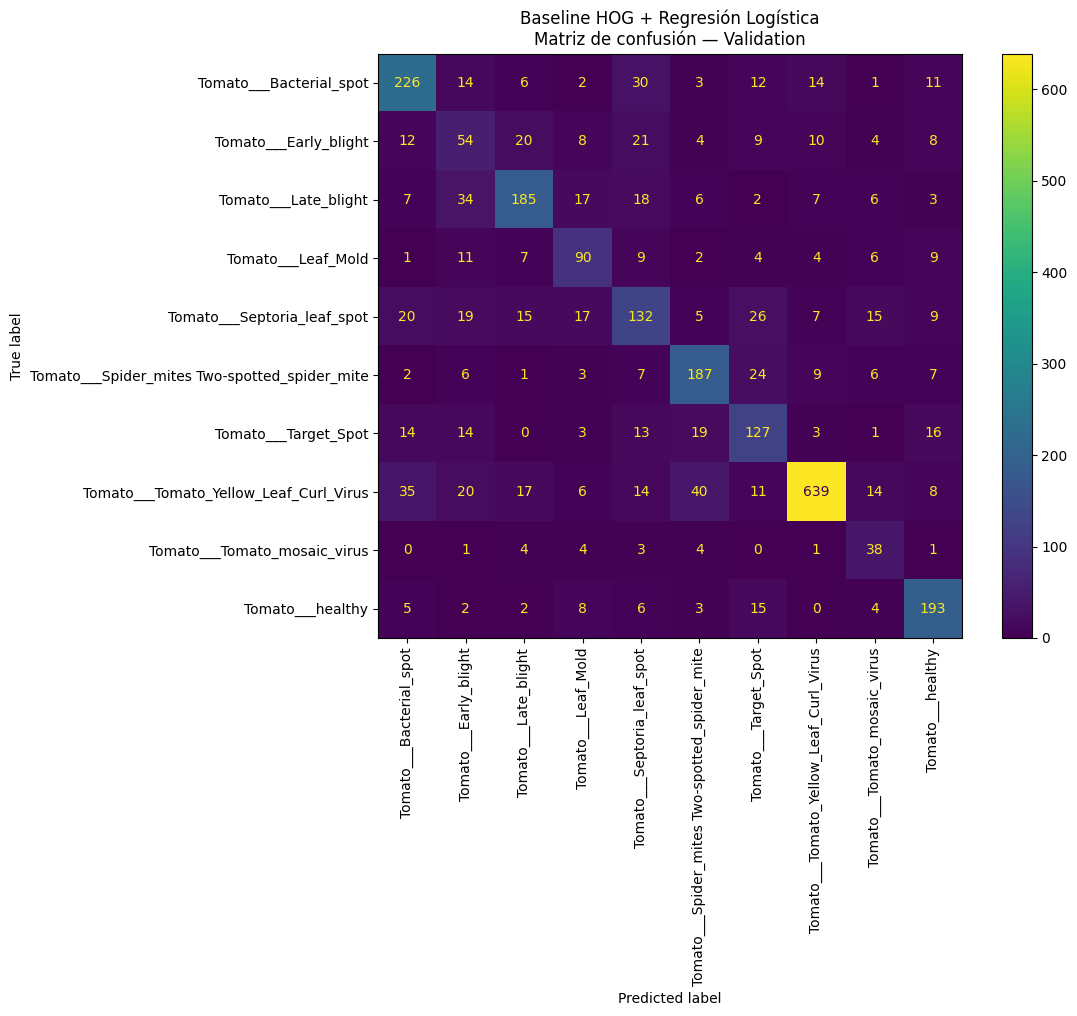


CLASES ORDENADAS POR RECALL


,Clase,Recall,Precision,F1-score,Support
0,Tomato___Early_blight,0.3600,0.3086,0.3323,150
1,Tomato___Septoria_leaf_spot,0.4981,0.5217,0.5097,265
2,Tomato___Target_Spot,0.6048,0.5522,0.5773,210
3,Tomato___Leaf_Mold,0.6294,0.5696,0.5980,143
4,Tomato___Late_blight,0.6491,0.7198,0.6827,285
5,Tomato___Tomato_mosaic_virus,0.6786,0.4000,0.5033,56
6,Tomato___Bacterial_spot,0.7085,0.7019,0.7051,319
7,Tomato___Spider_mites Two-spotted_spider_mite,0.7421,0.6850,0.7124,252
8,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.7948,0.9207,0.8531,804
9,Tomato___healthy,0.8109,0.7283,0.7674,238



MODELO GUARDADO

/content/plantvillage/modelos/baseline_hog_logistic_regression.joblib

FASE 8 FINALIZADA

✅ Baseline convencional entrenado.
✅ HOG utilizado como representación visual manual.
✅ Regresión logística utilizada como clasificador.
✅ Desbalance considerado mediante class_weight='balanced'.
✅ Evaluación realizada exclusivamente sobre Validation.
✅ Test permanece reservado para la evaluación final.

La comparación posterior será:
Baseline  ->  MLP  ->  CNN


In [88]:
# ============================================================
# FASE 8 — BASELINE CONVENCIONAL
# HOG + REGRESIÓN LOGÍSTICA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir un modelo convencional que permita establecer un
# punto de referencia antes de entrenar:
#
#       Baseline -> MLP -> CNN
#
# El baseline utiliza:
#
#       Imagen 128x128 RGB normalizada
#                    ↓
#                   HOG
#                    ↓
#          Regresión Logística
#                    ↓
#               Predicción
#
# IMPORTANTE:
#
# - Se utiliza Train para entrenar.
# - Se utiliza Validation para evaluar esta fase.
# - Test NO se utiliza todavía.
# - NO se utiliza Data Augmentation para el baseline.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from skimage.feature import hog

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

np.random.seed(
    SEED
)


# ============================================================
# 3. VERIFICAR VARIABLES DE LA FASE 7
# ============================================================

variables_requeridas = [
    "train_ds_norm",
    "val_ds_norm",
    "class_names",
    "NUM_CLASSES"
]


variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]


if variables_faltantes:

    raise NameError(
        "No se encontraron las siguientes variables "
        "de la Fase 7:\n"
        f"{variables_faltantes}\n\n"
        "Ejecute previamente la Fase 7."
    )


print("=" * 90)
print("FASE 8 — BASELINE CONVENCIONAL")
print("=" * 90)

print(
    "\nModelo:"
)

print(
    "HOG + Regresión Logística"
)

print(
    f"\nNúmero de clases: {NUM_CLASSES}"
)

print(
    "\n✅ Se utilizará Train para entrenamiento."
)

print(
    "✅ Validation para evaluación preliminar."
)

print(
    "✅ Test permanecerá aislado."
)

print(
    "✅ Data Augmentation NO se utilizará "
    "en el baseline."
)


# ============================================================
# 4. CONFIGURACIÓN DE HOG
# ============================================================
#
# orientations = 9
# ----------------
# Número de orientaciones utilizadas para describir
# los gradientes.
#
# pixels_per_cell = (16,16)
# -------------------------
# Divide la imagen de 128x128 en celdas locales.
#
# cells_per_block = (2,2)
# ------------------------
# Normaliza grupos de celdas vecinas.
#
# block_norm = "L2-Hys"
# ---------------------
# Normalización estándar utilizada por HOG.
#
# channel_axis = -1
# -----------------
# Indica que el último eje corresponde a RGB.
# ============================================================

HOG_CONFIG = {
    "orientations": 9,
    "pixels_per_cell": (16, 16),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys"
}


print("\n" + "=" * 90)
print("CONFIGURACIÓN HOG")
print("=" * 90)

for parametro, valor in HOG_CONFIG.items():

    print(
        f"{parametro:<20}: {valor}"
    )


# ============================================================
# 5. FUNCIÓN PARA EXTRAER CARACTERÍSTICAS HOG
# ============================================================
#
# La extracción se realiza batch por batch para evitar cargar
# simultáneamente todas las imágenes RGB en memoria.
#
# Resultado:
#
#       X_hog -> matriz de características
#       y     -> vector de etiquetas
# ============================================================

def extraer_hog_dataset(
    dataset,
    nombre_dataset
):
    """
    Extrae características HOG de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset con imágenes normalizadas en [0,1].

    nombre_dataset : str
        Nombre utilizado en mensajes y barra de progreso.

    Retorna
    -------
    X : np.ndarray
        Matriz de características HOG.

    y : np.ndarray
        Vector de etiquetas enteras.
    """

    caracteristicas = []
    etiquetas = []


    # --------------------------------------------------------
    # Obtener número de batches cuando TensorFlow lo permite
    # --------------------------------------------------------

    cardinalidad = (
        dataset.cardinality().numpy()
    )

    if cardinalidad < 0:

        cardinalidad = None


    # --------------------------------------------------------
    # Procesar batch por batch
    # --------------------------------------------------------

    for imagenes_batch, etiquetas_batch in tqdm(
        dataset,
        total=cardinalidad,
        desc=f"HOG - {nombre_dataset}"
    ):

        # TensorFlow -> NumPy
        imagenes_np = (
            imagenes_batch.numpy()
        )

        etiquetas_np = (
            etiquetas_batch.numpy()
        )


        # ----------------------------------------------------
        # Extraer HOG para cada imagen
        # ----------------------------------------------------

        for imagen in imagenes_np:

            descriptor = hog(
                imagen,

                orientations=
                    HOG_CONFIG["orientations"],

                pixels_per_cell=
                    HOG_CONFIG["pixels_per_cell"],

                cells_per_block=
                    HOG_CONFIG["cells_per_block"],

                block_norm=
                    HOG_CONFIG["block_norm"],

                channel_axis=-1,

                feature_vector=True
            )


            caracteristicas.append(
                descriptor.astype(
                    np.float32
                )
            )


        etiquetas.extend(
            etiquetas_np.astype(
                np.int32
            )
        )


    # --------------------------------------------------------
    # Convertir listas a matrices NumPy
    # --------------------------------------------------------

    X = np.asarray(
        caracteristicas,
        dtype=np.float32
    )

    y = np.asarray(
        etiquetas,
        dtype=np.int32
    )


    return X, y


# ============================================================
# 6. EXTRAER HOG DE TRAIN
# ============================================================

print("\n" + "=" * 90)
print("EXTRACCIÓN DE CARACTERÍSTICAS")
print("=" * 90)


inicio_hog_train = time.time()


X_train_hog, y_train_baseline = (
    extraer_hog_dataset(
        train_ds_norm,
        "Train"
    )
)


tiempo_hog_train = (
    time.time()
    -
    inicio_hog_train
)


# ============================================================
# 7. EXTRAER HOG DE VALIDATION
# ============================================================

inicio_hog_val = time.time()


X_val_hog, y_val_baseline = (
    extraer_hog_dataset(
        val_ds_norm,
        "Validation"
    )
)


tiempo_hog_val = (
    time.time()
    -
    inicio_hog_val
)


# ============================================================
# 8. VERIFICACIONES DE INTEGRIDAD
# ============================================================

assert (
    X_train_hog.shape[0]
    ==
    y_train_baseline.shape[0]
), (
    "Train: número de características y etiquetas "
    "no coincide."
)


assert (
    X_val_hog.shape[0]
    ==
    y_val_baseline.shape[0]
), (
    "Validation: número de características y etiquetas "
    "no coincide."
)


assert (
    len(np.unique(y_train_baseline))
    ==
    NUM_CLASSES
), (
    "Train no contiene las 10 clases esperadas."
)


assert (
    len(np.unique(y_val_baseline))
    ==
    NUM_CLASSES
), (
    "Validation no contiene las 10 clases esperadas."
)


print("\n" + "=" * 90)
print("DIMENSIONES HOG")
print("=" * 90)

print(
    f"\nX_train_hog : "
    f"{X_train_hog.shape}"
)

print(
    f"y_train     : "
    f"{y_train_baseline.shape}"
)

print(
    f"\nX_val_hog   : "
    f"{X_val_hog.shape}"
)

print(
    f"y_val       : "
    f"{y_val_baseline.shape}"
)

print(
    f"\nCaracterísticas HOG por imagen: "
    f"{X_train_hog.shape[1]:,}"
)


print(
    f"\nTiempo HOG Train      : "
    f"{tiempo_hog_train:.2f} s"
)

print(
    f"Tiempo HOG Validation : "
    f"{tiempo_hog_val:.2f} s"
)


# ============================================================
# 9. DEFINIR EL MODELO BASELINE
# ============================================================
#
# Regresión logística multinomial.
#
# class_weight="balanced"
# -----------------------
# Compensa parcialmente el desbalance observado entre clases.
#
# C=1.0
# -----
# Fuerza de regularización estándar.
#
# max_iter=500
# ------------
# Número máximo de iteraciones.
#
# solver="lbfgs"
# --------------
# Solver adecuado para problemas multiclase de tamaño
# moderado.
# ============================================================

baseline_model = LogisticRegression(
    C=1.0,

    solver="lbfgs",

    max_iter=500,

    class_weight="balanced",

    random_state=SEED
)


print("\n" + "=" * 90)
print("ENTRENAMIENTO DEL BASELINE")
print("=" * 90)


# ============================================================
# 10. ENTRENAR
# ============================================================

inicio_entrenamiento = time.time()


with warnings.catch_warnings():

    warnings.simplefilter(
        "always"
    )

    baseline_model.fit(
        X_train_hog,
        y_train_baseline
    )


tiempo_entrenamiento_baseline = (
    time.time()
    -
    inicio_entrenamiento
)


print(
    "\n✅ Entrenamiento finalizado."
)

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_baseline:.2f} s"
)


# ============================================================
# 11. PREDICCIONES SOBRE VALIDATION
# ============================================================
#
# IMPORTANTE:
#
# NO se realizan predicciones sobre Test en esta fase.
# ============================================================

inicio_prediccion = time.time()


y_val_pred_baseline = (
    baseline_model.predict(
        X_val_hog
    )
)


y_val_prob_baseline = (
    baseline_model.predict_proba(
        X_val_hog
    )
)


tiempo_prediccion_baseline = (
    time.time()
    -
    inicio_prediccion
)


# ============================================================
# 12. CALCULAR MÉTRICAS
# ============================================================

baseline_accuracy = accuracy_score(
    y_val_baseline,
    y_val_pred_baseline
)


baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_val_baseline,
        y_val_pred_baseline
    )
)


baseline_precision_macro = (
    precision_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


baseline_recall_macro = (
    recall_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


baseline_f1_macro = (
    f1_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


# ============================================================
# 13. TABLA RESUMEN DE MÉTRICAS
# ============================================================

df_metricas_baseline = pd.DataFrame(
    {
        "Modelo": [
            "HOG + Regresión Logística"
        ],

        "Accuracy": [
            baseline_accuracy
        ],

        "Balanced Accuracy": [
            baseline_balanced_accuracy
        ],

        "Precision Macro": [
            baseline_precision_macro
        ],

        "Recall Macro": [
            baseline_recall_macro
        ],

        "F1 Macro": [
            baseline_f1_macro
        ],

        "Tiempo entrenamiento (s)": [
            tiempo_entrenamiento_baseline
        ],

        "Tiempo inferencia val (s)": [
            tiempo_prediccion_baseline
        ]
    }
)


print("\n" + "=" * 90)
print("RESULTADOS DEL BASELINE — VALIDATION")
print("=" * 90)

display(
    df_metricas_baseline.round(4)
)


# ============================================================
# 14. REPORTE DETALLADO POR CLASE
# ============================================================

reporte_baseline = classification_report(
    y_val_baseline,
    y_val_pred_baseline,

    target_names=class_names,

    output_dict=True,

    zero_division=0
)


df_reporte_baseline = (
    pd.DataFrame(
        reporte_baseline
    )
    .transpose()
)


print("\n" + "=" * 90)
print("REPORTE POR CLASE")
print("=" * 90)

display(
    df_reporte_baseline.round(4)
)


# ============================================================
# 15. MATRIZ DE CONFUSIÓN
# ============================================================

cm_baseline = confusion_matrix(
    y_val_baseline,
    y_val_pred_baseline
)


fig, ax = plt.subplots(
    figsize=(12, 10)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=class_names
)


disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)


ax.set_title(
    "Baseline HOG + Regresión Logística\n"
    "Matriz de confusión — Validation"
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. ANALIZAR RECALL POR CLASE
# ============================================================
#
# Debido al desbalance, resulta especialmente útil observar
# qué clases presentan menor Recall.
# ============================================================

recall_por_clase = []


for clase in class_names:

    recall_por_clase.append(
        {
            "Clase": clase,

            "Recall": (
                reporte_baseline[
                    clase
                ][
                    "recall"
                ]
            ),

            "Precision": (
                reporte_baseline[
                    clase
                ][
                    "precision"
                ]
            ),

            "F1-score": (
                reporte_baseline[
                    clase
                ][
                    "f1-score"
                ]
            ),

            "Support": int(
                reporte_baseline[
                    clase
                ][
                    "support"
                ]
            )
        }
    )


df_metricas_clase_baseline = (
    pd.DataFrame(
        recall_por_clase
    )
    .sort_values(
        "Recall",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 90)
print("CLASES ORDENADAS POR RECALL")
print("=" * 90)

display(
    df_metricas_clase_baseline.round(4)
)


# ============================================================
# 17. GUARDAR RESULTADOS PARA COMPARACIÓN FUTURA
# ============================================================
#
# Este diccionario podrá reutilizarse posteriormente para:
#
#       Baseline vs MLP vs CNN
# ============================================================

resultados_baseline = {
    "Modelo":
        "HOG + Regresión Logística",

    "Accuracy":
        baseline_accuracy,

    "Balanced Accuracy":
        baseline_balanced_accuracy,

    "Precision Macro":
        baseline_precision_macro,

    "Recall Macro":
        baseline_recall_macro,

    "F1 Macro":
        baseline_f1_macro,

    "Tiempo entrenamiento (s)":
        tiempo_entrenamiento_baseline,

    "Tiempo inferencia validation (s)":
        tiempo_prediccion_baseline,

    "N características":
        X_train_hog.shape[1]
}


# ============================================================
# 18. GUARDAR MODELO
# ============================================================
#
# Guardar el modelo permite reproducir posteriormente la
# evaluación final sin volver a entrenarlo.
# ============================================================

BASELINE_DIR = Path(
    "/content/plantvillage/modelos"
)


BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_MODELO_BASELINE = (
    BASELINE_DIR
    /
    "baseline_hog_logistic_regression.joblib"
)


joblib.dump(
    baseline_model,
    RUTA_MODELO_BASELINE
)


print("\n" + "=" * 90)
print("MODELO GUARDADO")
print("=" * 90)

print(
    f"\n{RUTA_MODELO_BASELINE}"
)


# ============================================================
# 19. CONCLUSIÓN OPERACIONAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 8 FINALIZADA")
print("=" * 90)

print(
    "\n✅ Baseline convencional entrenado."
)

print(
    "✅ HOG utilizado como representación visual manual."
)

print(
    "✅ Regresión logística utilizada como clasificador."
)

print(
    "✅ Desbalance considerado mediante "
    "class_weight='balanced'."
)

print(
    "✅ Evaluación realizada exclusivamente sobre Validation."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nLa comparación posterior será:"
)

print(
    "Baseline  ->  MLP  ->  CNN"
)

# Fase 9 - Modelo A: MLP
La MLP será la primera familia de red y trabajará sobre una representación vectorizada de las imágenes.

## 9.1 Entrada de la MLP: imágenes redimensionadas y normalizadas

La entrada de la red neuronal multicapa corresponde a las imágenes del conjunto
**PlantVillage**, restringido a las diez clases de hojas de tomate. Estas imágenes
ya fueron auditadas, depuradas y divididas mediante una partición estratificada en:

- **Entrenamiento:** 12.702 imágenes.
- **Validación:** 2.722 imágenes.
- **Prueba:** 2.722 imágenes.
- **Total:** 18.146 imágenes únicas y válidas.

Las imágenes originales poseen una resolución de:

$\[
256 \times 256 \times 3
\]$

donde el valor \(3\) representa los tres canales del espacio de color RGB. Para
reducir el costo computacional y permitir el entrenamiento en Google Colab, las
imágenes fueron redimensionadas a:

$\[
H \times W \times C = 128 \times 128 \times 3
\]$

Por lo tanto, cada imagen de entrada puede representarse mediante un tensor:

$\[
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
\]$

donde:

- $\(H=128\)$ corresponde a la altura.
- $\(W=128\)$ corresponde al ancho.
- $\(C=3\)$ corresponde a los canales rojo, verde y azul.
- $\(i\)$ identifica una imagen del dataset.

### Normalización de los píxeles

Antes de ingresar al modelo, los valores originales de los píxeles, almacenados
en el intervalo $\([0,255]\)$, se transforman al intervalo $\([0,1]\)$. La
normalización se define como:

$\[
x'_{h,w,c}
=
\frac{x_{h,w,c}}{255}
\]$

donde:

- $\(x_{h,w,c}\)$ es el valor original del píxel ubicado en la fila $\(h\)$, columna
  $\(w\)$ y canal $\(c\)$.
- $\(x'_{h,w,c}\)$ es el valor normalizado.
- $\(255\)$ es el valor máximo representable en una imagen RGB de 8 bits.

Como resultado:

$\[
x_{h,w,c}\in[0,255]
\quad\Longrightarrow\quad
x'_{h,w,c}\in[0,1]
\]$

La normalización evita que la red trabaje con valores numéricos excesivamente
grandes y facilita la optimización mediante descenso de gradiente. Además,
mantiene una escala homogénea para todos los píxeles.

### Representación por lotes

Las imágenes se procesan en lotes de 32 observaciones. Por tanto, cada lote
utilizado por la red posee la forma:

$\[
\mathbf{X}_{\mathrm{batch}}
\in
\mathbb{R}^{32 \times 128 \times 128 \times 3}
\]$

Las etiquetas del mismo lote presentan la forma:

$\[
\mathbf{y}_{\mathrm{batch}}
\in
\{0,1,\ldots,9\}^{32}
\]$

Cada valor de $\(\mathbf{y}_{\mathrm{batch}}\)$ es un número entero que identifica
una de las diez clases sanitarias del tomate.

### Entrada específica de la MLP

Aunque las imágenes se conservan inicialmente como tensores tridimensionales, una
MLP recibe vectores. Por ello, la primera operación de la arquitectura será una
capa `Flatten`, encargada de transformar cada imagen de:

$\[
128 \times 128 \times 3
\]$

en un vector de:

$\[
D=128\cdot128\cdot3=49.152
\]$

características. Matemáticamente:

$\[
\operatorname{Flatten}:
\mathbb{R}^{128\times128\times3}
\longrightarrow
\mathbb{R}^{49.152}
\]$

Por consiguiente, un lote se transformará de:

$\[
(32,128,128,3)
\]$

a:

$\[
(32,49.152)
\]$

Esta transformación no elimina los valores de los píxeles, pero deja de
representar explícitamente su organización bidimensional. La MLP deberá aprender
las relaciones entre las 49.152 entradas mediante capas densamente conectadas.

Esta limitación constituye precisamente una de las hipótesis del experimento:
se espera que la CNN pueda aprovechar mejor la localidad espacial mediante
convoluciones, mientras que la MLP operará sobre una representación vectorizada.

### Tratamiento de cada partición

El pipeline conserva una separación metodológica estricta:

| Conjunto | Redimensionamiento | Normalización | Data augmentation |
|---|:---:|:---:|:---:|
| Train | Sí | Sí | Sí |
| Validation | Sí | Sí | No |
| Test | Sí | Sí | No |

El `data augmentation` se aplica exclusivamente a entrenamiento. Los conjuntos
de validación y prueba permanecen sin transformaciones aleatorias, de modo que
la evaluación se realice siempre sobre imágenes estables.

En esta fase se reutilizan directamente los objetos creados anteriormente:

- `train_ds_norm`: entrenamiento redimensionado y normalizado.
- `val_ds_norm`: validación redimensionada y normalizada.
- `test_ds_norm`: prueba redimensionada y normalizada.
- `train_ds_final`: entrenamiento con normalización y data augmentation.
- `val_ds_final`: validación normalizada y sin augmentation.
- `test_ds_final`: prueba normalizada y sin augmentation.

No se realiza una nueva división ni se vuelve a cargar el dataset. Esto garantiza
que la MLP y la CNN trabajen posteriormente con las mismas observaciones y bajo
el mismo protocolo experimental.

FASE 9.1 — ENTRADA REDIMENSIONADA Y NORMALIZADA
Resolución esperada : (128, 128, 3)
Batch size          : 32
Número de clases    : 10
Entradas tras Flatten: 49,152

✅ Todos los objetos requeridos están disponibles.

CLASES UTILIZADAS
00 -> Tomato___Bacterial_spot
01 -> Tomato___Early_blight
02 -> Tomato___Late_blight
03 -> Tomato___Leaf_Mold
04 -> Tomato___Septoria_leaf_spot
05 -> Tomato___Spider_mites Two-spotted_spider_mite
06 -> Tomato___Target_Spot
07 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
08 -> Tomato___Tomato_mosaic_virus
09 -> Tomato___healthy

AUDITORÍA DE LA ENTRADA


,Conjunto,Forma del lote,Forma por imagen,Tipo imágenes,Tipo etiquetas,Mínimo,Máximo,Media,Desviación estándar,Etiqueta mínima,Etiqueta máxima
0,Train,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.950980,0.432272,0.167281,0,9
1,Validation,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.988235,0.401450,0.149319,0,0
2,Test,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.970588,0.395585,0.154653,0,0



DEMOSTRACIÓN DE FLATTEN
Forma antes de Flatten  : (32, 128, 128, 3)
Forma después de Flatten: (32, 49152)
Características por imagen: 49,152

✅ Flatten transforma correctamente cada imagen en un vector de 49,152 valores.


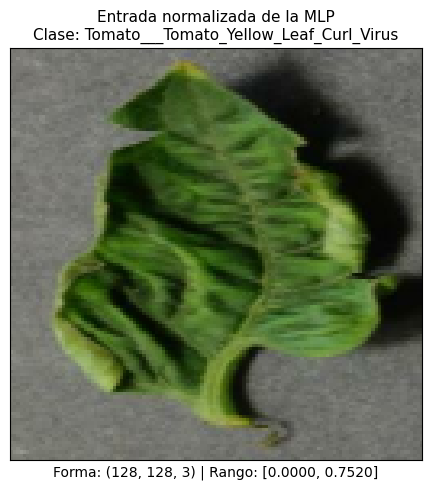


FASE 9.1 FINALIZADA
✅ Cada imagen posee forma 128 × 128 × 3.
✅ Los píxeles se encuentran normalizados en el intervalo [0, 1].
✅ Las etiquetas corresponden a enteros entre 0 y 9.
✅ Flatten producirá 49,152 características por imagen.
✅ Train, Validation y Test conservan la misma estructura de entrada.
✅ No se ha utilizado Test para entrenar ni seleccionar el modelo.

La entrada está preparada para construir la arquitectura MLP.


In [89]:
# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.1 VERIFICACIÓN DE LA ENTRADA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar que las imágenes preparadas en la Fase 7:
#
# 1. Posean una resolución de 128 x 128 píxeles.
# 2. Contengan tres canales RGB.
# 3. Se encuentren normalizadas en el intervalo [0, 1].
# 4. Utilicen etiquetas enteras compatibles con una tarea
#    de clasificación multiclase.
# 5. Puedan transformarse en vectores mediante Flatten.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda NO:
#
# - vuelve a descargar el dataset;
# - vuelve a dividir los datos;
# - ajusta transformaciones usando validation o test;
# - entrena todavía la MLP.
#
# Se reutilizan directamente los datasets construidos en
# la Fase 7.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. CONFIGURACIÓN ESPERADA
# ============================================================

SEED = 42

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 32
NUM_CLASSES_EXPECTED = 10

# Forma que recibirá la futura capa de entrada de la MLP.
INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

# Cantidad de características después de aplicar Flatten.
N_FEATURES_FLATTEN = (
    IMAGE_HEIGHT
    * IMAGE_WIDTH
    * CHANNELS
)

tf.keras.utils.set_random_seed(SEED)


print("=" * 80)
print("FASE 9.1 — ENTRADA REDIMENSIONADA Y NORMALIZADA")
print("=" * 80)

print(f"Resolución esperada : {INPUT_SHAPE_MLP}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Número de clases    : {NUM_CLASSES_EXPECTED}")
print(f"Entradas tras Flatten: {N_FEATURES_FLATTEN:,}")


# ============================================================
# 3. VERIFICAR OBJETOS CREADOS EN LA FASE 7
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos de la Fase 7: "
        f"{objetos_faltantes}. Ejecute previamente la Fase 7."
    )

print("\n✅ Todos los objetos requeridos están disponibles.")


# ============================================================
# 4. VERIFICAR EL NÚMERO Y ORDEN DE LAS CLASES
# ============================================================

assert NUM_CLASSES == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {NUM_CLASSES}."
)

assert len(class_names) == NUM_CLASSES, (
    "El número de nombres de clase no coincide con "
    "la variable NUM_CLASSES."
)

print("\n" + "=" * 80)
print("CLASES UTILIZADAS")
print("=" * 80)

for indice, nombre_clase in enumerate(class_names):
    print(f"{indice:02d} -> {nombre_clase}")


# ============================================================
# 5. FUNCIÓN PARA AUDITAR UN DATASET NORMALIZADO
# ============================================================

def auditar_dataset_entrada(
    dataset,
    nombre,
    input_shape_esperado,
    numero_clases
):
    """
    Inspecciona el primer lote de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset que contiene lotes de imágenes y etiquetas.

    nombre : str
        Nombre utilizado para identificar el conjunto.

    input_shape_esperado : tuple
        Forma esperada para una imagen individual:
        (altura, ancho, canales).

    numero_clases : int
        Cantidad total de categorías del problema.

    Retorna
    -------
    dict
        Resumen de forma, tipo y rango de valores.
    """

    # Tomar solamente un lote para realizar la auditoría.
    imagenes, etiquetas = next(iter(dataset.take(1)))

    # Forma dinámica real del lote.
    forma_lote = tuple(imagenes.shape)

    # Forma de una imagen individual.
    forma_imagen = tuple(imagenes.shape[1:])

    # Estadísticos del lote.
    valor_minimo = float(
        tf.reduce_min(imagenes).numpy()
    )

    valor_maximo = float(
        tf.reduce_max(imagenes).numpy()
    )

    valor_promedio = float(
        tf.reduce_mean(imagenes).numpy()
    )

    desviacion = float(
        tf.math.reduce_std(imagenes).numpy()
    )

    etiqueta_minima = int(
        tf.reduce_min(etiquetas).numpy()
    )

    etiqueta_maxima = int(
        tf.reduce_max(etiquetas).numpy()
    )

    # --------------------------------------------------------
    # VALIDACIONES
    # --------------------------------------------------------

    assert forma_imagen == input_shape_esperado, (
        f"{nombre}: se esperaba una imagen con forma "
        f"{input_shape_esperado}, pero se obtuvo {forma_imagen}."
    )

    assert imagenes.dtype == tf.float32, (
        f"{nombre}: las imágenes deberían ser float32, "
        f"pero son {imagenes.dtype}."
    )

    assert valor_minimo >= -1e-6, (
        f"{nombre}: se encontraron valores menores que cero."
    )

    assert valor_maximo <= 1.0 + 1e-6, (
        f"{nombre}: se encontraron valores superiores a uno."
    )

    assert etiquetas.dtype in (
        tf.int32,
        tf.int64
    ), (
        f"{nombre}: las etiquetas deberían ser enteras, "
        f"pero son {etiquetas.dtype}."
    )

    assert etiqueta_minima >= 0, (
        f"{nombre}: existe una etiqueta negativa."
    )

    assert etiqueta_maxima < numero_clases, (
        f"{nombre}: existe una etiqueta fuera del intervalo "
        f"[0, {numero_clases - 1}]."
    )

    return {
        "Conjunto": nombre,
        "Forma del lote": str(forma_lote),
        "Forma por imagen": str(forma_imagen),
        "Tipo imágenes": imagenes.dtype.name,
        "Tipo etiquetas": etiquetas.dtype.name,
        "Mínimo": valor_minimo,
        "Máximo": valor_maximo,
        "Media": valor_promedio,
        "Desviación estándar": desviacion,
        "Etiqueta mínima": etiqueta_minima,
        "Etiqueta máxima": etiqueta_maxima
    }


# ============================================================
# 6. AUDITORÍA DE TRAIN, VALIDATION Y TEST
# ============================================================
#
# Para verificar la normalización se utilizan los datasets
# deterministas *_ds_norm.
#
# El entrenamiento efectivo de la MLP podrá utilizar
# train_ds_final, que añade data augmentation.
# ============================================================

datasets_normalizados = {
    "Train": train_ds_norm,
    "Validation": val_ds_norm,
    "Test": test_ds_norm
}

resultados_auditoria = []

for nombre, dataset in datasets_normalizados.items():

    resultado = auditar_dataset_entrada(
        dataset=dataset,
        nombre=nombre,
        input_shape_esperado=INPUT_SHAPE_MLP,
        numero_clases=NUM_CLASSES
    )

    resultados_auditoria.append(resultado)


df_auditoria_entrada_mlp = pd.DataFrame(
    resultados_auditoria
)

print("\n" + "=" * 80)
print("AUDITORÍA DE LA ENTRADA")
print("=" * 80)

display(
    df_auditoria_entrada_mlp.round(6)
)


# ============================================================
# 7. DEMOSTRACIÓN DE LA TRANSFORMACIÓN FLATTEN
# ============================================================
#
# Flatten no modifica los valores de los píxeles.
# Solamente reorganiza cada imagen tridimensional como vector.
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(train_ds_norm.take(1))
)

flatten_demostracion = tf.keras.layers.Flatten(
    name="flatten_demostracion"
)

imagenes_vectorizadas = flatten_demostracion(
    imagenes_batch
)

forma_antes_flatten = tuple(
    imagenes_batch.shape
)

forma_despues_flatten = tuple(
    imagenes_vectorizadas.shape
)

print("\n" + "=" * 80)
print("DEMOSTRACIÓN DE FLATTEN")
print("=" * 80)

print(
    f"Forma antes de Flatten  : "
    f"{forma_antes_flatten}"
)

print(
    f"Forma después de Flatten: "
    f"{forma_despues_flatten}"
)

print(
    f"Características por imagen: "
    f"{imagenes_vectorizadas.shape[1]:,}"
)

# Verificar matemáticamente la dimensión resultante.
assert int(imagenes_vectorizadas.shape[1]) == N_FEATURES_FLATTEN, (
    "La cantidad de características generadas por Flatten "
    "no coincide con 128 × 128 × 3."
)

# Verificar que Flatten no altere el número de observaciones.
assert int(imagenes_vectorizadas.shape[0]) == int(
    imagenes_batch.shape[0]
), (
    "Flatten modificó inesperadamente el tamaño del lote."
)

print(
    "\n✅ Flatten transforma correctamente cada imagen "
    f"en un vector de {N_FEATURES_FLATTEN:,} valores."
)


# ============================================================
# 8. VISUALIZACIÓN DE UNA IMAGEN DE ENTRADA
# ============================================================

indice_imagen = 0

imagen_ejemplo = imagenes_batch[
    indice_imagen
].numpy()

etiqueta_ejemplo = int(
    etiquetas_batch[
        indice_imagen
    ].numpy()
)

nombre_clase_ejemplo = class_names[
    etiqueta_ejemplo
]

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    np.clip(
        imagen_ejemplo,
        0.0,
        1.0
    )
)

plt.title(
    "Entrada normalizada de la MLP\n"
    f"Clase: {nombre_clase_ejemplo}",
    fontsize=11
)

plt.xlabel(
    f"Forma: {imagen_ejemplo.shape} | "
    f"Rango: [{imagen_ejemplo.min():.4f}, "
    f"{imagen_ejemplo.max():.4f}]"
)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


# ============================================================
# 9. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.1 FINALIZADA")
print("=" * 80)

print(
    f"✅ Cada imagen posee forma "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "✅ Los píxeles se encuentran normalizados "
    "en el intervalo [0, 1]."
)

print(
    f"✅ Las etiquetas corresponden a enteros "
    f"entre 0 y {NUM_CLASSES - 1}."
)

print(
    f"✅ Flatten producirá "
    f"{N_FEATURES_FLATTEN:,} características por imagen."
)

print(
    "✅ Train, Validation y Test conservan "
    "la misma estructura de entrada."
)

print(
    "✅ No se ha utilizado Test para entrenar "
    "ni seleccionar el modelo."
)

print(
    "\nLa entrada está preparada para construir "
    "la arquitectura MLP."
)

## 9.2 Aplanamiento de las imágenes mediante `Flatten`

Las imágenes procesadas en la Fase 7 poseen una resolución de:

$$
H \times W \times C = 128 \times 128 \times 3
$$

donde:
- $H = 128$ corresponde a la altura.
- $W = 128$ corresponde al ancho.
- $C = 3$ representa los canales RGB.

Por tanto, cada imagen normalizada se representa mediante un tensor tridimensional:

$$
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
$$

Las redes neuronales multicapa o **MLP** operan mediante capas densamente conectadas. Una capa densa espera recibir un vector de características por cada observación y no una matriz tridimensional.

Por esta razón, antes de ingresar a las capas densas se utiliza una capa `Flatten`, cuya función es reorganizar los píxeles de cada imagen en un único vector.

---

### Transformación matemática

La operación de aplanamiento puede representarse como:

$$
\operatorname{Flatten}: \mathbb{R}^{H \times W \times C} \longrightarrow \mathbb{R}^{D}
$$

donde la dimensión del vector resultante es:

$$
D = H \cdot W \cdot C
$$

Para las imágenes utilizadas en este proyecto:

$$
\begin{aligned}
D &= 128 \cdot 128 \cdot 3 \\
&= 49.152
\end{aligned}
$$

Por consiguiente:

$$
\operatorname{Flatten}: \mathbb{R}^{128 \times 128 \times 3} \longrightarrow \mathbb{R}^{49.152}
$$

Cada imagen se transforma en un vector:

$$
\mathbf{x}_i = \begin{bmatrix} x_{i,1} & x_{i,2} & \cdots & x_{i,49.152} \end{bmatrix}^{\mathsf{T}}
$$

donde cada componente corresponde a un valor normalizado de uno de los píxeles y canales de la imagen.

---

### Transformación de un lote

El pipeline utiliza lotes de 32 imágenes. Antes del aplanamiento, un lote tiene la forma:

$$
\mathbf{X}_{\text{batch}} \in \mathbb{R}^{32 \times 128 \times 128 \times 3}
$$

Después de aplicar `Flatten`, la forma se transforma en:

$$
\mathbf{X}_{\text{flat}} \in \mathbb{R}^{32 \times 49.152}
$$

Es importante observar que la dimensión correspondiente al número de imágenes del lote no cambia:

$$
32 \times 128 \times 128 \times 3 \longrightarrow 32 \times 49.152
$$

La transformación se aplica independientemente a cada observación.

---

### ¿`Flatten` modifica los valores de los píxeles?

La capa `Flatten` no aprende parámetros y no modifica los valores numéricos de los píxeles. Solamente cambia la organización de los datos.

Por tanto:

$$
\operatorname{Flatten} \left( \mathbf{X}_i \right) = \operatorname{reshape} \left( \mathbf{X}_i \right)
$$

y se conserva la cantidad total de elementos:

$$
128 \cdot 128 \cdot 3 = 49.152
$$

En consecuencia, la suma, la media, el mínimo y el máximo de los valores de cada imagen permanecen iguales antes y después del aplanamiento.

---

### Cantidad de parámetros de `Flatten`

La capa `Flatten` no contiene pesos ni sesgos entrenables:

$$
N_{\text{parámetros de Flatten}} = 0
$$

Su función es exclusivamente estructural. Los parámetros entrenables aparecen en la capa densa posterior.

Si el vector aplanado de $49.152$ características se conecta a una capa densa con $n$ neuronas, la cantidad de parámetros de esa capa será:

$$
N_{\text{Dense}} = D \cdot n + n
$$

donde:
- $D = 49.152$ es la cantidad de entradas.
- $n$ es la cantidad de neuronas.
- $D \cdot n$ corresponde a los pesos.
- $n$ corresponde a los sesgos.

De manera equivalente:

$$
N_{\text{Dense}} = (D + 1)n
$$

Por ejemplo, para una primera capa con 128 neuronas:

$$
N_{\text{Dense}} = (49.152 + 1) \cdot 128 = 6.291.584
$$

Esto evidencia que una MLP aplicada directamente sobre imágenes puede generar una cantidad considerable de parámetros, incluso cuando la primera capa densa posee un número moderado de neuronas.

---

### Limitación espacial de `Flatten`

El aplanamiento conserva todos los valores, pero deja de representar explícitamente las relaciones espaciales entre los píxeles.

Antes del aplanamiento, un píxel puede identificarse mediante:

$$
x_{h,w,c}
$$

donde $h$, $w$ y $c$ indican su posición espacial y canal. Después del aplanamiento, el mismo valor se representa mediante una posición lineal:

$$
x_j, \quad j \in \{1, 2, \ldots, 49.152\}
$$

La MLP recibe el vector completo, pero no incorpora de manera explícita conceptos como:
- Vecindad entre píxeles.
- Patrones locales.
- Bordes.
- Texturas.
- Distribución espacial de las lesiones.
- Invariancia aproximada frente a desplazamientos.

En una capa densa, cada neurona se conecta con todas las entradas:

$$
z_j = \sum_{k=1}^{D} w_{jk}x_k + b_j
$$

y su activación puede calcularse mediante ReLU:

$$
a_j = \operatorname{ReLU}(z_j) = \max(0, z_j)
$$

La red deberá aprender las relaciones espaciales indirectamente a partir de una gran cantidad de pesos.

Esta característica constituye una parte central del experimento:

$$
\text{MLP} \longrightarrow \text{imagen aplanada} \longrightarrow \text{conexiones globales}
$$

$$
\text{CNN} \longrightarrow \text{imagen espacial} \longrightarrow \text{filtros locales y pesos compartidos}
$$

La comparación posterior permitirá determinar si conservar y explotar explícitamente la estructura espacial proporciona una ventaja de generalización para la clasificación de enfermedades foliares del tomate.

FASE 9.2 — APLANAMIENTO MEDIANTE FLATTEN
Forma de una imagen : (128, 128, 3)
Altura              : 128
Ancho               : 128
Canales             : 3
Características después de Flatten: 49,152

✅ Los datasets normalizados de la Fase 7 están disponibles.

LOTE DE ENTRADA
Forma de las imágenes: (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de las imágenes: float32
Tipo de las etiquetas: int32

✅ La forma de entrada coincide con (128, 128, 3).

TRANSFORMACIÓN REALIZADA POR FLATTEN
Antes   : (32, 128, 128, 3)
Después : (32, 49152)

Transformación por imagen:
(128, 128, 3) → (49,152,)

✅ El número de imágenes del lote se conserva.
✅ Cada imagen genera exactamente 49,152 características.

CONSERVACIÓN DE LOS VALORES
Diferencia máxima después de reconstruir: 0.0000000000
✅ Flatten no modifica los valores de los píxeles.

ESTADÍSTICOS ANTES Y DESPUÉS


,Estadístico,Antes de Flatten,Después de Flatten
0,Valor mínimo,0.000000e+00,0.000000e+00
1,Valor máximo,9.470589e-01,9.470589e-01
2,Media,4.441810e-01,4.441810e-01
3,Desviación estándar,1.849277e-01,1.849277e-01
4,Número total de elementos,1.572864e+06,1.572864e+06



PARÁMETROS DE LA CAPA FLATTEN
Parámetros totales    : 0
Variables entrenables : 0
Variables no entrenables: 0

✅ Flatten es una transformación sin parámetros.

RESUMEN DE LA TRANSFORMACIÓN


Model: "demostracion_flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aplanamiento (Flatten)          │ (None, 49152)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


IMPACTO SOBRE LA PRIMERA CAPA DENSA


,Neuronas Dense,Pesos,Sesgos,Parámetros totales
0,64,"3,145,728",64,"3,145,792"
1,128,"6,291,456",128,"6,291,584"
2,256,"12,582,912",256,"12,583,168"


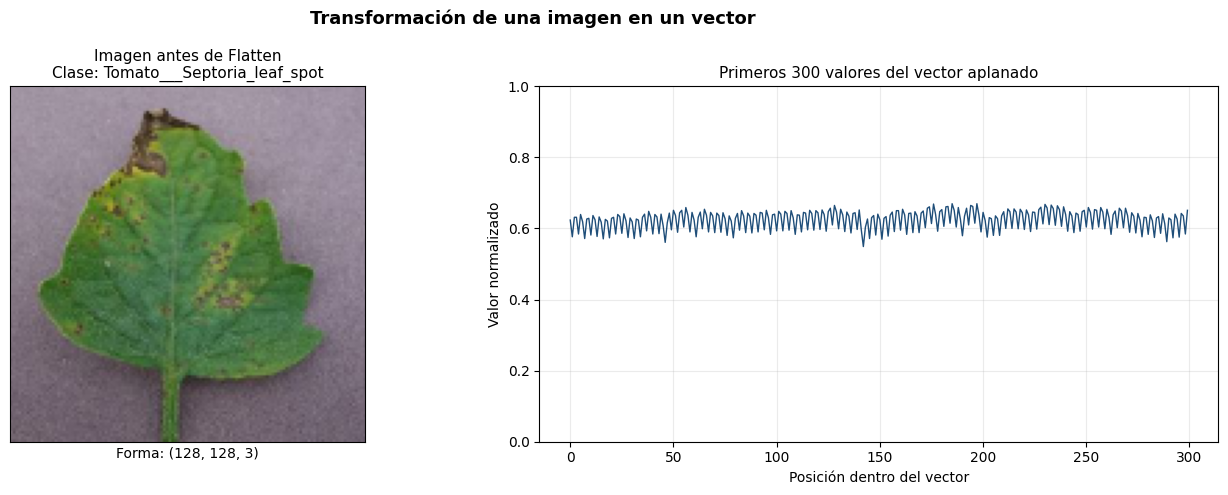


FASE 9.2 FINALIZADA
✅ Entrada por imagen: 128 × 128 × 3.
✅ Salida por imagen: 49,152 características.
✅ El tamaño del batch permanece sin cambios.
✅ Los valores normalizados de los píxeles se conservan.
✅ La capa Flatten contiene cero parámetros entrenables.
⚠️ La organización espacial deja de estar representada explícitamente.

Las imágenes están preparadas para ingresar a la primera capa Dense de la MLP.


In [90]:
# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.2 APLANAMIENTO DE LAS IMÁGENES MEDIANTE FLATTEN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar cómo la capa Flatten transforma cada imagen
# normalizada de 128 x 128 x 3 en un vector de 49.152
# características.
#
# En esta celda se comprobará que:
#
# 1. La forma de entrada es (batch, 128, 128, 3).
# 2. La forma de salida es (batch, 49.152).
# 3. El número de imágenes del lote no cambia.
# 4. La cantidad total de valores por imagen se conserva.
# 5. Los valores numéricos no son modificados.
# 6. Flatten no contiene parámetros entrenables.
#
# Esta celda NO entrena todavía la MLP.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

# Número esperado de características después de Flatten.
N_FEATURES_FLATTEN = int(
    np.prod(
        INPUT_SHAPE_MLP
    )
)

print("=" * 80)
print("FASE 9.2 — APLANAMIENTO MEDIANTE FLATTEN")
print("=" * 80)

print(f"Forma de una imagen : {INPUT_SHAPE_MLP}")
print(f"Altura              : {IMAGE_HEIGHT}")
print(f"Ancho               : {IMAGE_WIDTH}")
print(f"Canales             : {CHANNELS}")
print(
    "Características después de Flatten: "
    f"{N_FEATURES_FLATTEN:,}"
)


# ============================================================
# 3. VERIFICAR LOS OBJETOS DE LA FASE 7
# ============================================================
#
# Para demostrar Flatten se utiliza train_ds_norm porque:
#
# - contiene imágenes redimensionadas;
# - contiene imágenes normalizadas;
# - no incorpora una transformación aleatoria durante la
#   inspección;
# - permite reproducir exactamente la comprobación.
#
# Durante el entrenamiento posterior podrá utilizarse
# train_ds_final, que incluye data augmentation.
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    nombre
    for nombre in objetos_requeridos
    if nombre not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print(
    "\n✅ Los datasets normalizados de la Fase 7 "
    "están disponibles."
)


# ============================================================
# 4. EXTRAER UN LOTE DE ENTRENAMIENTO
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_norm.take(1)
    )
)

print("\n" + "=" * 80)
print("LOTE DE ENTRADA")
print("=" * 80)

print(
    f"Forma de las imágenes: "
    f"{tuple(imagenes_batch.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch.shape)}"
)

print(
    f"Tipo de las imágenes: "
    f"{imagenes_batch.dtype.name}"
)

print(
    f"Tipo de las etiquetas: "
    f"{etiquetas_batch.dtype.name}"
)


# ============================================================
# 5. VALIDAR LA FORMA DE ENTRADA
# ============================================================

forma_imagen_observada = tuple(
    imagenes_batch.shape[1:]
)

assert forma_imagen_observada == INPUT_SHAPE_MLP, (
    "La forma observada de las imágenes no coincide con "
    f"{INPUT_SHAPE_MLP}. Se obtuvo "
    f"{forma_imagen_observada}."
)

assert imagenes_batch.dtype == tf.float32, (
    "Las imágenes deberían estar representadas como float32."
)

print(
    "\n✅ La forma de entrada coincide con "
    f"{INPUT_SHAPE_MLP}."
)


# ============================================================
# 6. CREAR LA CAPA FLATTEN
# ============================================================
#
# Flatten reorganiza las dimensiones espaciales y de canales
# en una única dimensión.
#
# No contiene pesos, sesgos ni parámetros entrenables.
# ============================================================

flatten_layer = tf.keras.layers.Flatten(
    name="flatten_mlp"
)

imagenes_flatten = flatten_layer(
    imagenes_batch
)


# ============================================================
# 7. COMPARAR LAS FORMAS ANTES Y DESPUÉS
# ============================================================

forma_antes = tuple(
    imagenes_batch.shape
)

forma_despues = tuple(
    imagenes_flatten.shape
)

batch_antes = int(
    imagenes_batch.shape[0]
)

batch_despues = int(
    imagenes_flatten.shape[0]
)

features_observadas = int(
    imagenes_flatten.shape[1]
)

print("\n" + "=" * 80)
print("TRANSFORMACIÓN REALIZADA POR FLATTEN")
print("=" * 80)

print(f"Antes   : {forma_antes}")
print(f"Después : {forma_despues}")

print(
    "\nTransformación por imagen:"
)

print(
    f"({IMAGE_HEIGHT}, {IMAGE_WIDTH}, {CHANNELS}) "
    f"→ ({features_observadas:,},)"
)


# ============================================================
# 8. VALIDAR LA DIMENSIÓN RESULTANTE
# ============================================================

assert batch_antes == batch_despues, (
    "Flatten modificó inesperadamente el número de imágenes "
    "del lote."
)

assert features_observadas == N_FEATURES_FLATTEN, (
    "La cantidad de características obtenida no coincide con "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "\n✅ El número de imágenes del lote se conserva."
)

print(
    "✅ Cada imagen genera exactamente "
    f"{N_FEATURES_FLATTEN:,} características."
)


# ============================================================
# 9. COMPROBAR LA CONSERVACIÓN DE LOS VALORES
# ============================================================
#
# Para demostrar que Flatten solamente reorganiza los datos,
# se reconstruye la forma original mediante tf.reshape.
#
# Si la reconstrucción coincide con el tensor original,
# entonces ningún valor fue modificado.
# ============================================================

imagenes_reconstruidas = tf.reshape(
    imagenes_flatten,
    shape=tf.shape(
        imagenes_batch
    )
)

diferencia_maxima = float(
    tf.reduce_max(
        tf.abs(
            imagenes_batch
            -
            imagenes_reconstruidas
        )
    ).numpy()
)

assert np.isclose(
    diferencia_maxima,
    0.0,
    atol=1e-7
), (
    "Se detectaron diferencias entre las imágenes originales "
    "y las reconstruidas."
)

print("\n" + "=" * 80)
print("CONSERVACIÓN DE LOS VALORES")
print("=" * 80)

print(
    f"Diferencia máxima después de reconstruir: "
    f"{diferencia_maxima:.10f}"
)

print(
    "✅ Flatten no modifica los valores de los píxeles."
)


# ============================================================
# 10. COMPARAR ESTADÍSTICOS ANTES Y DESPUÉS
# ============================================================

estadisticas_flatten = pd.DataFrame({
    "Estadístico": [
        "Valor mínimo",
        "Valor máximo",
        "Media",
        "Desviación estándar",
        "Número total de elementos"
    ],

    "Antes de Flatten": [
        float(
            tf.reduce_min(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.reduce_max(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.reduce_mean(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.math.reduce_std(
                imagenes_batch
            ).numpy()
        ),

        int(
            tf.size(
                imagenes_batch
            ).numpy()
        )
    ],

    "Después de Flatten": [
        float(
            tf.reduce_min(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.reduce_max(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.reduce_mean(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.math.reduce_std(
                imagenes_flatten
            ).numpy()
        ),

        int(
            tf.size(
                imagenes_flatten
            ).numpy()
        )
    ]
})

print("\n" + "=" * 80)
print("ESTADÍSTICOS ANTES Y DESPUÉS")
print("=" * 80)

display(
    estadisticas_flatten.round(8)
)


# ============================================================
# 11. VERIFICAR LOS PARÁMETROS DE FLATTEN
# ============================================================

parametros_flatten = flatten_layer.count_params()

assert parametros_flatten == 0, (
    "La capa Flatten no debería contener parámetros."
)

print("\n" + "=" * 80)
print("PARÁMETROS DE LA CAPA FLATTEN")
print("=" * 80)

print(
    f"Parámetros totales    : "
    f"{parametros_flatten:,}"
)

print(
    f"Variables entrenables : "
    f"{len(flatten_layer.trainable_variables)}"
)

print(
    f"Variables no entrenables: "
    f"{len(flatten_layer.non_trainable_variables)}"
)

print(
    "\n✅ Flatten es una transformación sin parámetros."
)


# ============================================================
# 12. MOSTRAR UN MODELO MÍNIMO DE DEMOSTRACIÓN
# ============================================================
#
# Este modelo contiene solamente:
#
# Input -> Flatten
#
# No corresponde todavía a la arquitectura MLP completa.
# Su finalidad es mostrar formalmente la transformación.
# ============================================================

modelo_demostracion_flatten = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=INPUT_SHAPE_MLP,
            name="imagen_entrada"
        ),

        tf.keras.layers.Flatten(
            name="aplanamiento"
        )
    ],
    name="demostracion_flatten"
)

print("\n" + "=" * 80)
print("RESUMEN DE LA TRANSFORMACIÓN")
print("=" * 80)

modelo_demostracion_flatten.summary()


# ============================================================
# 13. ESTIMAR PARÁMETROS DE UNA CAPA DENSA POSTERIOR
# ============================================================
#
# Esta estimación permite comprender por qué el aplanamiento
# puede producir una MLP con muchos parámetros.
#
# Fórmula:
#
# parámetros = entradas * neuronas + neuronas
#            = (entradas + 1) * neuronas
# ============================================================

unidades_ejemplo = [
    64,
    128,
    256
]

comparacion_parametros = []

for unidades in unidades_ejemplo:

    pesos = (
        N_FEATURES_FLATTEN
        * unidades
    )

    sesgos = unidades

    parametros_totales = (
        pesos
        +
        sesgos
    )

    comparacion_parametros.append({
        "Neuronas Dense": unidades,
        "Pesos": pesos,
        "Sesgos": sesgos,
        "Parámetros totales": parametros_totales
    })

df_parametros_dense = pd.DataFrame(
    comparacion_parametros
)

print("\n" + "=" * 80)
print("IMPACTO SOBRE LA PRIMERA CAPA DENSA")
print("=" * 80)

display(
    df_parametros_dense.style.format({
        "Pesos": "{:,.0f}",
        "Sesgos": "{:,.0f}",
        "Parámetros totales": "{:,.0f}"
    })
)


# ============================================================
# 14. VISUALIZAR LA CORRESPONDENCIA ENTRE IMAGEN Y VECTOR
# ============================================================

indice_ejemplo = 0

imagen_ejemplo = imagenes_batch[
    indice_ejemplo
].numpy()

vector_ejemplo = imagenes_flatten[
    indice_ejemplo
].numpy()

etiqueta_ejemplo = int(
    etiquetas_batch[
        indice_ejemplo
    ].numpy()
)

nombre_clase = class_names[
    etiqueta_ejemplo
]

# Mostrar solamente los primeros valores del vector.
N_VALORES_MOSTRAR = 300

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ------------------------------------------------------------
# Imagen antes del aplanamiento
# ------------------------------------------------------------

axes[0].imshow(
    np.clip(
        imagen_ejemplo,
        0.0,
        1.0
    )
)

axes[0].set_title(
    "Imagen antes de Flatten\n"
    f"Clase: {nombre_clase}",
    fontsize=11
)

axes[0].set_xlabel(
    f"Forma: {imagen_ejemplo.shape}"
)

axes[0].set_xticks([])
axes[0].set_yticks([])


# ------------------------------------------------------------
# Primeros valores del vector aplanado
# ------------------------------------------------------------

axes[1].plot(
    np.arange(
        N_VALORES_MOSTRAR
    ),
    vector_ejemplo[
        :N_VALORES_MOSTRAR
    ],
    color="#1F4E79",
    linewidth=1
)

axes[1].set_title(
    "Primeros 300 valores del vector aplanado",
    fontsize=11
)

axes[1].set_xlabel(
    "Posición dentro del vector"
)

axes[1].set_ylabel(
    "Valor normalizado"
)

axes[1].set_ylim(
    0,
    1
)

axes[1].grid(
    alpha=0.25
)

plt.suptitle(
    "Transformación de una imagen en un vector",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.2 FINALIZADA")
print("=" * 80)

print(
    f"✅ Entrada por imagen: "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    f"✅ Salida por imagen: "
    f"{N_FEATURES_FLATTEN:,} características."
)

print(
    "✅ El tamaño del batch permanece sin cambios."
)

print(
    "✅ Los valores normalizados de los píxeles "
    "se conservan."
)

print(
    "✅ La capa Flatten contiene cero parámetros "
    "entrenables."
)

print(
    "⚠️ La organización espacial deja de estar "
    "representada explícitamente."
)

print(
    "\nLas imágenes están preparadas para ingresar "
    "a la primera capa Dense de la MLP."
)

## 9.4 Función de pérdida: `SparseCategoricalCrossentropy`

El entrenamiento de una red neuronal requiere una **función de pérdida** que
cuantifique la diferencia entre las predicciones generadas por el modelo y las
clases verdaderas.

En este proyecto se resuelve un problema de clasificación multiclase con:

$
K=10
$


categorías mutuamente excluyentes. Cada imagen pertenece exactamente a una clase
de enfermedad foliar o a la categoría saludable.

Las etiquetas fueron generadas por `image_dataset_from_directory` utilizando
codificación entera. Por tanto:


$ y_i\in\{0,1,\ldots,K-1\} $


y, para este proyecto:


$ y_i\in\{0,1,\ldots,9\} $


Por ejemplo, una etiqueta entera puede interpretarse como:


$  
y_i=0
\quad\Longrightarrow\quad
\texttt{class\_names[0]}
$


$
y_i=9
\quad\Longrightarrow\quad
\texttt{class\_names[9]}
$


Dado que las etiquetas se encuentran representadas mediante números enteros, la
función de pérdida apropiada es:

```python
tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

FASE 9.4 — SPARSE CATEGORICAL CROSSENTROPY
Número de clases: 10
Codificación esperada: etiquetas enteras
Intervalo válido de etiquetas: [0, 9]

LOTE EXTRAÍDO DEL PIPELINE
Forma de las imágenes: (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de las etiquetas: int32
Etiqueta mínima del lote: 0
Etiqueta máxima del lote: 9

✅ Las etiquetas poseen codificación entera.
✅ Todas las etiquetas pertenecen al intervalo [0, 9].

EJEMPLOS DE ETIQUETAS ENTERAS


,Imagen del lote,Etiqueta entera,Nombre de la clase
0,0,2,Tomato___Late_blight
1,1,6,Tomato___Target_Spot
2,2,0,Tomato___Bacterial_spot
3,3,9,Tomato___healthy
4,4,1,Tomato___Early_blight
5,5,4,Tomato___Septoria_leaf_spot
6,6,8,Tomato___Tomato_mosaic_virus
7,7,5,Tomato___Spider_mites Two-spotted_spider_mite
8,8,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus
9,9,2,Tomato___Late_blight



CONFIGURACIÓN DE LA PÉRDIDA
Clase TensorFlow : SparseCategoricalCrossentropy
from_logits      : False
Reducción        : promedio sobre el batch

✅ Función de pérdida creada correctamente.

✅ Las probabilidades de todos los escenarios suman 1.

COMPARACIÓN DE ESCENARIOS


,Escenario,Probabilidad de la clase real,Pérdida calculada,Pérdida teórica
0,Predicción uniforme,0.1000,2.302585,2.302585
1,Predicción favorable,0.9000,0.105360,0.105361
2,Incorrecta con alta confianza,0.0100,4.605171,4.605170



✅ La predicción favorable produce la menor pérdida.
✅ La predicción uniforme produce una pérdida intermedia.
✅ La predicción incorrecta y segura produce la mayor pérdida.

EQUIVALENCIA MATEMÁTICA
SparseCategoricalCrossentropy: 0.10536046
CategoricalCrossentropy      : 0.10536054
Diferencia absoluta          : 0.0000000820

✅ Ambas pérdidas son equivalentes.
✅ Se mantiene la versión Sparse porque las etiquetas originales son enteras.


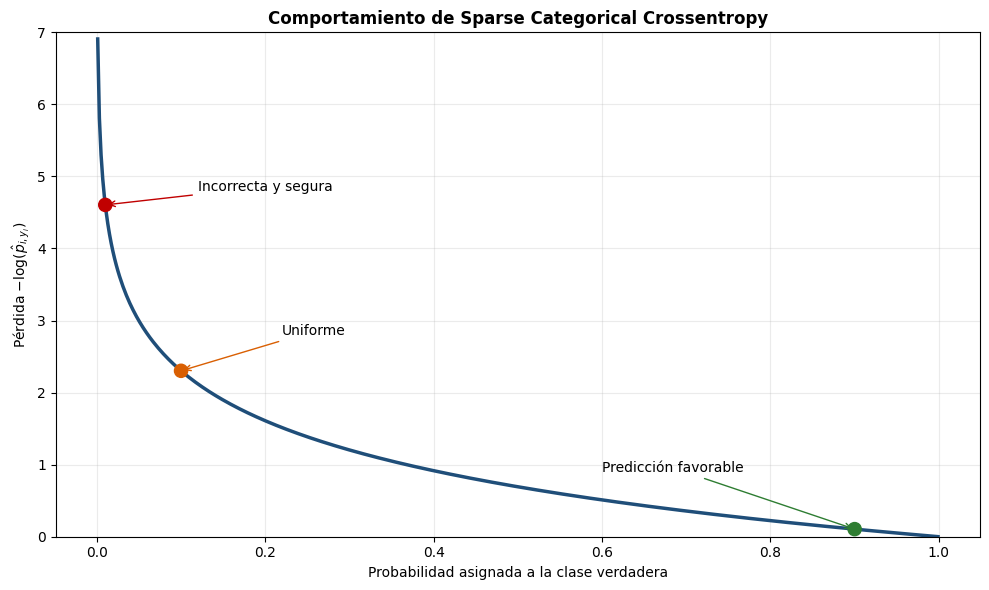


CONFIGURACIÓN PARA LA MLP
Objeto creado: LOSS_MLP
Uso posterior:

modelo_mlp.compile(
    optimizer=...,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)

FASE 9.4 FINALIZADA
✅ Las etiquetas del dataset son enteras.
✅ Las etiquetas pertenecen al intervalo [0, 9].
✅ SparseCategoricalCrossentropy es compatible con el formato de las etiquetas.
✅ from_logits=False es coherente con una salida softmax.
✅ La pérdida de referencia uniforme es log(10) = 2.302585.
✅ Una probabilidad alta para la clase correcta produce una pérdida pequeña.
✅ Una predicción incorrecta con alta confianza produce una pérdida elevada.
✅ La versión sparse es matemáticamente equivalente a la versión one-hot.

La función de pérdida está preparada para utilizarse en la compilación y entrenamiento de la MLP.


In [91]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.4 FUNCIÓN DE PÉRDIDA: SPARSE CATEGORICAL CROSSENTROPY
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar que SparseCategoricalCrossentropy es compatible
# con:
#
# 1. Las diez clases del problema.
# 2. Las etiquetas enteras del pipeline.
# 3. La salida probabilística softmax.
#
# También se demostrará cómo cambia la pérdida cuando el
# modelo asigna probabilidades altas o bajas a la clase real.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda no entrena todavía la MLP y no utiliza el
# conjunto test para seleccionar hiperparámetros.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR LOS OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DEL PROBLEMA
# ============================================================

K = int(
    NUM_CLASSES
)

NUM_CLASSES_EXPECTED = 10

assert K == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {K}."
)

assert len(class_names) == K, (
    "La cantidad de nombres de clase no coincide "
    "con NUM_CLASSES."
)

print("=" * 80)
print("FASE 9.4 — SPARSE CATEGORICAL CROSSENTROPY")
print("=" * 80)

print(f"Número de clases: {K}")
print("Codificación esperada: etiquetas enteras")
print(f"Intervalo válido de etiquetas: [0, {K - 1}]")


# ============================================================
# 5. EXTRAER UN LOTE REAL DEL CONJUNTO DE ENTRENAMIENTO
# ============================================================
#
# Se utiliza train_ds_norm para comprobar el formato de las
# etiquetas. No se necesita data augmentation para validar
# la función de pérdida.
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_norm.take(1)
    )
)

batch_size_real = int(
    tf.shape(
        etiquetas_batch
    )[0].numpy()
)

print("\n" + "=" * 80)
print("LOTE EXTRAÍDO DEL PIPELINE")
print("=" * 80)

print(
    f"Forma de las imágenes: "
    f"{tuple(imagenes_batch.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch.shape)}"
)

print(
    f"Tipo de las etiquetas: "
    f"{etiquetas_batch.dtype.name}"
)

print(
    f"Etiqueta mínima del lote: "
    f"{int(tf.reduce_min(etiquetas_batch).numpy())}"
)

print(
    f"Etiqueta máxima del lote: "
    f"{int(tf.reduce_max(etiquetas_batch).numpy())}"
)


# ============================================================
# 6. VALIDAR QUE LAS ETIQUETAS SEAN ENTERAS
# ============================================================

assert etiquetas_batch.dtype in (
    tf.int32,
    tf.int64
), (
    "SparseCategoricalCrossentropy requiere etiquetas "
    "enteras, pero se recibió "
    f"{etiquetas_batch.dtype.name}."
)

etiqueta_minima = int(
    tf.reduce_min(
        etiquetas_batch
    ).numpy()
)

etiqueta_maxima = int(
    tf.reduce_max(
        etiquetas_batch
    ).numpy()
)

assert etiqueta_minima >= 0, (
    "Se detectó una etiqueta negativa."
)

assert etiqueta_maxima < K, (
    "Se detectó una etiqueta fuera del intervalo permitido."
)

print(
    "\n✅ Las etiquetas poseen codificación entera."
)

print(
    f"✅ Todas las etiquetas pertenecen al intervalo "
    f"[0, {K - 1}]."
)


# ============================================================
# 7. MOSTRAR EJEMPLOS DE ETIQUETAS
# ============================================================

N_EJEMPLOS = min(
    10,
    batch_size_real
)

indices_etiquetas = (
    etiquetas_batch
    .numpy()[:N_EJEMPLOS]
    .astype(int)
)

df_etiquetas = pd.DataFrame({
    "Imagen del lote": np.arange(N_EJEMPLOS),
    "Etiqueta entera": indices_etiquetas,
    "Nombre de la clase": [
        class_names[indice]
        for indice in indices_etiquetas
    ]
})

print("\n" + "=" * 80)
print("EJEMPLOS DE ETIQUETAS ENTERAS")
print("=" * 80)

display(
    df_etiquetas
)


# ============================================================
# 8. DEFINIR LA FUNCIÓN DE PÉRDIDA
# ============================================================
#
# from_logits=False:
#
# La futura salida de la MLP utiliza activación softmax.
# Por tanto, el modelo entregará probabilidades y no logits.
# ============================================================

loss_mlp = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="sum_over_batch_size",
    name="sparse_categorical_crossentropy"
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN DE LA PÉRDIDA")
print("=" * 80)

print(
    "Clase TensorFlow : "
    f"{loss_mlp.__class__.__name__}"
)

print(
    "from_logits      : "
    f"{loss_mlp.from_logits}"
)

print(
    "Reducción        : promedio sobre el batch"
)

print(
    "\n✅ Función de pérdida creada correctamente."
)


# ============================================================
# 9. CONSTRUIR TRES ESCENARIOS PROBABILÍSTICOS
# ============================================================
#
# Se construirán probabilidades controladas para comparar:
#
# A. Predicción uniforme:
#    cada clase recibe probabilidad 1/K.
#
# B. Predicción favorable:
#    la clase real recibe probabilidad 0.90.
#
# C. Predicción incorrecta con alta confianza:
#    la clase real recibe probabilidad 0.01 y otra clase 0.99.
#
# Estos escenarios permiten interpretar el valor de la pérdida.
# ============================================================

etiquetas_demo = tf.cast(
    etiquetas_batch,
    tf.int32
)


# ------------------------------------------------------------
# A. PREDICCIÓN UNIFORME
# ------------------------------------------------------------

probabilidades_uniformes = tf.fill(
    dims=(
        batch_size_real,
        K
    ),
    value=tf.cast(
        1.0 / K,
        tf.float32
    )
)


# ------------------------------------------------------------
# B. PREDICCIÓN FAVORABLE
# ------------------------------------------------------------
#
# Probabilidad de la clase real: 0.90
# Probabilidad restante: 0.10 distribuida entre K-1 clases.
# ------------------------------------------------------------

PROBABILIDAD_CORRECTA_ALTA = 0.90

probabilidad_otras_clases = (
    1.0
    -
    PROBABILIDAD_CORRECTA_ALTA
) / (
    K
    -
    1
)

probabilidades_favorables = tf.one_hot(
    etiquetas_demo,
    depth=K,
    on_value=tf.cast(
        PROBABILIDAD_CORRECTA_ALTA,
        tf.float32
    ),
    off_value=tf.cast(
        probabilidad_otras_clases,
        tf.float32
    )
)


# ------------------------------------------------------------
# C. PREDICCIÓN INCORRECTA CON ALTA CONFIANZA
# ------------------------------------------------------------
#
# La clase verdadera recibe 0.01.
# Una clase incorrecta recibe 0.99.
# Las restantes clases reciben 0.
# ------------------------------------------------------------

PROBABILIDAD_CLASE_REAL_BAJA = 0.01
PROBABILIDAD_CLASE_INCORRECTA = 0.99

# Seleccionar como clase incorrecta la siguiente clase.
indices_incorrectos = (
    etiquetas_demo
    +
    1
) % K

probabilidades_incorrectas = (
    tf.one_hot(
        etiquetas_demo,
        depth=K,
        on_value=tf.cast(
            PROBABILIDAD_CLASE_REAL_BAJA,
            tf.float32
        ),
        off_value=tf.constant(
            0.0,
            dtype=tf.float32
        )
    )
    +
    tf.one_hot(
        indices_incorrectos,
        depth=K,
        on_value=tf.cast(
            PROBABILIDAD_CLASE_INCORRECTA,
            tf.float32
        ),
        off_value=tf.constant(
            0.0,
            dtype=tf.float32
        )
    )
)


# ============================================================
# 10. VERIFICAR QUE LAS PROBABILIDADES SUMEN UNO
# ============================================================

escenarios_probabilidades = {
    "Uniforme": probabilidades_uniformes,
    "Favorable": probabilidades_favorables,
    "Incorrecta con alta confianza": probabilidades_incorrectas
}

for nombre, probabilidades in escenarios_probabilidades.items():

    sumas = tf.reduce_sum(
        probabilidades,
        axis=1
    )

    assert np.allclose(
        sumas.numpy(),
        np.ones(batch_size_real),
        atol=1e-6
    ), (
        f"Las probabilidades del escenario {nombre} "
        "no suman uno."
    )

print(
    "\n✅ Las probabilidades de todos los escenarios suman 1."
)


# ============================================================
# 11. CALCULAR LA PÉRDIDA DE CADA ESCENARIO
# ============================================================

loss_uniforme = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_uniformes
    ).numpy()
)

loss_favorable = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_favorables
    ).numpy()
)

loss_incorrecta = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_incorrectas
    ).numpy()
)


# Valores teóricos esperados.
loss_uniforme_teorica = float(
    np.log(
        K
    )
)

loss_favorable_teorica = float(
    -np.log(
        PROBABILIDAD_CORRECTA_ALTA
    )
)

loss_incorrecta_teorica = float(
    -np.log(
        PROBABILIDAD_CLASE_REAL_BAJA
    )
)


df_comparacion_loss = pd.DataFrame({
    "Escenario": [
        "Predicción uniforme",
        "Predicción favorable",
        "Incorrecta con alta confianza"
    ],

    "Probabilidad de la clase real": [
        1.0 / K,
        PROBABILIDAD_CORRECTA_ALTA,
        PROBABILIDAD_CLASE_REAL_BAJA
    ],

    "Pérdida calculada": [
        loss_uniforme,
        loss_favorable,
        loss_incorrecta
    ],

    "Pérdida teórica": [
        loss_uniforme_teorica,
        loss_favorable_teorica,
        loss_incorrecta_teorica
    ]
})

print("\n" + "=" * 80)
print("COMPARACIÓN DE ESCENARIOS")
print("=" * 80)

display(
    df_comparacion_loss.style.format({
        "Probabilidad de la clase real": "{:.4f}",
        "Pérdida calculada": "{:.6f}",
        "Pérdida teórica": "{:.6f}"
    })
)


# ============================================================
# 12. VERIFICAR LOS RESULTADOS TEÓRICOS
# ============================================================

assert np.isclose(
    loss_uniforme,
    loss_uniforme_teorica,
    atol=1e-5
), (
    "La pérdida uniforme no coincide con log(K)."
)

assert np.isclose(
    loss_favorable,
    loss_favorable_teorica,
    atol=1e-5
), (
    "La pérdida favorable no coincide con -log(0.90)."
)

assert np.isclose(
    loss_incorrecta,
    loss_incorrecta_teorica,
    atol=1e-5
), (
    "La pérdida incorrecta no coincide con -log(0.01)."
)

assert (
    loss_favorable
    <
    loss_uniforme
    <
    loss_incorrecta
), (
    "No se obtuvo el orden esperado entre las pérdidas."
)

print(
    "\n✅ La predicción favorable produce la menor pérdida."
)

print(
    "✅ La predicción uniforme produce una pérdida intermedia."
)

print(
    "✅ La predicción incorrecta y segura produce "
    "la mayor pérdida."
)


# ============================================================
# 13. COMPARAR SPARSE CONTRA ONE-HOT
# ============================================================
#
# SparseCategoricalCrossentropy:
#   recibe etiquetas enteras.
#
# CategoricalCrossentropy:
#   recibe etiquetas one-hot.
#
# Las pérdidas deben ser equivalentes si representan las
# mismas clases y probabilidades.
# ============================================================

etiquetas_one_hot = tf.one_hot(
    etiquetas_demo,
    depth=K
)

loss_categorical = (
    keras.losses.CategoricalCrossentropy(
        from_logits=False,
        reduction="sum_over_batch_size"
    )
)

loss_sparse_equivalente = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_favorables
    ).numpy()
)

loss_one_hot_equivalente = float(
    loss_categorical(
        etiquetas_one_hot,
        probabilidades_favorables
    ).numpy()
)

diferencia_equivalencia = abs(
    loss_sparse_equivalente
    -
    loss_one_hot_equivalente
)

assert np.isclose(
    loss_sparse_equivalente,
    loss_one_hot_equivalente,
    atol=1e-6
), (
    "La pérdida sparse no coincide con la versión one-hot."
)

print("\n" + "=" * 80)
print("EQUIVALENCIA MATEMÁTICA")
print("=" * 80)

print(
    "SparseCategoricalCrossentropy: "
    f"{loss_sparse_equivalente:.8f}"
)

print(
    "CategoricalCrossentropy      : "
    f"{loss_one_hot_equivalente:.8f}"
)

print(
    "Diferencia absoluta          : "
    f"{diferencia_equivalencia:.10f}"
)

print(
    "\n✅ Ambas pérdidas son equivalentes."
)

print(
    "✅ Se mantiene la versión Sparse porque las "
    "etiquetas originales son enteras."
)


# ============================================================
# 14. VISUALIZAR LA RELACIÓN PROBABILIDAD–PÉRDIDA
# ============================================================
#
# La función -log(p) aumenta rápidamente cuando la
# probabilidad asignada a la clase real se acerca a cero.
# ============================================================

probabilidades_clase_real = np.linspace(
    0.001,
    0.999,
    500
)

perdidas_teoricas = -np.log(
    probabilidades_clase_real
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    probabilidades_clase_real,
    perdidas_teoricas,
    color="#1F4E79",
    linewidth=2.5
)

plt.scatter(
    [
        PROBABILIDAD_CLASE_REAL_BAJA,
        1.0 / K,
        PROBABILIDAD_CORRECTA_ALTA
    ],
    [
        loss_incorrecta_teorica,
        loss_uniforme_teorica,
        loss_favorable_teorica
    ],
    color=[
        "#C00000",
        "#D95F02",
        "#2E7D32"
    ],
    s=90,
    zorder=3
)

plt.annotate(
    "Incorrecta y segura",
    xy=(
        PROBABILIDAD_CLASE_REAL_BAJA,
        loss_incorrecta_teorica
    ),
    xytext=(
        0.12,
        4.8
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#C00000"
    }
)

plt.annotate(
    "Uniforme",
    xy=(
        1.0 / K,
        loss_uniforme_teorica
    ),
    xytext=(
        0.22,
        2.8
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#D95F02"
    }
)

plt.annotate(
    "Predicción favorable",
    xy=(
        PROBABILIDAD_CORRECTA_ALTA,
        loss_favorable_teorica
    ),
    xytext=(
        0.60,
        0.9
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#2E7D32"
    }
)

plt.xlabel(
    "Probabilidad asignada a la clase verdadera"
)

plt.ylabel(
    r"Pérdida $-\log(\hat{p}_{i,y_i})$"
)

plt.title(
    "Comportamiento de Sparse Categorical Crossentropy",
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.ylim(
    0,
    7
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. OBJETO QUE SE UTILIZARÁ EN model.compile()
# ============================================================
#
# Este es el objeto que posteriormente se incorporará en la
# compilación de la arquitectura MLP completa.
# ============================================================

LOSS_MLP = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    name="loss_mlp"
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN PARA LA MLP")
print("=" * 80)

print(
    "Objeto creado: LOSS_MLP"
)

print(
    "Uso posterior:"
)

print(
    """
modelo_mlp.compile(
    optimizer=...,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)
"""
)


# ============================================================
# 16. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 9.4 FINALIZADA")
print("=" * 80)

print(
    "✅ Las etiquetas del dataset son enteras."
)

print(
    f"✅ Las etiquetas pertenecen al intervalo "
    f"[0, {K - 1}]."
)

print(
    "✅ SparseCategoricalCrossentropy es compatible "
    "con el formato de las etiquetas."
)

print(
    "✅ from_logits=False es coherente con una salida softmax."
)

print(
    f"✅ La pérdida de referencia uniforme es "
    f"log({K}) = {loss_uniforme_teorica:.6f}."
)

print(
    "✅ Una probabilidad alta para la clase correcta "
    "produce una pérdida pequeña."
)

print(
    "✅ Una predicción incorrecta con alta confianza "
    "produce una pérdida elevada."
)

print(
    "✅ La versión sparse es matemáticamente equivalente "
    "a la versión one-hot."
)

print(
    "\nLa función de pérdida está preparada para utilizarse "
    "en la compilación y entrenamiento de la MLP."
)

## 9.5 Optimizador inicial: Adam

Una vez calculada la función de pérdida, el entrenamiento debe actualizar los
pesos y sesgos de la MLP con el objetivo de reducir progresivamente el error.

El algoritmo encargado de realizar esta actualización se denomina
**optimizador**. Para la configuración inicial de la MLP se utilizará Adam:

```python
tf.keras.optimizers.Adam(
    learning_rate=0.001
)

FASE 9.5 — OPTIMIZADOR ADAM
✅ Los datasets preparados en la Fase 7 están disponibles.

CONFIGURACIÓN INICIAL PROPUESTA
Learning rate : 0.001
Beta 1        : 0.9
Beta 2        : 0.999
Epsilon       : 1e-07
AMSGrad       : False

ACTUALIZACIONES POR ÉPOCA
Imágenes de entrenamiento    : 12,702
Batch size configurado       : 32
Batch size del primer lote   : 32
Lotes observados por época   : 397
Lotes calculados teóricamente: 397

✅ Adam realizará aproximadamente 397 actualizaciones por época.

✅ Optimizador OPTIMIZER_MLP creado correctamente.
Learning rate verificado: 0.001000

HIPERPARÁMETROS DE ADAM


,Hiperparámetro,Valor,Justificación
0,Optimizador,Adam,Optimizador adaptativo
1,Learning rate,0.001,Punto inicial estándar para Adam
2,Beta 1,0.9,Promedio móvil del gradiente
3,Beta 2,0.999,Promedio móvil del gradiente al cuadrado
4,Epsilon,0.0,Evita divisiones por cero
5,AMSGrad,False,No se utiliza en el experimento inicial
6,Clipnorm,None,Sin recorte inicial de norma
7,Clipvalue,None,Sin recorte inicial por valor
8,Actualizaciones por época,397,Un paso de Adam por lote



ACTUALIZACIONES MÁXIMAS DE PARÁMETROS


,Épocas máximas,Actualizaciones máximas
0,10,"3,970"
1,20,"7,940"
2,30,"11,910"
3,50,"19,850"



Nota: EarlyStopping puede finalizar el entrenamiento antes de alcanzar estos valores.

DEMOSTRACIÓN DE UNA ACTUALIZACIÓN
Parámetro antes      : 0.00000000
Gradiente calculado  : -6.00000000
Pérdida antes        : 9.00000000
Parámetro después    : 0.00099999
Pérdida después      : 8.99400139

✅ Adam actualizó el parámetro en la dirección que reduce la pérdida.


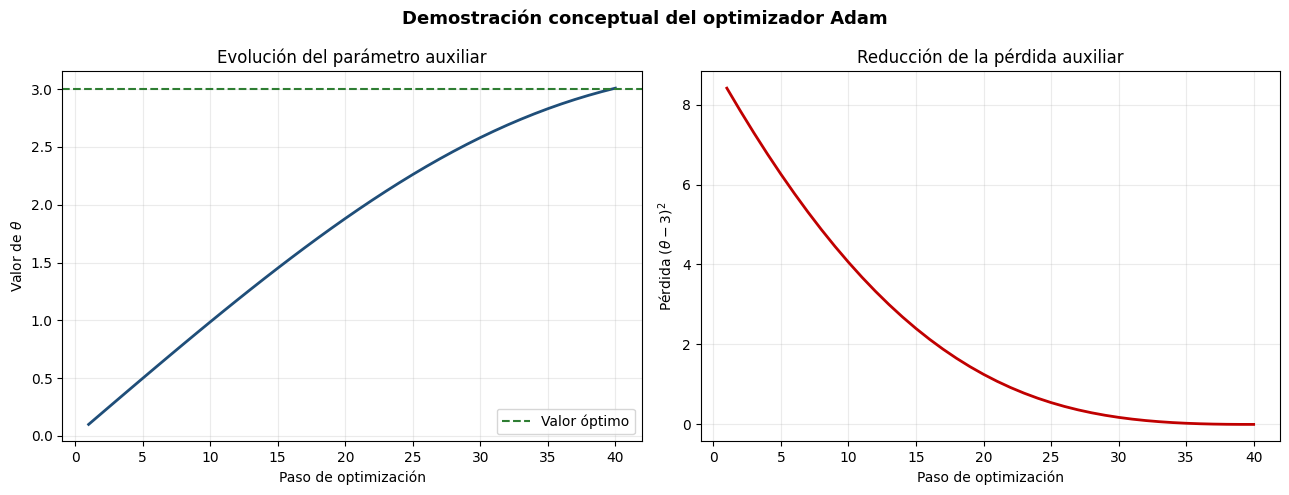

⚠️ La demostración gráfica utiliza learning_rate=0.1 solo para visualizar una función escalar simple.
La MLP mantendrá learning_rate=0.001.

ESTADO DEL OPTIMIZADOR PRINCIPAL
Iteraciones registradas: 0
✅ OPTIMIZER_MLP permanece intacto y preparado para el entrenamiento real.

✅ LOSS_MLP ya se encontraba disponible.

CONFIGURACIÓN POSTERIOR DE model.compile()

modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)

FASE 9.5 FINALIZADA
✅ Se seleccionó Adam como optimizador inicial.
✅ Learning rate inicial: 0.001000.
✅ Beta 1: 0.9.
✅ Beta 2: 0.999.
✅ Epsilon: 1e-07.
✅ Se realizarán aproximadamente 397 actualizaciones por época.
✅ El optimizador es compatible con LOSS_MLP.
✅ Validation se utilizará para evaluar la configuración.
✅ Test permanece reservado para la evaluación final.

OPTIMIZER_MLP está preparado para compilar la arquitectura completa de la MLP.


In [92]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.5 OPTIMIZADOR INICIAL: ADAM
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir y documentar el optimizador Adam que se utilizará
# inicialmente para entrenar la MLP.
#
# La celda permitirá:
#
# 1. Verificar el tamaño del conjunto de entrenamiento.
# 2. Calcular el número de actualizaciones por época.
# 3. Crear Adam con learning rate = 0.001.
# 4. Mostrar sus hiperparámetros.
# 5. Demostrar una actualización sobre una variable auxiliar.
# 6. Preparar el objeto OPTIMIZER_MLP para model.compile().
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda no entrena todavía la MLP y no utiliza el
# conjunto test para ajustar hiperparámetros.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print("=" * 80)
print("FASE 9.5 — OPTIMIZADOR ADAM")
print("=" * 80)

print(
    "✅ Los datasets preparados en la Fase 7 "
    "están disponibles."
)


# ============================================================
# 4. CONFIGURACIÓN INICIAL
# ============================================================

LEARNING_RATE_MLP = 1e-3
BETA_1_MLP = 0.9
BETA_2_MLP = 0.999
EPSILON_MLP = 1e-7
AMSGRAD_MLP = False

# Cantidades obtenidas en las fases anteriores.
N_TRAIN_EXPECTED = 12_702
BATCH_SIZE_EXPECTED = 32

print("\n" + "=" * 80)
print("CONFIGURACIÓN INICIAL PROPUESTA")
print("=" * 80)

print(
    f"Learning rate : {LEARNING_RATE_MLP}"
)

print(
    f"Beta 1        : {BETA_1_MLP}"
)

print(
    f"Beta 2        : {BETA_2_MLP}"
)

print(
    f"Epsilon       : {EPSILON_MLP}"
)

print(
    f"AMSGrad       : {AMSGRAD_MLP}"
)


# ============================================================
# 5. OBTENER LA CARDINALIDAD REAL DEL DATASET
# ============================================================
#
# train_ds_final contiene lotes de 32 imágenes y data
# augmentation aplicada exclusivamente durante entrenamiento.
#
# La cardinalidad representa el número de lotes por época.
# ============================================================

cardinalidad_train = tf.data.experimental.cardinality(
    train_ds_final
)

n_batches_train = int(
    cardinalidad_train.numpy()
)

if n_batches_train < 0:
    raise ValueError(
        "No fue posible determinar la cardinalidad de "
        "train_ds_final."
    )

# Obtener el batch size real desde el primer lote.
imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_final.take(1)
    )
)

batch_size_real = int(
    tf.shape(
        imagenes_batch
    )[0].numpy()
)

# Cálculo teórico a partir de los resultados previos.
steps_per_epoch_teoricos = math.ceil(
    N_TRAIN_EXPECTED
    /
    BATCH_SIZE_EXPECTED
)

print("\n" + "=" * 80)
print("ACTUALIZACIONES POR ÉPOCA")
print("=" * 80)

print(
    f"Imágenes de entrenamiento    : "
    f"{N_TRAIN_EXPECTED:,}"
)

print(
    f"Batch size configurado       : "
    f"{BATCH_SIZE_EXPECTED}"
)

print(
    f"Batch size del primer lote   : "
    f"{batch_size_real}"
)

print(
    f"Lotes observados por época   : "
    f"{n_batches_train}"
)

print(
    f"Lotes calculados teóricamente: "
    f"{steps_per_epoch_teoricos}"
)

assert n_batches_train == steps_per_epoch_teoricos, (
    "La cardinalidad observada no coincide con "
    "ceil(N_train / batch_size)."
)

print(
    "\n✅ Adam realizará aproximadamente "
    f"{n_batches_train} actualizaciones por época."
)


# ============================================================
# 6. CREAR EL OPTIMIZADOR ADAM
# ============================================================
#
# Este será el objeto utilizado posteriormente en:
#
# modelo_mlp.compile(
#     optimizer=OPTIMIZER_MLP,
#     loss=LOSS_MLP,
#     metrics=["accuracy"]
# )
# ============================================================

OPTIMIZER_MLP = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP,
    amsgrad=AMSGRAD_MLP,
    name="adam_mlp"
)

print("\n✅ Optimizador OPTIMIZER_MLP creado correctamente.")


# ============================================================
# 7. RECUPERAR EL LEARNING RATE DE FORMA SEGURA
# ============================================================

def obtener_learning_rate(optimizer):
    """
    Obtiene el learning rate actual de un optimizador Keras.

    La función es compatible tanto con una tasa constante como
    con un posible schedule de learning rate.
    """

    learning_rate = optimizer.learning_rate

    if callable(learning_rate):

        valor = learning_rate(
            optimizer.iterations
        )

    else:

        valor = learning_rate

    return float(
        tf.keras.backend.get_value(
            valor
        )
    )


learning_rate_observado = obtener_learning_rate(
    OPTIMIZER_MLP
)

assert np.isclose(
    learning_rate_observado,
    LEARNING_RATE_MLP
), (
    "El learning rate observado no coincide con "
    "la configuración solicitada."
)

print(
    f"Learning rate verificado: "
    f"{learning_rate_observado:.6f}"
)


# ============================================================
# 8. TABLA DE HIPERPARÁMETROS
# ============================================================

configuracion_adam = (
    OPTIMIZER_MLP.get_config()
)

df_configuracion_adam = pd.DataFrame({
    "Hiperparámetro": [
        "Optimizador",
        "Learning rate",
        "Beta 1",
        "Beta 2",
        "Epsilon",
        "AMSGrad",
        "Clipnorm",
        "Clipvalue",
        "Actualizaciones por época"
    ],

    "Valor": [
        "Adam",
        learning_rate_observado,
        configuracion_adam["beta_1"],
        configuracion_adam["beta_2"],
        configuracion_adam["epsilon"],
        configuracion_adam["amsgrad"],
        configuracion_adam.get(
            "clipnorm",
            None
        ),
        configuracion_adam.get(
            "clipvalue",
            None
        ),
        n_batches_train
    ],

    "Justificación": [
        "Optimizador adaptativo",
        "Punto inicial estándar para Adam",
        "Promedio móvil del gradiente",
        "Promedio móvil del gradiente al cuadrado",
        "Evita divisiones por cero",
        "No se utiliza en el experimento inicial",
        "Sin recorte inicial de norma",
        "Sin recorte inicial por valor",
        "Un paso de Adam por lote"
    ]
})

print("\n" + "=" * 80)
print("HIPERPARÁMETROS DE ADAM")
print("=" * 80)

display(
    df_configuracion_adam
)


# ============================================================
# 9. ESTIMAR ACTUALIZACIONES SEGÚN NÚMERO DE ÉPOCAS
# ============================================================

epocas_referencia = [
    10,
    20,
    30,
    50
]

df_actualizaciones = pd.DataFrame({
    "Épocas máximas": epocas_referencia,
    "Actualizaciones máximas": [
        epocas
        *
        n_batches_train
        for epocas in epocas_referencia
    ]
})

print("\n" + "=" * 80)
print("ACTUALIZACIONES MÁXIMAS DE PARÁMETROS")
print("=" * 80)

display(
    df_actualizaciones.style.format({
        "Actualizaciones máximas": "{:,.0f}"
    })
)

print(
    "\nNota: EarlyStopping puede finalizar el entrenamiento "
    "antes de alcanzar estos valores."
)


# ============================================================
# 10. DEMOSTRACIÓN CONTROLADA DE UNA ACTUALIZACIÓN
# ============================================================
#
# Para no modificar ninguna variable del futuro modelo MLP,
# Adam se demuestra mediante una variable auxiliar.
#
# Función de ejemplo:
#
# f(theta) = (theta - 3)^2
#
# El mínimo se encuentra en theta = 3.
# Partimos desde theta = 0.
# ============================================================

theta_demo = tf.Variable(
    0.0,
    dtype=tf.float32,
    name="theta_demo"
)

# Se utiliza un optimizador independiente para no incrementar
# el contador de iteraciones de OPTIMIZER_MLP.
optimizer_demo = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP,
    amsgrad=AMSGRAD_MLP,
    name="adam_demostracion"
)

theta_antes = float(
    theta_demo.numpy()
)

with tf.GradientTape() as tape:

    loss_demo = tf.square(
        theta_demo
        -
        3.0
    )

gradiente_demo = tape.gradient(
    loss_demo,
    theta_demo
)

loss_antes = float(
    loss_demo.numpy()
)

optimizer_demo.apply_gradients(
    [
        (
            gradiente_demo,
            theta_demo
        )
    ]
)

theta_despues = float(
    theta_demo.numpy()
)

loss_despues = float(
    tf.square(
        theta_demo
        -
        3.0
    ).numpy()
)

print("\n" + "=" * 80)
print("DEMOSTRACIÓN DE UNA ACTUALIZACIÓN")
print("=" * 80)

print(
    f"Parámetro antes      : "
    f"{theta_antes:.8f}"
)

print(
    f"Gradiente calculado  : "
    f"{float(gradiente_demo.numpy()):.8f}"
)

print(
    f"Pérdida antes        : "
    f"{loss_antes:.8f}"
)

print(
    f"Parámetro después    : "
    f"{theta_despues:.8f}"
)

print(
    f"Pérdida después      : "
    f"{loss_despues:.8f}"
)

assert loss_despues < loss_antes, (
    "La actualización demostrativa no redujo la pérdida."
)

print(
    "\n✅ Adam actualizó el parámetro en la dirección "
    "que reduce la pérdida."
)


# ============================================================
# 11. DEMOSTRAR VARIAS ACTUALIZACIONES
# ============================================================
#
# Esta demostración permite observar la evolución del
# parámetro y de la pérdida sin entrenar todavía la MLP.
# ============================================================

theta_trayectoria = tf.Variable(
    0.0,
    dtype=tf.float32
)

optimizer_trayectoria = keras.optimizers.Adam(
    learning_rate=0.1,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP
)

# Se utiliza 0.1 solamente en esta función matemática simple
# para que la trayectoria sea visible en pocas iteraciones.
# Este valor NO reemplaza el learning rate de la MLP.
N_PASOS_DEMO = 40

historial_theta = []
historial_loss = []

for paso in range(N_PASOS_DEMO):

    with tf.GradientTape() as tape:

        loss_actual = tf.square(
            theta_trayectoria
            -
            3.0
        )

    gradiente_actual = tape.gradient(
        loss_actual,
        theta_trayectoria
    )

    optimizer_trayectoria.apply_gradients(
        [
            (
                gradiente_actual,
                theta_trayectoria
            )
        ]
    )

    historial_theta.append(
        float(
            theta_trayectoria.numpy()
        )
    )

    historial_loss.append(
        float(
            tf.square(
                theta_trayectoria
                -
                3.0
            ).numpy()
        )
    )


# ============================================================
# 12. VISUALIZAR LA DEMOSTRACIÓN
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].plot(
    range(
        1,
        N_PASOS_DEMO + 1
    ),
    historial_theta,
    color="#1F4E79",
    linewidth=2
)

axes[0].axhline(
    y=3.0,
    color="#2E7D32",
    linestyle="--",
    label="Valor óptimo"
)

axes[0].set_title(
    "Evolución del parámetro auxiliar"
)

axes[0].set_xlabel(
    "Paso de optimización"
)

axes[0].set_ylabel(
    r"Valor de $\theta$"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend()


axes[1].plot(
    range(
        1,
        N_PASOS_DEMO + 1
    ),
    historial_loss,
    color="#C00000",
    linewidth=2
)

axes[1].set_title(
    "Reducción de la pérdida auxiliar"
)

axes[1].set_xlabel(
    "Paso de optimización"
)

axes[1].set_ylabel(
    r"Pérdida $(\theta-3)^2$"
)

axes[1].grid(
    alpha=0.25
)

plt.suptitle(
    "Demostración conceptual del optimizador Adam",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print(
    "⚠️ La demostración gráfica utiliza learning_rate=0.1 "
    "solo para visualizar una función escalar simple."
)

print(
    "La MLP mantendrá learning_rate=0.001."
)


# ============================================================
# 13. COMPROBAR QUE EL OPTIMIZADOR PRINCIPAL NO FUE USADO
# ============================================================
#
# OPTIMIZER_MLP debe permanecer en cero iteraciones hasta
# compilar y entrenar la arquitectura definitiva.
# ============================================================

iteraciones_optimizer_mlp = int(
    OPTIMIZER_MLP.iterations.numpy()
)

assert iteraciones_optimizer_mlp == 0, (
    "OPTIMIZER_MLP fue utilizado antes del entrenamiento."
)

print("\n" + "=" * 80)
print("ESTADO DEL OPTIMIZADOR PRINCIPAL")
print("=" * 80)

print(
    f"Iteraciones registradas: "
    f"{iteraciones_optimizer_mlp}"
)

print(
    "✅ OPTIMIZER_MLP permanece intacto y preparado "
    "para el entrenamiento real."
)


# ============================================================
# 14. VERIFICAR COMPATIBILIDAD CON LA PÉRDIDA
# ============================================================

if "LOSS_MLP" not in globals():

    LOSS_MLP = (
        keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            name="loss_mlp"
        )
    )

    print(
        "\nℹ️ LOSS_MLP no existía y fue creado "
        "con la configuración correcta."
    )

else:

    print(
        "\n✅ LOSS_MLP ya se encontraba disponible."
    )


# ============================================================
# 15. MOSTRAR CONFIGURACIÓN DE COMPILACIÓN
# ============================================================

print("\n" + "=" * 80)
print("CONFIGURACIÓN POSTERIOR DE model.compile()")
print("=" * 80)

print(
    """
modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)
"""
)


# ============================================================
# 16. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 9.5 FINALIZADA")
print("=" * 80)

print(
    "✅ Se seleccionó Adam como optimizador inicial."
)

print(
    f"✅ Learning rate inicial: "
    f"{LEARNING_RATE_MLP:.6f}."
)

print(
    f"✅ Beta 1: {BETA_1_MLP}."
)

print(
    f"✅ Beta 2: {BETA_2_MLP}."
)

print(
    f"✅ Epsilon: {EPSILON_MLP}."
)

print(
    f"✅ Se realizarán aproximadamente "
    f"{n_batches_train} actualizaciones por época."
)

print(
    "✅ El optimizador es compatible con LOSS_MLP."
)

print(
    "✅ Validation se utilizará para evaluar la "
    "configuración."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nOPTIMIZER_MLP está preparado para compilar "
    "la arquitectura completa de la MLP."
)

## 9.6 Registro de learning rate, batch size, épocas, parámetros y regularización

Antes de entrenar la MLP es necesario registrar formalmente su configuración. Esto permite:

- Reproducir el experimento.
- Comparar posteriormente la MLP con la CNN.
- Interpretar diferencias de rendimiento.
- Controlar la complejidad del modelo.
- Detectar posibles problemas de sobreajuste.
- Evitar cambios de hiperparámetros no documentados.

La configuración inicial propuesta es:

| Componente | Configuración |
|---|---:|
| Resolución de entrada | $128 \times 128 \times 3$ |
| Características después de `Flatten` | $49.152$ |
| Primera capa oculta | 128 neuronas, ReLU |
| Dropout | $0.30$ |
| Segunda capa oculta | 64 neuronas, ReLU |
| Capa de salida | 10 neuronas, softmax |
| Optimizador | Adam |
| Learning rate | $0.001$ |
| Batch size | 32 |
| Épocas máximas | 50 |
| Early stopping | Sí |
| Paciencia | 7 épocas |
| Función de pérdida | Sparse categorical cross-entropy |
| Regularización L2 inicial | No aplicada |
| Data augmentation | Solo en train |

---

### Arquitectura propuesta

La arquitectura inicial de la MLP puede representarse como:

$$
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
$$

$$
\mathbf{X}_i \longrightarrow \operatorname{Flatten} \longrightarrow \operatorname{Dense}(128, \operatorname{ReLU}) \longrightarrow \operatorname{Dropout}(0.30)
$$

$$
\longrightarrow \operatorname{Dense}(64, \operatorname{ReLU}) \longrightarrow \operatorname{Dense}(10, \operatorname{softmax})
$$

En forma resumida:

$$
128 \times 128 \times 3 \longrightarrow 49.152 \longrightarrow 128 \longrightarrow 64 \longrightarrow 10
$$

---

### Learning rate

La tasa de aprendizaje inicial será:

$$
\alpha = 0.001 = 10^{-3}
$$

Este valor controla la magnitud de las actualizaciones realizadas por Adam:

$$
\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \alpha \frac{\widehat{\mathbf{m}}_t}{\sqrt{\widehat{\mathbf{v}}_t} + \varepsilon}
$$

Una tasa demasiado alta puede generar inestabilidad, mientras que una tasa demasiado baja puede producir una convergencia lenta.

El valor $10^{-3}$ se utilizará como configuración inicial. Cualquier ajuste posterior deberá justificarse mediante resultados de validación y nunca mediante el conjunto test.

---

### Tamaño de lote

El tamaño de lote será:

$$
B = 32
$$

El conjunto de entrenamiento contiene:

$$
N_{\mathrm{train}} = 12.702
$$

imágenes. Por tanto, el número de lotes por época será:

$$
S = \left\lceil \frac{N_{\mathrm{train}}}{B} \right\rceil
$$

$$
S = \left\lceil \frac{12.702}{32} \right\rceil = 397
$$

Adam realizará aproximadamente 397 actualizaciones de parámetros durante cada época.

---

### Épocas máximas

Se define inicialmente:

$$
E_{\max} = 50
$$

Si el entrenamiento alcanzara las 50 épocas, el número máximo aproximado de actualizaciones sería:

$$
T_{\max} = E_{\max} \cdot S
$$

$$
T_{\max} = 50 \cdot 397 = 19.850
$$

Sin embargo, este valor representa un máximo. El entrenamiento podrá finalizar antes mediante `EarlyStopping`.

---

### Parámetros entrenables

Para una capa densa con $n_{\mathrm{in}}$ entradas y $n_{\mathrm{out}}$ neuronas, la cantidad de parámetros es:

$$
N_{\mathrm{Dense}} = n_{\mathrm{in}} n_{\mathrm{out}} + n_{\mathrm{out}}
$$

o equivalentemente:

$$
N_{\mathrm{Dense}} = (n_{\mathrm{in}} + 1) n_{\mathrm{out}}
$$

El primer término corresponde a los pesos y el segundo a los sesgos.

#### 1. Primera capa densa
La entrada contiene $49.152$ características y la primera capa posee 128 neuronas:

$$
N_1 = (49.152 + 1) \cdot 128
$$

$$
N_1 = 6.291.584
$$

#### 2. Segunda capa densa
La segunda capa recibe 128 entradas y contiene 64 neuronas:

$$
N_2 = (128 + 1) \cdot 64
$$

$$
N_2 = 8.256
$$

#### 3. Capa de salida
La salida recibe 64 entradas y contiene 10 neuronas:

$$
N_3 = (64 + 1) \cdot 10
$$

$$
N_3 = 650
$$

#### 4. Parámetros totales
La cantidad total es:

$$
N_{\mathrm{total}} = N_1 + N_2 + N_3
$$

$$
N_{\mathrm{total}} = 6.291.584 + 8.256 + 650
$$

$$
\boxed{N_{\mathrm{total}} = 6.300.490}
$$

Las capas `Flatten` y `Dropout` no incorporan parámetros:

$$
N_{\mathrm{Flatten}} = 0, \quad N_{\mathrm{Dropout}} = 0
$$

La mayor parte de los parámetros se concentra en la primera capa densa debido a la vectorización de la imagen:

$$
\frac{N_1}{N_{\mathrm{total}}} \cdot 100 \approx 99.86\%
$$

Esto anticipa un riesgo de sobreajuste y constituye una diferencia estructural importante respecto de la CNN.

---

### Regularización mediante Dropout

Se utilizará:

$$
p_{\mathrm{drop}} = 0.30
$$

Durante el entrenamiento, `Dropout` desactiva aleatoriamente una proporción de las activaciones de la capa anterior.

Si $a_j$ representa la activación de la neurona $j$, se genera una máscara:

$$
r_j \sim \operatorname{Bernoulli}(q)
$$

donde la probabilidad de conservación es:

$$
q = 1 - p_{\mathrm{drop}}
$$

En este proyecto:

$$
q = 1 - 0.30 = 0.70
$$

La activación regularizada durante el entrenamiento puede expresarse como:

$$
\widetilde{a}_j = \frac{r_j}{q} a_j
$$

Esta formulación, denominada *inverted dropout*, conserva aproximadamente el valor esperado de las activaciones:

$$
\mathbb{E} \left[ \widetilde{a}_j \right] = a_j
$$

Durante validación, prueba e inferencia, Dropout se desactiva.

---

### Regularización mediante data augmentation

El conjunto de datos de entrenamiento incorpora técnicas de aumento de datos (*data augmentation*) para mejorar la capacidad de generalización del modelo y mitigar el sobreajuste.

In [93]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.6 REGISTRO DE HIPERPARÁMETROS Y REGULARIZACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir, verificar y registrar:
#
# 1. Learning rate.
# 2. Batch size.
# 3. Épocas máximas.
# 4. Arquitectura.
# 5. Parámetros entrenables.
# 6. Dropout.
# 7. Regularización L2.
# 8. Early stopping.
# 9. Data augmentation.
#
# La celda construye y compila la MLP, pero NO inicia todavía
# el entrenamiento.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DE ENTRADA
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

FLATTEN_FEATURES = (
    IMAGE_HEIGHT
    *
    IMAGE_WIDTH
    *
    CHANNELS
)

K = int(
    NUM_CLASSES
)

assert K == 10, (
    f"Se esperaban 10 clases, pero se detectaron {K}."
)

assert len(class_names) == K, (
    "class_names no coincide con NUM_CLASSES."
)


# ============================================================
# 5. REGISTRO DE HIPERPARÁMETROS
# ============================================================

# ------------------------------------------------------------
# Optimización
# ------------------------------------------------------------

LEARNING_RATE_MLP = 1e-3
BATCH_SIZE_MLP = 32
MAX_EPOCHS_MLP = 50

# ------------------------------------------------------------
# Arquitectura
# ------------------------------------------------------------

HIDDEN_UNITS_1_MLP = 128
HIDDEN_UNITS_2_MLP = 64

# ------------------------------------------------------------
# Regularización
# ------------------------------------------------------------

DROPOUT_RATE_MLP = 0.30
L2_LAMBDA_MLP = 0.0

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

EARLY_STOPPING_PATIENCE_MLP = 7
EARLY_STOPPING_MIN_DELTA_MLP = 1e-4

# ------------------------------------------------------------
# Datos conocidos
# ------------------------------------------------------------

N_TRAIN_MLP = 12_702
N_VALIDATION_MLP = 2_722
N_TEST_MLP = 2_722


# ============================================================
# 6. VERIFICAR BATCH SIZE Y CARDINALIDAD
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_final.take(1)
    )
)

batch_size_observado = int(
    tf.shape(
        imagenes_batch
    )[0].numpy()
)

assert batch_size_observado == BATCH_SIZE_MLP, (
    f"Se esperaba batch size {BATCH_SIZE_MLP}, "
    f"pero se observó {batch_size_observado}."
)

steps_per_epoch_teoricos = math.ceil(
    N_TRAIN_MLP
    /
    BATCH_SIZE_MLP
)

cardinalidad_train = int(
    tf.data.experimental.cardinality(
        train_ds_final
    ).numpy()
)

assert cardinalidad_train == steps_per_epoch_teoricos, (
    "La cardinalidad del dataset no coincide con "
    "ceil(N_train / batch_size)."
)

MAX_OPTIMIZER_STEPS_MLP = (
    MAX_EPOCHS_MLP
    *
    steps_per_epoch_teoricos
)

print("=" * 80)
print("FASE 9.6 — CONFIGURACIÓN EXPERIMENTAL DE LA MLP")
print("=" * 80)

print(f"Train                : {N_TRAIN_MLP:,}")
print(f"Validation           : {N_VALIDATION_MLP:,}")
print(f"Test                 : {N_TEST_MLP:,}")
print(f"Batch size           : {BATCH_SIZE_MLP}")
print(f"Pasos por época      : {steps_per_epoch_teoricos}")
print(f"Épocas máximas       : {MAX_EPOCHS_MLP}")
print(
    f"Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS_MLP:,}"
)


# ============================================================
# 7. CONSTRUIR LA ARQUITECTURA MLP
# ============================================================
#
# Arquitectura:
#
# Input(128, 128, 3)
# -> Flatten
# -> Dense(128, ReLU)
# -> Dropout(0.30)
# -> Dense(64, ReLU)
# -> Dense(10, Softmax)
#
# L2 no se aplica en la configuración base porque lambda=0.
# ============================================================

if L2_LAMBDA_MLP > 0:

    regularizador_l2 = keras.regularizers.l2(
        L2_LAMBDA_MLP
    )

else:

    regularizador_l2 = None


modelo_mlp = keras.Sequential(
    [
        layers.Input(
            shape=INPUT_SHAPE_MLP,
            name="imagen_entrada"
        ),

        layers.Flatten(
            name="flatten"
        ),

        layers.Dense(
            units=HIDDEN_UNITS_1_MLP,
            activation="relu",
            kernel_regularizer=regularizador_l2,
            name="dense_128"
        ),

        layers.Dropout(
            rate=DROPOUT_RATE_MLP,
            seed=SEED,
            name="dropout_030"
        ),

        layers.Dense(
            units=HIDDEN_UNITS_2_MLP,
            activation="relu",
            kernel_regularizer=regularizador_l2,
            name="dense_64"
        ),

        layers.Dense(
            units=K,
            activation="softmax",
            name="salida_softmax"
        )
    ],
    name="MLP_PlantVillage"
)


# ============================================================
# 8. CALCULAR PARÁMETROS TEÓRICOS
# ============================================================

PARAMS_DENSE_1 = (
    FLATTEN_FEATURES
    +
    1
) * HIDDEN_UNITS_1_MLP

PARAMS_DENSE_2 = (
    HIDDEN_UNITS_1_MLP
    +
    1
) * HIDDEN_UNITS_2_MLP

PARAMS_OUTPUT = (
    HIDDEN_UNITS_2_MLP
    +
    1
) * K

PARAMS_TOTAL_THEORETICAL = (
    PARAMS_DENSE_1
    +
    PARAMS_DENSE_2
    +
    PARAMS_OUTPUT
)

PARAMS_TOTAL_KERAS = (
    modelo_mlp.count_params()
)

assert PARAMS_TOTAL_KERAS == PARAMS_TOTAL_THEORETICAL, (
    "La cantidad de parámetros reportada por Keras "
    "no coincide con el cálculo teórico."
)


# ============================================================
# 9. TABLA DE PARÁMETROS POR CAPA
# ============================================================

df_parametros_mlp = pd.DataFrame({
    "Capa": [
        "Input",
        "Flatten",
        "Dense 128",
        "Dropout 0.30",
        "Dense 64",
        "Dense 10 Softmax",
        "TOTAL"
    ],

    "Forma de salida": [
        "(None, 128, 128, 3)",
        "(None, 49.152)",
        "(None, 128)",
        "(None, 128)",
        "(None, 64)",
        "(None, 10)",
        "-"
    ],

    "Parámetros": [
        0,
        0,
        PARAMS_DENSE_1,
        0,
        PARAMS_DENSE_2,
        PARAMS_OUTPUT,
        PARAMS_TOTAL_THEORETICAL
    ],

    "Entrenable": [
        "No",
        "No",
        "Sí",
        "No",
        "Sí",
        "Sí",
        "-"
    ]
})

print("\n" + "=" * 80)
print("PARÁMETROS DE LA MLP")
print("=" * 80)

display(
    df_parametros_mlp.style.format({
        "Parámetros": "{:,.0f}"
    })
)


# ============================================================
# 10. CONCENTRACIÓN DE PARÁMETROS
# ============================================================

porcentaje_primera_capa = (
    PARAMS_DENSE_1
    /
    PARAMS_TOTAL_THEORETICAL
    *
    100
)

print(
    f"\nParámetros totales: "
    f"{PARAMS_TOTAL_THEORETICAL:,}"
)

print(
    "Parámetros en la primera capa Dense: "
    f"{PARAMS_DENSE_1:,}"
)

print(
    "Concentración en la primera capa: "
    f"{porcentaje_primera_capa:.2f}%"
)

if porcentaje_primera_capa > 95:

    print(
        "\n⚠️ Más del 95% de los parámetros se concentra "
        "en la primera capa densa."
    )

    print(
        "Esto se debe al aplanamiento de 49.152 píxeles "
        "y constituye un riesgo de sobreajuste."
    )


# ============================================================
# 11. CREAR PÉRDIDA Y OPTIMIZADOR
# ============================================================

LOSS_MLP = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        name="loss_mlp"
    )
)

OPTIMIZER_MLP = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    name="adam_mlp"
)


# ============================================================
# 12. COMPILAR LA MLP
# ============================================================
#
# Accuracy se registra durante el entrenamiento.
#
# Balanced accuracy, precision macro, recall macro y F1 macro
# se calcularán posteriormente con Scikit-learn.
# ============================================================

modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "\n✅ MLP compilada correctamente."
)


# ============================================================
# 13. CONFIGURAR CALLBACKS DE REGULARIZACIÓN
# ============================================================

DIRECTORIO_MODELOS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_MEJOR_MLP = (
    DIRECTORIO_MODELOS
    /
    "mejor_modelo_mlp.keras"
)


early_stopping_mlp = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=EARLY_STOPPING_PATIENCE_MLP,
    min_delta=EARLY_STOPPING_MIN_DELTA_MLP,
    restore_best_weights=True,
    verbose=1
)


checkpoint_mlp = keras.callbacks.ModelCheckpoint(
    filepath=str(
        RUTA_MEJOR_MLP
    ),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)


callbacks_mlp = [
    early_stopping_mlp,
    checkpoint_mlp
]

print(
    "\n✅ EarlyStopping configurado."
)

print(
    "✅ ModelCheckpoint configurado."
)

print(
    f"Ruta del mejor modelo: "
    f"{RUTA_MEJOR_MLP}"
)


# ============================================================
# 14. REGISTRO DE REGULARIZACIÓN
# ============================================================

df_regularizacion_mlp = pd.DataFrame({
    "Técnica": [
        "Normalización de entrada",
        "Data augmentation",
        "Dropout",
        "Early stopping",
        "Model checkpoint",
        "Regularización L2"
    ],

    "Configuración": [
        "Píxeles en [0, 1]",
        "Flip + Rotation + Zoom",
        f"rate={DROPOUT_RATE_MLP}",
        (
            f"patience="
            f"{EARLY_STOPPING_PATIENCE_MLP}"
        ),
        "Mejor val_loss",
        f"lambda={L2_LAMBDA_MLP}"
    ],

    "Aplicación": [
        "Train, validation y test",
        "Solo train",
        "Solo durante entrenamiento",
        "Monitorea validation",
        "Guarda mejor época",
        (
            "No aplicada en configuración base"
            if L2_LAMBDA_MLP == 0
            else "Aplicada"
        )
    ]
})

print("\n" + "=" * 80)
print("REGULARIZACIÓN REGISTRADA")
print("=" * 80)

display(
    df_regularizacion_mlp
)


# ============================================================
# 15. TABLA CONSOLIDADA DEL EXPERIMENTO
# ============================================================

configuracion_experimento_mlp = {
    "modelo": "MLP",
    "dataset": "PlantVillage - Tomato",
    "numero_clases": K,
    "input_shape": str(INPUT_SHAPE_MLP),
    "flatten_features": FLATTEN_FEATURES,
    "hidden_units_1": HIDDEN_UNITS_1_MLP,
    "hidden_units_2": HIDDEN_UNITS_2_MLP,
    "output_units": K,
    "output_activation": "softmax",
    "loss": "SparseCategoricalCrossentropy",
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE_MLP,
    "batch_size": BATCH_SIZE_MLP,
    "max_epochs": MAX_EPOCHS_MLP,
    "steps_per_epoch": steps_per_epoch_teoricos,
    "max_optimizer_steps": MAX_OPTIMIZER_STEPS_MLP,
    "dropout_rate": DROPOUT_RATE_MLP,
    "l2_lambda": L2_LAMBDA_MLP,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE_MLP
    ),
    "early_stopping_min_delta": (
        EARLY_STOPPING_MIN_DELTA_MLP
    ),
    "data_augmentation": True,
    "train_images": N_TRAIN_MLP,
    "validation_images": N_VALIDATION_MLP,
    "test_images": N_TEST_MLP,
    "trainable_parameters": PARAMS_TOTAL_KERAS,
    "seed": SEED
}

df_configuracion_mlp = pd.DataFrame(
    configuracion_experimento_mlp.items(),
    columns=[
        "Componente",
        "Valor"
    ]
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN CONSOLIDADA DE LA MLP")
print("=" * 80)

display(
    df_configuracion_mlp
)


# ============================================================
# 16. GUARDAR EL REGISTRO
# ============================================================

DIRECTORIO_REPORTES_MLP = Path(
    "/content/plantvillage/reportes_mlp"
)

DIRECTORIO_REPORTES_MLP.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_CONFIG_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "configuracion_mlp.csv"
)

RUTA_CONFIG_JSON = (
    DIRECTORIO_REPORTES_MLP
    /
    "configuracion_mlp.json"
)

RUTA_PARAMETROS_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "parametros_por_capa_mlp.csv"
)

RUTA_REGULARIZACION_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "regularizacion_mlp.csv"
)


df_configuracion_mlp.to_csv(
    RUTA_CONFIG_CSV,
    index=False
)

df_parametros_mlp.to_csv(
    RUTA_PARAMETROS_CSV,
    index=False
)

df_regularizacion_mlp.to_csv(
    RUTA_REGULARIZACION_CSV,
    index=False
)

with open(
    RUTA_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        configuracion_experimento_mlp,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


print("\n" + "=" * 80)
print("ARCHIVOS DE CONFIGURACIÓN GUARDADOS")
print("=" * 80)

print(
    f"Configuración CSV : {RUTA_CONFIG_CSV}"
)

print(
    f"Configuración JSON: {RUTA_CONFIG_JSON}"
)

print(
    f"Parámetros        : {RUTA_PARAMETROS_CSV}"
)

print(
    f"Regularización    : {RUTA_REGULARIZACION_CSV}"
)


# ============================================================
# 17. MOSTRAR RESUMEN DEL MODELO
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DE LA ARQUITECTURA")
print("=" * 80)

modelo_mlp.summary()


# ============================================================
# 18. VERIFICAR UNA SALIDA SIN ENTRENAR
# ============================================================
#
# Esta comprobación valida solamente la forma de la salida.
# Las predicciones aún no poseen significado porque el modelo
# no ha sido entrenado.
# ============================================================

predicciones_iniciales = modelo_mlp(
    imagenes_batch,
    training=False
)

forma_salida_observada = tuple(
    predicciones_iniciales.shape
)

forma_salida_esperada = (
    batch_size_observado,
    K
)

assert forma_salida_observada == forma_salida_esperada, (
    "La forma de salida de la MLP no coincide con "
    "la esperada."
)

sumas_probabilidades = tf.reduce_sum(
    predicciones_iniciales,
    axis=1
)

assert np.allclose(
    sumas_probabilidades.numpy(),
    np.ones(batch_size_observado),
    atol=1e-5
), (
    "Las probabilidades de salida no suman uno."
)

print("\n" + "=" * 80)
print("VERIFICACIÓN DE LA SALIDA")
print("=" * 80)

print(
    f"Forma observada: "
    f"{forma_salida_observada}"
)

print(
    "✅ La salida contiene una probabilidad "
    "para cada una de las diez clases."
)

print(
    "✅ Las probabilidades de cada imagen suman uno."
)

print(
    "⚠️ Las predicciones todavía no deben interpretarse "
    "porque la MLP no ha sido entrenada."
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.6 FINALIZADA")
print("=" * 80)

print(
    f"✅ Learning rate registrado: "
    f"{LEARNING_RATE_MLP}."
)

print(
    f"✅ Batch size registrado: "
    f"{BATCH_SIZE_MLP}."
)

print(
    f"✅ Épocas máximas registradas: "
    f"{MAX_EPOCHS_MLP}."
)

print(
    f"✅ Parámetros entrenables: "
    f"{PARAMS_TOTAL_KERAS:,}."
)

print(
    f"✅ Dropout registrado: "
    f"{DROPOUT_RATE_MLP:.0%}."
)

print(
    f"✅ Regularización L2 inicial: "
    f"{L2_LAMBDA_MLP}."
)

print(
    f"✅ Early stopping: patience="
    f"{EARLY_STOPPING_PATIENCE_MLP}."
)

print(
    f"✅ Pasos por época: "
    f"{steps_per_epoch_teoricos}."
)

print(
    f"✅ Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS_MLP:,}."
)

print(
    "✅ Data augmentation se mantiene exclusivamente "
    "en train."
)

print(
    "✅ Validation se utilizará para selección."
)

print(
    "✅ Test permanece reservado para evaluación final."
)

print(
    "\nLa MLP está construida, compilada y documentada. "
    "La siguiente etapa corresponde al entrenamiento."
)

FASE 9.6 — CONFIGURACIÓN EXPERIMENTAL DE LA MLP
Train                : 12,702
Validation           : 2,722
Test                 : 2,722
Batch size           : 32
Pasos por época      : 397
Épocas máximas       : 50
Actualizaciones máximas: 19,850

PARÁMETROS DE LA MLP


,Capa,Forma de salida,Parámetros,Entrenable
0,Input,"(None, 128, 128, 3)",0,No
1,Flatten,"(None, 49.152)",0,No
2,Dense 128,"(None, 128)","6,291,584",Sí
3,Dropout 0.30,"(None, 128)",0,No
4,Dense 64,"(None, 64)","8,256",Sí
5,Dense 10 Softmax,"(None, 10)",650,Sí
6,TOTAL,-,"6,300,490",-



Parámetros totales: 6,300,490
Parámetros en la primera capa Dense: 6,291,584
Concentración en la primera capa: 99.86%

⚠️ Más del 95% de los parámetros se concentra en la primera capa densa.
Esto se debe al aplanamiento de 49.152 píxeles y constituye un riesgo de sobreajuste.

✅ MLP compilada correctamente.

✅ EarlyStopping configurado.
✅ ModelCheckpoint configurado.
Ruta del mejor modelo: /content/plantvillage/modelos/mejor_modelo_mlp.keras

REGULARIZACIÓN REGISTRADA


,Técnica,Configuración,Aplicación
0,Normalización de entrada,"Píxeles en [0, 1]","Train, validation y test"
1,Data augmentation,Flip + Rotation + Zoom,Solo train
2,Dropout,rate=0.3,Solo durante entrenamiento
3,Early stopping,patience=7,Monitorea validation
4,Model checkpoint,Mejor val_loss,Guarda mejor época
5,Regularización L2,lambda=0.0,No aplicada en configuración base



CONFIGURACIÓN CONSOLIDADA DE LA MLP


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_030 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,300,490 (24.03 MB)

 Trainable params: 6,300,490 (24.03 MB)

 Non-trainable params: 0 (0.00 B)


VERIFICACIÓN DE LA SALIDA
Forma observada: (32, 10)
✅ La salida contiene una probabilidad para cada una de las diez clases.
✅ Las probabilidades de cada imagen suman uno.
⚠️ Las predicciones todavía no deben interpretarse porque la MLP no ha sido entrenada.

FASE 9.6 FINALIZADA
✅ Learning rate registrado: 0.001.
✅ Batch size registrado: 32.
✅ Épocas máximas registradas: 50.
✅ Parámetros entrenables: 6,300,490.
✅ Dropout registrado: 30%.
✅ Regularización L2 inicial: 0.0.
✅ Early stopping: patience=7.
✅ Pasos por época: 397.
✅ Actualizaciones máximas: 19,850.
✅ Data augmentation se mantiene exclusivamente en train.
✅ Validation se utilizará para selección.
✅ Test permanece reservado para evaluación final.

La MLP está construida, compilada y documentada. La siguiente etapa corresponde al entrenamiento.


# Fase 10 - Modelo B: CNN
La CNN utilizará convoluciones para aprovechar explícitamente la estructura espacial de las imágenes.

## 10.1 Mismos conjuntos de datos utilizados por la MLP

La comparación entre la red neuronal multicapa y la red neuronal convolucional debe realizarse bajo un protocolo experimental común.

La única diferencia principal debe ser la manera en que cada arquitectura procesa las imágenes:

$$\text{MLP} \longrightarrow \text{imagen aplanada} \longrightarrow \text{capas densas}$$

$$\text{CNN} \longrightarrow \text{imagen espacial} \longrightarrow \text{convoluciones}$$

Para evitar que las diferencias de rendimiento se deban a cambios en los datos, la MLP y la CNN utilizarán exactamente las mismas particiones.

---

### Dataset depurado

Después del control de integridad y la eliminación de duplicados exactos, el dataset contiene:

$$N = 18.146$$

imágenes válidas y únicas, distribuidas en:

$$K = 10$$

clases de enfermedades foliares y hojas saludables de tomate.

---

### Particiones comunes

El dataset fue dividido mediante una partición estratificada:

$$70\% \text{ Train} \quad 15\% \text{ Validation} \quad 15\% \text{ Test}$$

Los tamaños obtenidos son:

$$N_{\mathrm{train}} = 12.702$$

$$N_{\mathrm{validation}} = 2.722$$

$$N_{\mathrm{test}} = 2.722$$

y:

$$N_{\mathrm{train}} + N_{\mathrm{validation}} + N_{\mathrm{test}} = 18.146$$

Por tanto:

$$12.702 + 2.722 + 2.722 = 18.146$$

---

### Igualdad de las particiones entre modelos

Sea:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{MLP}}$$

el conjunto de entrenamiento utilizado por la MLP y:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{CNN}}$$

el conjunto de entrenamiento utilizado por la CNN.

Para garantizar una comparación justa debe cumplirse:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{train}}^{\mathrm{CNN}}$$

De la misma manera:

$$\mathcal{D}_{\mathrm{validation}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{validation}}^{\mathrm{CNN}}$$

$$\mathcal{D}_{\mathrm{test}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{test}}^{\mathrm{CNN}}$$

Esto significa que:
- Las mismas imágenes de entrenamiento se utilizan en ambos modelos.
- Las mismas imágenes de validación se utilizan en ambos modelos.
- Las mismas imágenes de prueba se utilizan en ambos modelos.
- Ninguna imagen se traslada entre particiones.
- No se crea un nuevo split para la CNN.
- No se utiliza una semilla diferente para generar otra división.

---

### Disjunción entre las particiones

Además de ser iguales entre modelos, los conjuntos deben permanecer disjuntos:

$$\mathcal{D}_{\mathrm{train}} \cap \mathcal{D}_{\mathrm{validation}} = \varnothing$$

$$\mathcal{D}_{\mathrm{train}} \cap \mathcal{D}_{\mathrm{test}} = \varnothing$$

$$\mathcal{D}_{\mathrm{validation}} \cap \mathcal{D}_{\mathrm{test}} = \varnothing$$

Esta condición evita que una imagen utilizada para ajustar los pesos aparezca también durante la evaluación.

---

### Mismo orden de las clases

La relación entre índice y nombre de clase debe ser idéntica:

$$f_{\mathrm{MLP}}(k) = f_{\mathrm{CNN}}(k) = \texttt{class\_names}[k]$$

para:

$$k \in \{0, 1, \ldots, 9\}$$

Por ejemplo, la neurona de salida ubicada en la posición $k$ debe representar la misma clase en ambos modelos.

Si el orden fuera diferente, las predicciones no serían comparables, aunque ambos modelos tuvieran diez neuronas de salida.

---

### Mismo preprocesamiento

Las imágenes utilizadas por ambos modelos mantienen:

$$H \times W \times C = 128 \times 128 \times 3$$

y valores normalizados mediante:

$$x'_{h,w,c} = \frac{x_{h,w,c}}{255}$$

de modo que:

$$x'_{h,w,c} \in [0, 1]$$

Por tanto, la entrada posee la misma escala y resolución para ambas arquitecturas.

---

### Pipeline común

Los datasets definidos en la Fase 7 se reutilizan directamente:

| Objeto común | Contenido | Uso |
|---|---|---|
| `train_ds_final` | Resize + normalización + augmentation | Entrenamiento |
| `val_ds_final` | Resize + normalización | Selección y validación |
| `test_ds_final` | Resize + normalización | Evaluación final |

Para documentar explícitamente su uso por la CNN se definirán alias:

```python
train_ds_cnn = train_ds_final
val_ds_cnn = val_ds_final
test_ds_cnn = test_ds_final

In [94]:


# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.1 MISMOS CONJUNTOS DE DATOS UTILIZADOS POR LA MLP
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar y documentar que la MLP y la CNN utilizarán:
#
# 1. Las mismas particiones físicas.
# 2. Las mismas cantidades de imágenes.
# 3. Las mismas diez clases.
# 4. El mismo orden índice-clase.
# 5. La misma resolución de entrada.
# 6. La misma normalización.
# 7. La misma política de data augmentation en train.
# 8. Validation y test sin augmentation.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda NO:
#
# - vuelve a dividir los datos;
# - crea un nuevo conjunto para la CNN;
# - mueve imágenes entre particiones;
# - entrena la CNN;
# - utiliza test para seleccionar hiperparámetros.
#
# Los objetos construidos en la Fase 7 se reutilizan
# directamente.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print("=" * 80)
print("FASE 10.1 — DATASETS COMUNES PARA MLP Y CNN")
print("=" * 80)

print(
    "✅ Los datasets creados en la Fase 7 "
    "se encuentran disponibles."
)


# ============================================================
# 4. CONFIGURACIÓN ESPERADA
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 32

INPUT_SHAPE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

N_TRAIN_EXPECTED = 12_702
N_VALIDATION_EXPECTED = 2_722
N_TEST_EXPECTED = 2_722
N_TOTAL_EXPECTED = 18_146
NUM_CLASSES_EXPECTED = 10

assert int(NUM_CLASSES) == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {NUM_CLASSES}."
)

assert len(class_names) == NUM_CLASSES_EXPECTED, (
    "class_names no contiene exactamente diez clases."
)


# ============================================================
# 5. CREAR ALIAS EXPLÍCITOS PARA LA MLP
# ============================================================
#
# Si estos alias ya fueron creados en la Fase 9, se reutilizan.
# Si no existen, se asocian directamente con los datasets
# finales de la Fase 7.
# ============================================================

if "train_ds_mlp" not in globals():
    train_ds_mlp = train_ds_final

if "val_ds_mlp" not in globals():
    val_ds_mlp = val_ds_final

if "test_ds_mlp" not in globals():
    test_ds_mlp = test_ds_final


# ============================================================
# 6. CREAR ALIAS EXPLÍCITOS PARA LA CNN
# ============================================================
#
# No se copian ni reconstruyen los datos.
#
# Los alias de la CNN apuntan a los mismos objetos utilizados
# por la MLP.
# ============================================================

train_ds_cnn = train_ds_final
val_ds_cnn = val_ds_final
test_ds_cnn = test_ds_final


# ============================================================
# 7. VERIFICAR IDENTIDAD DE LOS OBJETOS
# ============================================================
#
# El operador "is" confirma que ambos nombres apuntan al mismo
# objeto tf.data.Dataset en memoria.
# ============================================================

identidad_train = (
    train_ds_mlp
    is
    train_ds_cnn
)

identidad_validation = (
    val_ds_mlp
    is
    val_ds_cnn
)

identidad_test = (
    test_ds_mlp
    is
    test_ds_cnn
)

assert identidad_train, (
    "MLP y CNN no apuntan al mismo dataset de entrenamiento."
)

assert identidad_validation, (
    "MLP y CNN no apuntan al mismo dataset de validación."
)

assert identidad_test, (
    "MLP y CNN no apuntan al mismo dataset de prueba."
)

print("\n" + "=" * 80)
print("IDENTIDAD DE LOS DATASETS")
print("=" * 80)

print(
    f"Train MLP is Train CNN           : "
    f"{identidad_train}"
)

print(
    f"Validation MLP is Validation CNN : "
    f"{identidad_validation}"
)

print(
    f"Test MLP is Test CNN             : "
    f"{identidad_test}"
)

print(
    "\n✅ Ambas arquitecturas utilizarán "
    "los mismos objetos tf.data.Dataset."
)


# ============================================================
# 8. FUNCIÓN PARA OBTENER LA CARDINALIDAD
# ============================================================

def obtener_cardinalidad(dataset, nombre):
    """
    Obtiene el número de lotes de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset que se desea inspeccionar.

    nombre : str
        Nombre utilizado en mensajes de error.

    Retorna
    -------
    int
        Número de lotes del dataset.
    """

    cardinalidad = int(
        tf.data.experimental.cardinality(
            dataset
        ).numpy()
    )

    if cardinalidad < 0:
        raise ValueError(
            f"No fue posible determinar la cardinalidad "
            f"del conjunto {nombre}."
        )

    return cardinalidad


# ============================================================
# 9. VERIFICAR CANTIDAD DE LOTES
# ============================================================

batches_train_mlp = obtener_cardinalidad(
    train_ds_mlp,
    "Train MLP"
)

batches_train_cnn = obtener_cardinalidad(
    train_ds_cnn,
    "Train CNN"
)

batches_val_mlp = obtener_cardinalidad(
    val_ds_mlp,
    "Validation MLP"
)

batches_val_cnn = obtener_cardinalidad(
    val_ds_cnn,
    "Validation CNN"
)

batches_test_mlp = obtener_cardinalidad(
    test_ds_mlp,
    "Test MLP"
)

batches_test_cnn = obtener_cardinalidad(
    test_ds_cnn,
    "Test CNN"
)

assert batches_train_mlp == batches_train_cnn
assert batches_val_mlp == batches_val_cnn
assert batches_test_mlp == batches_test_cnn


# ============================================================
# 10. TABLA DE CANTIDADES
# ============================================================

df_datasets_comunes = pd.DataFrame({
    "Partición": [
        "Train",
        "Validation",
        "Test",
        "TOTAL"
    ],

    "Imágenes MLP": [
        N_TRAIN_EXPECTED,
        N_VALIDATION_EXPECTED,
        N_TEST_EXPECTED,
        N_TOTAL_EXPECTED
    ],

    "Imágenes CNN": [
        N_TRAIN_EXPECTED,
        N_VALIDATION_EXPECTED,
        N_TEST_EXPECTED,
        N_TOTAL_EXPECTED
    ],

    "Lotes MLP": [
        batches_train_mlp,
        batches_val_mlp,
        batches_test_mlp,
        (
            batches_train_mlp
            +
            batches_val_mlp
            +
            batches_test_mlp
        )
    ],

    "Lotes CNN": [
        batches_train_cnn,
        batches_val_cnn,
        batches_test_cnn,
        (
            batches_train_cnn
            +
            batches_val_cnn
            +
            batches_test_cnn
        )
    ]
})

df_datasets_comunes["Misma cantidad"] = (
    df_datasets_comunes["Imágenes MLP"]
    ==
    df_datasets_comunes["Imágenes CNN"]
)

print("\n" + "=" * 80)
print("CANTIDADES UTILIZADAS POR CADA MODELO")
print("=" * 80)

display(
    df_datasets_comunes.style.format({
        "Imágenes MLP": "{:,.0f}",
        "Imágenes CNN": "{:,.0f}",
        "Lotes MLP": "{:,.0f}",
        "Lotes CNN": "{:,.0f}"
    })
)

assert df_datasets_comunes[
    "Misma cantidad"
].all(), (
    "Se detectaron cantidades diferentes entre MLP y CNN."
)


# ============================================================
# 11. VERIFICAR element_spec
# ============================================================
#
# element_spec describe la estructura, forma y tipo de los
# tensores entregados por cada dataset.
# ============================================================

assert train_ds_mlp.element_spec == train_ds_cnn.element_spec, (
    "El formato de Train no coincide entre MLP y CNN."
)

assert val_ds_mlp.element_spec == val_ds_cnn.element_spec, (
    "El formato de Validation no coincide entre MLP y CNN."
)

assert test_ds_mlp.element_spec == test_ds_cnn.element_spec, (
    "El formato de Test no coincide entre MLP y CNN."
)

print("\n" + "=" * 80)
print("ESTRUCTURA DE LOS DATASETS")
print("=" * 80)

print(
    "Train element_spec:"
)

print(
    train_ds_cnn.element_spec
)

print(
    "\nValidation element_spec:"
)

print(
    val_ds_cnn.element_spec
)

print(
    "\nTest element_spec:"
)

print(
    test_ds_cnn.element_spec
)

print(
    "\n✅ MLP y CNN reciben tensores con la misma estructura."
)


# ============================================================
# 12. AUDITAR FORMA, TIPO Y RANGO
# ============================================================

def auditar_lote(dataset, nombre):
    """
    Inspecciona el primer lote de un dataset.

    No modifica ni entrena ningún modelo.
    """

    imagenes, etiquetas = next(
        iter(
            dataset.take(1)
        )
    )

    forma_imagen = tuple(
        imagenes.shape[1:]
    )

    valor_minimo = float(
        tf.reduce_min(
            imagenes
        ).numpy()
    )

    valor_maximo = float(
        tf.reduce_max(
            imagenes
        ).numpy()
    )

    etiqueta_minima = int(
        tf.reduce_min(
            etiquetas
        ).numpy()
    )

    etiqueta_maxima = int(
        tf.reduce_max(
            etiquetas
        ).numpy()
    )

    assert forma_imagen == INPUT_SHAPE, (
        f"{nombre}: forma inesperada {forma_imagen}."
    )

    assert imagenes.dtype == tf.float32, (
        f"{nombre}: las imágenes no son float32."
    )

    assert valor_minimo >= -1e-6, (
        f"{nombre}: existen valores menores que cero."
    )

    assert valor_maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que uno."
    )

    assert etiquetas.dtype in (
        tf.int32,
        tf.int64
    ), (
        f"{nombre}: las etiquetas no son enteras."
    )

    assert etiqueta_minima >= 0
    assert etiqueta_maxima < NUM_CLASSES_EXPECTED

    return {
        "Conjunto": nombre,
        "Forma del lote": str(
            tuple(
                imagenes.shape
            )
        ),
        "Forma por imagen": str(
            forma_imagen
        ),
        "Tipo de imagen": imagenes.dtype.name,
        "Tipo de etiqueta": etiquetas.dtype.name,
        "Mínimo": valor_minimo,
        "Máximo": valor_maximo,
        "Etiqueta mínima": etiqueta_minima,
        "Etiqueta máxima": etiqueta_maxima
    }


# Se utilizan los datasets normalizados sin augmentation para
# verificar de manera determinista la escala de entrada.
resultados_auditoria = [
    auditar_lote(
        train_ds_norm,
        "Train común"
    ),

    auditar_lote(
        val_ds_norm,
        "Validation común"
    ),

    auditar_lote(
        test_ds_norm,
        "Test común"
    )
]

df_auditoria_datasets = pd.DataFrame(
    resultados_auditoria
)

print("\n" + "=" * 80)
print("AUDITORÍA DE LA ENTRADA COMÚN")
print("=" * 80)

display(
    df_auditoria_datasets.round(6)
)


# ============================================================
# 13. VERIFICAR ORDEN DE LAS CLASES
# ============================================================

class_names_mlp = list(
    class_names
)

class_names_cnn = list(
    class_names
)

assert class_names_mlp == class_names_cnn, (
    "El orden de las clases no coincide."
)

df_orden_clases = pd.DataFrame({
    "Índice": np.arange(
        NUM_CLASSES_EXPECTED
    ),
    "Clase MLP": class_names_mlp,
    "Clase CNN": class_names_cnn
})

df_orden_clases["Coincide"] = (
    df_orden_clases["Clase MLP"]
    ==
    df_orden_clases["Clase CNN"]
)

print("\n" + "=" * 80)
print("ORDEN ÍNDICE–CLASE")
print("=" * 80)

display(
    df_orden_clases
)

assert df_orden_clases[
    "Coincide"
].all(), (
    "Existe una diferencia en el orden de las clases."
)


# ============================================================
# 14. RECUPERAR LOS MANIFIESTOS DE LA PARTICIÓN
# ============================================================
#
# En la Fase 6 se generaron manifiestos con las imágenes
# asignadas a Train, Validation y Test.
#
# Estos archivos permiten verificar la composición física de
# las particiones sin depender del orden aleatorio de los
# lotes.
# ============================================================

DIRECTORIO_REPORTES_FASE6 = Path(
    "/content/plantvillage/reportes_fase6"
)

RUTA_MANIFEST_TRAIN = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_train.csv"
)

RUTA_MANIFEST_VALIDATION = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_validation.csv"
)

RUTA_MANIFEST_TEST = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_test.csv"
)

rutas_manifiestos = {
    "Train": RUTA_MANIFEST_TRAIN,
    "Validation": RUTA_MANIFEST_VALIDATION,
    "Test": RUTA_MANIFEST_TEST
}

manifiestos_disponibles = all(
    ruta.exists()
    for ruta in rutas_manifiestos.values()
)


# ============================================================
# 15. FUNCIÓN PARA DETECTAR LA COLUMNA DE RUTA
# ============================================================

def detectar_columna_ruta(dataframe):
    """
    Identifica la columna que contiene las rutas de archivos.
    """

    candidatos = [
        "ruta",
        "ruta_origen",
        "ruta_archivo",
        "filepath",
        "path"
    ]

    for columna in candidatos:

        if columna in dataframe.columns:
            return columna

    raise KeyError(
        "No se encontró una columna de ruta en el manifiesto. "
        f"Columnas disponibles: {list(dataframe.columns)}"
    )


# ============================================================
# 16. VERIFICAR DISJUNCIÓN DE LOS MANIFIESTOS
# ============================================================

if manifiestos_disponibles:

    manifest_train = pd.read_csv(
        RUTA_MANIFEST_TRAIN
    )

    manifest_validation = pd.read_csv(
        RUTA_MANIFEST_VALIDATION
    )

    manifest_test = pd.read_csv(
        RUTA_MANIFEST_TEST
    )

    columna_train = detectar_columna_ruta(
        manifest_train
    )

    columna_validation = detectar_columna_ruta(
        manifest_validation
    )

    columna_test = detectar_columna_ruta(
        manifest_test
    )

    rutas_train = set(
        manifest_train[
            columna_train
        ].astype(str)
    )

    rutas_validation = set(
        manifest_validation[
            columna_validation
        ].astype(str)
    )

    rutas_test = set(
        manifest_test[
            columna_test
        ].astype(str)
    )

    interseccion_train_validation = (
        rutas_train
        &
        rutas_validation
    )

    interseccion_train_test = (
        rutas_train
        &
        rutas_test
    )

    interseccion_validation_test = (
        rutas_validation
        &
        rutas_test
    )

    assert len(
        interseccion_train_validation
    ) == 0, (
        "Existe solapamiento entre Train y Validation."
    )

    assert len(
        interseccion_train_test
    ) == 0, (
        "Existe solapamiento entre Train y Test."
    )

    assert len(
        interseccion_validation_test
    ) == 0, (
        "Existe solapamiento entre Validation y Test."
    )

    print("\n" + "=" * 80)
    print("DISJUNCIÓN DE LAS PARTICIONES")
    print("=" * 80)

    print(
        "Train ∩ Validation: "
        f"{len(interseccion_train_validation)}"
    )

    print(
        "Train ∩ Test      : "
        f"{len(interseccion_train_test)}"
    )

    print(
        "Validation ∩ Test : "
        f"{len(interseccion_validation_test)}"
    )

    print(
        "\n✅ Las particiones físicas permanecen disjuntas."
    )

else:

    print("\n" + "=" * 80)
    print("VERIFICACIÓN DE MANIFIESTOS")
    print("=" * 80)

    print(
        "⚠️ No se encontraron todos los manifiestos "
        "de la Fase 6."
    )

    print(
        "La igualdad entre modelos sí fue confirmada mediante "
        "la identidad de los objetos tf.data.Dataset."
    )


# ============================================================
# 17. HUELLA DE LOS MANIFIESTOS
# ============================================================
#
# Se calcula una huella SHA-256 del conjunto ordenado de rutas.
# La huella no representa el contenido de cada imagen; permite
# registrar la composición exacta de cada manifiesto.
# ============================================================

def calcular_huella_rutas(rutas):
    """
    Calcula SHA-256 sobre una lista ordenada de rutas.
    """

    contenido = "\n".join(
        sorted(
            str(ruta)
            for ruta in rutas
        )
    )

    return hashlib.sha256(
        contenido.encode(
            "utf-8"
        )
    ).hexdigest()


huellas_particiones = {}

if manifiestos_disponibles:

    huellas_particiones = {
        "Train": calcular_huella_rutas(
            rutas_train
        ),

        "Validation": calcular_huella_rutas(
            rutas_validation
        ),

        "Test": calcular_huella_rutas(
            rutas_test
        )
    }

    df_huellas = pd.DataFrame({
        "Partición": list(
            huellas_particiones.keys()
        ),
        "Huella SHA-256 del manifiesto": list(
            huellas_particiones.values()
        )
    })

    print("\n" + "=" * 80)
    print("HUELLAS DE LAS PARTICIONES")
    print("=" * 80)

    display(
        df_huellas
    )


# ============================================================
# 18. PROTOCOLO COMÚN MLP–CNN
# ============================================================

df_protocolo_comun = pd.DataFrame({
    "Componente": [
        "Partición Train",
        "Partición Validation",
        "Partición Test",
        "Resolución",
        "Canales",
        "Normalización",
        "Batch size",
        "Número de clases",
        "Orden de clases",
        "Data augmentation Train",
        "Data augmentation Validation",
        "Data augmentation Test",
        "Semilla",
        "Uso de Test"
    ],

    "MLP": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        "128 × 128",
        "RGB",
        "[0, 1]",
        32,
        10,
        "class_names",
        "Sí",
        "No",
        "No",
        42,
        "Solo evaluación final"
    ],

    "CNN": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        "128 × 128",
        "RGB",
        "[0, 1]",
        32,
        10,
        "class_names",
        "Sí",
        "No",
        "No",
        42,
        "Solo evaluación final"
    ]
})

df_protocolo_comun["Coincide"] = (
    df_protocolo_comun["MLP"].astype(str)
    ==
    df_protocolo_comun["CNN"].astype(str)
)

print("\n" + "=" * 80)
print("PROTOCOLO EXPERIMENTAL COMÚN")
print("=" * 80)

display(
    df_protocolo_comun
)

assert df_protocolo_comun[
    "Coincide"
].all(), (
    "Se detectaron diferencias entre los protocolos."
)


# ============================================================
# 19. GUARDAR REGISTRO DE COMPARABILIDAD
# ============================================================

DIRECTORIO_REPORTES_CNN = Path(
    "/content/plantvillage/reportes_cnn"
)

DIRECTORIO_REPORTES_CNN.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_PROTOCOLO_CSV = (
    DIRECTORIO_REPORTES_CNN
    /
    "protocolo_datos_comun_mlp_cnn.csv"
)

RUTA_PROTOCOLO_JSON = (
    DIRECTORIO_REPORTES_CNN
    /
    "protocolo_datos_comun_mlp_cnn.json"
)

df_protocolo_comun.to_csv(
    RUTA_PROTOCOLO_CSV,
    index=False
)

registro_protocolo = {
    "seed": SEED,
    "input_shape": str(INPUT_SHAPE),
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES_EXPECTED,
    "train_images": N_TRAIN_EXPECTED,
    "validation_images": N_VALIDATION_EXPECTED,
    "test_images": N_TEST_EXPECTED,
    "total_images": N_TOTAL_EXPECTED,
    "train_dataset_common": identidad_train,
    "validation_dataset_common": identidad_validation,
    "test_dataset_common": identidad_test,
    "augmentation_train": True,
    "augmentation_validation": False,
    "augmentation_test": False,
    "test_reserved": True,
    "manifest_fingerprints": huellas_particiones
}

with open(
    RUTA_PROTOCOLO_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_protocolo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 80)
print("REGISTRO GUARDADO")
print("=" * 80)

print(
    f"CSV : {RUTA_PROTOCOLO_CSV}"
)

print(
    f"JSON: {RUTA_PROTOCOLO_JSON}"
)


# ============================================================
# 20. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 10.1 FINALIZADA")
print("=" * 80)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_TRAIN_EXPECTED:,} imágenes de entrenamiento."
)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_VALIDATION_EXPECTED:,} imágenes de validación."
)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_TEST_EXPECTED:,} imágenes de prueba."
)

print(
    f"✅ Ambas arquitecturas reciben imágenes "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "✅ Las imágenes se encuentran normalizadas en [0, 1]."
)

print(
    f"✅ Ambas arquitecturas utilizan las mismas "
    f"{NUM_CLASSES_EXPECTED} clases."
)

print(
    "✅ El orden índice–clase es idéntico."
)

print(
    "✅ Data augmentation se aplica exclusivamente en Train."
)

print(
    "✅ Validation y Test permanecen sin augmentation."
)

print(
    "✅ No se creó una nueva división para la CNN."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nLos datos están preparados para construir "
    "la arquitectura CNN bajo un protocolo comparable "
    "con la MLP."
)

FASE 10.1 — DATASETS COMUNES PARA MLP Y CNN
✅ Los datasets creados en la Fase 7 se encuentran disponibles.

IDENTIDAD DE LOS DATASETS
Train MLP is Train CNN           : True
Validation MLP is Validation CNN : True
Test MLP is Test CNN             : True

✅ Ambas arquitecturas utilizarán los mismos objetos tf.data.Dataset.

CANTIDADES UTILIZADAS POR CADA MODELO


,Partición,Imágenes MLP,Imágenes CNN,Lotes MLP,Lotes CNN,Misma cantidad
0,Train,"12,702","12,702",397,397,True
1,Validation,"2,722","2,722",86,86,True
2,Test,"2,722","2,722",86,86,True
3,TOTAL,"18,146","18,146",569,569,True



ESTRUCTURA DE LOS DATASETS
Train element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Validation element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Test element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

✅ MLP y CNN reciben tensores con la misma estructura.

AUDITORÍA DE LA ENTRADA COMÚN


,Conjunto,Forma del lote,Forma por imagen,Tipo de imagen,Tipo de etiqueta,Mínimo,Máximo,Etiqueta mínima,Etiqueta máxima
0,Train común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.924510,0,9
1,Validation común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.988235,0,0
2,Test común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.970588,0,0



ORDEN ÍNDICE–CLASE


...


DISJUNCIÓN DE LAS PARTICIONES
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

✅ Las particiones físicas permanecen disjuntas.

HUELLAS DE LAS PARTICIONES


,Partición,Huella SHA-256 del manifiesto
0,Train,b216b4c4207a097e791c427442790cb56bb73f5af7a23b...
1,Validation,de7c3e54c4bbb9621f71e1874fe2df3b924faa6ac803b4...
2,Test,bf2492a3e734d38228ba2468f66f40bd73e67228fb30be...



PROTOCOLO EXPERIMENTAL COMÚN


,Componente,MLP,CNN,Coincide
0,Partición Train,train_ds_final,train_ds_final,True
1,Partición Validation,val_ds_final,val_ds_final,True
2,Partición Test,test_ds_final,test_ds_final,True
3,Resolución,128 × 128,128 × 128,True
4,Canales,RGB,RGB,True
5,Normalización,"[0, 1]","[0, 1]",True
6,Batch size,32,32,True
7,Número de clases,10,10,True
8,Orden de clases,class_names,class_names,True
9,Data augmentation Train,Sí,Sí,True



REGISTRO GUARDADO
CSV : /content/plantvillage/reportes_cnn/protocolo_datos_comun_mlp_cnn.csv
JSON: /content/plantvillage/reportes_cnn/protocolo_datos_comun_mlp_cnn.json

FASE 10.1 FINALIZADA
✅ MLP y CNN utilizarán las mismas 12,702 imágenes de entrenamiento.
✅ MLP y CNN utilizarán las mismas 2,722 imágenes de validación.
✅ MLP y CNN utilizarán las mismas 2,722 imágenes de prueba.
✅ Ambas arquitecturas reciben imágenes 128 × 128 × 3.
✅ Las imágenes se encuentran normalizadas en [0, 1].
✅ Ambas arquitecturas utilizan las mismas 10 clases.
✅ El orden índice–clase es idéntico.
✅ Data augmentation se aplica exclusivamente en Train.
✅ Validation y Test permanecen sin augmentation.
✅ No se creó una nueva división para la CNN.
✅ Test permanece reservado para la evaluación final.

Los datos están preparados para construir la arquitectura CNN bajo un protocolo comparable con la MLP.


## 10.2 Métricas comunes para permitir una comparación justa

La comparación entre la MLP y la CNN debe realizarse utilizando exactamente las mismas métricas y los mismos conjuntos de datos.

El protocolo común será:

$$\text{MLP} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{validation}} \right)$$

$$\text{CNN} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{validation}} \right)$$

donde:
- $\mathcal{M}$ representa el conjunto común de métricas.
- $\mathcal{D}_{\mathrm{validation}}$ es el mismo conjunto de validación para ambas arquitecturas.

Después de seleccionar las configuraciones finales, el mismo procedimiento se aplicará una sola vez sobre test:

$$\text{MLP final} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{test}} \right)$$

$$\text{CNN final} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{test}} \right)$$

---

### Protocolo común de evaluación

Las métricas seleccionadas son:

| Tipo | Métrica | Función |
|---|---|---|
| Optimización | Loss | Medir el error probabilístico |
| Rendimiento global | Accuracy | Proporción total de aciertos |
| Rendimiento balanceado | Balanced accuracy | Promedio del recall por clase |
| Rendimiento macro | Precision macro | Promedio de precision por clase |
| Rendimiento macro | Recall macro | Promedio de recall por clase |
| Métrica principal | F1 macro | Equilibrio macro entre precision y recall |
| Métrica secundaria | F1 weighted | Rendimiento ponderado por soporte |
| Análisis detallado | Métricas por clase | Identificar clases difíciles |
| Análisis gráfico | Matriz de confusión | Examinar confusiones sistemáticas |

---

### Notación

Sea:

$$N = \vert{}\mathcal{D}\vert{}$$

la cantidad de imágenes del conjunto evaluado y:

$$K = 10$$

el número de clases.

Para cada clase $k$, se definen:
- $TP_k$: verdaderos positivos.
- $FP_k$: falsos positivos.
- $FN_k$: falsos negativos.
- $TN_k$: verdaderos negativos.

En un problema multiclase, estas cantidades se calculan tratando cada clase mediante una estrategia *one-vs-rest*.

---

### Función de pérdida

La pérdida común será:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \left( \hat{p}_{i,y_i} \right)$$

donde:
- $y_i$ es la clase verdadera.
- $\hat{p}_{i,y_i}$ es la probabilidad asignada a la clase correcta.

Tanto la MLP como la CNN utilizarán:

```python
SparseCategoricalCrossentropy(
    from_logits=False
)

In [95]:


# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.2 MÉTRICAS COMUNES PARA COMPARACIÓN JUSTA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir un protocolo único de evaluación para:
#
# - Baseline.
# - MLP.
# - CNN.
#
# Métricas:
#
# 1. Loss.
# 2. Accuracy.
# 3. Balanced accuracy.
# 4. Precision macro.
# 5. Recall macro.
# 6. F1 macro.
# 7. F1 weighted.
# 8. Métricas por clase.
# 9. Matriz de confusión.
#
# IMPORTANTE
# ------------------------------------------------------------
# La función de evaluación queda protegida para evitar el uso
# accidental de test durante el desarrollo.
#
# Test solo podrá evaluarse estableciendo explícitamente:
#
# permitir_test=True
#
# después de congelar las decisiones experimentales.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS NECESARIOS
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DEL PROTOCOLO
# ============================================================

K = int(
    NUM_CLASSES
)

NUM_CLASSES_EXPECTED = 10
PRIMARY_METRIC = "F1 Macro"
CHECKPOINT_MONITOR = "val_loss"

assert K == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {K}."
)

assert len(class_names) == K, (
    "La cantidad de nombres de clase no coincide "
    "con NUM_CLASSES."
)

LABELS_ORDER = np.arange(
    K
)

print("=" * 80)
print("FASE 10.2 — PROTOCOLO COMÚN DE MÉTRICAS")
print("=" * 80)

print(
    f"Número de clases          : {K}"
)

print(
    f"Métrica principal         : {PRIMARY_METRIC}"
)

print(
    f"Selección de mejor época  : {CHECKPOINT_MONITOR}"
)

print(
    "Averaging principal       : macro"
)


# ============================================================
# 5. REGISTRAR LAS MÉTRICAS COMUNES
# ============================================================

METRICAS_COMUNES = [
    "Loss",
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted",
    "Tiempo de inferencia (s)"
]

df_protocolo_metricas = pd.DataFrame({
    "Métrica": METRICAS_COMUNES,

    "Función": [
        "SparseCategoricalCrossentropy",
        "accuracy_score",
        "balanced_accuracy_score",
        "precision_score(average='macro')",
        "recall_score(average='macro')",
        "f1_score(average='macro')",
        "f1_score(average='weighted')",
        "time.perf_counter"
    ],

    "Uso": [
        "Selección por val_loss",
        "Rendimiento global",
        "Rendimiento balanceado",
        "Promedio igual de precision",
        "Promedio igual de recall",
        "Métrica principal",
        "Rendimiento ponderado",
        "Eficiencia de inferencia"
    ]
})

print("\n" + "=" * 80)
print("MÉTRICAS REGISTRADAS")
print("=" * 80)

display(
    df_protocolo_metricas
)


# ============================================================
# 6. MÉTRICAS DE KERAS PARA model.compile()
# ============================================================
#
# Durante el entrenamiento se registrarán:
#
# - loss;
# - accuracy.
#
# Las métricas macro se calcularán al finalizar, utilizando
# todas las predicciones del conjunto. Esto evita promediar
# incorrectamente métricas macro calculadas por batch.
# ============================================================

KERAS_METRICS_COMMON = [
    keras.metrics.SparseCategoricalAccuracy(
        name="accuracy"
    )
]

LOSS_COMMON = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        name="sparse_categorical_crossentropy"
    )
)

print(
    "\n✅ LOSS_COMMON creado."
)

print(
    "✅ KERAS_METRICS_COMMON creado."
)


# ============================================================
# 7. FUNCIÓN PARA CALCULAR LAS MÉTRICAS COMUNES
# ============================================================

def calcular_metricas_comunes(
    y_true,
    y_pred,
    nombre_modelo,
    particion,
    loss_value=np.nan,
    tiempo_inferencia=np.nan
):
    """
    Calcula las métricas comunes de clasificación multiclase.

    Parámetros
    ----------
    y_true : array-like
        Etiquetas verdaderas codificadas como enteros.

    y_pred : array-like
        Clases predichas codificadas como enteros.

    nombre_modelo : str
        Nombre del modelo evaluado.

    particion : str
        Nombre de la partición evaluada.

    loss_value : float, opcional
        Pérdida obtenida sobre la partición.

    tiempo_inferencia : float, opcional
        Tiempo requerido para generar las predicciones.

    Retorna
    -------
    pandas.DataFrame
        Tabla de una fila con las métricas comunes.
    """

    y_true = np.asarray(
        y_true
    ).astype(int)

    y_pred = np.asarray(
        y_pred
    ).astype(int)

    if y_true.ndim != 1:
        raise ValueError(
            "y_true debe ser un vector unidimensional."
        )

    if y_pred.ndim != 1:
        raise ValueError(
            "y_pred debe ser un vector unidimensional."
        )

    if len(y_true) != len(y_pred):
        raise ValueError(
            "y_true e y_pred deben tener la misma longitud."
        )

    if len(y_true) == 0:
        raise ValueError(
            "No se recibieron observaciones."
        )

    if y_true.min() < 0 or y_true.max() >= K:
        raise ValueError(
            "y_true contiene etiquetas fuera del intervalo "
            f"[0, {K - 1}]."
        )

    if y_pred.min() < 0 or y_pred.max() >= K:
        raise ValueError(
            "y_pred contiene etiquetas fuera del intervalo "
            f"[0, {K - 1}]."
        )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="weighted",
        zero_division=0
    )

    resultado = pd.DataFrame({
        "Modelo": [
            nombre_modelo
        ],

        "Partición": [
            particion
        ],

        "N": [
            len(
                y_true
            )
        ],

        "Loss": [
            float(
                loss_value
            )
        ],

        "Accuracy": [
            accuracy
        ],

        "Balanced Accuracy": [
            balanced_accuracy
        ],

        "Precision Macro": [
            precision_macro
        ],

        "Recall Macro": [
            recall_macro
        ],

        "F1 Macro": [
            f1_macro
        ],

        "F1 Weighted": [
            f1_weighted
        ],

        "Tiempo inferencia (s)": [
            float(
                tiempo_inferencia
            )
        ]
    })

    return resultado


# ============================================================
# 8. FUNCIÓN PARA OBTENER ETIQUETAS Y PROBABILIDADES
# ============================================================

def obtener_predicciones_dataset(
    modelo,
    dataset
):
    """
    Genera etiquetas verdaderas, probabilidades y clases.

    El dataset debe utilizar shuffle=False para validation y
    test, como fue configurado en la Fase 7.

    Retorna
    -------
    tuple
        y_true, y_prob, y_pred, tiempo_inferencia
    """

    etiquetas_reales = []

    for _, etiquetas in dataset:

        etiquetas_reales.append(
            etiquetas.numpy()
        )

    y_true = np.concatenate(
        etiquetas_reales
    ).astype(int)

    inicio = time.perf_counter()

    y_prob = modelo.predict(
        dataset,
        verbose=0
    )

    fin = time.perf_counter()

    tiempo_inferencia = (
        fin
        -
        inicio
    )

    y_prob = np.asarray(
        y_prob
    )

    if y_prob.ndim != 2:
        raise ValueError(
            "Las probabilidades deben formar una matriz "
            "(N, K)."
        )

    if y_prob.shape[0] != len(y_true):
        raise ValueError(
            "La cantidad de predicciones no coincide con "
            "la cantidad de etiquetas."
        )

    if y_prob.shape[1] != K:
        raise ValueError(
            f"Se esperaban {K} probabilidades por imagen."
        )

    if not np.allclose(
        y_prob.sum(axis=1),
        np.ones(len(y_prob)),
        atol=1e-5
    ):
        raise ValueError(
            "Las probabilidades no suman uno."
        )

    y_pred = np.argmax(
        y_prob,
        axis=1
    ).astype(int)

    return (
        y_true,
        y_prob,
        y_pred,
        tiempo_inferencia
    )


# ============================================================
# 9. FUNCIÓN PRINCIPAL DE EVALUACIÓN
# ============================================================

def evaluar_modelo_multiclase(
    modelo,
    dataset,
    nombre_modelo,
    particion="Validation",
    permitir_test=False
):
    """
    Evalúa un modelo mediante el protocolo común.

    Protección de test
    ------------------
    Si particion="Test", la función exige:

    permitir_test=True

    Esto reduce el riesgo de utilizar test durante la
    selección de hiperparámetros.

    Retorna
    -------
    dict
        Contiene:
        - resumen;
        - reporte por clase;
        - matriz de confusión;
        - etiquetas;
        - probabilidades;
        - predicciones.
    """

    particion_normalizada = (
        str(
            particion
        )
        .strip()
        .lower()
    )

    if (
        particion_normalizada
        in {
            "test",
            "prueba"
        }
        and
        not permitir_test
    ):
        raise PermissionError(
            "El conjunto test permanece reservado. "
            "Para la evaluación final utilice "
            "permitir_test=True después de congelar "
            "las decisiones experimentales."
        )

    # --------------------------------------------------------
    # Obtener pérdida mediante model.evaluate()
    # --------------------------------------------------------

    evaluacion = modelo.evaluate(
        dataset,
        verbose=0,
        return_dict=True
    )

    if "loss" not in evaluacion:
        raise KeyError(
            "model.evaluate() no devolvió la pérdida."
        )

    loss_value = float(
        evaluacion["loss"]
    )

    # --------------------------------------------------------
    # Obtener predicciones
    # --------------------------------------------------------

    (
        y_true,
        y_prob,
        y_pred,
        tiempo_inferencia
    ) = obtener_predicciones_dataset(
        modelo,
        dataset
    )

    # --------------------------------------------------------
    # Calcular resumen común
    # --------------------------------------------------------

    resumen = calcular_metricas_comunes(
        y_true=y_true,
        y_pred=y_pred,
        nombre_modelo=nombre_modelo,
        particion=particion,
        loss_value=loss_value,
        tiempo_inferencia=tiempo_inferencia
    )

    # --------------------------------------------------------
    # Reporte por clase
    # --------------------------------------------------------

    reporte_dict = classification_report(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    reporte_clases = (
        pd.DataFrame(
            reporte_dict
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "Clase"
            }
        )
    )

    # --------------------------------------------------------
    # Matriz de confusión
    # --------------------------------------------------------

    matriz = confusion_matrix(
        y_true,
        y_pred,
        labels=LABELS_ORDER
    )

    return {
        "resumen": resumen,
        "reporte_clases": reporte_clases,
        "matriz_confusion": matriz,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }


# ============================================================
# 10. FUNCIÓN PARA COMPARAR MLP Y CNN
# ============================================================

def comparar_resultados_modelos(
    resultado_mlp,
    resultado_cnn
):
    """
    Combina los resúmenes de MLP y CNN y calcula diferencias.

    La diferencia se calcula como:

    CNN - MLP
    """

    resumen_mlp = resultado_mlp[
        "resumen"
    ].copy()

    resumen_cnn = resultado_cnn[
        "resumen"
    ].copy()

    tabla = pd.concat(
        [
            resumen_mlp,
            resumen_cnn
        ],
        ignore_index=True
    )

    if len(tabla) != 2:
        raise ValueError(
            "La comparación requiere exactamente dos modelos."
        )

    metricas_diferencia = [
        "Loss",
        "Accuracy",
        "Balanced Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "F1 Weighted",
        "Tiempo inferencia (s)"
    ]

    diferencia = {
        "Modelo": "Diferencia CNN - MLP",
        "Partición": tabla.iloc[0]["Partición"],
        "N": tabla.iloc[0]["N"]
    }

    for metrica in metricas_diferencia:

        diferencia[metrica] = (
            float(
                tabla.iloc[1][metrica]
            )
            -
            float(
                tabla.iloc[0][metrica]
            )
        )

    tabla = pd.concat(
        [
            tabla,
            pd.DataFrame(
                [
                    diferencia
                ]
            )
        ],
        ignore_index=True
    )

    return tabla


# ============================================================
# 11. AUTOCOMPROBACIÓN DE LAS FUNCIONES
# ============================================================
#
# Se utilizan etiquetas controladas, no predicciones reales.
# Esta prueba confirma que el protocolo funciona antes de
# entrenar la CNN.
# ============================================================

y_true_demo = np.arange(
    K
)

# Ocho predicciones correctas y dos errores controlados.
y_pred_demo = y_true_demo.copy()

y_pred_demo[0] = 1
y_pred_demo[1] = 2

df_metricas_demo = calcular_metricas_comunes(
    y_true=y_true_demo,
    y_pred=y_pred_demo,
    nombre_modelo="Autocomprobación",
    particion="Datos controlados"
)

print("\n" + "=" * 80)
print("AUTOCOMPROBACIÓN DEL PROTOCOLO")
print("=" * 80)

display(
    df_metricas_demo.style.format({
        "Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1 Macro": "{:.4f}",
        "F1 Weighted": "{:.4f}",
        "Tiempo inferencia (s)": "{:.4f}"
    })
)

assert np.isclose(
    df_metricas_demo.loc[
        0,
        "Balanced Accuracy"
    ],
    df_metricas_demo.loc[
        0,
        "Recall Macro"
    ],
    atol=1e-12
), (
    "Balanced accuracy y recall macro deberían coincidir "
    "en este problema multiclase."
)

print(
    "\n✅ Las funciones de métricas funcionan correctamente."
)


# ============================================================
# 12. DEMOSTRAR LA PROTECCIÓN DEL CONJUNTO TEST
# ============================================================
#
# No se ejecuta modelo alguno. Solo se documenta la política
# que deberá utilizarse en la evaluación final.
# ============================================================

POLITICA_TEST = {
    "durante_desarrollo": False,
    "despues_de_congelar_modelos": True,
    "ajustar_hiperparametros_con_test": False
}

print("\n" + "=" * 80)
print("POLÍTICA DE USO DE TEST")
print("=" * 80)

for regla, valor in POLITICA_TEST.items():

    print(
        f"{regla}: {valor}"
    )

print(
    "\n✅ Test permanece bloqueado durante el desarrollo."
)


# ============================================================
# 13. GUARDAR EL PROTOCOLO
# ============================================================

DIRECTORIO_REPORTES_COMPARACION = Path(
    "/content/plantvillage/reportes_comparacion"
)

DIRECTORIO_REPORTES_COMPARACION.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_METRICAS_CSV = (
    DIRECTORIO_REPORTES_COMPARACION
    /
    "protocolo_metricas_mlp_cnn.csv"
)

RUTA_METRICAS_JSON = (
    DIRECTORIO_REPORTES_COMPARACION
    /
    "protocolo_metricas_mlp_cnn.json"
)

df_protocolo_metricas.to_csv(
    RUTA_METRICAS_CSV,
    index=False
)

registro_metricas = {
    "numero_clases": K,
    "orden_clases": list(
        class_names
    ),
    "metrica_principal": PRIMARY_METRIC,
    "monitor_checkpoint": CHECKPOINT_MONITOR,
    "average_principal": "macro",
    "zero_division": 0,
    "metricas": METRICAS_COMUNES,
    "validation_para_seleccion": True,
    "test_reservado": True,
    "seed": SEED
}

with open(
    RUTA_METRICAS_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_metricas,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 80)
print("PROTOCOLO GUARDADO")
print("=" * 80)

print(
    f"CSV : {RUTA_METRICAS_CSV}"
)

print(
    f"JSON: {RUTA_METRICAS_JSON}"
)


# ============================================================
# 14. EJEMPLOS DE USO POSTERIOR
# ============================================================

print("\n" + "=" * 80)
print("USO POSTERIOR EN VALIDATION")
print("=" * 80)

print(
    """
# Después de entrenar ambos modelos:

resultado_mlp_val = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=val_ds_mlp,
    nombre_modelo="MLP",
    particion="Validation"
)

resultado_cnn_val = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=val_ds_cnn,
    nombre_modelo="CNN",
    particion="Validation"
)

tabla_comparacion_val = comparar_resultados_modelos(
    resultado_mlp_val,
    resultado_cnn_val
)

display(tabla_comparacion_val)
"""
)


print("=" * 80)
print("USO FINAL EN TEST")
print("=" * 80)

print(
    """
# Ejecutar solamente después de congelar las decisiones:

resultado_mlp_test = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=test_ds_mlp,
    nombre_modelo="MLP",
    particion="Test",
    permitir_test=True
)

resultado_cnn_test = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=test_ds_cnn,
    nombre_modelo="CNN",
    particion="Test",
    permitir_test=True
)
"""
)


# ============================================================
# 15. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 10.2 FINALIZADA")
print("=" * 80)

print(
    "✅ MLP y CNN utilizarán la misma función de pérdida."
)

print(
    "✅ MLP y CNN utilizarán las mismas métricas."
)

print(
    "✅ F1 macro será la métrica principal."
)

print(
    "✅ val_loss seleccionará la mejor época."
)

print(
    "✅ Accuracy se interpretará junto con métricas "
    "balanceadas."
)

print(
    "✅ Se calcularán métricas por clase."
)

print(
    "✅ Se generará una matriz de confusión común."
)

print(
    "✅ zero_division=0 evitará resultados indefinidos."
)

print(
    "✅ Validation se utilizará durante el desarrollo."
)

print(
    "✅ Test permanece protegido para la evaluación final."
)

print(
    "\nEl protocolo de métricas está preparado para comparar "
    "la MLP y la CNN de manera justa."
)

FASE 10.2 — PROTOCOLO COMÚN DE MÉTRICAS
Número de clases          : 10
Métrica principal         : F1 Macro
Selección de mejor época  : val_loss
Averaging principal       : macro

MÉTRICAS REGISTRADAS


,Métrica,Función,Uso
0,Loss,SparseCategoricalCrossentropy,Selección por val_loss
1,Accuracy,accuracy_score,Rendimiento global
2,Balanced Accuracy,balanced_accuracy_score,Rendimiento balanceado
3,Precision Macro,precision_score(average='macro'),Promedio igual de precision
4,Recall Macro,recall_score(average='macro'),Promedio igual de recall
5,F1 Macro,f1_score(average='macro'),Métrica principal
6,F1 Weighted,f1_score(average='weighted'),Rendimiento ponderado
7,Tiempo de inferencia (s),time.perf_counter,Eficiencia de inferencia



✅ LOSS_COMMON creado.
✅ KERAS_METRICS_COMMON creado.

AUTOCOMPROBACIÓN DEL PROTOCOLO


,Modelo,Partición,N,Loss,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Tiempo inferencia (s)
0,Autocomprobación,Datos controlados,10,nan,0.8000,0.8000,0.7500,0.8000,0.7667,0.7667,nan



✅ Las funciones de métricas funcionan correctamente.

POLÍTICA DE USO DE TEST
durante_desarrollo: False
despues_de_congelar_modelos: True
ajustar_hiperparametros_con_test: False

✅ Test permanece bloqueado durante el desarrollo.

PROTOCOLO GUARDADO
CSV : /content/plantvillage/reportes_comparacion/protocolo_metricas_mlp_cnn.csv
JSON: /content/plantvillage/reportes_comparacion/protocolo_metricas_mlp_cnn.json

USO POSTERIOR EN VALIDATION

# Después de entrenar ambos modelos:

resultado_mlp_val = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=val_ds_mlp,
    nombre_modelo="MLP",
    particion="Validation"
)

resultado_cnn_val = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=val_ds_cnn,
    nombre_modelo="CNN",
    particion="Validation"
)

tabla_comparacion_val = comparar_resultados_modelos(
    resultado_mlp_val,
    resultado_cnn_val
)

display(tabla_comparacion_val)

USO FINAL EN TEST

# Ejecutar solamente después de congelar las decisiones:

resultado_mlp

## 10.3 Protocolo de entrenamiento comparable

La comparación entre la MLP y la CNN no debe limitarse a entrenar dos arquitecturas diferentes. Ambos modelos deben utilizar un protocolo experimental común que controle las condiciones externas al diseño de la red.

El protocolo compartido puede representarse mediante:

$$\mathcal{P} = \left\{ \mathcal{D}_{\mathrm{train}}, \mathcal{D}_{\mathrm{validation}}, \mathcal{L}, \mathcal{O}, \alpha, B, E_{\max}, \mathcal{C}, \mathcal{M}, s \right\}$$

donde:
- $\mathcal{D}_{\mathrm{train}}$ es el conjunto de entrenamiento.
- $\mathcal{D}_{\mathrm{validation}}$ es el conjunto de validación.
- $\mathcal{L}$ es la función de pérdida.
- $\mathcal{O}$ es el optimizador.
- $\alpha$ es el learning rate inicial.
- $B$ es el batch size.
- $E_{\max}$ es el número máximo de épocas.
- $\mathcal{C}$ es el conjunto de callbacks.
- $\mathcal{M}$ es el conjunto de métricas.
- $s$ es la semilla de reproducibilidad.

La condición de comparabilidad es:

$$\mathcal{P}_{\mathrm{MLP}} = \mathcal{P}_{\mathrm{CNN}}$$

excepto por los componentes que necesariamente definen cada arquitectura:

$$\mathcal{A}_{\mathrm{MLP}} \neq \mathcal{A}_{\mathrm{CNN}}$$

---

### Elementos controlados

| Componente | MLP | CNN |
|---|---:|---:|
| Train | 12.702 imágenes | 12.702 imágenes |
| Validation | 2.722 imágenes | 2.722 imágenes |
| Resolución | $128 \times 128 \times 3$ | $128 \times 128 \times 3$ |
| Batch size | 32 | 32 |
| Pérdida | Sparse cross-entropy | Sparse cross-entropy |
| Optimizador | Adam | Adam |
| Learning rate inicial | $0.001$ | $0.001$ |
| Épocas máximas | 50 | 50 |
| Early stopping | `val_loss` | `val_loss` |
| Paciencia | 7 | 7 |
| `min_delta` | $10^{-4}$ | $10^{-4}$ |
| Mejor checkpoint | Mínima `val_loss` | Mínima `val_loss` |
| Semilla | 42 | 42 |
| Métricas | Comunes | Comunes |
| Test durante desarrollo | No | No |

---

### Diferencia arquitectónica controlada

La entrada de ambas redes es:

$$\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}$$

La MLP transforma la imagen mediante:

$$128 \times 128 \times 3 \longrightarrow \operatorname{Flatten} \longrightarrow 49.152 \longrightarrow \text{capas densas}$$

La CNN conserva la estructura espacial:

$$128 \times 128 \times 3 \longrightarrow \text{convoluciones} \longrightarrow \text{pooling} \longrightarrow \text{clasificación}$$

La arquitectura constituye la principal variable experimental:

$$\text{Variable independiente} = \text{tipo de red}$$

$$\text{Variable dependiente} = \text{rendimiento y generalización}$$

---

### Entrenamiento por mini-batches

El conjunto de entrenamiento contiene:

$$N_{\mathrm{train}} = 12.702$$

imágenes y se utiliza:

$$B = 32$$

El número de pasos por época es:

$$S = \left\lceil \frac{N_{\mathrm{train}}}{B} \right\rceil$$

$$S = \left\lceil \frac{12.702}{32} \right\rceil = 397$$

En cada paso se realiza:

$$\text{forward pass} \longrightarrow \text{loss} \longrightarrow \text{backpropagation} \longrightarrow \text{Adam} \longrightarrow \text{actualización}$$

Si ambos modelos alcanzaran las 50 épocas:

$$T_{\max} = 50 \cdot 397 = 19.850$$

actualizaciones como máximo.

El número real puede ser inferior debido a `EarlyStopping`.

---

### Función de pérdida común

Ambos modelos utilizarán:

```python
SparseCategoricalCrossentropy(
    from_logits=False
)

In [96]:

# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.3 PROTOCOLO DE ENTRENAMIENTO COMPARABLE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir funciones reutilizables para entrenar MLP y CNN
# bajo las mismas condiciones experimentales:
#
# - mismos datasets;
# - misma pérdida;
# - misma configuración de Adam;
# - mismo learning rate;
# - mismo batch size;
# - mismas épocas máximas;
# - mismo early stopping;
# - mismo criterio de checkpoint;
# - mismas métricas;
# - misma semilla documentada.
#
# Esta celda define el protocolo. El entrenamiento se ejecutará
# posteriormente, cuando modelo_mlp y modelo_cnn estén
# construidos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras


# ============================================================
# 2. CONFIGURACIÓN COMÚN
# ============================================================

SEED = 42

LEARNING_RATE_COMMON = 1e-3
BETA_1_COMMON = 0.9
BETA_2_COMMON = 0.999
EPSILON_COMMON = 1e-7

BATCH_SIZE_COMMON = 32
MAX_EPOCHS_COMMON = 50

EARLY_STOPPING_PATIENCE_COMMON = 7
EARLY_STOPPING_MIN_DELTA_COMMON = 1e-4

MONITOR_COMMON = "val_loss"
MONITOR_MODE_COMMON = "min"

N_TRAIN = 12_702
N_VALIDATION = 2_722
N_TEST = 2_722

STEPS_PER_EPOCH_EXPECTED = int(
    np.ceil(
        N_TRAIN
        /
        BATCH_SIZE_COMMON
    )
)

MAX_OPTIMIZER_STEPS = (
    MAX_EPOCHS_COMMON
    *
    STEPS_PER_EPOCH_EXPECTED
)

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR DATASETS COMUNES
# ============================================================

objetos_requeridos = [
    "train_ds_mlp",
    "val_ds_mlp",
    "test_ds_mlp",
    "train_ds_cnn",
    "val_ds_cnn",
    "test_ds_cnn",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 10.1."
    )

assert train_ds_mlp is train_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de train."
)

assert val_ds_mlp is val_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de validation."
)

assert test_ds_mlp is test_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de test."
)

assert int(NUM_CLASSES) == 10, (
    "El protocolo esperaba diez clases."
)


# ============================================================
# 4. VERIFICAR CARDINALIDAD
# ============================================================

def obtener_cardinalidad(dataset, nombre):
    """
    Retorna el número de lotes de un tf.data.Dataset.
    """

    cardinalidad = int(
        tf.data.experimental.cardinality(
            dataset
        ).numpy()
    )

    if cardinalidad < 0:
        raise ValueError(
            f"No fue posible determinar la cardinalidad "
            f"de {nombre}."
        )

    return cardinalidad


steps_train_mlp = obtener_cardinalidad(
    train_ds_mlp,
    "Train MLP"
)

steps_train_cnn = obtener_cardinalidad(
    train_ds_cnn,
    "Train CNN"
)

steps_validation_mlp = obtener_cardinalidad(
    val_ds_mlp,
    "Validation MLP"
)

steps_validation_cnn = obtener_cardinalidad(
    val_ds_cnn,
    "Validation CNN"
)

assert steps_train_mlp == steps_train_cnn
assert steps_validation_mlp == steps_validation_cnn

assert steps_train_mlp == STEPS_PER_EPOCH_EXPECTED, (
    "Los pasos de entrenamiento no coinciden con "
    "ceil(12.702 / 32)."
)


# ============================================================
# 5. TABLA DEL PROTOCOLO COMÚN
# ============================================================

df_protocolo_entrenamiento = pd.DataFrame({
    "Componente": [
        "Dataset Train",
        "Dataset Validation",
        "Dataset Test",
        "Imágenes Train",
        "Imágenes Validation",
        "Batch size",
        "Pasos por época",
        "Épocas máximas",
        "Optimizador",
        "Learning rate",
        "Beta 1",
        "Beta 2",
        "Epsilon",
        "Pérdida",
        "Monitor",
        "Modo del monitor",
        "Paciencia",
        "Min delta",
        "Restaurar mejores pesos",
        "Guardar mejor checkpoint",
        "Semilla",
        "Métrica durante fit",
        "Métrica principal posterior",
        "Uso de Test"
    ],

    "MLP": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        N_TRAIN,
        N_VALIDATION,
        BATCH_SIZE_COMMON,
        steps_train_mlp,
        MAX_EPOCHS_COMMON,
        "Adam",
        LEARNING_RATE_COMMON,
        BETA_1_COMMON,
        BETA_2_COMMON,
        EPSILON_COMMON,
        "SparseCategoricalCrossentropy",
        MONITOR_COMMON,
        MONITOR_MODE_COMMON,
        EARLY_STOPPING_PATIENCE_COMMON,
        EARLY_STOPPING_MIN_DELTA_COMMON,
        True,
        True,
        SEED,
        "Accuracy",
        "F1 Macro",
        "Solo evaluación final"
    ],

    "CNN": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        N_TRAIN,
        N_VALIDATION,
        BATCH_SIZE_COMMON,
        steps_train_cnn,
        MAX_EPOCHS_COMMON,
        "Adam",
        LEARNING_RATE_COMMON,
        BETA_1_COMMON,
        BETA_2_COMMON,
        EPSILON_COMMON,
        "SparseCategoricalCrossentropy",
        MONITOR_COMMON,
        MONITOR_MODE_COMMON,
        EARLY_STOPPING_PATIENCE_COMMON,
        EARLY_STOPPING_MIN_DELTA_COMMON,
        True,
        True,
        SEED,
        "Accuracy",
        "F1 Macro",
        "Solo evaluación final"
    ]
})

df_protocolo_entrenamiento["Coincide"] = (
    df_protocolo_entrenamiento["MLP"].astype(str)
    ==
    df_protocolo_entrenamiento["CNN"].astype(str)
)

print("=" * 90)
print("PROTOCOLO DE ENTRENAMIENTO COMPARABLE")
print("=" * 90)

display(
    df_protocolo_entrenamiento
)

assert df_protocolo_entrenamiento[
    "Coincide"
].all(), (
    "Se detectaron diferencias no controladas "
    "entre los protocolos."
)


# ============================================================
# 6. FÁBRICA DE OPTIMIZADORES
# ============================================================
#
# Se crean instancias independientes con la misma configuración.
#
# No se debe reutilizar un mismo objeto Adam en dos modelos,
# porque cada optimizador mantiene estados internos propios.
# ============================================================

def crear_optimizador_comun(
    nombre_modelo
):
    """
    Crea una instancia independiente de Adam.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre utilizado para identificar el optimizador.

    Retorna
    -------
    keras.optimizers.Adam
        Optimizador Adam con configuración común.
    """

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    return keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_COMMON,
        beta_1=BETA_1_COMMON,
        beta_2=BETA_2_COMMON,
        epsilon=EPSILON_COMMON,
        amsgrad=False,
        name=f"adam_{nombre_limpio}"
    )


# Crear dos optimizadores independientes.
optimizer_mlp_common = crear_optimizador_comun(
    "MLP"
)

optimizer_cnn_common = crear_optimizador_comun(
    "CNN"
)

assert (
    optimizer_mlp_common
    is not
    optimizer_cnn_common
), (
    "MLP y CNN no deben compartir la misma instancia "
    "del optimizador."
)

config_mlp_optimizer = (
    optimizer_mlp_common.get_config()
)

config_cnn_optimizer = (
    optimizer_cnn_common.get_config()
)

claves_comparables_optimizer = [
    "learning_rate",
    "beta_1",
    "beta_2",
    "epsilon",
    "amsgrad"
]

for clave in claves_comparables_optimizer:

    assert np.all(
        np.asarray(
            config_mlp_optimizer[clave]
        )
        ==
        np.asarray(
            config_cnn_optimizer[clave]
        )
    ), (
        f"Los optimizadores difieren en {clave}."
    )

print(
    "\n✅ Optimizadores independientes con "
    "configuración equivalente."
)


# ============================================================
# 7. FÁBRICA DE CALLBACKS
# ============================================================
#
# Cada modelo requiere callbacks independientes.
#
# Los callbacks almacenan estado durante el entrenamiento y
# no deben reutilizarse entre MLP y CNN.
# ============================================================

DIRECTORIO_MODELOS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_HISTORIALES = Path(
    "/content/plantvillage/historiales"
)

DIRECTORIO_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

DIRECTORIO_HISTORIALES.mkdir(
    parents=True,
    exist_ok=True
)


def crear_callbacks_comunes(
    nombre_modelo
):
    """
    Crea EarlyStopping y ModelCheckpoint independientes.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    tuple
        Lista de callbacks y ruta del checkpoint.
    """

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    ruta_checkpoint = (
        DIRECTORIO_MODELOS
        /
        f"mejor_modelo_{nombre_limpio}.keras"
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor=MONITOR_COMMON,
        mode=MONITOR_MODE_COMMON,
        patience=EARLY_STOPPING_PATIENCE_COMMON,
        min_delta=EARLY_STOPPING_MIN_DELTA_COMMON,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(
            ruta_checkpoint
        ),
        monitor=MONITOR_COMMON,
        mode=MONITOR_MODE_COMMON,
        save_best_only=True,
        verbose=1
    )

    terminate_nan = keras.callbacks.TerminateOnNaN()

    callbacks = [
        early_stopping,
        checkpoint,
        terminate_nan
    ]

    return (
        callbacks,
        ruta_checkpoint
    )


# ============================================================
# 8. FUNCIÓN DE COMPILACIÓN COMÚN
# ============================================================

def compilar_modelo_comparable(
    modelo,
    nombre_modelo
):
    """
    Compila MLP o CNN mediante el protocolo común.

    Se crea un optimizador nuevo para cada modelo.

    Parámetros
    ----------
    modelo : keras.Model
        Modelo que será compilado.

    nombre_modelo : str
        Nombre del modelo.

    Retorna
    -------
    keras.Model
        Modelo compilado.
    """

    if not isinstance(
        modelo,
        keras.Model
    ):
        raise TypeError(
            "modelo debe ser una instancia de keras.Model."
        )

    if modelo.output_shape[-1] != int(
        NUM_CLASSES
    ):
        raise ValueError(
            "La salida del modelo no contiene una neurona "
            "por cada clase."
        )

    optimizer = crear_optimizador_comun(
        nombre_modelo
    )

    loss = (
        keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            name="sparse_categorical_crossentropy"
        )
    )

    metrics = [
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]

    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics
    )

    return modelo


# ============================================================
# 9. FUNCIÓN DE ENTRENAMIENTO COMPARABLE
# ============================================================

def entrenar_modelo_comparable(
    modelo,
    train_dataset,
    validation_dataset,
    nombre_modelo
):
    """
    Entrena una arquitectura mediante el protocolo común.

    El conjunto test no forma parte de esta función.

    Parámetros
    ----------
    modelo : keras.Model
        Modelo MLP o CNN ya construido.

    train_dataset : tf.data.Dataset
        Dataset común de entrenamiento.

    validation_dataset : tf.data.Dataset
        Dataset común de validación.

    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    dict
        Modelo, historial, resumen y ruta del checkpoint.
    """

    if test_ds_final is train_dataset:
        raise ValueError(
            "No se puede utilizar test como entrenamiento."
        )

    if test_ds_final is validation_dataset:
        raise ValueError(
            "No se puede utilizar test como validación."
        )

    # --------------------------------------------------------
    # Reiniciar semillas antes de la compilación y entrenamiento
    # --------------------------------------------------------
    #
    # Esto mejora la reproducibilidad. No garantiza identidad
    # bit a bit entre distintos tipos de GPU o versiones de
    # TensorFlow.
    # --------------------------------------------------------

    tf.keras.utils.set_random_seed(
        SEED
    )

    # Compilar con un optimizador independiente.
    modelo = compilar_modelo_comparable(
        modelo=modelo,
        nombre_modelo=nombre_modelo
    )

    callbacks, ruta_checkpoint = crear_callbacks_comunes(
        nombre_modelo
    )

    parametros_modelo = int(
        modelo.count_params()
    )

    # --------------------------------------------------------
    # Entrenamiento cronometrado
    # --------------------------------------------------------

    tiempo_inicial = time.perf_counter()

    historial = modelo.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS_COMMON,
        callbacks=callbacks,
        verbose=1
    )

    tiempo_final = time.perf_counter()

    tiempo_total = (
        tiempo_final
        -
        tiempo_inicial
    )

    # --------------------------------------------------------
    # Recuperar historial
    # --------------------------------------------------------

    df_historial = pd.DataFrame(
        historial.history
    )

    df_historial.insert(
        0,
        "epoch",
        np.arange(
            1,
            len(df_historial) + 1
        )
    )

    columnas_requeridas_historial = {
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    }

    columnas_faltantes = (
        columnas_requeridas_historial
        -
        set(
            df_historial.columns
        )
    )

    if columnas_faltantes:
        raise KeyError(
            "Faltan columnas en el historial: "
            f"{sorted(columnas_faltantes)}"
        )

    # --------------------------------------------------------
    # Identificar la mejor época
    # --------------------------------------------------------

    mejor_indice = int(
        df_historial[
            "val_loss"
        ].idxmin()
    )

    mejor_fila = (
        df_historial
        .loc[
            mejor_indice
        ]
    )

    mejor_epoca = int(
        mejor_fila[
            "epoch"
        ]
    )

    epocas_ejecutadas = int(
        len(
            df_historial
        )
    )

    tiempo_promedio_epoca = (
        tiempo_total
        /
        epocas_ejecutadas
    )

    # --------------------------------------------------------
    # Brechas en la mejor época
    # --------------------------------------------------------

    accuracy_train_mejor = float(
        mejor_fila[
            "accuracy"
        ]
    )

    accuracy_val_mejor = float(
        mejor_fila[
            "val_accuracy"
        ]
    )

    loss_train_mejor = float(
        mejor_fila[
            "loss"
        ]
    )

    loss_val_mejor = float(
        mejor_fila[
            "val_loss"
        ]
    )

    gap_accuracy = (
        accuracy_train_mejor
        -
        accuracy_val_mejor
    )

    gap_loss = (
        loss_val_mejor
        -
        loss_train_mejor
    )

    # --------------------------------------------------------
    # Guardar historial
    # --------------------------------------------------------

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    ruta_historial = (
        DIRECTORIO_HISTORIALES
        /
        f"historial_{nombre_limpio}.csv"
    )

    df_historial.to_csv(
        ruta_historial,
        index=False
    )

    # --------------------------------------------------------
    # Crear resumen
    # --------------------------------------------------------

    resumen = pd.DataFrame({
        "Modelo": [
            nombre_modelo
        ],

        "Parámetros": [
            parametros_modelo
        ],

        "Épocas máximas": [
            MAX_EPOCHS_COMMON
        ],

        "Épocas ejecutadas": [
            epocas_ejecutadas
        ],

        "Mejor época": [
            mejor_epoca
        ],

        "Learning rate inicial": [
            LEARNING_RATE_COMMON
        ],

        "Batch size": [
            BATCH_SIZE_COMMON
        ],

        "Mejor train loss": [
            loss_train_mejor
        ],

        "Mejor val loss": [
            loss_val_mejor
        ],

        "Train accuracy mejor época": [
            accuracy_train_mejor
        ],

        "Val accuracy mejor época": [
            accuracy_val_mejor
        ],

        "Gap accuracy": [
            gap_accuracy
        ],

        "Gap loss": [
            gap_loss
        ],

        "Tiempo entrenamiento (s)": [
            tiempo_total
        ],

        "Tiempo promedio por época (s)": [
            tiempo_promedio_epoca
        ],

        "Checkpoint": [
            str(
                ruta_checkpoint
            )
        ]
    })

    print("\n" + "=" * 90)
    print(f"RESUMEN DE ENTRENAMIENTO — {nombre_modelo}")
    print("=" * 90)

    display(
        resumen.style.format({
            "Parámetros": "{:,.0f}",
            "Learning rate inicial": "{:.6f}",
            "Mejor train loss": "{:.6f}",
            "Mejor val loss": "{:.6f}",
            "Train accuracy mejor época": "{:.4f}",
            "Val accuracy mejor época": "{:.4f}",
            "Gap accuracy": "{:.4f}",
            "Gap loss": "{:.6f}",
            "Tiempo entrenamiento (s)": "{:.2f}",
            "Tiempo promedio por época (s)": "{:.2f}"
        })
    )

    return {
        "modelo": modelo,
        "historial_keras": historial,
        "historial": df_historial,
        "resumen": resumen,
        "mejor_epoca": mejor_epoca,
        "ruta_checkpoint": ruta_checkpoint,
        "ruta_historial": ruta_historial
    }


# ============================================================
# 10. FUNCIÓN PARA COMPARAR LOS ENTRENAMIENTOS
# ============================================================

def comparar_entrenamientos(
    resultado_mlp,
    resultado_cnn
):
    """
    Combina los resúmenes del entrenamiento MLP y CNN.
    """

    resumen_mlp = resultado_mlp[
        "resumen"
    ]

    resumen_cnn = resultado_cnn[
        "resumen"
    ]

    tabla = pd.concat(
        [
            resumen_mlp,
            resumen_cnn
        ],
        ignore_index=True
    )

    return tabla


# ============================================================
# 11. REGISTRAR EL PROTOCOLO
# ============================================================

DIRECTORIO_REPORTES_PROTOCOLO = Path(
    "/content/plantvillage/reportes_comparacion"
)

DIRECTORIO_REPORTES_PROTOCOLO.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_PROTOCOLO_CSV = (
    DIRECTORIO_REPORTES_PROTOCOLO
    /
    "protocolo_entrenamiento_mlp_cnn.csv"
)

RUTA_PROTOCOLO_JSON = (
    DIRECTORIO_REPORTES_PROTOCOLO
    /
    "protocolo_entrenamiento_mlp_cnn.json"
)

df_protocolo_entrenamiento.to_csv(
    RUTA_PROTOCOLO_CSV,
    index=False
)

registro_protocolo = {
    "seed": SEED,
    "learning_rate": LEARNING_RATE_COMMON,
    "beta_1": BETA_1_COMMON,
    "beta_2": BETA_2_COMMON,
    "epsilon": EPSILON_COMMON,
    "batch_size": BATCH_SIZE_COMMON,
    "max_epochs": MAX_EPOCHS_COMMON,
    "steps_per_epoch": STEPS_PER_EPOCH_EXPECTED,
    "max_optimizer_steps": MAX_OPTIMIZER_STEPS,
    "loss": "SparseCategoricalCrossentropy",
    "from_logits": False,
    "monitor": MONITOR_COMMON,
    "monitor_mode": MONITOR_MODE_COMMON,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE_COMMON
    ),
    "early_stopping_min_delta": (
        EARLY_STOPPING_MIN_DELTA_COMMON
    ),
    "restore_best_weights": True,
    "metric_during_fit": "accuracy",
    "primary_metric_after_fit": "F1 Macro",
    "same_train_dataset": True,
    "same_validation_dataset": True,
    "test_reserved": True
}

with open(
    RUTA_PROTOCOLO_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_protocolo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 90)
print("PROTOCOLO GUARDADO")
print("=" * 90)

print(
    f"CSV : {RUTA_PROTOCOLO_CSV}"
)

print(
    f"JSON: {RUTA_PROTOCOLO_JSON}"
)


# ============================================================
# 12. VERIFICACIONES FINALES
# ============================================================

assert STEPS_PER_EPOCH_EXPECTED == 397, (
    "Se esperaban 397 pasos por época."
)

assert MAX_OPTIMIZER_STEPS == 19_850, (
    "El máximo de actualizaciones no coincide."
)

assert (
    optimizer_mlp_common
    is not
    optimizer_cnn_common
), (
    "Los optimizadores deben ser objetos independientes."
)

print("\n" + "=" * 90)
print("VERIFICACIONES DEL PROTOCOLO")
print("=" * 90)

print(
    "✅ Mismos datos de entrenamiento."
)

print(
    "✅ Mismos datos de validación."
)

print(
    "✅ Misma función de pérdida."
)

print(
    "✅ Misma configuración de Adam."
)

print(
    "✅ Optimizadores independientes."
)

print(
    "✅ Mismo learning rate inicial."
)

print(
    "✅ Mismo batch size."
)

print(
    "✅ Mismo máximo de épocas."
)

print(
    "✅ Mismo criterio de early stopping."
)

print(
    "✅ Checkpoints independientes."
)

print(
    "✅ Mismas métricas de entrenamiento."
)

print(
    "✅ Test permanece fuera de model.fit()."
)


# ============================================================
# 13. EJEMPLO DE EJECUCIÓN POSTERIOR
# ============================================================
#
# Descomentar después de construir modelo_mlp y modelo_cnn.
#
# Se recomienda entrenar un modelo por vez para controlar el
# uso de memoria de Google Colab.
# ============================================================

print("\n" + "=" * 90)
print("EJEMPLO DE USO POSTERIOR")
print("=" * 90)

print(
    """
# ------------------------------------------------------------
# ENTRENAMIENTO DE LA MLP
# ------------------------------------------------------------

resultado_entrenamiento_mlp = entrenar_modelo_comparable(
    modelo=modelo_mlp,
    train_dataset=train_ds_mlp,
    validation_dataset=val_ds_mlp,
    nombre_modelo="MLP"
)


# ------------------------------------------------------------
# ENTRENAMIENTO DE LA CNN
# ------------------------------------------------------------

resultado_entrenamiento_cnn = entrenar_modelo_comparable(
    modelo=modelo_cnn,
    train_dataset=train_ds_cnn,
    validation_dataset=val_ds_cnn,
    nombre_modelo="CNN"
)


# ------------------------------------------------------------
# COMPARACIÓN DEL ENTRENAMIENTO
# ------------------------------------------------------------

tabla_entrenamiento_mlp_cnn = comparar_entrenamientos(
    resultado_entrenamiento_mlp,
    resultado_entrenamiento_cnn
)

display(tabla_entrenamiento_mlp_cnn)
"""
)


# ============================================================
# 14. RESUMEN FINAL
# ============================================================

print("=" * 90)
print("FASE 10.3 FINALIZADA")
print("=" * 90)

print(
    f"✅ Learning rate común: "
    f"{LEARNING_RATE_COMMON}."
)

print(
    f"✅ Batch size común: "
    f"{BATCH_SIZE_COMMON}."
)

print(
    f"✅ Épocas máximas comunes: "
    f"{MAX_EPOCHS_COMMON}."
)

print(
    f"✅ Pasos por época: "
    f"{STEPS_PER_EPOCH_EXPECTED}."
)

print(
    f"✅ Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS:,}."
)

print(
    f"✅ Early stopping: patience="
    f"{EARLY_STOPPING_PATIENCE_COMMON}."
)

print(
    f"✅ Selección del checkpoint: "
    f"{MONITOR_COMMON}."
)

print(
    "✅ Se registrarán tiempos, parámetros, mejor época "
    "y brechas de generalización."
)

print(
    "✅ Los optimizadores y callbacks serán independientes."
)

print(
    "✅ El conjunto test no participa en el entrenamiento."
)

print(
    "\nEl protocolo comparable está preparado para entrenar "
    "la MLP y la CNN."
)

PROTOCOLO DE ENTRENAMIENTO COMPARABLE


,Componente,MLP,CNN,Coincide
0,Dataset Train,train_ds_final,train_ds_final,True
1,Dataset Validation,val_ds_final,val_ds_final,True
2,Dataset Test,test_ds_final,test_ds_final,True
3,Imágenes Train,12702,12702,True
4,Imágenes Validation,2722,2722,True
5,Batch size,32,32,True
6,Pasos por época,397,397,True
7,Épocas máximas,50,50,True
8,Optimizador,Adam,Adam,True
9,Learning rate,0.001,0.001,True



✅ Optimizadores independientes con configuración equivalente.

PROTOCOLO GUARDADO
CSV : /content/plantvillage/reportes_comparacion/protocolo_entrenamiento_mlp_cnn.csv
JSON: /content/plantvillage/reportes_comparacion/protocolo_entrenamiento_mlp_cnn.json

VERIFICACIONES DEL PROTOCOLO
✅ Mismos datos de entrenamiento.
✅ Mismos datos de validación.
✅ Misma función de pérdida.
✅ Misma configuración de Adam.
✅ Optimizadores independientes.
✅ Mismo learning rate inicial.
✅ Mismo batch size.
✅ Mismo máximo de épocas.
✅ Mismo criterio de early stopping.
✅ Checkpoints independientes.
✅ Mismas métricas de entrenamiento.
✅ Test permanece fuera de model.fit().

EJEMPLO DE USO POSTERIOR

# ------------------------------------------------------------
# ENTRENAMIENTO DE LA MLP
# ------------------------------------------------------------

resultado_entrenamiento_mlp = entrenar_modelo_comparable(
    modelo=modelo_mlp,
    train_dataset=train_ds_mlp,
    validation_dataset=val_ds_mlp,
    nombre_model

## 10.4 Salida de $K$ clases mediante Softmax

El problema corresponde a una tarea de clasificación supervisada multiclase de clase única. Cada imagen debe asignarse exactamente a una de las:

$$K = 10$$

categorías sanitarias del tomate.

La capa final de la CNN se define como:

```python
Dense(
    units=NUM_CLASSES,
    activation="softmax",
    name="salida_cnn"
)

In [102]:
# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.4 SALIDA DE K CLASES MEDIANTE SOFTMAX
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Construir realmente la CNN definitiva.
# 2. Crear la variable modelo_cnn.
# 3. Utilizar una salida de K clases con Softmax.
# 4. Verificar la forma de la salida.
# 5. Comprobar que las probabilidades sumen uno.
# 6. Verificar la correspondencia índice-clase.
# 7. Comprobar la compatibilidad con la pérdida común.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda construye el modelo, pero todavía no lo entrena.
# La compilación y el entrenamiento se realizarán mediante
# entrenar_modelo_comparable() en la Fase 11.
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "NUM_CLASSES",
    "class_names"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise RuntimeError(
        "Debe ejecutar nuevamente la Fase 7. "
        "Faltan los siguientes objetos: "
        f"{objetos_faltantes}"
    )


# ============================================================
# 2. CONFIGURACIÓN DE LA CNN
# ============================================================

IMAGE_HEIGHT_CNN = 128
IMAGE_WIDTH_CNN = 128
CHANNELS_CNN = 3

INPUT_SHAPE_CNN = (
    IMAGE_HEIGHT_CNN,
    IMAGE_WIDTH_CNN,
    CHANNELS_CNN
)

K = int(NUM_CLASSES)

DROPOUT_CNN = 0.30
DENSE_UNITS_CNN = 128


# Verificar el número esperado de clases.
assert K == 10, (
    f"Se esperaban 10 clases, pero se detectaron {K}."
)

# Verificar correspondencia entre nombres y número de clases.
assert len(class_names) == K, (
    "El número de nombres de clases no coincide con K."
)


print("=" * 80)
print("CONFIGURACIÓN DE LA CNN")
print("=" * 80)

print(f"Forma de entrada   : {INPUT_SHAPE_CNN}")
print(f"Número de clases  : {K}")
print(f"Unidades densas   : {DENSE_UNITS_CNN}")
print(f"Dropout           : {DROPOUT_CNN}")
print("Activación final  : softmax")


# ============================================================
# 3. CORRESPONDENCIA ÍNDICE–CLASE
# ============================================================

df_clases_cnn = pd.DataFrame({
    "Índice": np.arange(K),
    "Neurona de salida": np.arange(K),
    "Clase": class_names
})

display(
    df_clases_cnn.style
    .hide(axis="index")
    .set_caption(
        "Correspondencia entre la salida Softmax y las clases"
    )
)


# ============================================================
# 4. CONSTRUIR LA CNN DEFINITIVA
# ============================================================
#
# No se incluye data_augmentation dentro del modelo porque
# train_ds_final ya contiene las transformaciones aleatorias.
# Validation y test permanecen sin augmentation.
# ============================================================

entradas_cnn = keras.Input(
    shape=INPUT_SHAPE_CNN,
    name="imagen_entrada"
)

# ------------------------------------------------------------
# Bloque convolucional 1
# 128 × 128 × 3 -> 64 × 64 × 32
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_1"
)(entradas_cnn)

x = layers.BatchNormalization(
    name="batch_norm_1"
)(x)

x = layers.Activation(
    "relu",
    name="relu_1"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_1"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 2
# 64 × 64 × 32 -> 32 × 32 × 64
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_2"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_2"
)(x)

x = layers.Activation(
    "relu",
    name="relu_2"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_2"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 3
# 32 × 32 × 64 -> 16 × 16 × 128
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_3"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_3"
)(x)

x = layers.Activation(
    "relu",
    name="relu_3"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_3"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 4
# 16 × 16 × 128 -> 8 × 8 × 256
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=256,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_4"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_4"
)(x)

x = layers.Activation(
    "relu",
    name="relu_4"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_4"
)(x)


# ============================================================
# 5. CABEZA DE CLASIFICACIÓN
# ============================================================

# GlobalAveragePooling2D resume cada mapa de características.
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dense(
    units=DENSE_UNITS_CNN,
    activation="relu",
    name="dense_caracteristicas"
)(x)

x = layers.Dropout(
    rate=DROPOUT_CNN,
    name="dropout_cnn"
)(x)

# Salida definitiva de K clases.
salidas_cnn = layers.Dense(
    units=K,
    activation="softmax",
    name="salida_cnn"
)(x)


# ============================================================
# 6. CREAR REALMENTE EL MODELO
# ============================================================
#
# Esta instrucción NO está dentro de print().
# Por ello, modelo_cnn queda disponible en memoria.
# ============================================================

modelo_cnn = keras.Model(
    inputs=entradas_cnn,
    outputs=salidas_cnn,
    name="CNN_PlantVillage"
)


# ============================================================
# 7. VERIFICAR LA ARQUITECTURA
# ============================================================

assert isinstance(modelo_cnn, keras.Model), (
    "modelo_cnn no es una instancia válida de keras.Model."
)

assert modelo_cnn.input_shape == (
    None,
    IMAGE_HEIGHT_CNN,
    IMAGE_WIDTH_CNN,
    CHANNELS_CNN
), (
    "La forma de entrada de la CNN no es la esperada."
)

assert modelo_cnn.output_shape == (
    None,
    K
), (
    f"La salida debe tener forma (None, {K})."
)

assert modelo_cnn.layers[-1].activation.__name__ == "softmax", (
    "La última capa debe utilizar activación Softmax."
)

assert modelo_cnn.layers[-1].units == K, (
    f"La última capa debe contener {K} neuronas."
)


print("\n" + "=" * 80)
print("RESUMEN DE LA CNN")
print("=" * 80)

modelo_cnn.summary()

print(
    f"\nParámetros totales: "
    f"{modelo_cnn.count_params():,}"
)


# ============================================================
# 8. EXTRAER UN LOTE REAL
# ============================================================

imagenes_batch_cnn, etiquetas_batch_cnn = next(
    iter(
        train_ds_cnn.take(1)
        if "train_ds_cnn" in globals()
        else train_ds_final.take(1)
    )
)

print("\n" + "=" * 80)
print("LOTE UTILIZADO EN LA VERIFICACIÓN")
print("=" * 80)

print(
    f"Forma de las imágenes : "
    f"{tuple(imagenes_batch_cnn.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch_cnn.shape)}"
)

print(
    f"Tipo de imágenes      : "
    f"{imagenes_batch_cnn.dtype.name}"
)

print(
    f"Tipo de etiquetas     : "
    f"{etiquetas_batch_cnn.dtype.name}"
)


# ============================================================
# 9. PROPAGACIÓN HACIA ADELANTE
# ============================================================
#
# training=False desactiva Dropout y utiliza BatchNormalization
# en modo de inferencia para esta comprobación.
# ============================================================

probabilidades_iniciales_cnn = modelo_cnn(
    imagenes_batch_cnn,
    training=False
)

probabilidades_np = (
    probabilidades_iniciales_cnn.numpy()
)


# ============================================================
# 10. VERIFICAR LA FORMA DE LA SALIDA
# ============================================================

batch_size_real = int(
    imagenes_batch_cnn.shape[0]
)

forma_esperada = (
    batch_size_real,
    K
)

assert tuple(probabilidades_np.shape) == forma_esperada, (
    "Forma incorrecta de salida. "
    f"Esperada: {forma_esperada}; "
    f"observada: {probabilidades_np.shape}."
)


# ============================================================
# 11. VERIFICAR LAS PROBABILIDADES
# ============================================================

assert np.isfinite(probabilidades_np).all(), (
    "La salida contiene valores NaN o infinitos."
)

assert np.all(probabilidades_np >= 0.0), (
    "Softmax produjo probabilidades negativas."
)

assert np.all(probabilidades_np <= 1.0), (
    "Softmax produjo probabilidades mayores que uno."
)

sumas_probabilidades = probabilidades_np.sum(
    axis=1
)

np.testing.assert_allclose(
    sumas_probabilidades,
    np.ones(batch_size_real),
    rtol=1e-5,
    atol=1e-5,
    err_msg=(
        "Las probabilidades de una o más imágenes "
        "no suman uno."
    )
)


print("\n" + "=" * 80)
print("VERIFICACIÓN DE LA SALIDA SOFTMAX")
print("=" * 80)

print(
    f"Forma observada          : "
    f"{probabilidades_np.shape}"
)

print(
    f"Probabilidad mínima      : "
    f"{probabilidades_np.min():.8f}"
)

print(
    f"Probabilidad máxima      : "
    f"{probabilidades_np.max():.8f}"
)

print(
    f"Suma mínima por imagen   : "
    f"{sumas_probabilidades.min():.8f}"
)

print(
    f"Suma máxima por imagen   : "
    f"{sumas_probabilidades.max():.8f}"
)


# ============================================================
# 12. MOSTRAR PREDICCIONES INICIALES
# ============================================================
#
# Estas predicciones no representan el rendimiento final,
# porque la CNN todavía no ha sido entrenada.
# ============================================================

indices_predichos = np.argmax(
    probabilidades_np,
    axis=1
)

probabilidades_maximas = np.max(
    probabilidades_np,
    axis=1
)

cantidad_ejemplos = min(
    5,
    batch_size_real
)

df_predicciones_iniciales = pd.DataFrame({
    "Ejemplo": np.arange(
        1,
        cantidad_ejemplos + 1
    ),
    "Etiqueta real": etiquetas_batch_cnn.numpy()[
        :cantidad_ejemplos
    ],
    "Clase real": [
        class_names[indice]
        for indice in etiquetas_batch_cnn.numpy()[
            :cantidad_ejemplos
        ]
    ],
    "Índice predicho": indices_predichos[
        :cantidad_ejemplos
    ],
    "Clase predicha": [
        class_names[indice]
        for indice in indices_predichos[
            :cantidad_ejemplos
        ]
    ],
    "Probabilidad máxima": probabilidades_maximas[
        :cantidad_ejemplos
    ]
})

display(
    df_predicciones_iniciales.style
    .hide(axis="index")
    .set_caption(
        "Predicciones iniciales de la CNN sin entrenar"
    )
    .format({
        "Probabilidad máxima": "{:.6f}"
    })
)


# ============================================================
# 13. COMPROBAR COMPATIBILIDAD CON LA PÉRDIDA
# ============================================================

loss_verificacion_cnn = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    )
)

perdida_inicial_cnn = loss_verificacion_cnn(
    etiquetas_batch_cnn,
    probabilidades_iniciales_cnn
)

assert np.isfinite(
    float(perdida_inicial_cnn.numpy())
), (
    "La pérdida inicial no es finita."
)


print("\n" + "=" * 80)
print("COMPATIBILIDAD CON LA FUNCIÓN DE PÉRDIDA")
print("=" * 80)

print(
    "Salida              : Softmax"
)

print(
    "Etiquetas           : enteros"
)

print(
    "Función de pérdida  : "
    "SparseCategoricalCrossentropy"
)

print(
    "from_logits         : False"
)

print(
    f"Pérdida inicial     : "
    f"{float(perdida_inicial_cnn.numpy()):.6f}"
)


# ============================================================
# 14. CONFIRMAR QUE modelo_cnn QUEDA DISPONIBLE
# ============================================================

assert "modelo_cnn" in globals(), (
    "modelo_cnn no quedó disponible en memoria."
)

print("\n" + "=" * 80)
print("FASE 10.4 FINALIZADA")
print("=" * 80)

print(
    "✅ La CNN definitiva fue construida realmente."
)

print(
    f"✅ Entrada: {modelo_cnn.input_shape}."
)

print(
    f"✅ Salida: {modelo_cnn.output_shape}."
)

print(
    f"✅ La capa final contiene {K} neuronas."
)

print(
    "✅ La activación final es Softmax."
)

print(
    "✅ Las probabilidades se encuentran en [0, 1]."
)

print(
    "✅ Las probabilidades de cada imagen suman uno."
)

print(
    "✅ La salida es compatible con etiquetas enteras."
)

print(
    "✅ modelo_cnn está disponible para la Fase 11."
)

print(
    "\n⚠️ Las predicciones mostradas todavía no deben "
    "interpretarse, porque la CNN no ha sido entrenada."
)

print("=" * 80)

CONFIGURACIÓN DE LA CNN
Forma de entrada   : (128, 128, 3)
Número de clases  : 10
Unidades densas   : 128
Dropout           : 0.3
Activación final  : softmax


Índice,Neurona de salida,Clase
0,0,Tomato___Bacterial_spot
1,1,Tomato___Early_blight
2,2,Tomato___Late_blight
3,3,Tomato___Leaf_Mold
4,4,Tomato___Septoria_leaf_spot
5,5,Tomato___Spider_mites Two-spotted_spider_mite
6,6,Tomato___Target_Spot
7,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus
8,8,Tomato___Tomato_mosaic_virus
9,9,Tomato___healthy



RESUMEN DE LA CNN


Model: "CNN_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_1 (Conv2D)          │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_2 (Conv2D)          │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_3 (Conv2D)          │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling2D)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_4 (Conv2D)          │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_4                    │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_4 (MaxPooling2D)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_caracteristicas (Dense)   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_cnn (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_cnn (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 423,082 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


Parámetros totales: 424,042

LOTE UTILIZADO EN LA VERIFICACIÓN
Forma de las imágenes : (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de imágenes      : float32
Tipo de etiquetas     : int32

VERIFICACIÓN DE LA SALIDA SOFTMAX
Forma observada          : (32, 10)
Probabilidad mínima      : 0.09184089
Probabilidad máxima      : 0.10578242
Suma mínima por imagen   : 0.99999976
Suma máxima por imagen   : 1.00000012


Ejemplo,Etiqueta real,Clase real,Índice predicho,Clase predicha,Probabilidad máxima
1,2,Tomato___Late_blight,2,Tomato___Late_blight,0.103434
2,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,2,Tomato___Late_blight,0.103601
3,2,Tomato___Late_blight,2,Tomato___Late_blight,0.105782
4,6,Tomato___Target_Spot,2,Tomato___Late_blight,0.104562
5,0,Tomato___Bacterial_spot,2,Tomato___Late_blight,0.103974



COMPATIBILIDAD CON LA FUNCIÓN DE PÉRDIDA
Salida              : Softmax
Etiquetas           : enteros
Función de pérdida  : SparseCategoricalCrossentropy
from_logits         : False
Pérdida inicial     : 2.300794

FASE 10.4 FINALIZADA
✅ La CNN definitiva fue construida realmente.
✅ Entrada: (None, 128, 128, 3).
✅ Salida: (None, 10).
✅ La capa final contiene 10 neuronas.
✅ La activación final es Softmax.
✅ Las probabilidades se encuentran en [0, 1].
✅ Las probabilidades de cada imagen suman uno.
✅ La salida es compatible con etiquetas enteras.
✅ modelo_cnn está disponible para la Fase 11.

⚠️ Las predicciones mostradas todavía no deben interpretarse, porque la CNN no ha sido entrenada.


# Fase 11 - Entrenamiento
Registrar el comportamiento por época tanto en entrenamiento como en validación.


## 11.1 EarlyStopping: detención del entrenamiento cuando no exista mejora

Durante el entrenamiento de una red neuronal, aumentar continuamente el número de épocas no garantiza una mejor capacidad de generalización. Después de cierto punto, el modelo puede seguir reduciendo el error de entrenamiento mientras el error de validación deja de mejorar o comienza a aumentar. Este comportamiento constituye una señal de **sobreajuste**.

Para controlar este problema se utilizará el callback `EarlyStopping` de Keras. Un *callback* es un objeto que supervisa el entrenamiento y ejecuta determinadas acciones al finalizar cada época.

### Métrica supervisada

El criterio de detención será la pérdida de validación:

$$
L_{\mathrm{val}}^{(e)},
$$

donde $e$ representa la época actual.

El mejor valor observado hasta la época $e$ se define como:

$$
L_{\mathrm{val}}^{*}(e)
=
\min_{1\leq j\leq e}
L_{\mathrm{val}}^{(j)}.
$$

Como la pérdida es una magnitud que debe minimizarse, una época presenta una mejora significativa cuando:

$$
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1)-\delta,
$$

donde $\delta$ corresponde a la mejora mínima exigida mediante el parámetro `min_delta`.

En este proyecto se establece:

$$
\delta=10^{-4}=0.0001.
$$

Por lo tanto, una reducción de `val_loss` inferior a $0.0001$ no se considerará una mejora suficiente.

### Paciencia

El parámetro `patience` determina cuántas épocas consecutivas puede continuar el entrenamiento sin observar una mejora significativa.

Se utilizará:

$$
p=7.
$$

Sea $c_e$ el contador de épocas consecutivas sin mejora:

$$
c_e=
\begin{cases}
0,
&
\text{si }
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1)-\delta,
\\[4pt]
c_{e-1}+1,
&
\text{en caso contrario}.
\end{cases}
$$

El entrenamiento se detiene cuando:

$$
c_e\geq p.
$$

La paciencia de siete épocas evita detener el entrenamiento debido a pequeñas fluctuaciones aleatorias de la pérdida de validación.

### Restauración de los mejores pesos

Se utilizará:

```python
restore_best_weights=True

In [109]:


# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.1 EARLY STOPPING
# Detener el entrenamiento cuando val_loss no mejore
# ============================================================

import pandas as pd
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 1. RECUPERAR LA CONFIGURACIÓN COMÚN
# ============================================================
# Estos valores ya fueron definidos en la Fase 10.3.
# Los valores alternativos permiten ejecutar esta celda de
# manera segura si alguno de ellos todavía no está disponible.

MONITOR_EARLY_STOPPING = globals().get(
    "CHECKPOINT_MONITOR",
    "val_loss"
)

PATIENCE_EARLY_STOPPING = globals().get(
    "EARLY_STOPPING_PATIENCE_COMMON",
    7
)

MIN_DELTA_EARLY_STOPPING = globals().get(
    "EARLY_STOPPING_MIN_DELTA_COMMON",
    1e-4
)

MAX_EPOCHS_EARLY_STOPPING = globals().get(
    "MAX_EPOCHS_COMMON",
    50
)


# ============================================================
# 2. VALIDAR LOS HIPERPARÁMETROS
# ============================================================

assert MONITOR_EARLY_STOPPING == "val_loss", (
    "El protocolo comparable debe supervisar val_loss."
)

assert isinstance(PATIENCE_EARLY_STOPPING, int), (
    "patience debe ser un número entero."
)

assert PATIENCE_EARLY_STOPPING > 0, (
    "patience debe ser mayor que cero."
)

assert MIN_DELTA_EARLY_STOPPING >= 0, (
    "min_delta no puede ser negativo."
)

assert MAX_EPOCHS_EARLY_STOPPING > (
    PATIENCE_EARLY_STOPPING
), (
    "El número máximo de épocas debe ser mayor que patience."
)


# ============================================================
# 3. FUNCIÓN PARA CREAR EARLY STOPPING
# ============================================================

def crear_early_stopping(nombre_modelo):
    """
    Crea una instancia independiente de EarlyStopping.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre utilizado para identificar el modelo al que
        pertenece el callback.

    Retorna
    -------
    keras.callbacks.EarlyStopping
        Callback configurado para supervisar val_loss.

    Notas
    -----
    Cada modelo debe utilizar su propia instancia porque el
    callback almacena internamente:

    - el mejor valor observado;
    - el contador de épocas sin mejora;
    - la época de detención;
    - los mejores pesos encontrados.
    """

    if not isinstance(nombre_modelo, str):
        raise TypeError(
            "nombre_modelo debe ser una cadena de texto."
        )

    if not nombre_modelo.strip():
        raise ValueError(
            "nombre_modelo no puede estar vacío."
        )

    callback = keras.callbacks.EarlyStopping(
        monitor=MONITOR_EARLY_STOPPING,
        mode="min",
        patience=PATIENCE_EARLY_STOPPING,
        min_delta=MIN_DELTA_EARLY_STOPPING,
        restore_best_weights=True,
        verbose=1
    )

    print(
        f"✅ EarlyStopping creado para "
        f"{nombre_modelo.upper()}."
    )

    return callback


# ============================================================
# 4. CREAR CALLBACKS INDEPENDIENTES
# ============================================================

early_stopping_mlp_f11 = crear_early_stopping(
    nombre_modelo="MLP"
)

early_stopping_cnn_f11 = crear_early_stopping(
    nombre_modelo="CNN"
)


# ============================================================
# 5. VERIFICAR QUE NO SE COMPARTE LA MISMA INSTANCIA
# ============================================================

assert early_stopping_mlp_f11 is not early_stopping_cnn_f11, (
    "La MLP y la CNN deben utilizar callbacks independientes."
)


# ============================================================
# 6. COMPROBAR LA CONFIGURACIÓN
# ============================================================

# ============================================================
# 6. COMPROBAR LA CONFIGURACIÓN SIN UTILIZAR get_config()
# ============================================================

config_mlp = {
    "monitor": early_stopping_mlp_f11.monitor,
    "mode": early_stopping_mlp_f11.mode,
    "patience": early_stopping_mlp_f11.patience,
    "min_delta": early_stopping_mlp_f11.min_delta,
    "restore_best_weights": (
        early_stopping_mlp_f11.restore_best_weights
    )
}

config_cnn = {
    "monitor": early_stopping_cnn_f11.monitor,
    "mode": early_stopping_cnn_f11.mode,
    "patience": early_stopping_cnn_f11.patience,
    "min_delta": early_stopping_cnn_f11.min_delta,
    "restore_best_weights": (
        early_stopping_cnn_f11.restore_best_weights
    )
}

parametros_comparables = [
    "monitor",
    "mode",
    "patience",
    "min_delta",
    "restore_best_weights"
]

for parametro in parametros_comparables:

    assert config_mlp[parametro] == config_cnn[parametro], (
        f"La configuración difiere en: {parametro}"
    )

print(
    "✅ EarlyStopping tiene una configuración "
    "equivalente para MLP y CNN."
)

# ============================================================
# 7. TABLA DE CONFIGURACIÓN
# ============================================================

df_early_stopping = pd.DataFrame({
    "Parámetro": [
        "Monitor",
        "Modo",
        "Paciencia",
        "Mejora mínima",
        "Restaurar mejores pesos",
        "Épocas máximas"
    ],
    "MLP": [
        config_mlp["monitor"],
        config_mlp["mode"],
        config_mlp["patience"],
        config_mlp["min_delta"],
        config_mlp["restore_best_weights"],
        MAX_EPOCHS_EARLY_STOPPING
    ],
    "CNN": [
        config_cnn["monitor"],
        config_cnn["mode"],
        config_cnn["patience"],
        config_cnn["min_delta"],
        config_cnn["restore_best_weights"],
        MAX_EPOCHS_EARLY_STOPPING
    ],
    "Interpretación": [
        "Métrica supervisada durante la validación",
        "La pérdida debe disminuir",
        "Épocas consecutivas permitidas sin mejora",
        "Reducción mínima para reconocer una mejora",
        "Recuperar los parámetros de la mejor época",
        "Límite máximo de entrenamiento"
    ]
})

display(
    df_early_stopping.style
    .hide(axis="index")
    .set_caption(
        "Configuración común de EarlyStopping"
    )
    .format({
        "Mejora mínima": "{:.4f}"
    })
)


# ============================================================
# 8. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 78)
print("EARLY STOPPING — PROTOCOLO COMÚN")
print("=" * 78)

print(
    f"Métrica supervisada       : "
    f"{MONITOR_EARLY_STOPPING}"
)

print(
    "Dirección de mejora       : minimizar"
)

print(
    f"Paciencia                 : "
    f"{PATIENCE_EARLY_STOPPING} épocas"
)

print(
    f"Mejora mínima             : "
    f"{MIN_DELTA_EARLY_STOPPING:.4f}"
)

print(
    "Restaurar mejores pesos   : True"
)

print(
    f"Épocas máximas            : "
    f"{MAX_EPOCHS_EARLY_STOPPING}"
)

print(
    "\n✅ La MLP y la CNN utilizarán el mismo criterio "
    "de detención."
)

print(
    "✅ Cada modelo dispone de una instancia independiente."
)

print(
    "✅ Los mejores pesos serán restaurados al terminar."
)

print("=" * 78)

✅ EarlyStopping creado para MLP.
✅ EarlyStopping creado para CNN.
✅ EarlyStopping tiene una configuración equivalente para MLP y CNN.


Parámetro,MLP,CNN,Interpretación
Monitor,val_loss,val_loss,Métrica supervisada durante la validación
Modo,min,min,La pérdida debe disminuir
Paciencia,7,7,Épocas consecutivas permitidas sin mejora
Mejora mínima,0.000100,0.000100,Reducción mínima para reconocer una mejora
Restaurar mejores pesos,True,True,Recuperar los parámetros de la mejor época
Épocas máximas,50,50,Límite máximo de entrenamiento



EARLY STOPPING — PROTOCOLO COMÚN
Métrica supervisada       : val_loss
Dirección de mejora       : minimizar
Paciencia                 : 7 épocas
Mejora mínima             : 0.0001
Restaurar mejores pesos   : True
Épocas máximas            : 50

✅ La MLP y la CNN utilizarán el mismo criterio de detención.
✅ Cada modelo dispone de una instancia independiente.
✅ Los mejores pesos serán restaurados al terminar.


## 11.2 ModelCheckpoint: conservación del mejor modelo

Durante el entrenamiento, los parámetros de una red neuronal cambian en cada época. Sin embargo, la última época ejecutada no necesariamente corresponde al modelo con mejor capacidad de generalización.

Por esta razón se utilizará el callback `ModelCheckpoint`, cuya función es supervisar una métrica de validación y guardar el modelo solamente cuando se obtiene una mejora.

### Criterio de selección

Para mantener el mismo protocolo experimental utilizado por `EarlyStopping`, se supervisará la pérdida de validación:

$$
L_{\mathrm{val}}^{(e)},
$$

donde $e$ representa la época actual.

El mejor valor observado hasta la época $e$ se define como:

$$
L_{\mathrm{val}}^{*}(e)
=
\min_{1\leq j\leq e}
L_{\mathrm{val}}^{(j)}.
$$

Como la pérdida debe minimizarse, el modelo de la época actual se guarda cuando:

$$
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1).
$$

La mejor época queda determinada por:

$$
e^{*}
=
\operatorname*{arg\,min}_{1\leq e\leq E}
L_{\mathrm{val}}^{(e)},
$$

donde $E$ corresponde al número efectivo de épocas ejecutadas.

El modelo guardado será, por lo tanto:

$$
\mathcal{M}^{*}
=
\mathcal{M}^{(e^{*})}.
$$

### Configuración de `ModelCheckpoint`

| Parámetro | Valor | Función |
|---|---|---|
| `filepath` | Archivo `.keras` | Ruta donde se guardará el modelo |
| `monitor` | `val_loss` | Métrica utilizada para seleccionar el mejor modelo |
| `mode` | `min` | Una pérdida menor representa una mejora |
| `save_best_only` | `True` | Conserva únicamente el mejor modelo |
| `save_weights_only` | `False` | Guarda la arquitectura y los parámetros |
| `verbose` | `1` | Informa cuándo se actualiza el archivo |

### Archivos independientes

Para evitar que un modelo sobrescriba al otro, se utilizarán rutas diferentes:

```text
/content/plantvillage/modelos/mejor_modelo_mlp.keras
/content/plantvillage/modelos/mejor_modelo_cnn.keras

In [110]:
# ============================================================
# FASE 11.2 — CREACIÓN DE MODELCHECKPOINT
# ============================================================

from pathlib import Path

from tensorflow import keras


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

MONITOR_CHECKPOINT = globals().get(
    "MONITOR_COMMON",
    "val_loss"
)

MODE_CHECKPOINT = globals().get(
    "MONITOR_MODE_COMMON",
    "min"
)

DIRECTORIO_CHECKPOINTS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_CHECKPOINTS.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FUNCIÓN PARA CREAR EL CHECKPOINT
# ============================================================

def crear_model_checkpoint(nombre_modelo):
    """
    Crea un ModelCheckpoint independiente para cada modelo.

    El modelo completo se guarda solamente cuando val_loss
    alcanza un nuevo valor mínimo.
    """

    if not isinstance(nombre_modelo, str):
        raise TypeError(
            "nombre_modelo debe ser una cadena de texto."
        )

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(" ", "_")
    )

    if not nombre_limpio:
        raise ValueError(
            "nombre_modelo no puede estar vacío."
        )

    ruta_checkpoint = (
        DIRECTORIO_CHECKPOINTS
        / f"mejor_modelo_{nombre_limpio}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(ruta_checkpoint),
        monitor=MONITOR_CHECKPOINT,
        mode=MODE_CHECKPOINT,
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    print(
        f"✅ ModelCheckpoint creado para "
        f"{nombre_modelo.upper()}."
    )

    print(
        f"   Ruta: {ruta_checkpoint}"
    )

    return checkpoint, ruta_checkpoint


# ============================================================
# 3. CREAR CHECKPOINTS INDEPENDIENTES
# ============================================================

checkpoint_mlp_f11, ruta_checkpoint_mlp = (
    crear_model_checkpoint("MLP")
)

checkpoint_cnn_f11, ruta_checkpoint_cnn = (
    crear_model_checkpoint("CNN")
)


# ============================================================
# 4. VERIFICACIONES INICIALES
# ============================================================

assert checkpoint_mlp_f11 is not checkpoint_cnn_f11, (
    "Cada modelo debe tener un callback independiente."
)

assert ruta_checkpoint_mlp != ruta_checkpoint_cnn, (
    "Los modelos no pueden compartir el mismo archivo."
)

print(
    "\n✅ Checkpoints independientes creados correctamente."
)

✅ ModelCheckpoint creado para MLP.
   Ruta: /content/plantvillage/modelos/mejor_modelo_mlp.keras
✅ ModelCheckpoint creado para CNN.
   Ruta: /content/plantvillage/modelos/mejor_modelo_cnn.keras

✅ Checkpoints independientes creados correctamente.


In [111]:

# ============================================================
# 7. VERIFICAR LA CONFIGURACIÓN SIN USAR get_config()
# ============================================================
# Algunas versiones de Keras no implementan get_config()
# para ModelCheckpoint. Por ello, se recuperan directamente
# los atributos necesarios del callback.

config_checkpoint_mlp = {
    "filepath": str(checkpoint_mlp_f11.filepath),
    "monitor": checkpoint_mlp_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": checkpoint_mlp_f11.save_best_only,
    "save_weights_only": checkpoint_mlp_f11.save_weights_only
}

config_checkpoint_cnn = {
    "filepath": str(checkpoint_cnn_f11.filepath),
    "monitor": checkpoint_cnn_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": checkpoint_cnn_f11.save_best_only,
    "save_weights_only": checkpoint_cnn_f11.save_weights_only
}


# Parámetros que deben coincidir para garantizar una
# comparación experimental justa.
parametros_comparables = [
    "monitor",
    "mode",
    "save_best_only",
    "save_weights_only"
]

for parametro in parametros_comparables:

    valor_mlp = config_checkpoint_mlp[parametro]
    valor_cnn = config_checkpoint_cnn[parametro]

    assert valor_mlp == valor_cnn, (
        f"Configuración diferente en {parametro}: "
        f"MLP={valor_mlp}, CNN={valor_cnn}."
    )


# Las rutas deben ser diferentes para evitar sobrescritura.
assert (
    config_checkpoint_mlp["filepath"]
    != config_checkpoint_cnn["filepath"]
), (
    "La MLP y la CNN no pueden guardar sus checkpoints "
    "en el mismo archivo."
)

print(
    "✅ ModelCheckpoint tiene una configuración "
    "equivalente para MLP y CNN."
)

print(
    "✅ Cada arquitectura utilizará una ruta independiente."
)

✅ ModelCheckpoint tiene una configuración equivalente para MLP y CNN.
✅ Cada arquitectura utilizará una ruta independiente.


## 11.3 Registro de la mejor época y los mejores valores de validación

El entrenamiento genera un historial que registra el comportamiento del modelo en cada época. Para la época $e$, se almacenan las siguientes métricas:

$$
L_{\mathrm{train}}^{(e)},\qquad
L_{\mathrm{val}}^{(e)},\qquad
A_{\mathrm{train}}^{(e)},\qquad
A_{\mathrm{val}}^{(e)},
$$

donde:

- $L_{\mathrm{train}}^{(e)}$ es la pérdida de entrenamiento;
- $L_{\mathrm{val}}^{(e)}$ es la pérdida de validación;
- $A_{\mathrm{train}}^{(e)}$ es la exactitud de entrenamiento;
- $A_{\mathrm{val}}^{(e)}$ es la exactitud de validación.

### Criterio principal de selección

En este proyecto, `EarlyStopping` y `ModelCheckpoint` supervisan `val_loss`. Por lo tanto, la mejor época se define como aquella que minimiza la pérdida de validación:

$$
e^{*}
=
\operatorname*{arg\,min}_{1\leq e\leq E}
L_{\mathrm{val}}^{(e)},
$$

donde $E$ corresponde al número efectivo de épocas ejecutadas.

La mejor pérdida de validación será:

$$
L_{\mathrm{val}}^{*}
=
L_{\mathrm{val}}^{(e^{*})}.
$$

En la misma época se registrarán:

$$
L_{\mathrm{train}}^{(e^{*})},
\qquad
A_{\mathrm{train}}^{(e^{*})},
\qquad
A_{\mathrm{val}}^{(e^{*})}.
$$

De esta manera, todas las métricas principales corresponden al mismo estado del modelo guardado por `ModelCheckpoint`.

### Mejor exactitud de validación

La mayor exactitud de validación observada se calcula de forma complementaria:

$$
e_A^{*}
=
\operatorname*{arg\,max}_{1\leq e\leq E}
A_{\mathrm{val}}^{(e)},
$$

$$
A_{\mathrm{val,max}}
=
A_{\mathrm{val}}^{(e_A^{*})}.
$$

No necesariamente se cumple que:

$$
e^{*}=e_A^{*}.
$$

Esto significa que la época con menor pérdida de validación puede ser diferente de la época con mayor exactitud.

La pérdida evalúa la calidad completa de las probabilidades producidas por Softmax, mientras que la exactitud considera solamente si la clase con mayor probabilidad coincide con la etiqueta verdadera.

### Brechas de generalización

Para analizar posibles señales de sobreajuste se calcularán las siguientes brechas en la mejor época:

$$
\Delta_A
=
A_{\mathrm{train}}^{(e^{*})}
-
A_{\mathrm{val}}^{(e^{*})},
$$

$$
\Delta_L
=
L_{\mathrm{val}}^{(e^{*})}
-
L_{\mathrm{train}}^{(e^{*})}.
$$

Una brecha positiva y elevada puede indicar que el modelo presenta mejor rendimiento sobre entrenamiento que sobre validación. Sin embargo, estas diferencias deben interpretarse conjuntamente con las curvas de aprendizaje y no como una prueba aislada de sobreajuste.

### Regla metodológica

La selección oficial del mejor modelo se realizará mediante:

$$
\boxed{
e^{*}
=
\operatorname*{arg\,min}_{e}
L_{\mathrm{val}}^{(e)}
}
$$

La mayor exactitud de validación se registrará como información complementaria, pero no reemplazará el criterio utilizado por `EarlyStopping` y `ModelCheckpoint`.

El conjunto de prueba no participa en esta selección. Se utilizará una sola vez, después de congelar todas las decisiones experimentales.

In [112]:
# ============================================================
# FASE 11 — VERIFICACIÓN PREVIA AL ENTRENAMIENTO
# ============================================================

objetos_requeridos = [
    "modelo_mlp",
    "modelo_cnn",
    "train_ds_mlp",
    "val_ds_mlp",
    "train_ds_cnn",
    "val_ds_cnn",
    "entrenar_modelo_comparable"
]

objetos_faltantes = [
    nombre
    for nombre in objetos_requeridos
    if nombre not in globals()
]

if objetos_faltantes:

    print("❌ Faltan los siguientes objetos:")

    for nombre in objetos_faltantes:
        print(f"   - {nombre}")

    raise RuntimeError(
        "Ejecute nuevamente las fases anteriores "
        "antes de entrenar los modelos."
    )

print("✅ La MLP está disponible.")
print("✅ La CNN está disponible.")
print("✅ Los datasets están disponibles.")
print("✅ La función de entrenamiento está disponible.")
print("✅ Puede comenzar el entrenamiento.")

✅ La MLP está disponible.
✅ La CNN está disponible.
✅ Los datasets están disponibles.
✅ La función de entrenamiento está disponible.
✅ Puede comenzar el entrenamiento.


In [114]:
# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.2 VERIFICACIÓN DE MODELCHECKPOINT
# ============================================================
#
# Esta celda comprueba que:
#
# 1. Existan checkpoints para MLP y CNN.
# 2. Cada modelo tenga una instancia independiente.
# 3. Las rutas sean diferentes.
# 4. Ambos callbacks supervisen val_loss.
# 5. Solo se conserve el mejor modelo.
# 6. Se guarde el modelo completo en formato .keras.
# ============================================================


# ============================================================
# 1. COMPROBAR QUE LOS CALLBACKS EXISTAN
# ============================================================

objetos_checkpoint_requeridos = [
    "checkpoint_mlp_f11",
    "checkpoint_cnn_f11",
    "ruta_checkpoint_mlp",
    "ruta_checkpoint_cnn",
    "MODE_CHECKPOINT"
]

objetos_checkpoint_faltantes = [
    objeto
    for objeto in objetos_checkpoint_requeridos
    if objeto not in globals()
]

if objetos_checkpoint_faltantes:
    raise RuntimeError(
        "Ejecute primero la celda de creación de "
        "ModelCheckpoint. Faltan los objetos: "
        f"{objetos_checkpoint_faltantes}"
    )


# ============================================================
# 2. RECUPERAR LA CONFIGURACIÓN SIN get_config()
# ============================================================
#
# Algunas versiones de TensorFlow/Keras no implementan
# get_config() en ModelCheckpoint. Por ello, se recuperan
# directamente los atributos del callback.
# ============================================================

config_checkpoint_mlp = {
    "filepath": str(
        checkpoint_mlp_f11.filepath
    ),
    "monitor": checkpoint_mlp_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": (
        checkpoint_mlp_f11.save_best_only
    ),
    "save_weights_only": (
        checkpoint_mlp_f11.save_weights_only
    )
}

config_checkpoint_cnn = {
    "filepath": str(
        checkpoint_cnn_f11.filepath
    ),
    "monitor": checkpoint_cnn_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": (
        checkpoint_cnn_f11.save_best_only
    ),
    "save_weights_only": (
        checkpoint_cnn_f11.save_weights_only
    )
}


# ============================================================
# 3. VERIFICAR INSTANCIAS INDEPENDIENTES
# ============================================================

assert checkpoint_mlp_f11 is not checkpoint_cnn_f11, (
    "La MLP y la CNN deben utilizar callbacks independientes."
)


# ============================================================
# 4. VERIFICAR RUTAS INDEPENDIENTES
# ============================================================

assert ruta_checkpoint_mlp != ruta_checkpoint_cnn, (
    "La MLP y la CNN no pueden guardar el modelo "
    "en el mismo archivo."
)

assert config_checkpoint_mlp["filepath"].endswith(
    ".keras"
), (
    "El checkpoint de la MLP debe utilizar formato .keras."
)

assert config_checkpoint_cnn["filepath"].endswith(
    ".keras"
), (
    "El checkpoint de la CNN debe utilizar formato .keras."
)


# ============================================================
# 5. VERIFICAR CONFIGURACIÓN COMÚN
# ============================================================

parametros_comparables = [
    "monitor",
    "mode",
    "save_best_only",
    "save_weights_only"
]

for parametro in parametros_comparables:

    valor_mlp = config_checkpoint_mlp[
        parametro
    ]

    valor_cnn = config_checkpoint_cnn[
        parametro
    ]

    assert valor_mlp == valor_cnn, (
        f"Configuración diferente en {parametro}: "
        f"MLP={valor_mlp}, CNN={valor_cnn}."
    )


# ============================================================
# 6. COMPROBACIONES ESPECÍFICAS
# ============================================================

assert config_checkpoint_mlp["monitor"] == "val_loss", (
    "ModelCheckpoint debe supervisar val_loss."
)

assert config_checkpoint_mlp["mode"] == "min", (
    "La pérdida de validación debe minimizarse."
)

assert config_checkpoint_mlp["save_best_only"] is True, (
    "Debe conservarse solamente el mejor modelo."
)

assert config_checkpoint_mlp["save_weights_only"] is False, (
    "Debe guardarse el modelo completo."
)


# ============================================================
# 7. TABLA COMPARATIVA
# ============================================================

df_verificacion_checkpoint = pd.DataFrame({
    "Componente": [
        "Métrica supervisada",
        "Modo",
        "Guardar solo el mejor",
        "Guardar modelo completo",
        "Ruta"
    ],
    "MLP": [
        config_checkpoint_mlp["monitor"],
        config_checkpoint_mlp["mode"],
        config_checkpoint_mlp["save_best_only"],
        not config_checkpoint_mlp["save_weights_only"],
        config_checkpoint_mlp["filepath"]
    ],
    "CNN": [
        config_checkpoint_cnn["monitor"],
        config_checkpoint_cnn["mode"],
        config_checkpoint_cnn["save_best_only"],
        not config_checkpoint_cnn["save_weights_only"],
        config_checkpoint_cnn["filepath"]
    ]
})

display(
    df_verificacion_checkpoint.style
    .hide(axis="index")
    .set_caption(
        "Verificación de ModelCheckpoint para MLP y CNN"
    )
)


# ============================================================
# 8. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("VERIFICACIÓN DE MODELCHECKPOINT")
print("=" * 80)

print(
    "✅ ModelCheckpoint está disponible para MLP y CNN."
)

print(
    "✅ Ambos callbacks supervisan val_loss."
)

print(
    "✅ El criterio de selección es minimizar val_loss."
)

print(
    "✅ Solo se conservará el mejor modelo."
)

print(
    "✅ Se guardará el modelo completo."
)

print(
    "✅ Las rutas de MLP y CNN son independientes."
)

print(
    f"\nMLP: {ruta_checkpoint_mlp}"
)

print(
    f"CNN: {ruta_checkpoint_cnn}"
)

print("=" * 80)

Componente,MLP,CNN
Métrica supervisada,val_loss,val_loss
Modo,min,min
Guardar solo el mejor,True,True
Guardar modelo completo,True,True
Ruta,/content/plantvillage/modelos/mejor_modelo_mlp.keras,/content/plantvillage/modelos/mejor_modelo_cnn.keras



VERIFICACIÓN DE MODELCHECKPOINT
✅ ModelCheckpoint está disponible para MLP y CNN.
✅ Ambos callbacks supervisan val_loss.
✅ El criterio de selección es minimizar val_loss.
✅ Solo se conservará el mejor modelo.
✅ Se guardará el modelo completo.
✅ Las rutas de MLP y CNN son independientes.

MLP: /content/plantvillage/modelos/mejor_modelo_mlp.keras
CNN: /content/plantvillage/modelos/mejor_modelo_cnn.keras


In [ ]:
# ============================================================
# FASE 11 — EJECUCIÓN DEL ENTRENAMIENTO COMPARABLE
# ============================================================

# Entrenar la MLP solamente si todavía no existe el resultado.
if "resultado_entrenamiento_mlp" not in globals():

    print("\n" + "=" * 90)
    print("INICIO DEL ENTRENAMIENTO — MLP")
    print("=" * 90)

    resultado_entrenamiento_mlp = entrenar_modelo_comparable(
        modelo=modelo_mlp,
        train_dataset=train_ds_mlp,
        validation_dataset=val_ds_mlp,
        nombre_modelo="MLP"
    )

    print("✅ Entrenamiento de la MLP finalizado.")

else:

    print(
        "✅ La MLP ya fue entrenada; "
        "no se repite el entrenamiento."
    )


# Entrenar la CNN solamente si todavía no existe el resultado.
if "resultado_entrenamiento_cnn" not in globals():

    print("\n" + "=" * 90)
    print("INICIO DEL ENTRENAMIENTO — CNN")
    print("=" * 90)

    resultado_entrenamiento_cnn = entrenar_modelo_comparable(
        modelo=modelo_cnn,
        train_dataset=train_ds_cnn,
        validation_dataset=val_ds_cnn,
        nombre_modelo="CNN"
    )

    print("✅ Entrenamiento de la CNN finalizado.")

else:

    print(
        "✅ La CNN ya fue entrenada; "
        "no se repite el entrenamiento."
    )


# Verificación final.
assert "resultado_entrenamiento_mlp" in globals(), (
    "No se generó resultado_entrenamiento_mlp."
)

assert "resultado_entrenamiento_cnn" in globals(), (
    "No se generó resultado_entrenamiento_cnn."
)

print("\n✅ Ambos resultados están disponibles.")
print("✅ Ahora puede ejecutar la Fase 11.3.")


INICIO DEL ENTRENAMIENTO — MLP
Epoch 1/50
  8/397 ━━━━━━━━━━━━━━━━━━━━ 1:45 272ms/step - accuracy: 0.2739 - loss: 1.9272

In [117]:
# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.3 REGISTRAR LA MEJOR ÉPOCA Y LOS MEJORES VALORES
#      DE VALIDACIÓN
# ============================================================
#
# Esta celda:
#
# 1. Recupera los historiales de MLP y CNN.
# 2. Selecciona la mejor época mediante val_loss.
# 3. Registra loss y accuracy de esa misma época.
# 4. Identifica la mayor val_accuracy como dato adicional.
# 5. Calcula brechas de generalización.
# 6. Guarda los resultados en CSV y JSON.
#
# IMPORTANTE:
# - No vuelve a entrenar los modelos.
# - No utiliza el conjunto test.
# - Debe ejecutarse después del entrenamiento.
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. DIRECTORIO DE REPORTES
# ============================================================

DIRECTORIO_REPORTES_FASE11 = Path(
    "/content/plantvillage/reportes_entrenamiento"
)

DIRECTORIO_REPORTES_FASE11.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FUNCIÓN PARA RECUPERAR UN HISTORIAL
# ============================================================

def recuperar_dataframe_historial(resultado, nombre_modelo):
    """
    Recupera y valida el historial de entrenamiento.

    Parámetros
    ----------
    resultado : dict, keras.callbacks.History o pd.DataFrame
        Resultado producido por entrenar_modelo_comparable(),
        objeto History de Keras o DataFrame del historial.

    nombre_modelo : str
        Nombre utilizado para identificar la arquitectura.

    Retorna
    -------
    pd.DataFrame
        Historial con una fila por época y las columnas:
        epoch, loss, accuracy, val_loss y val_accuracy.
    """

    # Caso 1: resultado de entrenar_modelo_comparable().
    if isinstance(resultado, dict):

        if "historial" in resultado:
            historial = resultado["historial"].copy()

        elif "historial_keras" in resultado:
            historial = pd.DataFrame(
                resultado["historial_keras"].history
            )

        else:
            raise KeyError(
                f"El resultado de {nombre_modelo} no contiene "
                "'historial' ni 'historial_keras'."
            )

    # Caso 2: DataFrame construido previamente.
    elif isinstance(resultado, pd.DataFrame):
        historial = resultado.copy()

    # Caso 3: objeto History de Keras.
    elif hasattr(resultado, "history"):
        historial = pd.DataFrame(
            resultado.history
        )

    else:
        raise TypeError(
            f"No se reconoce el historial de {nombre_modelo}."
        )

    # Crear numeración de épocas si no está disponible.
    if "epoch" not in historial.columns:

        historial.insert(
            0,
            "epoch",
            np.arange(
                1,
                len(historial) + 1
            )
        )

    columnas_requeridas = {
        "epoch",
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    }

    columnas_faltantes = (
        columnas_requeridas
        -
        set(historial.columns)
    )

    if columnas_faltantes:
        raise KeyError(
            f"Faltan métricas en el historial de "
            f"{nombre_modelo}: "
            f"{sorted(columnas_faltantes)}"
        )

    if historial.empty:
        raise ValueError(
            f"El historial de {nombre_modelo} está vacío."
        )

    # Comprobar que no existan valores no finitos.
    columnas_metricas = [
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    ]

    valores_metricas = (
        historial[columnas_metricas]
        .to_numpy(dtype=float)
    )

    if not np.isfinite(valores_metricas).all():
        raise ValueError(
            f"El historial de {nombre_modelo} contiene "
            "valores NaN o infinitos."
        )

    return historial.reset_index(drop=True)


# ============================================================
# 3. FUNCIÓN PARA IDENTIFICAR LA MEJOR ÉPOCA
# ============================================================

def resumir_mejor_epoca(resultado, nombre_modelo):
    """
    Identifica la mejor época utilizando la menor val_loss.

    También registra la mayor val_accuracy observada, aunque
    esta pueda encontrarse en una época diferente.

    Parámetros
    ----------
    resultado : dict, keras.callbacks.History o pd.DataFrame
        Resultado o historial del entrenamiento.

    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    resumen : dict
        Métricas correspondientes al entrenamiento.

    historial : pd.DataFrame
        Historial validado del modelo.
    """

    historial = recuperar_dataframe_historial(
        resultado=resultado,
        nombre_modelo=nombre_modelo
    )

    # --------------------------------------------------------
    # Mejor época según el criterio oficial: menor val_loss
    # --------------------------------------------------------

    indice_mejor_val_loss = int(
        historial["val_loss"].idxmin()
    )

    fila_mejor_val_loss = historial.loc[
        indice_mejor_val_loss
    ]

    mejor_epoca = int(
        fila_mejor_val_loss["epoch"]
    )

    # --------------------------------------------------------
    # Época con mayor val_accuracy
    # --------------------------------------------------------

    indice_mejor_val_accuracy = int(
        historial["val_accuracy"].idxmax()
    )

    fila_mejor_val_accuracy = historial.loc[
        indice_mejor_val_accuracy
    ]

    epoca_mejor_val_accuracy = int(
        fila_mejor_val_accuracy["epoch"]
    )

    # --------------------------------------------------------
    # Métricas de la época seleccionada mediante val_loss
    # --------------------------------------------------------

    train_loss_mejor_epoca = float(
        fila_mejor_val_loss["loss"]
    )

    val_loss_minima = float(
        fila_mejor_val_loss["val_loss"]
    )

    train_accuracy_mejor_epoca = float(
        fila_mejor_val_loss["accuracy"]
    )

    val_accuracy_mejor_epoca = float(
        fila_mejor_val_loss["val_accuracy"]
    )

    # Mayor accuracy de validación, independientemente
    # de la época seleccionada por val_loss.
    val_accuracy_maxima = float(
        fila_mejor_val_accuracy["val_accuracy"]
    )

    # --------------------------------------------------------
    # Brechas de generalización en la mejor época
    # --------------------------------------------------------

    gap_accuracy = (
        train_accuracy_mejor_epoca
        -
        val_accuracy_mejor_epoca
    )

    gap_loss = (
        val_loss_minima
        -
        train_loss_mejor_epoca
    )

    resumen = {
        "Modelo": nombre_modelo,
        "Criterio de selección": "min(val_loss)",
        "Épocas ejecutadas": int(len(historial)),
        "Mejor época según val_loss": mejor_epoca,
        "Train loss en mejor época": (
            train_loss_mejor_epoca
        ),
        "Mejor val loss": val_loss_minima,
        "Train accuracy en mejor época": (
            train_accuracy_mejor_epoca
        ),
        "Val accuracy en mejor época": (
            val_accuracy_mejor_epoca
        ),
        "Mayor val accuracy observada": (
            val_accuracy_maxima
        ),
        "Época de mayor val accuracy": (
            epoca_mejor_val_accuracy
        ),
        "Gap accuracy": float(gap_accuracy),
        "Gap loss": float(gap_loss)
    }

    return resumen, historial


# ============================================================
# 4. COMPROBAR QUE LOS ENTRENAMIENTOS ESTÉN DISPONIBLES
# ============================================================
#
# entrenar_modelo_comparable() debe haberse ejecutado de esta
# manera:
#
# resultado_entrenamiento_mlp = entrenar_modelo_comparable(...)
# resultado_entrenamiento_cnn = entrenar_modelo_comparable(...)
# ============================================================

variables_requeridas = [
    "resultado_entrenamiento_mlp",
    "resultado_entrenamiento_cnn"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise RuntimeError(
        "Primero debe entrenar la MLP y la CNN mediante "
        "entrenar_modelo_comparable(). "
        "Faltan las variables: "
        f"{variables_faltantes}"
    )


# ============================================================
# 5. OBTENER RESULTADOS DE LOS DOS MODELOS
# ============================================================

resumen_mlp, historial_validado_mlp = (
    resumir_mejor_epoca(
        resultado=resultado_entrenamiento_mlp,
        nombre_modelo="MLP"
    )
)

resumen_cnn, historial_validado_cnn = (
    resumir_mejor_epoca(
        resultado=resultado_entrenamiento_cnn,
        nombre_modelo="CNN"
    )
)


# ============================================================
# 6. CREAR TABLA COMPARATIVA
# ============================================================

df_mejores_epocas = pd.DataFrame([
    resumen_mlp,
    resumen_cnn
])

columnas_decimales = [
    "Train loss en mejor época",
    "Mejor val loss",
    "Train accuracy en mejor época",
    "Val accuracy en mejor época",
    "Mayor val accuracy observada",
    "Gap accuracy",
    "Gap loss"
]

display(
    df_mejores_epocas.style
    .hide(axis="index")
    .set_caption(
        "Mejor época y mejores valores de validación"
    )
    .format({
        columna: "{:.6f}"
        for columna in columnas_decimales
    })
    .highlight_min(
        subset=["Mejor val loss"],
        color="#C6EFCE"
    )
    .highlight_max(
        subset=["Val accuracy en mejor época"],
        color="#C6EFCE"
    )
)


# ============================================================
# 7. VERIFICACIONES DE CONSISTENCIA
# ============================================================

for resumen in [resumen_mlp, resumen_cnn]:

    assert (
        1
        <= resumen["Mejor época según val_loss"]
        <= resumen["Épocas ejecutadas"]
    ), (
        f"Época inválida para {resumen['Modelo']}."
    )

    assert (
        0.0
        <= resumen["Val accuracy en mejor época"]
        <= 1.0
    ), (
        f"Accuracy de validación inválida para "
        f"{resumen['Modelo']}."
    )

    assert (
        0.0
        <= resumen["Mayor val accuracy observada"]
        <= 1.0
    ), (
        f"Accuracy máxima inválida para "
        f"{resumen['Modelo']}."
    )

    assert resumen["Mejor val loss"] >= 0.0, (
        f"Pérdida negativa inesperada para "
        f"{resumen['Modelo']}."
    )


# ============================================================
# 8. GUARDAR RESULTADOS
# ============================================================

ruta_csv_mejores_epocas = (
    DIRECTORIO_REPORTES_FASE11
    / "mejores_epocas_mlp_cnn.csv"
)

ruta_json_mejores_epocas = (
    DIRECTORIO_REPORTES_FASE11
    / "mejores_epocas_mlp_cnn.json"
)

df_mejores_epocas.to_csv(
    ruta_csv_mejores_epocas,
    index=False
)

with open(
    ruta_json_mejores_epocas,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        df_mejores_epocas.to_dict(
            orient="records"
        ),
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 9. RESUMEN INDIVIDUAL
# ============================================================

for resumen in [resumen_mlp, resumen_cnn]:

    print("\n" + "=" * 76)
    print(
        f"MEJOR ÉPOCA — {resumen['Modelo']}"
    )
    print("=" * 76)

    print(
        f"Épocas ejecutadas          : "
        f"{resumen['Épocas ejecutadas']}"
    )

    print(
        f"Mejor época según val_loss : "
        f"{resumen['Mejor época según val_loss']}"
    )

    print(
        f"Mejor val_loss             : "
        f"{resumen['Mejor val loss']:.6f}"
    )

    print(
        f"Val_accuracy en esa época  : "
        f"{resumen['Val accuracy en mejor época']:.6f}"
    )

    print(
        f"Mayor val_accuracy         : "
        f"{resumen['Mayor val accuracy observada']:.6f}"
    )

    print(
        f"Época mayor val_accuracy   : "
        f"{resumen['Época de mayor val accuracy']}"
    )

    print(
        f"Gap de accuracy            : "
        f"{resumen['Gap accuracy']:.6f}"
    )

    print(
        f"Gap de loss                : "
        f"{resumen['Gap loss']:.6f}"
    )


print("\n" + "=" * 76)
print("REGISTRO FINALIZADO")
print("=" * 76)

print(
    f"CSV : {ruta_csv_mejores_epocas}"
)

print(
    f"JSON: {ruta_json_mejores_epocas}"
)

print(
    "\n✅ La selección se realizó exclusivamente con validación."
)

print(
    "✅ El conjunto test no fue utilizado."
)

print(
    "✅ Las métricas de MLP y CNN quedaron registradas."
)

RuntimeError: Primero debe entrenar la MLP y la CNN mediante entrenar_modelo_comparable(). Faltan las variables: ['resultado_entrenamiento_mlp', 'resultado_entrenamiento_cnn']

In [108]:
# ============================================================
# FASE 11 — EJECUCIÓN DEL ENTRENAMIENTO COMPARABLE
# ============================================================
#
# Esta celda entrena realmente la MLP y la CNN.
# Se utiliza:
#
# - el mismo train;
# - el mismo validation;
# - la misma pérdida;
# - Adam con el mismo learning rate;
# - EarlyStopping;
# - ModelCheckpoint;
# - el mismo límite máximo de épocas.
#
# Test no participa en esta etapa.
# ============================================================


# ============================================================
# 1. ENTRENAR LA MLP
# ============================================================

print("\n" + "=" * 90)
print("INICIO DEL ENTRENAMIENTO — MLP")
print("=" * 90)

resultado_entrenamiento_mlp = entrenar_modelo_comparable(
    modelo=modelo_mlp,
    train_dataset=train_ds_mlp,
    validation_dataset=val_ds_mlp,
    nombre_modelo="MLP"
)

print("\n✅ Entrenamiento de la MLP finalizado.")


# ============================================================
# 2. ENTRENAR LA CNN
# ============================================================

print("\n" + "=" * 90)
print("INICIO DEL ENTRENAMIENTO — CNN")
print("=" * 90)

resultado_entrenamiento_cnn = entrenar_modelo_comparable(
    modelo=modelo_cnn,
    train_dataset=train_ds_cnn,
    validation_dataset=val_ds_cnn,
    nombre_modelo="CNN"
)

print("\n✅ Entrenamiento de la CNN finalizado.")


# ============================================================
# 3. VERIFICAR LOS RESULTADOS
# ============================================================

assert isinstance(
    resultado_entrenamiento_mlp,
    dict
), (
    "El resultado de la MLP no posee el formato esperado."
)

assert isinstance(
    resultado_entrenamiento_cnn,
    dict
), (
    "El resultado de la CNN no posee el formato esperado."
)

claves_requeridas = {
    "modelo",
    "historial_keras",
    "historial",
    "resumen",
    "mejor_epoca",
    "ruta_checkpoint",
    "ruta_historial"
}

for nombre, resultado in {
    "MLP": resultado_entrenamiento_mlp,
    "CNN": resultado_entrenamiento_cnn
}.items():

    claves_faltantes = (
        claves_requeridas
        -
        set(resultado.keys())
    )

    assert not claves_faltantes, (
        f"Faltan claves en el resultado de {nombre}: "
        f"{sorted(claves_faltantes)}"
    )

    print(
        f"✅ {nombre}: mejor época "
        f"{resultado['mejor_epoca']}."
    )

    print(
        f"   Checkpoint: "
        f"{resultado['ruta_checkpoint']}"
    )


# ============================================================
# 4. MOSTRAR RESÚMENES
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN DEL ENTRENAMIENTO — MLP")
print("=" * 90)

display(
    resultado_entrenamiento_mlp["resumen"]
)

print("\n" + "=" * 90)
print("RESUMEN DEL ENTRENAMIENTO — CNN")
print("=" * 90)

display(
    resultado_entrenamiento_cnn["resumen"]
)


print("\n" + "=" * 90)
print("ENTRENAMIENTOS FINALIZADOS")
print("=" * 90)

print(
    "✅ resultado_entrenamiento_mlp disponible."
)

print(
    "✅ resultado_entrenamiento_cnn disponible."
)

print(
    "✅ Ahora puede ejecutarse la Fase 11.3."
)


INICIO DEL ENTRENAMIENTO — MLP
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2572 - loss: 3.5321
Epoch 1: val_loss improved from None to 1.73536, saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras

Epoch 1: finished saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 112s 278ms/step - accuracy: 0.2830 - loss: 2.2938 - val_accuracy: 0.2954 - val_loss: 1.7354
Epoch 2/50
120/397 ━━━━━━━━━━━━━━━━━━━━ 1:12 261ms/step - accuracy: 0.3052 - loss: 1.8843

KeyboardInterrupt: 